# Proyecto: Valorización energética de biomasa de palma - Magdalena
## Modelo Python/Pyomo basado en Capítulo 5 de tesis doctoral

> **Notebook v4 — refactor modular.** Secciones 1-7 migradas a `modelo_biomasa/`.
> Sección 7 reordenada antes de la 6.1 (corrige bug de orden del v3: 6.1 dependía de
> `datos_caldera_LB`/`entalpia_vapor`, definidos en la Sección 7 más adelante en el v3).
> La celda de imports hace `import *` de `datos` y `termodinamica` para que todo el código
> aún sin migrar (Sección 6.1 en adelante) siga funcionando con los mismos nombres de
> siempre. A medida que migremos más secciones, esta dependencia de `import *` se irá
> retirando. Ver `Estado_proyecto_continuidad.md` y notas metodológicas.
> El v3 se conserva intacto como respaldo/referencia.

## 0. Imports generales
**Ejecutar siempre esta celda primero después de reiniciar el kernel.**

In [1]:
import pandas as pd
import numpy as np
from iapws import IAPWS97
import pyomo.environ as pyo
import plotly.graph_objects as go

from modelo_biomasa import datos, termodinamica
# import * temporal: expone constantes/funciones ya migradas con su nombre corto de siempre,
# para que las secciones del notebook aun no migradas (6.1 en adelante) sigan funcionando sin tocarlas.
from modelo_biomasa.datos import *
from modelo_biomasa.termodinamica import *


## 1. Limpieza — Datos_Base
Migrado a `modelo_biomasa.datos.cargar_datos_base`.

In [2]:
df_datos_base, plantas = datos.cargar_datos_base('Escenarios.xlsx')


Filas con dato faltante en el Excel original:
                                            Parametro              Unidad  \
15       Eficiencia energpetica (específico por tRFF)  por tRFF procesado   
41                            Flujo de aire de secado     kgaire seco∙h-1   
55  Temperatura agua de alimentación (específico p...  por tRFF procesado   
76                                        Humedad MPD                   %   

               Etapa  
15    Esterilización  
41  Secado de nueces  
55           Caldera  
76        Desfrutado  

df_datos_base listo: (313, 5)

Verificación Planta A:
                           Parametro       Unidad    Etapa    Planta    Valor
48                    Flujo de vapor  kgvapor∙h-1  Caldera  Planta A  71984.0
49                  Presión de vapor          bar  Caldera  Planta A      3.0
50              Temperatura de vapor           °C  Caldera  Planta A    300.0
51  Temperatura agua de alimentación           °C  Caldera  Planta A     90.0


## 2. Limpieza — Biomass
Migrado a `modelo_biomasa.datos.cargar_biomasa`. **Nota:** ahora también retorna `df_wide` (formato ancho con composición elemental C/H/O/N/S), que la Sección 10/11 necesita más adelante para los balances de combustión.

In [3]:
df_biomasa, df_calor_especifico, df_wide = datos.cargar_biomasa('Escenarios.xlsx')


df_biomasa listo: (40, 5)
Propiedad     Material  HHV_calculado_MJkg  HHV_reportado_MJkg
0              Dry EFB           18.363408           18.363408
1                  EFB           18.363408           18.363408
2                Fiber           19.228173           19.228173
3                  PKS           19.108257           19.108257
4          Pressed EFB           18.363408           18.363408

Comparación LHV original (Excel) vs. corregido:
EFB: original=6,425.1 kJ/kg | corregido=4,373.9 kJ/kg | diferencia=46.9%
Fiber: original=12,496.6 kJ/kg | corregido=10,772.2 kJ/kg | diferencia=16.0%
PKS: original=16,240.6 kJ/kg | corregido=14,821.4 kJ/kg | diferencia=9.6%
Pressed EFB: original=9,179.8 kJ/kg | corregido=7,294.1 kJ/kg | diferencia=25.9%
Dry EFB: original=16,525.6 kJ/kg | corregido=15,081.4 kJ/kg | diferencia=9.6%


## 3. Limpieza — CAPEX
Migrado a `modelo_biomasa.datos.cargar_capex`.

*(Usa `df_datos_base` de la Sección 1.)*

In [4]:
df_capex = datos.cargar_capex(df_datos_base, 'Escenarios.xlsx')
factor_cepci_2019 = datos.FACTOR_CEPCI_2019  # alias explicito: el modulo usa mayusculas,
                                               # secciones posteriores (aun sin migrar) usan minusculas


df_capex:
                                         Area  Total_USD_ref  \
0                                   Recepción   1.827019e+05   
1                 Esterilización convencional   5.842191e+05   
2                     Esterilización continua   5.760070e+05   
3                          Prensado de raquis   1.117692e+05   
4                                 Desfrutado    1.332761e+05   
5           Extracción (digestión y prensado)   2.583898e+05   
6                      Clarificación dinamica   3.505156e+05   
7                      Clarificación estatica   2.804464e+05   
8                              Almacenamiento   2.014153e+05   
9                                 Palmisteria   5.534873e+05   
10                      Caldera media presión   1.141062e+06   
11                      Turbina Contrapresiòn   2.814681e+03   
12                    Redes e infraestructura   1.072970e+05   
13            Turbina Extracción condensación            NaN   
14                Sistema gase

In [5]:
print(df_capex[['Area', 'Total_USD_2026', 'Valor_especifico_2026']].to_string())
print()
print("Ejemplo curva cogeneración (1500 kW):", capex_cogeneracion_usd_kw(1500))
print()
for planta, tRFF_ano in df_datos_base[df_datos_base['Parametro']=='Fruto procesado'].set_index('Planta')['Valor'].items():
    print(f"{planta}: {tRFF_ano:,.0f} tRFF/año -> ${costo_pretratamiento_termico(tRFF_ano):,.0f} USD")

                                         Area  Total_USD_2026  Valor_especifico_2026
0                                   Recepción    2.627900e+05           17519.332809
1                 Esterilización convencional    8.403139e+05           56020.926277
2                     Esterilización continua    8.285020e+05           55233.464611
3                          Prensado de raquis    1.607636e+05           10717.575462
4                                 Desfrutado     1.916981e+05           12779.875340
5           Extracción (digestión y prensado)    3.716560e+05           24777.066282
6                      Clarificación dinamica    5.041655e+05           33611.031111
7                      Clarificación estatica    4.033812e+05           26892.079517
8                              Almacenamiento    2.897065e+05           19313.765048
9                                 Palmisteria    7.961106e+05           53074.042769
10                      Caldera media presión    1.641251e+06    

## 4. Limpieza — EmisionesCO2
Migrado a `modelo_biomasa.datos`.

In [6]:
df_factores_emision = datos.construir_factores_emision()


## 5. Módulo social
Migrado a `modelo_biomasa.datos`.

In [7]:
datos.exportar_datos_sociales('datos_sociales.json')
print(f"Consumo promedio vivienda rural: {datos.CONSUMO_PROMEDIO_VIVIENDA_RURAL_kWh:.1f} kWh/año")
print(f"Personas por hogar (Magdalena, DANE CNPV 2018): {datos.PERSONAS_POR_HOGAR_MAGDALENA}")


Consumo promedio vivienda rural: 346.2 kWh/año
Personas por hogar (Magdalena, DANE CNPV 2018): 3.7


## 6. Limpieza — Eficiencia (parte base)
Migrado a `modelo_biomasa.datos.cargar_eficiencia`.

In [8]:
df_demanda_por_etapa = datos.cargar_eficiencia('Escenarios.xlsx', plantas)


Verificación - consumo eléctrico total por planta (post-corrección):
Planta
Planta A    772.500000
Planta B    657.600000
Planta C    648.600000
Planta D    508.089294
Planta E    906.240000
Planta F    341.319197
Name: Valor_kW, dtype: float64
(103, 4)


## 7. Eficiencia de caldera (línea base) — ecuación ASME + iapws
Migrado a `modelo_biomasa.termodinamica`. **Movida aquí (antes de la Sección 6.1)** — corrige el bug de orden del v3. Gracias al `import *` de la celda de imports, `datos_caldera_LB`, `entalpia_vapor`, etc. ya están disponibles como nombres cortos.

In [9]:
termodinamica.validar_iapws97()
datos_caldera_LB = termodinamica.DATOS_CALDERA_LB  # alias explicito: el modulo usa mayusculas,
                                                    # el notebook (aun sin migrar) usa minusculas
df_eficiencia_caldera_LB = termodinamica.calcular_eficiencia_caldera_linea_base()


h_vapor (IAPWS97): 2901.7 kJ/kg   | Excel reporta: 2897.3
h_agua (IAPWS97): 398.0 kJ/kg   | Excel reporta: 398
     Planta  Eficiencia_termica_pct     h_f_kJkg    h_i_kJkg
0  Planta A               75.851854  2901.723409  398.030275
1  Planta B               57.850513  2791.347175  385.403703
2  Planta C               67.511090  2786.874036  334.990544
3  Planta D               54.252441  2783.645373  355.979148
4  Planta E               55.896269  2792.118503  376.991515
5  Planta F               67.226038  2778.305957  334.990544


## 6.1 Parámetros Tabla 10 - sustitución tecnológica
*(sin cambios respecto al v3)*

In [10]:
CONSUMO_ESPECIFICO_ESTERILIZACION_CONTINUA = 315  # kg vapor / tRFF procesado

def vapor_esterilizacion_continua(capacidad_planta_tRFF_h):
    """Vapor requerido para esterilización continua (kg/h), escalado por capacidad de planta."""
    return CONSUMO_ESPECIFICO_ESTERILIZACION_CONTINUA * capacidad_planta_tRFF_h

capacidades = {'Planta A': 30, 'Planta B': 40, 'Planta C': 30, 'Planta D': 24, 'Planta E': 30, 'Planta F': 20}
for planta, cap in capacidades.items():
    vapor = vapor_esterilizacion_continua(cap)
    print(f"{planta}: {vapor:,.0f} kg vapor/h (esterilización continua)")
df_demanda_por_etapa.to_csv('demanda_energia_por_etapa.csv', index=False)

Planta A: 9,450 kg vapor/h (esterilización continua)
Planta B: 12,600 kg vapor/h (esterilización continua)
Planta C: 9,450 kg vapor/h (esterilización continua)
Planta D: 7,560 kg vapor/h (esterilización continua)
Planta E: 9,450 kg vapor/h (esterilización continua)
Planta F: 6,300 kg vapor/h (esterilización continua)


In [11]:
# Extraer Esterilizacion y Clarificacion, tanto Electrica como Termica
etapas_interes = df_demanda_por_etapa['Etapa'].unique()
print("Etapas disponibles (para confirmar los nombres exactos):")
print(etapas_interes)
print()

filtro = df_demanda_por_etapa[
    df_demanda_por_etapa['Etapa'].str.contains('sterili|steriliz', case=False, na=False) |
    df_demanda_por_etapa['Etapa'].str.contains('clarific', case=False, na=False)
]

print("=== Electrica (kW) ===")
print(filtro[filtro['Tipo_energia']=='Electrica'].pivot(index='Etapa', columns='Planta', values='Valor_kW').to_string())
print()
print("=== Termica (kW) ===")
print(filtro[filtro['Tipo_energia']=='Termica'].pivot(index='Etapa', columns='Planta', values='Valor_kW').to_string())

Etapas disponibles (para confirmar los nombres exactos):
['Recepción' 'Esterilización' 'Desfrutado' 'Prensado raquis'
 'Digestión prensado' 'Clarificación' 'Palmistería' 'Almacenamiento'
 'Extracción palmiste' 'Calentamiento de agua' 'Caldera'
 'Planta tratamiento agua']

=== Electrica (kW) ===
Planta          Planta A  Planta B  Planta C   Planta D  Planta E   Planta F
Etapa                                                                       
Clarificación       73.5      94.0      54.6  71.398313     124.8  51.150430
Esterilización       2.4       4.8      12.3   5.386886       9.0   3.859216

=== Termica (kW) ===
Planta             Planta A     Planta B     Planta C     Planta D  Planta E     Planta F
Etapa                                                                                    
Clarificación    535.000000   857.083333   408.680556   521.736111   391.875   311.666667
Esterilización  4866.736111  6156.944444  4588.250000  3681.753333  4559.850  3101.388889


### 6.1 Parámetros Tabla 10 - sustitución tecnológica

In [12]:
# ==========================================================
# Tabla 10 (tesis) - Parámetros de sustitución tecnológica de proceso
# Aplican a Escenarios 1 y 2 (reemplazan procesos convencionales de línea base)
# ==========================================================
PARAM_ESTERILIZACION_CONTINUA = {
    'consumo_vapor_kg_tRFF': 315,          # confirmado correcto (caso de estudio, hoja Eficiencia)
    'consumo_electricidad_kWh_tRFF': 1.95, # Tabla 10 tesis
    'presion_bar': 1,
    'temperatura_C': 120
}

PARAM_CLARIFICACION_DINAMICA = {
    'consumo_vapor_kg_tRFF': 0.6,       # Fernández et al. (2016)
    'consumo_electricidad_kWh_tRFF': 1.5,
    'consumo_agua_L_tRFF': 90
}

In [13]:
# ==========================================================
# Ajuste neto de consumo_medido_kW por sustitucion tecnologica
# (esterilizacion batch->continua, clarificacion convencional->dinamica)
# Misma metodologia IAPWS97 que ya usas para eficiencia de caldera
# ==========================================================
capacidades = {'Planta A': 30, 'Planta B': 40, 'Planta C': 30, 'Planta D': 24, 'Planta E': 30, 'Planta F': 20}

# T_agua por planta (de datos_caldera_LB, misma fuente que la eficiencia de caldera)
T_agua_planta = {p: datos_caldera_LB[p]['T_agua'] for p in capacidades}

def kW_termico_tecnologia_nueva(vapor_kg_tRFF, P_bar, T_vapor_C, planta):
    cap = capacidades[planta]
    m_vapor_kg_h = vapor_kg_tRFF * cap
    h_f = entalpia_vapor(P_bar, T_vapor_C)
    h_i = entalpia_agua_alimentacion(T_agua_planta[planta])
    return m_vapor_kg_h * (h_f - h_i) / 3600  # kW termico

resultados_ajuste = []
for p in capacidades:
    cap = capacidades[p]

    # --- Esterilizacion: continua (nueva) vs batch (vieja) ---
    est_elec_nueva = PARAM_ESTERILIZACION_CONTINUA['consumo_electricidad_kWh_tRFF'] * cap
    est_term_nueva = kW_termico_tecnologia_nueva(
        PARAM_ESTERILIZACION_CONTINUA['consumo_vapor_kg_tRFF'],
        PARAM_ESTERILIZACION_CONTINUA['presion_bar'],
        PARAM_ESTERILIZACION_CONTINUA['temperatura_C'], p)

    est_elec_vieja = df_demanda_por_etapa.query("Etapa=='Esterilización' and Tipo_energia=='Electrica' and Planta==@p")['Valor_kW'].values[0]
    est_term_vieja = df_demanda_por_etapa.query("Etapa=='Esterilización' and Tipo_energia=='Termica' and Planta==@p")['Valor_kW'].values[0]

    # --- Clarificacion: dinamica (nueva, vapor saturado 1 bar/120C asumido) vs convencional (vieja) ---
    clar_elec_nueva = PARAM_CLARIFICACION_DINAMICA['consumo_electricidad_kWh_tRFF'] * cap
    clar_term_nueva = kW_termico_tecnologia_nueva(
        PARAM_CLARIFICACION_DINAMICA['consumo_vapor_kg_tRFF'], 1, 120, p)  # supuesto: saturado 1 bar/120C

    clar_elec_vieja = df_demanda_por_etapa.query("Etapa=='Clarificación' and Tipo_energia=='Electrica' and Planta==@p")['Valor_kW'].values[0]
    clar_term_vieja = df_demanda_por_etapa.query("Etapa=='Clarificación' and Tipo_energia=='Termica' and Planta==@p")['Valor_kW'].values[0]

    delta_elec = (est_elec_nueva - est_elec_vieja) + (clar_elec_nueva - clar_elec_vieja)
    delta_term = (est_term_nueva - est_term_vieja) + (clar_term_nueva - clar_term_vieja)

    resultados_ajuste.append({
        'Planta': p,
        'delta_electrica_kW': delta_elec,
        'delta_termica_kW': delta_term,
    })

df_ajuste = pd.DataFrame(resultados_ajuste)
print(df_ajuste.to_string(index=False))

  Planta  delta_electrica_kW  delta_termica_kW
Planta A           27.600000        696.122096
Planta B           39.200000       1160.727009
Planta C           36.600000       1266.722142
Planta D            6.014801        763.272693
Planta E          -30.300000       1201.465146
Planta F           13.990354        762.712910


In [14]:
# ==========================================================
# Actualizacion de consumo_medido_dict / consumo_medido_esc2_dict
# con el ajuste neto por sustitucion tecnologica
# (esterilizacion continua solo aplica a Escenario 1; clarificacion
# dinamica aplica a ambos, per Methods 2.3)
# ==========================================================
consumo_medido_dict = {
    'Planta A': 884.73, 'Planta B': 806.41, 'Planta C': 775.55,
    'Planta D': 555.04, 'Planta E': 902.77, 'Planta F': 402.71,
}
consumo_medido_esc2_dict = {
    'Planta A': 828.63, 'Planta B': 733.21, 'Planta C': 729.35,
    'Planta D': 513.63, 'Planta E': 853.27, 'Planta F': 367.57,
}

print("consumo_medido_dict (Escenario 1):")
for p, v in consumo_medido_dict.items():
    print(f"  {p}: {v:.2f} kW")
print("\nconsumo_medido_esc2_dict (Escenario 2):")
for p, v in consumo_medido_esc2_dict.items():
    print(f"  {p}: {v:.2f} kW")

consumo_medido_dict (Escenario 1):
  Planta A: 884.73 kW
  Planta B: 806.41 kW
  Planta C: 775.55 kW
  Planta D: 555.04 kW
  Planta E: 902.77 kW
  Planta F: 402.71 kW

consumo_medido_esc2_dict (Escenario 2):
  Planta A: 828.63 kW
  Planta B: 733.21 kW
  Planta C: 729.35 kW
  Planta D: 513.63 kW
  Planta E: 853.27 kW
  Planta F: 367.57 kW


In [15]:
# ==========================================================
# Diagnostico (version autocontenida, no depende de celdas previas)
# ==========================================================
capacidades = {'Planta A': 30, 'Planta B': 40, 'Planta C': 30, 'Planta D': 24, 'Planta E': 30, 'Planta F': 20}
T_agua_planta = {p: datos_caldera_LB[p]['T_agua'] for p in capacidades}

def kW_termico_tecnologia_nueva(vapor_kg_tRFF, P_bar, T_vapor_C, planta):
    cap = capacidades[planta]
    m_vapor_kg_h = vapor_kg_tRFF * cap
    h_f = entalpia_vapor(P_bar, T_vapor_C)
    h_i = entalpia_agua_alimentacion(T_agua_planta[planta])
    return m_vapor_kg_h * (h_f - h_i) / 3600

resultados_separados = []
for p in capacidades:
    cap = capacidades[p]

    est_elec_nueva = PARAM_ESTERILIZACION_CONTINUA['consumo_electricidad_kWh_tRFF'] * cap
    est_term_nueva = kW_termico_tecnologia_nueva(
        PARAM_ESTERILIZACION_CONTINUA['consumo_vapor_kg_tRFF'],
        PARAM_ESTERILIZACION_CONTINUA['presion_bar'],
        PARAM_ESTERILIZACION_CONTINUA['temperatura_C'], p)
    est_elec_vieja = df_demanda_por_etapa.query("Etapa=='Esterilización' and Tipo_energia=='Electrica' and Planta==@p")['Valor_kW'].values[0]
    est_term_vieja = df_demanda_por_etapa.query("Etapa=='Esterilización' and Tipo_energia=='Termica' and Planta==@p")['Valor_kW'].values[0]

    clar_elec_nueva = PARAM_CLARIFICACION_DINAMICA['consumo_electricidad_kWh_tRFF'] * cap
    clar_term_nueva = kW_termico_tecnologia_nueva(
        PARAM_CLARIFICACION_DINAMICA['consumo_vapor_kg_tRFF'], 1, 120, p)
    clar_elec_vieja = df_demanda_por_etapa.query("Etapa=='Clarificación' and Tipo_energia=='Electrica' and Planta==@p")['Valor_kW'].values[0]
    clar_term_vieja = df_demanda_por_etapa.query("Etapa=='Clarificación' and Tipo_energia=='Termica' and Planta==@p")['Valor_kW'].values[0]

    resultados_separados.append({
        'Planta': p,
        'delta_esterilizacion_elec_kW': est_elec_nueva - est_elec_vieja,
        'delta_esterilizacion_term_kW': est_term_nueva - est_term_vieja,
        'delta_clarificacion_elec_kW': clar_elec_nueva - clar_elec_vieja,
        'delta_clarificacion_term_kW': clar_term_nueva - clar_term_vieja,
    })

df_separado = pd.DataFrame(resultados_separados)
print("=== Deltas separados por componente ===")
print(df_separado.to_string(index=False))

print()
print("=== Verificacion: consumo_medido_kW vs suma de etapas electricas ===")
suma_elec_por_etapa = df_demanda_por_etapa[df_demanda_por_etapa['Tipo_energia']=='Electrica'].groupby('Planta')['Valor_kW'].sum()
for p in capacidades:
    medido = consumo_medido_dict.get(p, 'consumo_medido_dict NO EXISTE EN MEMORIA -- re-correr esa celda tambien')
    print(f"{p}: consumo_medido_dict={medido}  suma_etapas_electricas={suma_elec_por_etapa.get(p, 'N/A')}")

=== Deltas separados por componente ===
  Planta  delta_esterilizacion_elec_kW  delta_esterilizacion_term_kW  delta_clarificacion_elec_kW  delta_clarificacion_term_kW
Planta A                     56.100000                   1219.529210                   -28.500000                  -523.407114
Planta B                     73.200000                   2002.268983                   -34.000000                  -841.541974
Planta C                     46.200000                   1663.494613                    -9.600000                  -396.772471
Planta D                     41.413114                   1275.566290                   -35.398313                  -512.293598
Planta E                     49.500000                   1581.642066                   -79.800000                  -380.176920
Planta F                     35.140784                   1066.440853                   -21.150430                  -303.727943

=== Verificacion: consumo_medido_kW vs suma de etapas electricas ===
P

### 6.2 Pretratamiento mecánico de EFB — Tabla 11 (Escenario 1)
Secador rotatorio con gases de combustión de caldera. Fuente: Ocampo Batlle et al. (2020)

In [16]:
# ==========================================================
# Tabla 11 (tesis) - Pretratamiento mecánico de EFB (secador rotatorio)
# Usa gases de combustión de caldera (calor residual) - Escenario 1
# Fuente: Ocampo Batlle et al. (2020)
# ==========================================================
PARAM_PRETRATAMIENTO_MECANICO_EFB = {
    'temp_entrada_C': 25,
    'temp_salida_C': 110,
    'temp_gases_combustion_C': 215,
    'humedad_inicial_pct': 50,
    'humedad_final_pct': 15,
    'consumo_electricidad_kWh_t_agua_extraida': 19,
    'entalpia_vaporizacion_agua_kJ_kg': 2691.1
}

def agua_extraida_por_tonelada_efb(humedad_inicial_pct, humedad_final_pct, masa_efb_humedo_t=1):
    """Balance de humedad: agua extraída (t) por tonelada de EFB húmedo que entra al secador."""
    materia_seca_t = masa_efb_humedo_t * (1 - humedad_inicial_pct/100)
    masa_efb_final_t = materia_seca_t / (1 - humedad_final_pct/100)
    agua_inicial_t = masa_efb_humedo_t - materia_seca_t
    agua_final_t = masa_efb_final_t - materia_seca_t
    return agua_inicial_t - agua_final_t

agua_extraida = agua_extraida_por_tonelada_efb(50, 15)
electricidad_por_t_efb = agua_extraida * PARAM_PRETRATAMIENTO_MECANICO_EFB['consumo_electricidad_kWh_t_agua_extraida']

print(f"Agua extraída: {agua_extraida:.4f} t agua / t EFB húmedo")
print(f"Consumo eléctrico: {electricidad_por_t_efb:.2f} kWh / t EFB húmedo procesado")

Agua extraída: 0.4118 t agua / t EFB húmedo
Consumo eléctrico: 7.82 kWh / t EFB húmedo procesado


### 6.3 Parámetros definitivos — Sistema de extracción-condensación (Escenario 1)

In [17]:
# ==========================================================
# Tabla 6 (tesis) - Parámetros del sistema de cogeneración
# con turbina de extracción-condensación (Escenario 1)
# Reemplaza y consolida la Tabla 12 (valores previos, superados)
# ==========================================================
PARAM_CALDERA_ESC1 = {
    'presion_vapor_bar': 48,
    'temp_vapor_C': 470,
    'eficiencia_termica_pct': 85,           # Fuente: Yusniati et al. (2018) - coincide con Tabla 12
    'temp_agua_alimentacion_C': 129,
}

PARAM_TURBINA_EXTRACCION_CONDENSACION = {
    'presion_vapor_proceso_bar': 5,
    'temp_vapor_proceso_C': 159,
    'eficiencia_isentropica_extraccion_pct': 77,   # Booneimsri et al. (2018)
    'eficiencia_isentropica_contrapresion_pct': 75, # para Escenario 2 (turbina contrapresión)
    'eficiencia_mecanica_pct': 98,
    'eficiencia_electrica_generador_pct': 95,
    'autoconsumo_equipo_auxiliar_pct': 14.2,        # nuevo: consumo parásito de equipos auxiliares
    'presion_condensacion_bar': 0.22,               # Montoya et al. (2020)
    'temp_condensacion_C': 62,
}

# Validación de saturación a la presión de condensación (ejecutar en tu PC con iapws)
# from iapws import IAPWS97
# sat = IAPWS97(P=0.22*0.1, x=0)
# print(f"T saturación a 0.22 bar: {sat.T - 273.15:.1f} °C  (tesis reporta: 62°C)")

### 6.4 Digestión anaeróbica — Tabla 13 y BMP de EFB pretratado
Fuente: Rahayu et al. (2015), Ocampo Batlle et al. (2020), Thomsen et al. (2014)

In [18]:
# ==========================================================
# Tabla 13 (tesis) - Sistema de digestión anaeróbica
# ==========================================================
PARAM_DIGESTION_ANAEROBICA = {
    'consumo_electricidad_kWh_Nm3_CH4': 0.227,      # Rahayu et al. (2015)
    'disponibilidad_biogas_POME_Nm3_kgDQO': 0.35,   # Rahayu et al. (2015)
    'disponibilidad_lodos_t_tEfluente': 0.03,       # Ocampo Batlle et al. (2020)
}

DQO_ENTRADA_mg_L = {
    'Planta A': 74496, 'Planta B': 97777, 'Planta C': 91573,
    'Planta D': 122973, 'Planta E': 97338, 'Planta F': 94964
}

# ==========================================================
# BMP de EFB pretratado - Thomsen et al. (2014), Bioresource Technology 154:80-86
# Validado 100% exacto contra tesis (273.51 L CH4/kg SV) usando:
# x_R = 1 - (x_C + x_H + x_L)  <- complemento matemático, NO es directamente la ceniza
# ==========================================================
def bmp_efb(x_C, x_H, x_L):
    """BMP de material lignocelulósico (L CH4/kg SV)."""
    x_R = 1 - (x_C + x_H + x_L)
    return 378*x_C + 354*x_H - 194*x_L + 313*x_R

BMP_EFB_L_CH4_kg_SV = bmp_efb(x_C=0.43, x_H=0.21, x_L=0.15)
print(f"BMP EFB: {BMP_EFB_L_CH4_kg_SV:.2f} L CH4/kg SV")  # debe dar 273.51

BMP EFB: 273.51 L CH4/kg SV


### 6.5 Pretratamiento térmico de EFB (steam explosion) — Tablas 14 y 15 (Escenario 2)
Parámetros operativos del reactor (Tabla 14) y parámetros de producción de metano 
tras el pretratamiento (Tabla 15). Fuente: J. A. Voogt et al. (2021)

In [19]:
# ==========================================================
# Tabla 14 (tesis) - Parámetros operativos del reactor de 
# pretratamiento térmico (steam explosion) - Escenario 2
# Distinto del pretratamiento mecánico (Tabla 11, Escenario 1)
# ==========================================================
PARAM_PRETRATAMIENTO_TERMICO_EFB = {
    'temp_vapor_C': 200,                        # J. A. Voogt et al. (2021)
    'presion_vapor_bar': 16,                    # J. A. Voogt et al. (2021)
    'flujo_vapor_t_vapor_t_biomasa': 0.3,       # t vapor / t biomasa (EFB)
    'recuperacion_vapor_pct': 50,               # % de vapor recuperado (flash steam)
    'consumo_electricidad_kWh_tEFB': 1,         # kWh / t EFB procesado
}

# ==========================================================
# Tabla 15 (tesis) - Parámetros de producción de metano tras 
# pretratamiento térmico
# Sección "Determinado experimentales": datos medidos directamente 
# sobre EFB pretratado (no hay valores separados de Efluente aquí)
# ==========================================================
PARAM_METANO_EFB_EXPERIMENTAL = {
    'masa_seca_pct': 44,
    'humedad_pct': 56,
    'remocion_carga_organica_pct': 66,
    'produccion_biogas_m3_tMateriaOrganica': 475,
    'incremento_produccion_biogas_pct': 36,     # vs. EFB sin pretratar
    'contenido_CH4_pct': 54,
}

# Sección "Suposiciones de diseño conceptual": sí trae Efluente y EFB
# por separado (valores de diseño, no medición directa)
PARAM_METANO_DISENO_CONCEPTUAL = {
    'Efluente': {
        'masa_seca_pct': 9,
        'humedad_pct': 91,
        'remocion_carga_organica_pct': 85,
        'produccion_biogas_m3_tMOin': 538,
        'produccion_biogas_m3_tMS': 39,
        'contenido_CH4_pct': 65,
    },
    'EFB': {
        'masa_seca_pct': 44,
        'humedad_pct': 56,
        'alta_remocion_carga_organica_pct': 10,   # solo EFB (supuesto de diseño alto)
        'remocion_carga_organica_pct': 73,
        'produccion_biogas_m3_tMOin': 523,
        'produccion_biogas_m3_tMS': 219,
        'contenido_CH4_pct': 54,
    }
}

print("Tabla 14 - Reactor pretratamiento térmico:")
for k, v in PARAM_PRETRATAMIENTO_TERMICO_EFB.items():
    print(f"  {k}: {v}")

print("\nTabla 15 - Datos experimentales (EFB):")
for k, v in PARAM_METANO_EFB_EXPERIMENTAL.items():
    print(f"  {k}: {v}")

print("\nTabla 15 - Suposiciones de diseño conceptual:")
for biomasa, params in PARAM_METANO_DISENO_CONCEPTUAL.items():
    print(f"  {biomasa}:")
    for k, v in params.items():
        print(f"    {k}: {v}")

Tabla 14 - Reactor pretratamiento térmico:
  temp_vapor_C: 200
  presion_vapor_bar: 16
  flujo_vapor_t_vapor_t_biomasa: 0.3
  recuperacion_vapor_pct: 50
  consumo_electricidad_kWh_tEFB: 1

Tabla 15 - Datos experimentales (EFB):
  masa_seca_pct: 44
  humedad_pct: 56
  remocion_carga_organica_pct: 66
  produccion_biogas_m3_tMateriaOrganica: 475
  incremento_produccion_biogas_pct: 36
  contenido_CH4_pct: 54

Tabla 15 - Suposiciones de diseño conceptual:
  Efluente:
    masa_seca_pct: 9
    humedad_pct: 91
    remocion_carga_organica_pct: 85
    produccion_biogas_m3_tMOin: 538
    produccion_biogas_m3_tMS: 39
    contenido_CH4_pct: 65
  EFB:
    masa_seca_pct: 44
    humedad_pct: 56
    alta_remocion_carga_organica_pct: 10
    remocion_carga_organica_pct: 73
    produccion_biogas_m3_tMOin: 523
    produccion_biogas_m3_tMS: 219
    contenido_CH4_pct: 54


## 8. Estacionalidad — RFF evolution
Factor de estacionalidad mensual (2022) y buffer de almacenamiento de biomasa requerido — material para la discusión del artículo.

In [20]:
# ==========================================================
# PASO 1: Cargar datos mensuales (RFF evolution, 2022)
# ==========================================================
raw_rff = pd.read_excel('Escenarios.xlsx', sheet_name='RFF evolution', header=None)

# La tabla empieza en la fila 6 de Excel (índice 5 en pandas)
meses = raw_rff.iloc[6:18, 1].tolist()
plantas = ['Planta A', 'Planta B', 'Planta C', 'Planta D', 'Planta E', 'Planta F']

registros_rff = []
for i, mes in enumerate(meses):
    fila = 6 + i
    for j, planta in enumerate(plantas):
        col = 2 + j
        valor = raw_rff.iloc[fila, col]
        registros_rff.append({'Mes': mes, 'Mes_num': i+1, 'Planta': planta, 'RFF_ton': valor})

df_rff_mensual = pd.DataFrame(registros_rff)
df_rff_mensual['RFF_ton'] = pd.to_numeric(df_rff_mensual['RFF_ton'], errors='coerce')

print(df_rff_mensual.shape)
print(df_rff_mensual.head(15))

# ==========================================================
# PASO 2: Factor de estacionalidad (relativo al promedio mensual)
# ==========================================================
promedio_mensual = df_rff_mensual.groupby('Planta')['RFF_ton'].transform('mean')
df_rff_mensual['Factor_estacionalidad'] = df_rff_mensual['RFF_ton'] / promedio_mensual
df_rff_mensual['Excedente_deficit_ton'] = df_rff_mensual['RFF_ton'] - promedio_mensual

print(df_rff_mensual.pivot(index='Mes', columns='Planta', values='Factor_estacionalidad'))

# ==========================================================
# PASO 3: Necesidad de almacenamiento (buffer para generación constante)
# ==========================================================
def biomasa_almacenamiento_requerido(df_planta):
    df_planta = df_planta.sort_values('Mes_num')
    acumulado = df_planta['Excedente_deficit_ton'].cumsum()
    return acumulado.max() - acumulado.min()

resultados_buffer = []
for planta in plantas:
    df_p = df_rff_mensual[df_rff_mensual['Planta'] == planta]
    buffer_ton = biomasa_almacenamiento_requerido(df_p)
    total_anual = df_p['RFF_ton'].sum()
    resultados_buffer.append({
        'Planta': planta,
        'Buffer_almacenamiento_ton': buffer_ton,
        'Pct_del_total_anual': (buffer_ton / total_anual) * 100
    })

df_buffer = pd.DataFrame(resultados_buffer)
print(df_buffer)


(72, 4)
        Mes  Mes_num    Planta    RFF_ton
0     ENERO        1  Planta A   7051.000
1     ENERO        1  Planta B  25334.340
2     ENERO        1  Planta C  14053.000
3     ENERO        1  Planta D  11129.000
4     ENERO        1  Planta E   6475.319
5     ENERO        1  Planta F   3834.000
6   FEBRERO        2  Planta A   7403.000
7   FEBRERO        2  Planta B  21591.000
8   FEBRERO        2  Planta C  14614.000
9   FEBRERO        2  Planta D  11764.000
10  FEBRERO        2  Planta E   7139.000
11  FEBRERO        2  Planta F   3506.550
12    MARZO        3  Planta A  18240.923
13    MARZO        3  Planta B  21943.110
14    MARZO        3  Planta C  17161.000
Planta      Planta A  Planta B  Planta C  Planta D  Planta E  Planta F
Mes                                                                   
ABRIL       1.284151  1.198443  1.091081  1.025341  1.111447  1.094356
AGOSTO      0.923904  0.680771  0.976339  0.859863  0.895418  0.819680
DICIEMBRE   1.115671  0.600619  0.90

In [21]:
df_rff_mensual.to_csv('rff_mensual_estacionalidad.csv', index=False)
df_buffer.to_csv('buffer_almacenamiento_biomasa.csv', index=False)

### 8.1 Cogeneración existente en línea base — fuente del consumo eléctrico
Desglose por planta de la fracción de electricidad autogenerada (biomasa/biogás) 
vs. comprada (red nacional/diésel). Fuente: hoja Eficiencia, filas 220-223.

In [22]:
# ==========================================================
# Fuente del consumo eléctrico por planta - cogeneración existente 
# en línea base (hoja Eficiencia, filas 220-223)
# Dato reportado directamente (sin fórmula intermedia) -> trazable
# ==========================================================
raw_efi = pd.read_excel('Escenarios.xlsx', sheet_name='Eficiencia', header=None)

df_fuente_electrica_LB = pd.DataFrame({
    'Planta': plantas,  # ya definido en secciones anteriores
    'Consumo_electrico_total_kWh_ano': raw_efi.iloc[219, 2:8].tolist(),
    'Frac_biomasa_cogeneracion': raw_efi.iloc[220, 2:8].tolist(),
    'Frac_biogas': raw_efi.iloc[221, 2:8].tolist(),
    'Frac_red_nacional': raw_efi.iloc[222, 2:8].tolist(),
    'Frac_diesel': raw_efi.iloc[223, 2:8].tolist()
})

# Electricidad autogenerada por cada fuente (kWh/año)
df_fuente_electrica_LB['Electricidad_biomasa_kWh_ano'] = (
    df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano'] * df_fuente_electrica_LB['Frac_biomasa_cogeneracion'])
df_fuente_electrica_LB['Electricidad_biogas_kWh_ano'] = (
    df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano'] * df_fuente_electrica_LB['Frac_biogas'])
df_fuente_electrica_LB['Electricidad_red_kWh_ano'] = (
    df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano'] * df_fuente_electrica_LB['Frac_red_nacional'])
df_fuente_electrica_LB['Electricidad_diesel_kWh_ano'] = (
    df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano'] * df_fuente_electrica_LB['Frac_diesel'])

# Validación de consistencia: las fracciones deben sumar 1.0 en cada planta
suma_check = df_fuente_electrica_LB[['Frac_biomasa_cogeneracion','Frac_biogas',
                                       'Frac_red_nacional','Frac_diesel']].sum(axis=1)
assert (suma_check.round(6) == 1.0).all(), "Las fracciones no suman 1.0 - revisar datos"

print("Solo Planta A tiene cogeneración con biomasa; Planta D ya tiene biogás (70%):")
print(df_fuente_electrica_LB[['Planta','Frac_biomasa_cogeneracion','Frac_biogas',
                                'Electricidad_biomasa_kWh_ano']])

df_fuente_electrica_LB.to_csv('fuente_electrica_linea_base.csv', index=False)

Solo Planta A tiene cogeneración con biomasa; Planta D ya tiene biogás (70%):
     Planta  Frac_biomasa_cogeneracion  Frac_biogas  \
0  Planta A                   0.791279          0.0   
1  Planta B                   0.000000          0.0   
2  Planta C                   0.000000          0.0   
3  Planta D                   0.000000          0.7   
4  Planta E                   0.000000          0.0   
5  Planta F                   0.000000          0.0   

   Electricidad_biomasa_kWh_ano  
0                  2.440092e+06  
1                  0.000000e+00  
2                  0.000000e+00  
3                  0.000000e+00  
4                  0.000000e+00  
5                  0.000000e+00  


## 9. Modelo Pyomo — Línea base (prueba de concepto, Planta A)
Balance de energía térmica (caldera), electricidad (autogenerada + red + diésel) 
y emisiones de GEI. Usa datos ya limpios de las secciones anteriores — 
correr después de haber ejecutado 1, 6, 7, 8 y 8.1.

In [23]:
# ==========================================================
# Modelo Pyomo - Línea base, Planta A (prueba de concepto, Fase 1)
# Fase 1: capacidad fija, sin optimizar - el modelo verifica que 
# el balance de energía y electricidad cierra con datos medidos.
# La Fase 2 (futura) agregará variables de decisión reales.
# ==========================================================

# --- Datos de entrada para Planta A (de secciones ya ejecutadas) ---
d_caldera = datos_caldera_LB['Planta A']          # Sección 7
eta_caldera_A = df_eficiencia_caldera_LB.loc[
    df_eficiencia_caldera_LB['Planta']=='Planta A', 'Eficiencia_termica_pct'].iloc[0] / 100

fila_electrica_A = df_fuente_electrica_LB[df_fuente_electrica_LB['Planta']=='Planta A'].iloc[0]

model = pyo.ConcreteModel(name="Linea_Base_Planta_A")

# --- Parámetros (datos fijos, medidos) ---
model.m_vapor_kg_h        = pyo.Param(initialize=d_caldera['m_vapor'])
model.energia_comb_kWth   = pyo.Param(initialize=d_caldera['energia_comb'])
model.eta_caldera         = pyo.Param(initialize=eta_caldera_A)
model.consumo_elec_total  = pyo.Param(initialize=fila_electrica_A['Consumo_electrico_total_kWh_ano'])
model.elec_biomasa_medida = pyo.Param(initialize=fila_electrica_A['Electricidad_biomasa_kWh_ano'])
model.elec_red_medida     = pyo.Param(initialize=fila_electrica_A['Electricidad_red_kWh_ano'])
model.elec_diesel_medida  = pyo.Param(initialize=fila_electrica_A['Electricidad_diesel_kWh_ano'])

# --- Variables (en Fase 1 quedan completamente determinadas por las restricciones) ---
model.energia_util_vapor_kWth = pyo.Var(domain=pyo.NonNegativeReals)   # energía térmica útil entregada por el vapor
model.electricidad_biomasa    = pyo.Var(domain=pyo.NonNegativeReals)
model.electricidad_red        = pyo.Var(domain=pyo.NonNegativeReals)
model.electricidad_diesel     = pyo.Var(domain=pyo.NonNegativeReals)

# --- Restricciones ---
# 1) Energía térmica útil = eficiencia de caldera * energía de combustible
model.balance_termico = pyo.Constraint(
    expr=model.energia_util_vapor_kWth == model.eta_caldera * model.energia_comb_kWth
)

# 2) Balance eléctrico: cada fuente debe igualar el dato medido
#    (en Fase 1 no hay grados de libertad; en Fase 2 esto se relaja)
model.def_elec_biomasa = pyo.Constraint(expr=model.electricidad_biomasa == model.elec_biomasa_medida)
model.def_elec_red     = pyo.Constraint(expr=model.electricidad_red == model.elec_red_medida)
model.def_elec_diesel  = pyo.Constraint(expr=model.electricidad_diesel == model.elec_diesel_medida)

# 3) Restricción de cierre: la suma de fuentes debe igualar el consumo total
model.cierre_electrico = pyo.Constraint(
    expr=model.electricidad_biomasa + model.electricidad_red + model.electricidad_diesel
         == model.consumo_elec_total
)

# --- Objetivo dummy (Fase 1 no optimiza, solo valida el balance) ---
model.obj = pyo.Objective(expr=1, sense=pyo.minimize)

# --- Resolver ---
solver = pyo.SolverFactory('glpk')
resultado = solver.solve(model, tee=False)

print("Estado del solver:", resultado.solver.termination_condition)
print(f"\nEnergía térmica útil (vapor):  {pyo.value(model.energia_util_vapor_kWth):,.1f} kWth")
print(f"Electricidad autogenerada (biomasa): {pyo.value(model.electricidad_biomasa):,.1f} kWh/año")
print(f"Electricidad de red nacional:        {pyo.value(model.electricidad_red):,.1f} kWh/año")
print(f"Electricidad de diésel:              {pyo.value(model.electricidad_diesel):,.1f} kWh/año")
print(f"Consumo eléctrico total (verificación): {pyo.value(model.electricidad_biomasa + model.electricidad_red + model.electricidad_diesel):,.1f} kWh/año")

Estado del solver: optimal

Energía térmica útil (vapor):  9,626.7 kWth
Electricidad autogenerada (biomasa): 2,440,092.0 kWh/año
Electricidad de red nacional:        609,714.6 kWh/año
Electricidad de diésel:              33,924.4 kWh/año
Consumo eléctrico total (verificación): 3,083,731.0 kWh/año


### Linea base Indexada 6 plantas

In [24]:
# ==========================================================
# Sección 9 - Modelo Pyomo indexado, Línea base, las 6 plantas (corregido)
# 4 fuentes eléctricas (biomasa, biogás, red, diésel) - no 3
# ==========================================================
model_lb = pyo.ConcreteModel(name="Linea_Base_6_Plantas")

model_lb.PLANTAS = pyo.Set(initialize=plantas)

# --- Parámetros indexados por planta ---
energia_biomasa_LB = {p: datos_caldera_LB[p]['energia_comb'] for p in plantas}
eta_caldera_LB_dict = dict(zip(df_eficiencia_caldera_LB['Planta'], df_eficiencia_caldera_LB['Eficiencia_termica_pct']/100))
elec_biomasa_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Electricidad_biomasa_kWh_ano']))
elec_biogas_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Electricidad_biogas_kWh_ano']))
elec_red_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Electricidad_red_kWh_ano']))
elec_diesel_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Electricidad_diesel_kWh_ano']))
consumo_total_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano']))

model_lb.energia_biomasa_kWth = pyo.Param(model_lb.PLANTAS, initialize=energia_biomasa_LB)
model_lb.eta_caldera = pyo.Param(model_lb.PLANTAS, initialize=eta_caldera_LB_dict)
model_lb.elec_biomasa_medida = pyo.Param(model_lb.PLANTAS, initialize=elec_biomasa_LB)
model_lb.elec_biogas_medida = pyo.Param(model_lb.PLANTAS, initialize=elec_biogas_LB)
model_lb.elec_red_medida = pyo.Param(model_lb.PLANTAS, initialize=elec_red_LB)
model_lb.elec_diesel_medida = pyo.Param(model_lb.PLANTAS, initialize=elec_diesel_LB)
model_lb.consumo_total_medido = pyo.Param(model_lb.PLANTAS, initialize=consumo_total_LB)

# --- Variables indexadas por planta ---
model_lb.energia_termica_util = pyo.Var(model_lb.PLANTAS, domain=pyo.NonNegativeReals)
model_lb.electricidad_biomasa = pyo.Var(model_lb.PLANTAS, domain=pyo.NonNegativeReals)
model_lb.electricidad_biogas = pyo.Var(model_lb.PLANTAS, domain=pyo.NonNegativeReals)
model_lb.electricidad_red = pyo.Var(model_lb.PLANTAS, domain=pyo.NonNegativeReals)
model_lb.electricidad_diesel = pyo.Var(model_lb.PLANTAS, domain=pyo.NonNegativeReals)

# --- Restricciones indexadas ---
def r_termica_rule(m, p):
    return m.energia_termica_util[p] == m.eta_caldera[p] * m.energia_biomasa_kWth[p]
model_lb.r_termica = pyo.Constraint(model_lb.PLANTAS, rule=r_termica_rule)

def r_biomasa_rule(m, p):
    return m.electricidad_biomasa[p] == m.elec_biomasa_medida[p]
model_lb.r_biomasa = pyo.Constraint(model_lb.PLANTAS, rule=r_biomasa_rule)

def r_biogas_rule(m, p):
    return m.electricidad_biogas[p] == m.elec_biogas_medida[p]
model_lb.r_biogas = pyo.Constraint(model_lb.PLANTAS, rule=r_biogas_rule)

def r_red_rule(m, p):
    return m.electricidad_red[p] == m.elec_red_medida[p]
model_lb.r_red = pyo.Constraint(model_lb.PLANTAS, rule=r_red_rule)

def r_diesel_rule(m, p):
    return m.electricidad_diesel[p] == m.elec_diesel_medida[p]
model_lb.r_diesel = pyo.Constraint(model_lb.PLANTAS, rule=r_diesel_rule)

def r_cierre_rule(m, p):
    return (m.electricidad_biomasa[p] + m.electricidad_biogas[p] +
            m.electricidad_red[p] + m.electricidad_diesel[p] == m.consumo_total_medido[p])
model_lb.r_cierre = pyo.Constraint(model_lb.PLANTAS, rule=r_cierre_rule)

model_lb.obj = pyo.Objective(expr=1, sense=pyo.minimize)

resultado_lb = solver.solve(model_lb, tee=False)
print("Estado del solver (Línea base, 6 plantas):", resultado_lb.solver.termination_condition)

for p in plantas:
    print(f"{p}: térmica útil={pyo.value(model_lb.energia_termica_util[p]):,.1f} kWth | "
          f"biomasa={pyo.value(model_lb.electricidad_biomasa[p]):,.0f} | "
          f"biogás={pyo.value(model_lb.electricidad_biogas[p]):,.0f} | "
          f"red={pyo.value(model_lb.electricidad_red[p]):,.0f} | "
          f"diésel={pyo.value(model_lb.electricidad_diesel[p]):,.0f} kWh/año")

Estado del solver (Línea base, 6 plantas): optimal
Planta A: térmica útil=9,626.7 kWth | biomasa=2,440,092 | biogás=0 | red=609,715 | diésel=33,924 kWh/año
Planta B: térmica útil=12,735.5 kWth | biomasa=0 | biogás=0 | red=5,128,161 | diésel=269,903 kWh/año
Planta C: térmica útil=9,621.6 kWth | biomasa=0 | biogás=0 | red=2,368,167 | diésel=372,767 kWh/año
Planta D: térmica útil=6,661.5 kWth | biomasa=0 | biogás=2,622,351 | red=749,243 | diésel=374,622 kWh/año
Planta E: térmica útil=10,385.0 kWth | biomasa=0 | biogás=0 | red=2,089,837 | diésel=191,894 kWh/año
Planta F: térmica útil=6,597.0 kWth | biomasa=0 | biogás=0 | red=576,365 | diésel=126,519 kWh/año


## 10. Modelo Pyomo — Escenario 1 (turbina extracción-condensación)

### Bloque 1

In [25]:
# ==========================================================
# Sección 10 - Bloque 1: disponibilidad de biomasa + pretratamiento 
# mecánico del EFB (Tabla 11, Ocampo Batlle et al. 2020)
# ==========================================================
raw_sc1 = pd.read_excel('Escenarios.xlsx', sheet_name='Scenarios1', header=None)

plantas = ['Planta A', 'Planta B', 'Planta C', 'Planta D', 'Planta E', 'Planta F']

biomasa_flujos = {
    'Cuesco': raw_sc1.iloc[18, 2:8].tolist(),   # fila Excel 19
    'Fibra':  raw_sc1.iloc[19, 2:8].tolist(),   # fila Excel 20
    'Raquis': raw_sc1.iloc[20, 2:8].tolist(),   # fila Excel 21 (= EFB)
}
df_biomasa_disponible = pd.DataFrame(biomasa_flujos, index=plantas)
df_biomasa_disponible.index.name = 'Planta'
print(df_biomasa_disponible)

# --- Pretratamiento mecánico del EFB (Sección 6.2) ---
HUM_INICIAL_EFB = PARAM_PRETRATAMIENTO_MECANICO_EFB['humedad_inicial_pct'] / 100  # 0.50
HUM_FINAL_EFB   = PARAM_PRETRATAMIENTO_MECANICO_EFB['humedad_final_pct'] / 100    # 0.15

fila_efb = df_wide[df_wide['Material'] == 'EFB'].iloc[0]
lhv_efb_15pct = fila_efb['HHV']*(1-HUM_FINAL_EFB) - L_VAPORIZACION_AGUA*(HUM_FINAL_EFB + 9*fila_efb['H']*(1-HUM_FINAL_EFB))
print(f"\nLHV EFB a 15% humedad (post-secado): {lhv_efb_15pct:,.1f} kJ/kg")

def pretratar_raquis(planta):
    flujo_entrada_kg_h = df_biomasa_disponible.loc[planta, 'Raquis']
    agua_extraida_t_por_t = agua_extraida_por_tonelada_efb(HUM_INICIAL_EFB*100, HUM_FINAL_EFB*100)
    agua_extraida_kg_h = flujo_entrada_kg_h * agua_extraida_t_por_t
    flujo_salida_kg_h = flujo_entrada_kg_h - agua_extraida_kg_h

    electricidad_kWh_h = (agua_extraida_kg_h/1000) * \
        PARAM_PRETRATAMIENTO_MECANICO_EFB['consumo_electricidad_kWh_t_agua_extraida']

    energia_efb_seco_kWth = flujo_salida_kg_h * lhv_efb_15pct / 3600
    demanda_termica_secado_kWth = agua_extraida_kg_h * \
        PARAM_PRETRATAMIENTO_MECANICO_EFB['entalpia_vaporizacion_agua_kJ_kg'] / 3600

    return {
        'flujo_salida_kg_h': flujo_salida_kg_h,
        'agua_extraida_kg_h': agua_extraida_kg_h,
        'electricidad_kWh_h': electricidad_kWh_h,
        'energia_kWth': energia_efb_seco_kWth,
        'demanda_termica_secado_kWth': demanda_termica_secado_kWth,
    }

# --- Energía total de biomasa sólida a caldera (Cuesco + Fibra + Raquís pretratado) ---
lhv_kJ_kg = df_biomasa[df_biomasa['Propiedad'] == 'LHV'].set_index('Material')['Promedio']  # ya corregido

def energia_biomasa_kWth_esc1(planta):
    e_cuesco = df_biomasa_disponible.loc[planta, 'Cuesco'] * lhv_kJ_kg['PKS'] / 3600
    e_fibra  = df_biomasa_disponible.loc[planta, 'Fibra']  * lhv_kJ_kg['Fiber'] / 3600
    r = pretratar_raquis(planta)
    return e_cuesco + e_fibra + r['energia_kWth'], r['electricidad_kWh_h']

print()
for p in plantas:
    energia_total, elec_secado = energia_biomasa_kWth_esc1(p)
    print(f"{p}: {energia_total:,.1f} kWth biomasa total | secado EFB consume {elec_secado:,.1f} kWh/h")

               Cuesco  Fibra  Raquis
Planta                              
Planta A  1800.000000   3690    7290
Planta B  1648.108632   5000    9000
Planta C  1350.000000   3810    6870
Planta D  1368.085881   2976    4464
Planta E  1094.375596   3930    7302
Planta F  1399.792853   2540    4270

LHV EFB a 15% humedad (post-secado): 14,108.0 kJ/kg

Planta A: 35,257.3 kWth biomasa total | secado EFB consume 57.0 kWh/h
Planta B: 42,493.8 kWth biomasa total | secado EFB consume 70.4 kWh/h
Planta C: 32,795.5 kWth biomasa total | secado EFB consume 53.7 kWh/h
Planta D: 24,828.0 kWth biomasa total | secado EFB consume 34.9 kWh/h
Planta E: 33,098.0 kWth biomasa total | secado EFB consume 57.1 kWh/h
Planta F: 23,206.7 kWth biomasa total | secado EFB consume 33.4 kWh/h


### Bloque 2

In [26]:
# ==========================================================
# Sección 10 - Bloque 2: energía útil de vapor (caldera, Escenario 1)
# ==========================================================
eta_caldera_esc1 = PARAM_CALDERA_ESC1['eficiencia_termica_pct'] / 100

def vapor_util_kWth_esc1(planta):
    energia_total, _ = energia_biomasa_kWth_esc1(planta)
    return energia_total * eta_caldera_esc1

for p in plantas:
    print(f"{p}: {vapor_util_kWth_esc1(p):,.1f} kWth (vapor útil, caldera 48 bar/470°C, η=85%)")

Planta A: 29,968.7 kWth (vapor útil, caldera 48 bar/470°C, η=85%)
Planta B: 36,119.7 kWth (vapor útil, caldera 48 bar/470°C, η=85%)
Planta C: 27,876.2 kWth (vapor útil, caldera 48 bar/470°C, η=85%)
Planta D: 21,103.8 kWth (vapor útil, caldera 48 bar/470°C, η=85%)
Planta E: 28,133.3 kWth (vapor útil, caldera 48 bar/470°C, η=85%)
Planta F: 19,725.7 kWth (vapor útil, caldera 48 bar/470°C, η=85%)


### Bloque 3

In [27]:
# ==========================================================
# Sección 10 - Bloque 3: verificación de calor disponible en gases de 
# combustión para el secador de EFB (Tabla 11, Ocampo Batlle et al. 2020)
# Cálculo estequiométrico de combustión a partir de composición C,H,O,N,S 
# (df_wide, Sección 2). Exceso de aire: valor típico de literatura para 
# calderas de biomasa de grilla (rango habitual 20-40%) — 
# fuente: Van Loo & Koppejan (2008), Basu (2018).
# ==========================================================
EXCESO_AIRE_PCT = 30            # supuesto de literatura, documentar como tal
FRACCION_O2_AIRE = 0.232        # fracción másica de O2 en aire seco
CP_GASES_COMBUSTION_kJ_kgK = 1.05  # valor típico de literatura, gases de combustión de biomasa
T_SALIDA_MINIMA_GASES_C = 120   # límite práctico para evitar condensación ácida (punto de rocío), literatura

MOISTURE_MAP = {'PKS': 0.15, 'Fiber': 0.35}  # de df_wide (Sección 2); EFB usa HUM_FINAL_EFB (post-secado)

def o2_estequiometrico_kg_kg(C, H, O, S):
    return 2.667*C + 8*H + S - O

def aire_estequiometrico_kg_kg(C, H, O, S):
    return o2_estequiometrico_kg_kg(C, H, O, S) / FRACCION_O2_AIRE

def verificar_calor_gases_secador(planta):
    r = pretratar_raquis(planta)
    flujo_raquis_seco = r['flujo_salida_kg_h']

    flujos_wet = {
        'PKS': df_biomasa_disponible.loc[planta, 'Cuesco'],
        'Fiber': df_biomasa_disponible.loc[planta, 'Fibra'],
        'EFB': flujo_raquis_seco,
    }
    humedades = {**MOISTURE_MAP, 'EFB': HUM_FINAL_EFB}

    masa_seca_total = 0
    C_pond = H_pond = O_pond = S_pond = 0
    masa_total_wet = 0
    for mat, flujo_wet in flujos_wet.items():
        masa_seca = flujo_wet * (1 - humedades[mat])
        fila = df_wide[df_wide['Material'] == mat].iloc[0]
        C_pond += masa_seca * fila['C']
        H_pond += masa_seca * fila['H']
        O_pond += masa_seca * fila['O']
        S_pond += masa_seca * fila['S']
        masa_seca_total += masa_seca
        masa_total_wet += flujo_wet

    C_avg, H_avg, O_avg, S_avg = [x/masa_seca_total for x in (C_pond, H_pond, O_pond, S_pond)]

    aire_stq = aire_estequiometrico_kg_kg(C_avg, H_avg, O_avg, S_avg)
    aire_real_kg_h = aire_stq * (1 + EXCESO_AIRE_PCT/100) * masa_seca_total
    flujo_gases_kg_h = masa_total_wet + aire_real_kg_h

    calor_disponible_kWth = flujo_gases_kg_h * CP_GASES_COMBUSTION_kJ_kgK * \
        (PARAM_PRETRATAMIENTO_MECANICO_EFB['temp_gases_combustion_C'] - T_SALIDA_MINIMA_GASES_C) / 3600

    demanda_secador_kWth = r['demanda_termica_secado_kWth']  # corregido: antes decía r['energia_kWth']

    return {'flujo_gases_kg_h': flujo_gases_kg_h, 'calor_disponible_kWth': calor_disponible_kWth,
            'demanda_secador_kWth': demanda_secador_kWth,
            'factible': calor_disponible_kWth >= demanda_secador_kWth}

for p in plantas:
    res = verificar_calor_gases_secador(p)
    estado = "✅ factible" if res['factible'] else "❌ NO alcanza"
    print(f"{p}: disponible={res['calor_disponible_kWth']:,.0f} kWth | "
          f"demanda secador={res['demanda_secador_kWth']:,.0f} kWth | {estado}")

Planta A: disponible=1,846 kWth | demanda secador=2,244 kWth | ❌ NO alcanza
Planta B: disponible=2,234 kWth | demanda secador=2,770 kWth | ❌ NO alcanza
Planta C: disponible=1,723 kWth | demanda secador=2,115 kWth | ❌ NO alcanza
Planta D: disponible=1,305 kWth | demanda secador=1,374 kWth | ❌ NO alcanza
Planta E: disponible=1,741 kWth | demanda secador=2,248 kWth | ❌ NO alcanza
Planta F: disponible=1,216 kWth | demanda secador=1,314 kWth | ❌ NO alcanza


### Bloque 4

In [28]:
# ==========================================================
# Sección 10 - Bloque 4: balance de masa de vapor (producción caldera 
# vs. demanda del proceso), Escenario 1
# ==========================================================

# --- 1) Producción de vapor de la caldera (kg/h), desde la energía útil (Bloque 2) ---
h_vapor_caldera = entalpia_vapor(PARAM_CALDERA_ESC1['presion_vapor_bar'], PARAM_CALDERA_ESC1['temp_vapor_C'])
h_agua_alim = entalpia_agua_alimentacion(PARAM_CALDERA_ESC1['temp_agua_alimentacion_C'],
                                           P_bar=PARAM_CALDERA_ESC1['presion_vapor_bar'])

def vapor_producido_kg_h(planta):
    energia_kWth = vapor_util_kWth_esc1(planta)
    return energia_kWth * 3600 / (h_vapor_caldera - h_agua_alim)

# --- 2) Demanda térmica "resto del proceso" (sistemas cerrados: serpentín/radiador) ---
# Se excluyen Esterilización y Clarificación (reemplazadas por Tabla 10 en Escenario 1)
demanda_termica_LB = df_demanda_por_etapa[
    (df_demanda_por_etapa['Tipo_energia'] == 'Termica') &
    (~df_demanda_por_etapa['Etapa'].isin(['Esterilización', 'Clarificación']))
].groupby('Planta')['Valor_kW'].sum()

# Supuesto: el condensado regresa como líquido saturado a 5 bar (circuito cerrado)
h_vapor_proceso     = entalpia_vapor(PARAM_TURBINA_EXTRACCION_CONDENSACION['presion_vapor_proceso_bar'],
                                       PARAM_TURBINA_EXTRACCION_CONDENSACION['temp_vapor_proceso_C'])
h_liquido_sat_5bar  = IAPWS97(P=PARAM_TURBINA_EXTRACCION_CONDENSACION['presion_vapor_proceso_bar']*0.1, x=0).h
delta_h_proceso     = h_vapor_proceso - h_liquido_sat_5bar

def resto_proceso_kg_h(planta):
    return demanda_termica_LB[planta] * 3600 / delta_h_proceso

# --- 3) Demanda de vapor de Esterilización continua y Clarificación dinámica (Tabla 10, kg/tRFF directo) ---
capacidades = {'Planta A': 30, 'Planta B': 40, 'Planta C': 30, 'Planta D': 24, 'Planta E': 30, 'Planta F': 20}  # tRFF/h, Sección 6

def esterilizacion_continua_kg_h(planta):
    return PARAM_ESTERILIZACION_CONTINUA['consumo_vapor_kg_tRFF'] * capacidades[planta]

def clarificacion_dinamica_kg_h(planta):
    return PARAM_CLARIFICACION_DINAMICA['consumo_vapor_kg_tRFF'] * capacidades[planta]

# --- 4) Balance total: extracción (proceso) vs. condensación (remanente) ---
def balance_vapor_esc1(planta):
    produccion = vapor_producido_kg_h(planta)
    extraccion = resto_proceso_kg_h(planta) + esterilizacion_continua_kg_h(planta) + clarificacion_dinamica_kg_h(planta)
    condensacion = produccion - extraccion
    return {'produccion_kg_h': produccion, 'extraccion_kg_h': extraccion, 'condensacion_kg_h': condensacion}

print(f"Δh proceso (5 bar, vapor->líq. sat.): {delta_h_proceso:,.1f} kJ/kg\n")
for p in plantas:
    r = balance_vapor_esc1(p)
    estado = "✅" if r['condensacion_kg_h'] > 0 else "❌ extracción excede producción"
    print(f"{p}: producción={r['produccion_kg_h']:,.0f} kg/h | extracción={r['extraccion_kg_h']:,.0f} kg/h | "
          f"condensación={r['condensacion_kg_h']:,.0f} kg/h {estado}")

Δh proceso (5 bar, vapor->líq. sat.): 2,124.9 kJ/kg

Planta A: producción=38,236 kg/h | extracción=20,529 kg/h | condensación=17,707 kg/h ✅
Planta B: producción=46,084 kg/h | extracción=26,590 kg/h | condensación=19,494 kg/h ✅
Planta C: producción=35,566 kg/h | extracción=22,185 kg/h | condensación=13,382 kg/h ✅
Planta D: producción=26,926 kg/h | extracción=16,520 kg/h | condensación=10,406 kg/h ✅
Planta E: producción=35,894 kg/h | extracción=19,083 kg/h | condensación=16,812 kg/h ✅
Planta F: producción=25,167 kg/h | extracción=13,642 kg/h | condensación=11,525 kg/h ✅


### bloque 5

In [29]:
# ==========================================================
# Sección 10 - Bloque 5 (corregido): potencia de la turbina extracción-condensación
# h1 (extracción) se toma como estado de diseño (5 bar/159°C, dado por Tabla 6),
# NO derivado con eficiencia. La eficiencia isentrópica (77%) se aplica a la
# expansión completa (48 bar/470°C -> 0.22 bar), usando la entropía de entrada s0.
# ==========================================================
P0_bar, T0_C = PARAM_CALDERA_ESC1['presion_vapor_bar'], PARAM_CALDERA_ESC1['temp_vapor_C']
P1_bar, T1_C = PARAM_TURBINA_EXTRACCION_CONDENSACION['presion_vapor_proceso_bar'], \
               PARAM_TURBINA_EXTRACCION_CONDENSACION['temp_vapor_proceso_C']
P2_bar = PARAM_TURBINA_EXTRACCION_CONDENSACION['presion_condensacion_bar']
eta_isentropica = PARAM_TURBINA_EXTRACCION_CONDENSACION['eficiencia_isentropica_extraccion_pct'] / 100
eta_mecanica = PARAM_TURBINA_EXTRACCION_CONDENSACION['eficiencia_mecanica_pct'] / 100
eta_electrica = PARAM_TURBINA_EXTRACCION_CONDENSACION['eficiencia_electrica_generador_pct'] / 100
autoconsumo_pct = PARAM_TURBINA_EXTRACCION_CONDENSACION['autoconsumo_equipo_auxiliar_pct'] / 100

# --- Estado 0: entrada de la turbina (throttle, 48 bar/470°C) ---
estado0 = IAPWS97(P=P0_bar*0.1, T=T0_C+273.15)
h0, s0 = estado0.h, estado0.s

# --- Estado 1: extracción (5 bar/159°C) -- DADO, no derivado ---
estado1 = IAPWS97(P=P1_bar*0.1, T=T1_C+273.15)
h1 = estado1.h

# --- Estado 2: condensación (0.22 bar), vía eficiencia isentrópica GLOBAL (usa s0) ---
estado2s = IAPWS97(P=P2_bar*0.1, s=s0)
h2s = estado2s.h
h2 = h0 - eta_isentropica*(h0 - h2s)
T2_calculada = IAPWS97(P=P2_bar*0.1, h=h2).T - 273.15

print(f"h0={h0:,.1f} kJ/kg | h1(extracción, dado)={h1:,.1f} kJ/kg | h2(condensación, calculado)={h2:,.1f} kJ/kg")
print(f"Validación: T condensación calculada = {T2_calculada:.1f}°C (tesis: 62°C)\n")

def potencia_turbina_kW(planta):
    r = balance_vapor_esc1(planta)
    m_total_kg_s = r['produccion_kg_h'] / 3600
    m_condensacion_kg_s = r['condensacion_kg_h'] / 3600

    potencia_HP_kW = m_total_kg_s * (h0 - h1)          # hasta el punto de extracción, con toda la masa
    potencia_LP_kW = m_condensacion_kg_s * (h1 - h2)   # solo la masa que sigue a condensación
    potencia_bruta_kW = potencia_HP_kW + potencia_LP_kW

    potencia_electrica_bruta_kW = potencia_bruta_kW * eta_mecanica * eta_electrica
    potencia_electrica_neta_kW = potencia_electrica_bruta_kW * (1 - autoconsumo_pct)

    return {'potencia_bruta_kW': potencia_bruta_kW,
            'potencia_electrica_bruta_kW': potencia_electrica_bruta_kW,
            'potencia_electrica_neta_kW': potencia_electrica_neta_kW}

for p in plantas:
    r = potencia_turbina_kW(p)
    print(f"{p}: bruta={r['potencia_bruta_kW']:,.0f} kW | eléctrica bruta={r['potencia_electrica_bruta_kW']:,.0f} kW | "
          f"neta (post-autoconsumo)={r['potencia_electrica_neta_kW']:,.0f} kW")

h0=3,366.8 kJ/kg | h1(extracción, dado)=2,765.1 kJ/kg | h2(condensación, calculado)=2,536.2 kJ/kg
Validación: T condensación calculada = 62.1°C (tesis: 62°C)

Planta A: bruta=7,517 kW | eléctrica bruta=6,998 kW | neta (post-autoconsumo)=6,005 kW
Planta B: bruta=8,942 kW | eléctrica bruta=8,325 kW | neta (post-autoconsumo)=7,143 kW
Planta C: bruta=6,796 kW | eléctrica bruta=6,327 kW | neta (post-autoconsumo)=5,428 kW
Planta D: bruta=5,162 kW | eléctrica bruta=4,806 kW | neta (post-autoconsumo)=4,124 kW
Planta E: bruta=7,069 kW | eléctrica bruta=6,581 kW | neta (post-autoconsumo)=5,646 kW
Planta F: bruta=4,940 kW | eléctrica bruta=4,599 kW | neta (post-autoconsumo)=3,946 kW


### Bloque 6

In [30]:
# ==========================================================
# Sección 10 - Bloque 6: excedente eléctrico neto, Escenario 1
# ==========================================================
consumo_electrico_LB = df_demanda_por_etapa[
    (df_demanda_por_etapa['Tipo_energia'] == 'Electrica') &
    (~df_demanda_por_etapa['Etapa'].isin(['Esterilización', 'Clarificación']))
].groupby('Planta')['Valor_kW'].sum()

def consumo_electrico_esc1_kW(planta):
    resto = consumo_electrico_LB[planta]
    esteriliz_continua = PARAM_ESTERILIZACION_CONTINUA['consumo_electricidad_kWh_tRFF'] * capacidades[planta]
    clarif_dinamica    = PARAM_CLARIFICACION_DINAMICA['consumo_electricidad_kWh_tRFF'] * capacidades[planta]
    _, elec_secador = energia_biomasa_kWth_esc1(planta)  # ya calculado en Bloque 1
    return resto + esteriliz_continua + clarif_dinamica + elec_secador

def excedente_electrico_esc1_kW(planta):
    generacion = potencia_turbina_kW(planta)['potencia_electrica_neta_kW']
    consumo = consumo_electrico_esc1_kW(planta)
    return generacion - consumo, consumo

print("Excedente eléctrico neto, Escenario 1 (turbina extracción-condensación):\n")
for p in plantas:
    excedente, consumo = excedente_electrico_esc1_kW(p)
    print(f"{p}: generación={potencia_turbina_kW(p)['potencia_electrica_neta_kW']:,.0f} kW | "
          f"consumo={consumo:,.0f} kW | excedente={excedente:,.0f} kW")

Excedente eléctrico neto, Escenario 1 (turbina extracción-condensación):

Planta A: generación=6,005 kW | consumo=857 kW | excedente=5,147 kW
Planta B: generación=7,143 kW | consumo=767 kW | excedente=6,376 kW
Planta C: generación=5,428 kW | consumo=739 kW | excedente=4,690 kW
Planta D: generación=4,124 kW | consumo=549 kW | excedente=3,575 kW
Planta E: generación=5,646 kW | consumo=933 kW | excedente=4,713 kW
Planta F: generación=3,946 kW | consumo=389 kW | excedente=3,557 kW


### Bloque 7

In [31]:
# ==========================================================
# Sección 10 - Bloque 7: generación de biogás a partir de POME (Escenario 1)
# Fuente flujos: Scenarios1 fila Excel 38 (Efluente) y fila 40 (DQO entrada)
# Usa PARAM_DIGESTION_ANAEROBICA (Sección 6.4) — 0.35 Nm3 CH4/kgDQO 
# (Rahayu et al., 2015; confirmado que ya es CH4, no biogás total, por 
# validación cruzada contra Scenarios1)
# ==========================================================
raw_sc1_biogas = pd.read_excel('Escenarios.xlsx', sheet_name='Scenarios1', header=None)

efluente_L_h = dict(zip(plantas, raw_sc1_biogas.iloc[37, 2:8].tolist()))   # fila Excel 38

LHV_CH4_kWh_Nm3 = 9.94         # poder calorífico inferior del metano puro (~35.8 MJ/Nm3), constante física
EFIC_GENERADOR_BIOGAS_BRUTA = 0.40   # motor de combustión interna a biogás, valor típico de literatura (35-42%)

def biogas_pome(planta):
    dqo_carga_kg_h = DQO_ENTRADA_mg_L[planta] * efluente_L_h[planta] / 1e6  # mg/L * L/h -> kg/h
    metano_Nm3_h = dqo_carga_kg_h * PARAM_DIGESTION_ANAEROBICA['disponibilidad_biogas_POME_Nm3_kgDQO']

    energia_termica_kWth = metano_Nm3_h * LHV_CH4_kWh_Nm3
    generacion_bruta_kW = energia_termica_kWth * EFIC_GENERADOR_BIOGAS_BRUTA
    autoconsumo_kW = metano_Nm3_h * PARAM_DIGESTION_ANAEROBICA['consumo_electricidad_kWh_Nm3_CH4']
    generacion_neta_kW = generacion_bruta_kW - autoconsumo_kW

    return {'metano_Nm3_h': metano_Nm3_h, 'generacion_bruta_kW': generacion_bruta_kW,
            'autoconsumo_kW': autoconsumo_kW, 'generacion_neta_kW': generacion_neta_kW}

print("Generación de biogás a partir de POME, Escenario 1:\n")
for p in plantas:
    r = biogas_pome(p)
    print(f"{p}: metano={r['metano_Nm3_h']:,.1f} Nm³/h | generación bruta={r['generacion_bruta_kW']:,.1f} kW | "
          f"autoconsumo={r['autoconsumo_kW']:,.1f} kW | generación neta={r['generacion_neta_kW']:,.1f} kW")

Generación de biogás a partir de POME, Escenario 1:

Planta A: metano=469.3 Nm³/h | generación bruta=1,866.0 kW | autoconsumo=106.5 kW | generación neta=1,759.5 kW
Planta B: metano=821.3 Nm³/h | generación bruta=3,265.6 kW | autoconsumo=186.4 kW | generación neta=3,079.2 kW
Planta C: metano=576.9 Nm³/h | generación bruta=2,293.8 kW | autoconsumo=131.0 kW | generación neta=2,162.8 kW
Planta D: metano=619.8 Nm³/h | generación bruta=2,464.3 kW | autoconsumo=140.7 kW | generación neta=2,323.6 kW
Planta E: metano=613.2 Nm³/h | generación bruta=2,438.2 kW | autoconsumo=139.2 kW | generación neta=2,299.0 kW
Planta F: metano=398.8 Nm³/h | generación bruta=1,585.8 kW | autoconsumo=90.5 kW | generación neta=1,495.3 kW


### Bloque 8

In [32]:
# ==========================================================
# Sección 10 - Bloque 8: excedente eléctrico TOTAL, Escenario 1
# (turbina extracción-condensación + biogás de POME)
# ==========================================================
def excedente_total_esc1_kW(planta):
    excedente_turbina, _ = excedente_electrico_esc1_kW(planta)   # Bloque 6
    generacion_biogas_neta = biogas_pome(planta)['generacion_neta_kW']  # Bloque 7
    return excedente_turbina + generacion_biogas_neta, excedente_turbina, generacion_biogas_neta

print("Excedente eléctrico TOTAL, Escenario 1 (turbina + biogás POME):\n")
for p in plantas:
    total, turbina, biogas = excedente_total_esc1_kW(p)
    print(f"{p}: turbina={turbina:,.0f} kW | biogás={biogas:,.1f} kW | TOTAL={total:,.1f} kW")

Excedente eléctrico TOTAL, Escenario 1 (turbina + biogás POME):

Planta A: turbina=5,147 kW | biogás=1,759.5 kW | TOTAL=6,906.9 kW
Planta B: turbina=6,376 kW | biogás=3,079.2 kW | TOTAL=9,455.1 kW
Planta C: turbina=4,690 kW | biogás=2,162.8 kW | TOTAL=6,852.3 kW
Planta D: turbina=3,575 kW | biogás=2,323.6 kW | TOTAL=5,898.2 kW
Planta E: turbina=4,713 kW | biogás=2,299.0 kW | TOTAL=7,012.4 kW
Planta F: turbina=3,557 kW | biogás=1,495.3 kW | TOTAL=5,052.3 kW


### Bloque 10

In [33]:
# ==========================================================
# Sección 10 - Modelo Pyomo indexado, Escenario 1, las 6 plantas
# ==========================================================
model_e1_6 = pyo.ConcreteModel(name="Escenario_1_6_Plantas")
model_e1_6.PLANTAS = pyo.Set(initialize=plantas)

# --- Parámetros indexados (calculados con las funciones ya validadas) ---
energia_biomasa_dict = {p: energia_biomasa_kWth_esc1(p)[0] for p in plantas}
extraccion_medida_dict = {p: balance_vapor_esc1(p)['extraccion_kg_h'] for p in plantas}
consumo_medido_dict = {p: consumo_electrico_esc1_kW(p) for p in plantas}
biogas_neta_medida_dict = {p: biogas_pome(p)['generacion_neta_kW'] for p in plantas}

model_e1_6.energia_biomasa_kWth = pyo.Param(model_e1_6.PLANTAS, initialize=energia_biomasa_dict)
model_e1_6.eta_caldera = pyo.Param(initialize=eta_caldera_esc1)
model_e1_6.h0 = pyo.Param(initialize=h0); model_e1_6.h1 = pyo.Param(initialize=h1); model_e1_6.h2 = pyo.Param(initialize=h2)
model_e1_6.h_vapor_caldera = pyo.Param(initialize=h_vapor_caldera)
model_e1_6.h_agua_alim = pyo.Param(initialize=h_agua_alim)
model_e1_6.extraccion_medida_kg_h = pyo.Param(model_e1_6.PLANTAS, initialize=extraccion_medida_dict)
model_e1_6.eta_mecanica = pyo.Param(initialize=eta_mecanica)
model_e1_6.eta_electrica = pyo.Param(initialize=eta_electrica)
model_e1_6.autoconsumo_pct = pyo.Param(initialize=autoconsumo_pct)
model_e1_6.consumo_electrico_medido = pyo.Param(model_e1_6.PLANTAS, initialize=consumo_medido_dict)
model_e1_6.generacion_biogas_neta_medida = pyo.Param(model_e1_6.PLANTAS, initialize=biogas_neta_medida_dict)

# --- Variables indexadas ---
model_e1_6.vapor_util_kWth = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.m_vapor_total_kg_h = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.m_extraccion_kg_h = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.m_condensacion_kg_h = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.potencia_bruta_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.potencia_electrica_neta_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.consumo_electrico_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.excedente_turbina_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.Reals)
model_e1_6.generacion_biogas_neta_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e1_6.excedente_total_kW = pyo.Var(model_e1_6.PLANTAS, domain=pyo.Reals)

# --- Restricciones indexadas ---
def r_vapor_util(m, p):
    return m.vapor_util_kWth[p] == m.eta_caldera * m.energia_biomasa_kWth[p]
model_e1_6.r_vapor_util = pyo.Constraint(model_e1_6.PLANTAS, rule=r_vapor_util)

def r_masa_vapor(m, p):
    return m.m_vapor_total_kg_h[p] == m.vapor_util_kWth[p] * 3600 / (m.h_vapor_caldera - m.h_agua_alim)
model_e1_6.r_masa_vapor = pyo.Constraint(model_e1_6.PLANTAS, rule=r_masa_vapor)

def r_extraccion(m, p):
    return m.m_extraccion_kg_h[p] == m.extraccion_medida_kg_h[p]
model_e1_6.r_extraccion = pyo.Constraint(model_e1_6.PLANTAS, rule=r_extraccion)

def r_condensacion(m, p):
    return m.m_condensacion_kg_h[p] == m.m_vapor_total_kg_h[p] - m.m_extraccion_kg_h[p]
model_e1_6.r_condensacion = pyo.Constraint(model_e1_6.PLANTAS, rule=r_condensacion)

def r_potencia_bruta(m, p):
    return m.potencia_bruta_kW[p] == (m.m_vapor_total_kg_h[p]/3600)*(m.h0 - m.h1) + (m.m_condensacion_kg_h[p]/3600)*(m.h1 - m.h2)
model_e1_6.r_potencia_bruta = pyo.Constraint(model_e1_6.PLANTAS, rule=r_potencia_bruta)

def r_potencia_neta(m, p):
    return m.potencia_electrica_neta_kW[p] == m.potencia_bruta_kW[p] * m.eta_mecanica * m.eta_electrica * (1 - m.autoconsumo_pct)
model_e1_6.r_potencia_neta = pyo.Constraint(model_e1_6.PLANTAS, rule=r_potencia_neta)

def r_consumo(m, p):
    return m.consumo_electrico_kW[p] == m.consumo_electrico_medido[p]
model_e1_6.r_consumo = pyo.Constraint(model_e1_6.PLANTAS, rule=r_consumo)

def r_excedente_turbina(m, p):
    return m.excedente_turbina_kW[p] == m.potencia_electrica_neta_kW[p] - m.consumo_electrico_kW[p]
model_e1_6.r_excedente_turbina = pyo.Constraint(model_e1_6.PLANTAS, rule=r_excedente_turbina)

def r_biogas(m, p):
    return m.generacion_biogas_neta_kW[p] == m.generacion_biogas_neta_medida[p]
model_e1_6.r_biogas = pyo.Constraint(model_e1_6.PLANTAS, rule=r_biogas)

def r_excedente_total(m, p):
    return m.excedente_total_kW[p] == m.excedente_turbina_kW[p] + m.generacion_biogas_neta_kW[p]
model_e1_6.r_excedente_total = pyo.Constraint(model_e1_6.PLANTAS, rule=r_excedente_total)

model_e1_6.obj = pyo.Objective(expr=1, sense=pyo.minimize)

resultado_e1_6 = solver.solve(model_e1_6, tee=False)
print("Estado del solver (Escenario 1, 6 plantas):", resultado_e1_6.solver.termination_condition)
for p in plantas:
    print(f"{p}: excedente total = {pyo.value(model_e1_6.excedente_total_kW[p]):,.1f} kW")

Estado del solver (Escenario 1, 6 plantas): optimal
Planta A: excedente total = 6,906.9 kW
Planta B: excedente total = 9,455.1 kW
Planta C: excedente total = 6,852.3 kW
Planta D: excedente total = 5,898.2 kW
Planta E: excedente total = 7,012.4 kW
Planta F: excedente total = 5,052.3 kW


In [34]:
# ==========================================================
# Sección 10 - Bloque 9: Modelo Pyomo completo, Escenario 1, Planta A
# Envuelve los Bloques 1-8 en un ConcreteModel (Fase 1: capacidad fija, 
# valida que el balance completo -biomasa, caldera, turbina, biogás- cierra)
# ==========================================================
PLANTA_MODELO = 'Planta A'

# --- Datos de entrada (ya calculados en los Bloques 1-8) ---
energia_biomasa_total, elec_secador = energia_biomasa_kWth_esc1(PLANTA_MODELO)
balance_vapor = balance_vapor_esc1(PLANTA_MODELO)
r_biogas = biogas_pome(PLANTA_MODELO)
consumo_elec_total = consumo_electrico_esc1_kW(PLANTA_MODELO)

model_e1 = pyo.ConcreteModel(name=f"Escenario_1_{PLANTA_MODELO.replace(' ', '_')}")

# --- Parámetros fijos (medidos/calculados en los bloques anteriores) ---
model_e1.energia_biomasa_kWth = pyo.Param(initialize=energia_biomasa_total)
model_e1.eta_caldera          = pyo.Param(initialize=eta_caldera_esc1)
model_e1.h0 = pyo.Param(initialize=h0); model_e1.h1 = pyo.Param(initialize=h1); model_e1.h2 = pyo.Param(initialize=h2)
model_e1.h_vapor_caldera = pyo.Param(initialize=h_vapor_caldera)
model_e1.h_agua_alim     = pyo.Param(initialize=h_agua_alim)
model_e1.extraccion_medida_kg_h   = pyo.Param(initialize=balance_vapor['extraccion_kg_h'])
model_e1.eta_mecanica  = pyo.Param(initialize=eta_mecanica)
model_e1.eta_electrica = pyo.Param(initialize=eta_electrica)
model_e1.autoconsumo_pct = pyo.Param(initialize=autoconsumo_pct)
model_e1.consumo_electrico_medido_kW = pyo.Param(initialize=consumo_elec_total)
model_e1.generacion_biogas_neta_medida_kW = pyo.Param(initialize=r_biogas['generacion_neta_kW'])

# --- Variables ---
model_e1.vapor_util_kWth      = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.m_vapor_total_kg_h   = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.m_extraccion_kg_h    = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.m_condensacion_kg_h  = pyo.Var(domain=pyo.NonNegativeReals)   # aquí sí puede fallar si extracción > producción
model_e1.potencia_bruta_kW    = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.potencia_electrica_neta_kW = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.consumo_electrico_kW = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.excedente_turbina_kW = pyo.Var(domain=pyo.Reals)   # puede ser negativo si algo no cierra -> señal de alerta
model_e1.generacion_biogas_neta_kW = pyo.Var(domain=pyo.NonNegativeReals)
model_e1.excedente_total_kW   = pyo.Var(domain=pyo.Reals)

# --- Restricciones ---
model_e1.r_vapor_util = pyo.Constraint(expr=model_e1.vapor_util_kWth == model_e1.eta_caldera * model_e1.energia_biomasa_kWth)
model_e1.r_masa_vapor = pyo.Constraint(
    expr=model_e1.m_vapor_total_kg_h == model_e1.vapor_util_kWth * 3600 / (model_e1.h_vapor_caldera - model_e1.h_agua_alim))
model_e1.r_extraccion = pyo.Constraint(expr=model_e1.m_extraccion_kg_h == model_e1.extraccion_medida_kg_h)
model_e1.r_condensacion = pyo.Constraint(  # <- restricción de factibilidad real
    expr=model_e1.m_condensacion_kg_h == model_e1.m_vapor_total_kg_h - model_e1.m_extraccion_kg_h)
model_e1.r_potencia_bruta = pyo.Constraint(
    expr=model_e1.potencia_bruta_kW ==
         (model_e1.m_vapor_total_kg_h/3600)*(model_e1.h0 - model_e1.h1) +
         (model_e1.m_condensacion_kg_h/3600)*(model_e1.h1 - model_e1.h2))
model_e1.r_potencia_neta = pyo.Constraint(
    expr=model_e1.potencia_electrica_neta_kW ==
         model_e1.potencia_bruta_kW * model_e1.eta_mecanica * model_e1.eta_electrica * (1 - model_e1.autoconsumo_pct))
model_e1.r_consumo = pyo.Constraint(expr=model_e1.consumo_electrico_kW == model_e1.consumo_electrico_medido_kW)
model_e1.r_excedente_turbina = pyo.Constraint(
    expr=model_e1.excedente_turbina_kW == model_e1.potencia_electrica_neta_kW - model_e1.consumo_electrico_kW)
model_e1.r_biogas = pyo.Constraint(expr=model_e1.generacion_biogas_neta_kW == model_e1.generacion_biogas_neta_medida_kW)
model_e1.r_excedente_total = pyo.Constraint(
    expr=model_e1.excedente_total_kW == model_e1.excedente_turbina_kW + model_e1.generacion_biogas_neta_kW)

# --- Objetivo dummy (Fase 1: no optimiza, valida factibilidad) ---
model_e1.obj = pyo.Objective(expr=1, sense=pyo.minimize)

# --- Resolver ---
solver = pyo.SolverFactory('glpk')
resultado_e1 = solver.solve(model_e1, tee=False)

print(f"Estado del solver ({PLANTA_MODELO}):", resultado_e1.solver.termination_condition)
print(f"\nVapor total producido:      {pyo.value(model_e1.m_vapor_total_kg_h):,.0f} kg/h")
print(f"Vapor a condensación:       {pyo.value(model_e1.m_condensacion_kg_h):,.0f} kg/h")
print(f"Potencia bruta turbina:     {pyo.value(model_e1.potencia_bruta_kW):,.0f} kW")
print(f"Excedente turbina:          {pyo.value(model_e1.excedente_turbina_kW):,.0f} kW")
print(f"Generación biogás neta:     {pyo.value(model_e1.generacion_biogas_neta_kW):,.1f} kW")
print(f"EXCEDENTE TOTAL:            {pyo.value(model_e1.excedente_total_kW):,.1f} kW")

Estado del solver (Planta A): optimal

Vapor total producido:      38,236 kg/h
Vapor a condensación:       17,707 kg/h
Potencia bruta turbina:     7,517 kW
Excedente turbina:          5,147 kW
Generación biogás neta:     1,759.5 kW
EXCEDENTE TOTAL:            6,906.9 kW


## 11. Modelo Pyomo — Escenario 2 (turbina contrapresión + biogás)

### Bloque 1

In [35]:
# --- Bloque 1: energía de biomasa a caldera (solo Cuesco + Fibra, sin EFB) ---
def energia_biomasa_kWth_esc2(planta):
    e_cuesco = df_biomasa_disponible.loc[planta, 'Cuesco'] * lhv_kJ_kg['PKS'] / 3600
    e_fibra  = df_biomasa_disponible.loc[planta, 'Fibra']  * lhv_kJ_kg['Fiber'] / 3600
    return e_cuesco + e_fibra

print("Bloque 1 - Energía de biomasa a caldera (Escenario 2, sin EFB):\n")
for p in plantas:
    print(f"{p}: {energia_biomasa_kWth_esc2(p):,.1f} kWth")

Bloque 1 - Energía de biomasa a caldera (Escenario 2, sin EFB):

Planta A: 18,452.2 kWth
Planta B: 21,746.7 kWth
Planta C: 16,958.6 kWth
Planta D: 14,537.5 kWth
Planta E: 16,265.2 kWth
Planta F: 13,363.4 kWth


In [36]:
# ==========================================================
# Sección 11 - Parámetros de caldera, Tabla 16 (tesis), Booneimsri et al. (2018)
# NOTA: "Temperatura vapor de agua" reportada (90°C) es físicamente 
# inconsistente con 21 bar (saturación ~215°C) - descartada. Se usa 230°C 
# como supuesto de trabajo (vapor levemente sobrecalentado, rango típico 
# 220-240°C), PENDIENTE de confirmar con la fuente original.
# ==========================================================
PARAM_CALDERA_ESC2 = {
    'presion_vapor_bar': 21,
    'temp_vapor_C': 235,                      # antes: 230 (supuesto), ahora: fuente confirmada
    'eficiencia_termica_pct': 70,
    'temp_agua_alimentacion_C': 100,
    'eficiencia_isentropica_bombas_pct': 85,  # no usado aún, parqueado
}

### Bloque 2

In [37]:
# --- Bloque 2: energía útil de vapor ---
eta_caldera_esc2 = PARAM_CALDERA_ESC2['eficiencia_termica_pct'] / 100

def vapor_util_kWth_esc2(planta):
    return energia_biomasa_kWth_esc2(planta) * eta_caldera_esc2

### Bloque 3

In [38]:
# --- Bloque 3: masa de vapor producido ---
h_vapor_caldera_esc2 = entalpia_vapor(PARAM_CALDERA_ESC2['presion_vapor_bar'], PARAM_CALDERA_ESC2['temp_vapor_C'])
h_agua_alim_esc2 = entalpia_agua_alimentacion(PARAM_CALDERA_ESC2['temp_agua_alimentacion_C'],
                                                P_bar=PARAM_CALDERA_ESC2['presion_vapor_bar'])  # ojo: P_bar explícito

def vapor_producido_kg_h_esc2(planta):
    return vapor_util_kWth_esc2(planta) * 3600 / (h_vapor_caldera_esc2 - h_agua_alim_esc2)

print(f"\nh_vapor(21 bar, 230°C) = {h_vapor_caldera_esc2:,.1f} kJ/kg")
print(f"h_agua(100°C, 21 bar, IAPWS) = {h_agua_alim_esc2:,.1f} kJ/kg  (tesis reporta 445, diferencia documentada)\n")

print("Bloques 2-3 - Vapor útil y masa producida (Escenario 2):\n")
for p in plantas:
    print(f"{p}: vapor útil={vapor_util_kWth_esc2(p):,.1f} kWth | producción={vapor_producido_kg_h_esc2(p):,.0f} kg/h")


h_vapor(21 bar, 230°C) = 2,858.8 kJ/kg
h_agua(100°C, 21 bar, IAPWS) = 420.6 kJ/kg  (tesis reporta 445, diferencia documentada)

Bloques 2-3 - Vapor útil y masa producida (Escenario 2):

Planta A: vapor útil=12,916.5 kWth | producción=19,072 kg/h
Planta B: vapor útil=15,222.7 kWth | producción=22,477 kg/h
Planta C: vapor útil=11,871.0 kWth | producción=17,528 kg/h
Planta D: vapor útil=10,176.2 kWth | producción=15,025 kg/h
Planta E: vapor útil=11,385.7 kWth | producción=16,811 kg/h
Planta F: vapor útil=9,354.4 kWth | producción=13,812 kg/h


### Bloque 4.5

In [39]:
# ==========================================================
# Sección 11 - Bloque 4.5: vapor desviado de la caldera para el reactor 
# de pretratamiento térmico del EFB (Tabla 14, steam explosion)
# Se desvía ANTES de la turbina (16 bar, throttled desde 21 bar) -> 
# reduce la masa disponible para generar electricidad.
# SUPUESTO: la "recuperación de vapor" (50%) reduce la demanda NETA de 
# vapor fresco a la mitad del valor bruto (0.3 -> 0.15 t/t EFB) - el 
# resto se recupera internamente por flasheo, no se reinyecta a otra etapa.
# ==========================================================
def vapor_pretratamiento_termico_kg_h(planta):
    flujo_efb_kg_h = df_biomasa_disponible.loc[planta, 'Raquis']
    demanda_bruta_kg_h = PARAM_PRETRATAMIENTO_TERMICO_EFB['flujo_vapor_t_vapor_t_biomasa'] * flujo_efb_kg_h
    demanda_neta_kg_h = demanda_bruta_kg_h * (1 - PARAM_PRETRATAMIENTO_TERMICO_EFB['recuperacion_vapor_pct']/100)
    return demanda_neta_kg_h

print("Vapor desviado para pretratamiento térmico del EFB (neto, tras recuperación):\n")
for p in plantas:
    print(f"{p}: {vapor_pretratamiento_termico_kg_h(p):,.0f} kg/h")

Vapor desviado para pretratamiento térmico del EFB (neto, tras recuperación):

Planta A: 1,094 kg/h
Planta B: 1,350 kg/h
Planta C: 1,030 kg/h
Planta D: 670 kg/h
Planta E: 1,095 kg/h
Planta F: 640 kg/h






### Bloque 4

In [40]:
# ==========================================================
# Sección 11 - Bloque 4 (v2): balance de vapor con esterilización 
# convencional (dato real, hoja Eficiencia fila 14) + reutilización del 
# vapor recuperado del pretratamiento térmico del EFB
# ==========================================================
VAPOR_ESTERILIZACION_CONVENCIONAL_kg_h = {
    'Planta A': 6371, 'Planta B': 8060, 'Planta C': 7036,
    'Planta D': 5292, 'Planta E': 5153, 'Planta F': 4060
}

def vapor_pretratamiento_termico_detallado(planta):
    flujo_efb_kg_h = df_biomasa_disponible.loc[planta, 'Raquis']
    bruto = PARAM_PRETRATAMIENTO_TERMICO_EFB['flujo_vapor_t_vapor_t_biomasa'] * flujo_efb_kg_h
    recuperado = bruto * (PARAM_PRETRATAMIENTO_TERMICO_EFB['recuperacion_vapor_pct']/100)
    neto_de_caldera = bruto - recuperado
    return {'bruto_kg_h': bruto, 'recuperado_kg_h': recuperado, 'neto_de_caldera_kg_h': neto_de_caldera}

def balance_vapor_esc2(planta):
    produccion = vapor_producido_kg_h_esc2(planta)
    pretrat = vapor_pretratamiento_termico_detallado(planta)
    disponible_turbina = produccion - pretrat['neto_de_caldera_kg_h']

    demanda_proceso = resto_proceso_kg_h(planta) + VAPOR_ESTERILIZACION_CONVENCIONAL_kg_h[planta] + clarificacion_dinamica_kg_h(planta)
    disponible_total = disponible_turbina + pretrat['recuperado_kg_h']   # vapor recuperado se reinyecta al proceso
    excedente_condensado = disponible_total - demanda_proceso

    return {'produccion_kg_h': produccion, 'disponible_turbina_kg_h': disponible_turbina,
            'vapor_recuperado_kg_h': pretrat['recuperado_kg_h'], 'demanda_proceso_kg_h': demanda_proceso,
            'excedente_condensado_kg_h': excedente_condensado}

print("Balance de vapor, Escenario 2 (esterilización convencional + vapor recuperado):\n")
for p in plantas:
    r = balance_vapor_esc2(p)
    estado = "✅ sobra" if r['excedente_condensado_kg_h'] >= 0 else "⚠️ DÉFICIT"
    print(f"{p}: a turbina={r['disponible_turbina_kg_h']:,.0f} | demanda={r['demanda_proceso_kg_h']:,.0f} | "
          f"{r['excedente_condensado_kg_h']:+,.0f} kg/h {estado}")

Balance de vapor, Escenario 2 (esterilización convencional + vapor recuperado):

Planta A: a turbina=17,978 | demanda=17,450 | +1,622 kg/h ✅ sobra
Planta B: a turbina=21,127 | demanda=22,050 | +427 kg/h ✅ sobra
Planta C: a turbina=16,497 | demanda=19,771 | -2,243 kg/h ⚠️ DÉFICIT
Planta D: a turbina=14,356 | demanda=14,252 | +774 kg/h ✅ sobra
Planta E: a turbina=15,716 | demanda=14,786 | +2,026 kg/h ✅ sobra
Planta F: a turbina=13,171 | demanda=11,402 | +2,410 kg/h ✅ sobra


### Bloque 5


In [41]:
# ==========================================================
# Sección 11 - Bloque 5: potencia de la turbina de contrapresión
# Expansión única: 21 bar/230°C -> 5 bar (presión de escape al proceso)
# Eficiencia isentrópica de contrapresión (75%, Tabla 6) aplicada a la 
# expansión completa. Reutiliza eficiencia mecánica/eléctrica del 
# generador (Tabla 6) - mismo tren de generador, sin dato distinto.
# ==========================================================
P_ESCAPE_ESC2_bar = 5   # misma presión de proceso usada en todo el balance

eta_isentropica_contrapresion = PARAM_TURBINA_EXTRACCION_CONDENSACION['eficiencia_isentropica_contrapresion_pct'] / 100

estado0_esc2 = IAPWS97(P=PARAM_CALDERA_ESC2['presion_vapor_bar']*0.1, T=PARAM_CALDERA_ESC2['temp_vapor_C']+273.15)
h0_esc2, s0_esc2 = estado0_esc2.h, estado0_esc2.s

estado_exhaust_s = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, s=s0_esc2)
h_exhaust_s = estado_exhaust_s.h
h_exhaust = h0_esc2 - eta_isentropica_contrapresion*(h0_esc2 - h_exhaust_s)
T_exhaust = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, h=h_exhaust).T - 273.15
x_exhaust = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, h=h_exhaust).x  # calidad de vapor (1.0 = vapor seco, <1 = húmedo)

print(f"h0={h0_esc2:,.1f} kJ/kg | h_exhaust={h_exhaust:,.1f} kJ/kg | T_exhaust={T_exhaust:.1f}°C | calidad={x_exhaust}")

def potencia_turbina_esc2_kW(planta):
    r = balance_vapor_esc2(planta)
    m_turbina_kg_s = r['disponible_turbina_kg_h'] / 3600
    potencia_bruta_kW = m_turbina_kg_s * (h0_esc2 - h_exhaust)
    potencia_electrica_bruta_kW = potencia_bruta_kW * eta_mecanica * eta_electrica
    potencia_electrica_neta_kW = potencia_electrica_bruta_kW * (1 - autoconsumo_pct)
    return {'potencia_bruta_kW': potencia_bruta_kW, 'potencia_electrica_neta_kW': potencia_electrica_neta_kW}

print("\nPotencia turbina de contrapresión, Escenario 2:\n")
for p in plantas:
    r = potencia_turbina_esc2_kW(p)
    print(f"{p}: bruta={r['potencia_bruta_kW']:,.0f} kW | neta={r['potencia_electrica_neta_kW']:,.0f} kW")

h0=2,858.8 kJ/kg | h_exhaust=2,654.6 kJ/kg | T_exhaust=151.8°C | calidad=0.9556573088541113

Potencia turbina de contrapresión, Escenario 2:

Planta A: bruta=1,019 kW | neta=814 kW
Planta B: bruta=1,198 kW | neta=957 kW
Planta C: bruta=935 kW | neta=747 kW
Planta D: bruta=814 kW | neta=650 kW
Planta E: bruta=891 kW | neta=712 kW
Planta F: bruta=747 kW | neta=597 kW


### Bloque 6

In [42]:
# ==========================================================
# Sección 11 - Bloque 6: excedente eléctrico neto de la turbina, Escenario 2
# Reincorpora el consumo eléctrico de Esterilización (línea base, ya que 
# volvimos a esterilización convencional) + consumo del pretratamiento 
# térmico del EFB (Tabla 14)
# ==========================================================
consumo_electrico_esterilizacion_LB = df_demanda_por_etapa[
    (df_demanda_por_etapa['Tipo_energia'] == 'Electrica') &
    (df_demanda_por_etapa['Etapa'] == 'Esterilización')
].groupby('Planta')['Valor_kW'].sum()

def consumo_electrico_esc2_kW(planta):
    resto = consumo_electrico_LB[planta]   # ya excluye Esterilización/Clarificación (Bloque 6, Escenario 1)
    esteriliz_conv_elec = consumo_electrico_esterilizacion_LB[planta]
    clarif_dinamica = PARAM_CLARIFICACION_DINAMICA['consumo_electricidad_kWh_tRFF'] * capacidades[planta]
    flujo_efb_t_h = df_biomasa_disponible.loc[planta, 'Raquis'] / 1000
    pretrat_termico = PARAM_PRETRATAMIENTO_TERMICO_EFB['consumo_electricidad_kWh_tEFB'] * flujo_efb_t_h
    return resto + esteriliz_conv_elec + clarif_dinamica + pretrat_termico

def excedente_turbina_esc2_kW(planta):
    generacion = potencia_turbina_esc2_kW(planta)['potencia_electrica_neta_kW']
    consumo = consumo_electrico_esc2_kW(planta)
    return generacion - consumo, consumo

print("Excedente eléctrico neto - turbina de contrapresión, Escenario 2:\n")
for p in plantas:
    excedente, consumo = excedente_turbina_esc2_kW(p)
    generacion = potencia_turbina_esc2_kW(p)['potencia_electrica_neta_kW']
    print(f"{p}: generación={generacion:,.0f} kW | consumo={consumo:,.1f} kW | excedente={excedente:,.0f} kW")

Excedente eléctrico neto - turbina de contrapresión, Escenario 2:

Planta A: generación=814 kW | consumo=751.3 kW | excedente=63 kW
Planta B: generación=957 kW | consumo=632.6 kW | excedente=324 kW
Planta C: generación=747 kW | consumo=645.9 kW | excedente=101 kW
Planta D: generación=650 kW | consumo=477.2 kW | excedente=173 kW
Planta E: generación=712 kW | consumo=833.7 kW | excedente=-122 kW
Planta F: generación=597 kW | consumo=324.4 kW | excedente=272 kW


### Bloque 7

In [43]:
# ==========================================================
# Sección 11 - Bloque 7: biogás de POME + EFB pretratado térmicamente
# Usa el conjunto "diseño conceptual" de la Tabla 15 (Voogt et al. 2021)
# Balance de masa del pretratamiento térmico: materia seca conservada,
# humedad 65% (EFB crudo, hoja Biomass) -> 56% (EFB pretratado, Tabla 15)
# SUPUESTO: densidad del efluente (POME) ≈ 1 kg/L (aprox. agua), para 
# convertir el flujo de L/h a kg/h.
# ==========================================================
HUM_EFB_CRUDO = 0.65    # hoja Biomass
HUM_EFB_PRETRATADO_TERMICO = PARAM_METANO_EFB_EXPERIMENTAL['humedad_pct'] / 100  # 0.56

def efb_pretratado_termicamente_kg_h(planta):
    flujo_crudo_kg_h = df_biomasa_disponible.loc[planta, 'Raquis']
    materia_seca_kg_h = flujo_crudo_kg_h * (1 - HUM_EFB_CRUDO)
    flujo_pretratado_kg_h = materia_seca_kg_h / (1 - HUM_EFB_PRETRATADO_TERMICO)
    return flujo_pretratado_kg_h

def biogas_pome_y_efb_esc2(planta):
    # --- Efluente (POME) ---
    masa_efluente_kg_h = efluente_L_h[planta]   # ≈ kg/h, densidad ≈ 1 kg/L
    tms_efluente = masa_efluente_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['masa_seca_pct']/100) / 1000
    biogas_efluente_m3_h = tms_efluente * PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['produccion_biogas_m3_tMS']
    ch4_efluente_m3_h = biogas_efluente_m3_h * PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['contenido_CH4_pct']/100

    # --- EFB pretratado térmicamente ---
    flujo_efb_pretratado_kg_h = efb_pretratado_termicamente_kg_h(planta)
    tms_efb = flujo_efb_pretratado_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['EFB']['masa_seca_pct']/100) / 1000
    biogas_efb_m3_h = tms_efb * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['produccion_biogas_m3_tMS']
    ch4_efb_m3_h = biogas_efb_m3_h * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['contenido_CH4_pct']/100

    ch4_total_Nm3_h = ch4_efluente_m3_h + ch4_efb_m3_h

    energia_termica_kWth = ch4_total_Nm3_h * LHV_CH4_kWh_Nm3
    generacion_bruta_kW = energia_termica_kWth * EFIC_GENERADOR_BIOGAS_BRUTA
    autoconsumo_kW = ch4_total_Nm3_h * PARAM_DIGESTION_ANAEROBICA['consumo_electricidad_kWh_Nm3_CH4']
    generacion_neta_kW = generacion_bruta_kW - autoconsumo_kW

    return {'ch4_efluente_Nm3_h': ch4_efluente_m3_h, 'ch4_efb_Nm3_h': ch4_efb_m3_h,
            'ch4_total_Nm3_h': ch4_total_Nm3_h, 'generacion_bruta_kW': generacion_bruta_kW,
            'autoconsumo_kW': autoconsumo_kW, 'generacion_neta_kW': generacion_neta_kW}

print("Generación de biogás (POME + EFB pretratado), Escenario 2:\n")
for p in plantas:
    r = biogas_pome_y_efb_esc2(p)
    print(f"{p}: CH4 efluente={r['ch4_efluente_Nm3_h']:,.1f} | CH4 EFB={r['ch4_efb_Nm3_h']:,.1f} | "
          f"CH4 total={r['ch4_total_Nm3_h']:,.1f} Nm³/h | generación neta={r['generacion_neta_kW']:,.1f} kW")

Generación de biogás (POME + EFB pretratado), Escenario 2:

Planta A: CH4 efluente=41.1 | CH4 EFB=301.7 | CH4 total=342.8 Nm³/h | generación neta=1,285.2 kW
Planta B: CH4 efluente=54.8 | CH4 EFB=372.5 | CH4 total=427.3 Nm³/h | generación neta=1,601.9 kW
Planta C: CH4 efluente=41.1 | CH4 EFB=284.4 | CH4 total=325.4 Nm³/h | generación neta=1,220.0 kW
Planta D: CH4 efluente=32.9 | CH4 EFB=184.8 | CH4 total=217.6 Nm³/h | generación neta=815.9 kW
Planta E: CH4 efluente=41.1 | CH4 EFB=302.2 | CH4 total=343.3 Nm³/h | generación neta=1,287.0 kW
Planta F: CH4 efluente=27.4 | CH4 EFB=176.7 | CH4 total=204.1 Nm³/h | generación neta=765.2 kW


### Bloque 7 (v2) — Escenario 2: biogás con tasa m³/tMOin (sólidos volátiles)

In [44]:
# ==========================================================
# Sección 11 - Bloque 7 (v2): biogás de POME + EFB pretratado térmicamente
# CAMBIO: se usa la tasa m3 biogás/tMOin (Tabla 15) en vez de m3/tMS.
# MOin ("materia orgánica de entrada") se interpreta como sólidos volátiles 
# (VS), no materia seca total. Fracción VS/materia seca: 91.4% para EFB 
# (evidencia sólida, reverse-engineered contra el cálculo BMP de Thomsen 
# ya validado en Scenarios2/Sección 6.4). Para Efluente NO hay verificación 
# independiente - se usa el mismo valor (90%, redondeado) como supuesto de 
# trabajo, PENDIENTE de confirmar con la fuente original (Voogt et al. 2021).
# ==========================================================
FRACCION_VS_MATERIA_SECA = 0.90  # supuesto de trabajo, sólido para EFB, pendiente confirmar para Efluente

def biogas_pome_y_efb_esc2(planta):
    # --- Efluente (POME) ---
    masa_efluente_kg_h = efluente_L_h[planta]
    tms_efluente = masa_efluente_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['masa_seca_pct']/100) / 1000
    vs_efluente = tms_efluente * FRACCION_VS_MATERIA_SECA
    biogas_efluente_m3_h = vs_efluente * PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['produccion_biogas_m3_tMOin']
    ch4_efluente_m3_h = biogas_efluente_m3_h * PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['contenido_CH4_pct']/100

    # --- EFB pretratado térmicamente ---
    flujo_efb_pretratado_kg_h = efb_pretratado_termicamente_kg_h(planta)
    tms_efb = flujo_efb_pretratado_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['EFB']['masa_seca_pct']/100) / 1000
    vs_efb = tms_efb * FRACCION_VS_MATERIA_SECA
    biogas_efb_m3_h = vs_efb * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['produccion_biogas_m3_tMOin']
    ch4_efb_m3_h = biogas_efb_m3_h * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['contenido_CH4_pct']/100

    ch4_total_Nm3_h = ch4_efluente_m3_h + ch4_efb_m3_h

    energia_termica_kWth = ch4_total_Nm3_h * LHV_CH4_kWh_Nm3
    generacion_bruta_kW = energia_termica_kWth * EFIC_GENERADOR_BIOGAS_BRUTA
    autoconsumo_kW = ch4_total_Nm3_h * PARAM_DIGESTION_ANAEROBICA['consumo_electricidad_kWh_Nm3_CH4']
    generacion_neta_kW = generacion_bruta_kW - autoconsumo_kW

    return {'ch4_efluente_Nm3_h': ch4_efluente_m3_h, 'ch4_efb_Nm3_h': ch4_efb_m3_h,
            'ch4_total_Nm3_h': ch4_total_Nm3_h, 'generacion_bruta_kW': generacion_bruta_kW,
            'autoconsumo_kW': autoconsumo_kW, 'generacion_neta_kW': generacion_neta_kW}

print("Generación de biogás (POME + EFB pretratado), Escenario 2 - v2 (tMOin):\n")
for p in plantas:
    r = biogas_pome_y_efb_esc2(p)
    print(f"{p}: CH4 efluente={r['ch4_efluente_Nm3_h']:,.1f} | CH4 EFB={r['ch4_efb_Nm3_h']:,.1f} | "
          f"CH4 total={r['ch4_total_Nm3_h']:,.1f} Nm³/h | generación neta={r['generacion_neta_kW']:,.1f} kW")

Generación de biogás (POME + EFB pretratado), Escenario 2 - v2 (tMOin):

Planta A: CH4 efluente=509.9 | CH4 EFB=648.5 | CH4 total=1,158.4 Nm³/h | generación neta=4,342.8 kW
Planta B: CH4 efluente=679.8 | CH4 EFB=800.7 | CH4 total=1,480.5 Nm³/h | generación neta=5,550.3 kW
Planta C: CH4 efluente=509.9 | CH4 EFB=611.2 | CH4 total=1,121.0 Nm³/h | generación neta=4,202.8 kW
Planta D: CH4 efluente=407.9 | CH4 EFB=397.1 | CH4 total=805.0 Nm³/h | generación neta=3,018.0 kW
Planta E: CH4 efluente=509.9 | CH4 EFB=649.6 | CH4 total=1,159.5 Nm³/h | generación neta=4,346.8 kW
Planta F: CH4 efluente=339.9 | CH4 EFB=379.9 | CH4 total=719.8 Nm³/h | generación neta=2,698.4 kW


### Bloque 7.5 (Sección 11): balance de masa — digestato

In [45]:
# ==========================================================
# Sección 11 - Bloque 7.5: balance de masa del biodigestor — digestato
# Balance simple: masa_entrada = masa_biogás (fase gas) + masa_digestato
# Sin fuente bibliográfica específica (el paper de Voogt et al. no detalla 
# el método) - se calcula desde cero usando conservación de masa.
# Densidad del biogás: mezcla CH4 (0.716 kg/Nm3) + CO2 (1.977 kg/Nm3), 
# según el % de CH4 de cada corriente (Tabla 15).
# ==========================================================
DENSIDAD_CH4_kg_Nm3 = 0.716
DENSIDAD_CO2_kg_Nm3 = 1.977

def densidad_biogas_kg_Nm3(pct_ch4):
    pct_ch4 = pct_ch4 / 100
    return pct_ch4 * DENSIDAD_CH4_kg_Nm3 + (1 - pct_ch4) * DENSIDAD_CO2_kg_Nm3

def digestato_esc2(planta):
    # --- Recalcular flujos de entrada y biogás total (volumen, no solo CH4) ---
    masa_efluente_kg_h = efluente_L_h[planta]
    tms_efluente = masa_efluente_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['masa_seca_pct']/100) / 1000
    vs_efluente = tms_efluente * FRACCION_VS_MATERIA_SECA
    biogas_efluente_m3_h = vs_efluente * PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['produccion_biogas_m3_tMOin']

    masa_efb_kg_h = efb_pretratado_termicamente_kg_h(planta)
    tms_efb = masa_efb_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['EFB']['masa_seca_pct']/100) / 1000
    vs_efb = tms_efb * FRACCION_VS_MATERIA_SECA
    biogas_efb_m3_h = vs_efb * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['produccion_biogas_m3_tMOin']

    # --- Masa de biogás (fase gas) que sale del sistema ---
    dens_efluente = densidad_biogas_kg_Nm3(PARAM_METANO_DISENO_CONCEPTUAL['Efluente']['contenido_CH4_pct'])
    dens_efb = densidad_biogas_kg_Nm3(PARAM_METANO_DISENO_CONCEPTUAL['EFB']['contenido_CH4_pct'])
    masa_biogas_kg_h = biogas_efluente_m3_h * dens_efluente + biogas_efb_m3_h * dens_efb

    # --- Balance de masa ---
    masa_entrada_kg_h = masa_efluente_kg_h + masa_efb_kg_h
    masa_digestato_kg_h = masa_entrada_kg_h - masa_biogas_kg_h

    return {'masa_entrada_kg_h': masa_entrada_kg_h, 'masa_biogas_kg_h': masa_biogas_kg_h,
            'masa_digestato_kg_h': masa_digestato_kg_h,
            'pct_digestato_de_entrada': 100 * masa_digestato_kg_h / masa_entrada_kg_h}

print("Balance de masa - digestato del biodigestor (POME + EFB pretratado), Escenario 2:\n")
for p in plantas:
    r = digestato_esc2(p)
    print(f"{p}: entrada={r['masa_entrada_kg_h']:,.0f} kg/h | biogás(masa)={r['masa_biogas_kg_h']:,.0f} kg/h | "
          f"digestato={r['masa_digestato_kg_h']:,.0f} kg/h ({r['pct_digestato_de_entrada']:.1f}% de la entrada)")

Balance de masa - digestato del biodigestor (POME + EFB pretratado), Escenario 2:

Planta A: entrada=23,799 kg/h | biogás(masa)=2,464 kg/h | digestato=21,334 kg/h (89.6% de la entrada)
Planta B: entrada=31,159 kg/h | biogás(masa)=3,132 kg/h | digestato=28,027 kg/h (89.9% de la entrada)
Planta C: entrada=23,465 kg/h | biogás(masa)=2,375 kg/h | digestato=21,090 kg/h (89.9% de la entrada)
Planta D: entrada=17,951 kg/h | biogás(masa)=1,679 kg/h | digestato=16,271 kg/h (90.6% de la entrada)
Planta E: entrada=23,808 kg/h | biogás(masa)=2,467 kg/h | digestato=21,341 kg/h (89.6% de la entrada)
Planta F: entrada=15,397 kg/h | biogás(masa)=1,517 kg/h | digestato=13,880 kg/h (90.1% de la entrada)


### Bloque 7 (v3)

In [46]:
# ==========================================================
# Sección 11 - Bloque 7 (v3): biogás de POME + EFB pretratado
# CORRECCIÓN: el POME se calcula con Rahayu et al. (2015, vía DQO) en 
# AMBOS escenarios — misma corriente, misma metodología. La fracción de 
# sólidos volátiles (Voogt/Tabla 15) se aplica SOLO al EFB pretratado, 
# que es donde hay evidencia sólida (f_VS = 91.4%, reverse-engineered 
# contra Thomsen et al. 2014).
# Esto elimina la limitación previa de f_VS no verificado para el POME.
# ==========================================================
FRACCION_VS_MATERIA_SECA_EFB = 0.90  # solo aplica al EFB (evidencia sólida)

def biogas_pome_y_efb_esc2(planta):
    # --- Efluente (POME): Rahayu et al. (2015), vía DQO — igual que Escenario 1 ---
    r_pome = biogas_pome(planta)          # función ya validada del Escenario 1
    ch4_efluente_m3_h = r_pome['metano_Nm3_h']

    # --- EFB pretratado térmicamente: Voogt et al. (2021), Tabla 15, vía SV ---
    flujo_efb_pretratado_kg_h = efb_pretratado_termicamente_kg_h(planta)
    tms_efb = flujo_efb_pretratado_kg_h * (PARAM_METANO_DISENO_CONCEPTUAL['EFB']['masa_seca_pct']/100) / 1000
    vs_efb = tms_efb * FRACCION_VS_MATERIA_SECA_EFB
    biogas_efb_m3_h = vs_efb * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['produccion_biogas_m3_tMOin']
    ch4_efb_m3_h = biogas_efb_m3_h * PARAM_METANO_DISENO_CONCEPTUAL['EFB']['contenido_CH4_pct']/100

    ch4_total_Nm3_h = ch4_efluente_m3_h + ch4_efb_m3_h

    energia_termica_kWth = ch4_total_Nm3_h * LHV_CH4_kWh_Nm3
    generacion_bruta_kW = energia_termica_kWth * EFIC_GENERADOR_BIOGAS_BRUTA
    autoconsumo_kW = ch4_total_Nm3_h * PARAM_DIGESTION_ANAEROBICA['consumo_electricidad_kWh_Nm3_CH4']
    generacion_neta_kW = generacion_bruta_kW - autoconsumo_kW

    return {'ch4_efluente_Nm3_h': ch4_efluente_m3_h, 'ch4_efb_Nm3_h': ch4_efb_m3_h,
            'ch4_total_Nm3_h': ch4_total_Nm3_h, 'generacion_bruta_kW': generacion_bruta_kW,
            'autoconsumo_kW': autoconsumo_kW, 'generacion_neta_kW': generacion_neta_kW}

print("Biogás Escenario 2 — v3 (POME vía Rahayu/DQO, EFB vía Voogt/SV):\n")
for p in plantas:
    r = biogas_pome_y_efb_esc2(p)
    print(f"{p}: CH4 POME={r['ch4_efluente_Nm3_h']:,.1f} | CH4 EFB={r['ch4_efb_Nm3_h']:,.1f} | "
          f"CH4 total={r['ch4_total_Nm3_h']:,.1f} Nm³/h | gen. neta={r['generacion_neta_kW']:,.1f} kW")

Biogás Escenario 2 — v3 (POME vía Rahayu/DQO, EFB vía Voogt/SV):

Planta A: CH4 POME=469.3 | CH4 EFB=648.5 | CH4 total=1,117.9 Nm³/h | gen. neta=4,190.9 kW
Planta B: CH4 POME=821.3 | CH4 EFB=800.7 | CH4 total=1,622.0 Nm³/h | gen. neta=6,080.8 kW
Planta C: CH4 POME=576.9 | CH4 EFB=611.2 | CH4 total=1,188.1 Nm³/h | gen. neta=4,454.1 kW
Planta D: CH4 POME=619.8 | CH4 EFB=397.1 | CH4 total=1,016.9 Nm³/h | gen. neta=3,812.4 kW
Planta E: CH4 POME=613.2 | CH4 EFB=649.6 | CH4 total=1,262.8 Nm³/h | gen. neta=4,734.4 kW
Planta F: CH4 POME=398.8 | CH4 EFB=379.9 | CH4 total=778.7 Nm³/h | gen. neta=2,919.4 kW


### Bloque 8

In [47]:
# ==========================================================
# Sección 11 - Bloque 8: excedente eléctrico TOTAL, Escenario 2
# (turbina de contrapresión + biogás de POME y EFB pretratado)
# ==========================================================
def excedente_total_esc2_kW(planta):
    excedente_turbina, _ = excedente_turbina_esc2_kW(planta)   # Bloque 6
    generacion_biogas_neta = biogas_pome_y_efb_esc2(planta)['generacion_neta_kW']  # Bloque 7
    return excedente_turbina + generacion_biogas_neta, excedente_turbina, generacion_biogas_neta

print("Excedente eléctrico TOTAL, Escenario 2 (actualizado con 235°C/3 bar):\n")
for p in plantas:
    total, turbina, biogas = excedente_total_esc2_kW(p)
    print(f"{p}: turbina={turbina:,.0f} kW | biogás={biogas:,.1f} kW | TOTAL={total:,.1f} kW")

Excedente eléctrico TOTAL, Escenario 2 (actualizado con 235°C/3 bar):

Planta A: turbina=63 kW | biogás=4,190.9 kW | TOTAL=4,253.8 kW
Planta B: turbina=324 kW | biogás=6,080.8 kW | TOTAL=6,405.1 kW
Planta C: turbina=101 kW | biogás=4,454.1 kW | TOTAL=4,555.5 kW
Planta D: turbina=173 kW | biogás=3,812.4 kW | TOTAL=3,985.5 kW
Planta E: turbina=-122 kW | biogás=4,734.4 kW | TOTAL=4,612.4 kW
Planta F: turbina=272 kW | biogás=2,919.4 kW | TOTAL=3,191.6 kW


In [48]:
print("Excedente eléctrico TOTAL, Escenario 2 (v3 — POME vía Rahayu):\n")
for p in plantas:
    total, turbina, biogas = excedente_total_esc2_kW(p)
    print(f"{p}: turbina={turbina:,.0f} kW | biogás={biogas:,.1f} kW | TOTAL={total:,.1f} kW")

# --- Recalcular el diccionario que usan las Secciones 12-15 ---
excedente_esc2 = {p: excedente_total_esc2_kW(p)[0] for p in plantas}
print("\nexcedente_esc2 actualizado:", {p: round(v,1) for p,v in excedente_esc2.items()})

Excedente eléctrico TOTAL, Escenario 2 (v3 — POME vía Rahayu):

Planta A: turbina=63 kW | biogás=4,190.9 kW | TOTAL=4,253.8 kW
Planta B: turbina=324 kW | biogás=6,080.8 kW | TOTAL=6,405.1 kW
Planta C: turbina=101 kW | biogás=4,454.1 kW | TOTAL=4,555.5 kW
Planta D: turbina=173 kW | biogás=3,812.4 kW | TOTAL=3,985.5 kW
Planta E: turbina=-122 kW | biogás=4,734.4 kW | TOTAL=4,612.4 kW
Planta F: turbina=272 kW | biogás=2,919.4 kW | TOTAL=3,191.6 kW

excedente_esc2 actualizado: {'Planta A': np.float64(4253.8), 'Planta B': np.float64(6405.1), 'Planta C': np.float64(4555.5), 'Planta D': np.float64(3985.5), 'Planta E': np.float64(4612.4), 'Planta F': np.float64(3191.6)}


### Bloque 9 (Sección 11): ConcreteModel — Escenario 2, Planta 

### Bloque 10

In [49]:
# ==========================================================
# Sección 11 - Modelo Pyomo indexado, Escenario 2, las 6 plantas
# Celda independiente - no mezclar con model_e2 (Bloque 9, una sola planta)
# ==========================================================
model_e2_6 = pyo.ConcreteModel(name="Escenario_2_6_Plantas")
model_e2_6.PLANTAS = pyo.Set(initialize=plantas)

# --- Parámetros indexados ---
energia_biomasa_e2_dict = {p: energia_biomasa_kWth_esc2(p) for p in plantas}
vapor_pretrat_neto_dict = {p: vapor_pretratamiento_termico_detallado(p)['neto_de_caldera_kg_h'] for p in plantas}
vapor_recuperado_dict = {p: vapor_pretratamiento_termico_detallado(p)['recuperado_kg_h'] for p in plantas}
demanda_proceso_dict = {p: balance_vapor_esc2(p)['demanda_proceso_kg_h'] for p in plantas}
consumo_e2_dict = {p: consumo_electrico_esc2_kW(p) for p in plantas}
biogas_neta_e2_dict = {p: biogas_pome_y_efb_esc2(p)['generacion_neta_kW'] for p in plantas}

model_e2_6.energia_biomasa_kWth = pyo.Param(model_e2_6.PLANTAS, initialize=energia_biomasa_e2_dict)
model_e2_6.eta_caldera = pyo.Param(initialize=eta_caldera_esc2)
model_e2_6.h_vapor_caldera = pyo.Param(initialize=h_vapor_caldera_esc2)
model_e2_6.h_agua_alim = pyo.Param(initialize=h_agua_alim_esc2)
model_e2_6.vapor_pretrat_neto_kg_h = pyo.Param(model_e2_6.PLANTAS, initialize=vapor_pretrat_neto_dict)
model_e2_6.vapor_recuperado_kg_h = pyo.Param(model_e2_6.PLANTAS, initialize=vapor_recuperado_dict)
model_e2_6.demanda_proceso_kg_h = pyo.Param(model_e2_6.PLANTAS, initialize=demanda_proceso_dict)
model_e2_6.h0 = pyo.Param(initialize=h0_esc2)
model_e2_6.h_exhaust = pyo.Param(initialize=h_exhaust)
model_e2_6.eta_mecanica = pyo.Param(initialize=eta_mecanica)
model_e2_6.eta_electrica = pyo.Param(initialize=eta_electrica)
model_e2_6.autoconsumo_pct = pyo.Param(initialize=autoconsumo_pct)
model_e2_6.consumo_electrico_medido = pyo.Param(model_e2_6.PLANTAS, initialize=consumo_e2_dict)
model_e2_6.generacion_biogas_neta_medida = pyo.Param(model_e2_6.PLANTAS, initialize=biogas_neta_e2_dict)

# --- Variables indexadas ---
model_e2_6.vapor_util_kWth = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.m_vapor_total_kg_h = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.m_a_turbina_kg_h = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.excedente_condensado_kg_h = pyo.Var(model_e2_6.PLANTAS, domain=pyo.Reals)
model_e2_6.potencia_bruta_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.potencia_electrica_neta_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.consumo_electrico_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.excedente_turbina_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.Reals)
model_e2_6.generacion_biogas_neta_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.NonNegativeReals)
model_e2_6.excedente_total_kW = pyo.Var(model_e2_6.PLANTAS, domain=pyo.Reals)

# --- Restricciones indexadas ---
def r_vapor_util(m, p):
    return m.vapor_util_kWth[p] == m.eta_caldera * m.energia_biomasa_kWth[p]
model_e2_6.r_vapor_util = pyo.Constraint(model_e2_6.PLANTAS, rule=r_vapor_util)

def r_masa_vapor(m, p):
    return m.m_vapor_total_kg_h[p] == m.vapor_util_kWth[p] * 3600 / (m.h_vapor_caldera - m.h_agua_alim)
model_e2_6.r_masa_vapor = pyo.Constraint(model_e2_6.PLANTAS, rule=r_masa_vapor)

def r_a_turbina(m, p):
    return m.m_a_turbina_kg_h[p] == m.m_vapor_total_kg_h[p] - m.vapor_pretrat_neto_kg_h[p]
model_e2_6.r_a_turbina = pyo.Constraint(model_e2_6.PLANTAS, rule=r_a_turbina)

def r_balance_condensado(m, p):
    return m.excedente_condensado_kg_h[p] == (m.m_a_turbina_kg_h[p] + m.vapor_recuperado_kg_h[p]) - m.demanda_proceso_kg_h[p]
model_e2_6.r_balance_condensado = pyo.Constraint(model_e2_6.PLANTAS, rule=r_balance_condensado)

def r_potencia_bruta(m, p):
    return m.potencia_bruta_kW[p] == (m.m_a_turbina_kg_h[p]/3600) * (m.h0 - m.h_exhaust)
model_e2_6.r_potencia_bruta = pyo.Constraint(model_e2_6.PLANTAS, rule=r_potencia_bruta)

def r_potencia_neta(m, p):
    return m.potencia_electrica_neta_kW[p] == m.potencia_bruta_kW[p] * m.eta_mecanica * m.eta_electrica * (1 - m.autoconsumo_pct)
model_e2_6.r_potencia_neta = pyo.Constraint(model_e2_6.PLANTAS, rule=r_potencia_neta)

def r_consumo(m, p):
    return m.consumo_electrico_kW[p] == m.consumo_electrico_medido[p]
model_e2_6.r_consumo = pyo.Constraint(model_e2_6.PLANTAS, rule=r_consumo)

def r_excedente_turbina(m, p):
    return m.excedente_turbina_kW[p] == m.potencia_electrica_neta_kW[p] - m.consumo_electrico_kW[p]
model_e2_6.r_excedente_turbina = pyo.Constraint(model_e2_6.PLANTAS, rule=r_excedente_turbina)

def r_biogas(m, p):
    return m.generacion_biogas_neta_kW[p] == m.generacion_biogas_neta_medida[p]
model_e2_6.r_biogas = pyo.Constraint(model_e2_6.PLANTAS, rule=r_biogas)

def r_excedente_total(m, p):
    return m.excedente_total_kW[p] == m.excedente_turbina_kW[p] + m.generacion_biogas_neta_kW[p]
model_e2_6.r_excedente_total = pyo.Constraint(model_e2_6.PLANTAS, rule=r_excedente_total)

model_e2_6.obj = pyo.Objective(expr=1, sense=pyo.minimize)

resultado_e2_6 = solver.solve(model_e2_6, tee=False)
print("Estado del solver (Escenario 2, 6 plantas):", resultado_e2_6.solver.termination_condition)
for p in plantas:
    print(f"{p}: excedente total = {pyo.value(model_e2_6.excedente_total_kW[p]):,.1f} kW")

Estado del solver (Escenario 2, 6 plantas): optimal
Planta A: excedente total = 4,253.8 kW
Planta B: excedente total = 6,405.1 kW
Planta C: excedente total = 4,555.5 kW
Planta D: excedente total = 3,985.5 kW
Planta E: excedente total = 4,612.4 kW
Planta F: excedente total = 3,191.6 kW


In [50]:
# ==========================================================
# Sección 11 - Actualización: temperatura de caldera (235°C, Booneimsri 
# et al. 2018) y presión de escape de la turbina (3 bar/145°C, misma 
# fuente) - reemplaza los supuestos de trabajo anteriores (230°C, 5 bar)
# ==========================================================
PARAM_CALDERA_ESC2['temp_vapor_C'] = 235   # antes: 230 (supuesto), ahora: fuente confirmada
P_ESCAPE_ESC2_bar = 3                       # antes: 5 (supuesto), ahora: fuente confirmada
T_ESCAPE_ESC2_C = 145                       # dato de referencia para validar el cálculo

# --- Recalcular estado de caldera con la temperatura corregida ---
h_vapor_caldera_esc2 = entalpia_vapor(PARAM_CALDERA_ESC2['presion_vapor_bar'], PARAM_CALDERA_ESC2['temp_vapor_C'])
# h_agua_alim_esc2 no cambia (temperatura de agua de alimentación sigue en 100°C)

# --- Nueva función "resto del proceso" ESPECÍFICA del Escenario 2 (3 bar) ---
h_vapor_proceso_esc2 = entalpia_vapor(P_ESCAPE_ESC2_bar, T_ESCAPE_ESC2_C)
h_liquido_sat_3bar = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, x=0).h
delta_h_proceso_esc2 = h_vapor_proceso_esc2 - h_liquido_sat_3bar

def resto_proceso_kg_h_esc2(planta):
    return demanda_termica_LB[planta] * 3600 / delta_h_proceso_esc2

print(f"Δh proceso Escenario 2 (3 bar): {delta_h_proceso_esc2:,.1f} kJ/kg (antes, reutilizando Esc.1 a 5 bar: {delta_h_proceso:,.1f} kJ/kg)")

# --- Balance de vapor, Escenario 2 (actualizado) ---
def balance_vapor_esc2(planta):
    produccion = vapor_producido_kg_h_esc2(planta)
    pretrat = vapor_pretratamiento_termico_detallado(planta)
    disponible_turbina = produccion - pretrat['neto_de_caldera_kg_h']

    demanda_proceso = resto_proceso_kg_h_esc2(planta) + VAPOR_ESTERILIZACION_CONVENCIONAL_kg_h[planta] + clarificacion_dinamica_kg_h(planta)
    disponible_total = disponible_turbina + pretrat['recuperado_kg_h']
    excedente_condensado = disponible_total - demanda_proceso

    return {'produccion_kg_h': produccion, 'disponible_turbina_kg_h': disponible_turbina,
            'vapor_recuperado_kg_h': pretrat['recuperado_kg_h'], 'demanda_proceso_kg_h': demanda_proceso,
            'excedente_condensado_kg_h': excedente_condensado}

# --- Turbina de contrapresión (actualizada: 21 bar/235°C -> 3 bar) ---
estado0_esc2 = IAPWS97(P=PARAM_CALDERA_ESC2['presion_vapor_bar']*0.1, T=PARAM_CALDERA_ESC2['temp_vapor_C']+273.15)
h0_esc2, s0_esc2 = estado0_esc2.h, estado0_esc2.s

estado_exhaust_s = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, s=s0_esc2)
h_exhaust_s = estado_exhaust_s.h
h_exhaust = h0_esc2 - eta_isentropica_contrapresion*(h0_esc2 - h_exhaust_s)
T_exhaust = IAPWS97(P=P_ESCAPE_ESC2_bar*0.1, h=h_exhaust).T - 273.15

print(f"h0={h0_esc2:,.1f} kJ/kg | h_exhaust={h_exhaust:,.1f} kJ/kg | T_exhaust calculada={T_exhaust:.1f}°C (fuente: 145°C)")

print("\nBalance de vapor, Escenario 2 (actualizado con 235°C / 3 bar):\n")
for p in plantas:
    r = balance_vapor_esc2(p)
    estado = "✅ sobra" if r['excedente_condensado_kg_h'] >= 0 else "⚠️ DÉFICIT"
    print(f"{p}: a turbina={r['disponible_turbina_kg_h']:,.0f} | demanda={r['demanda_proceso_kg_h']:,.0f} | "
          f"{r['excedente_condensado_kg_h']:+,.0f} kg/h {estado}")

print("\nPotencia turbina de contrapresión, Escenario 2 (actualizada):\n")
for p in plantas:
    r = potencia_turbina_esc2_kW(p)
    print(f"{p}: bruta={r['potencia_bruta_kW']:,.0f} kW | neta={r['potencia_electrica_neta_kW']:,.0f} kW")

# --- Recalcular diccionarios derivados que dependen de las funciones actualizadas ---
excedente_esc2 = {p: excedente_total_esc2_kW(p)[0] for p in plantas}
print("\nExcedente total Escenario 2 (recalculado):", excedente_esc2)

Δh proceso Escenario 2 (3 bar): 2,188.9 kJ/kg (antes, reutilizando Esc.1 a 5 bar: 2,124.9 kJ/kg)
h0=2,858.8 kJ/kg | h_exhaust=2,590.3 kJ/kg | T_exhaust calculada=133.5°C (fuente: 145°C)

Balance de vapor, Escenario 2 (actualizado con 235°C / 3 bar):

Planta A: a turbina=17,978 | demanda=17,127 | +1,945 kg/h ✅ sobra
Planta B: a turbina=21,127 | demanda=21,641 | +835 kg/h ✅ sobra
Planta C: a turbina=16,497 | demanda=19,399 | -1,871 kg/h ⚠️ DÉFICIT
Planta D: a turbina=14,356 | demanda=13,990 | +1,035 kg/h ✅ sobra
Planta E: a turbina=15,716 | demanda=14,505 | +2,307 kg/h ✅ sobra
Planta F: a turbina=13,171 | demanda=11,188 | +2,624 kg/h ✅ sobra

Potencia turbina de contrapresión, Escenario 2 (actualizada):

Planta A: bruta=1,341 kW | neta=1,071 kW
Planta B: bruta=1,576 kW | neta=1,259 kW
Planta C: bruta=1,230 kW | neta=983 kW
Planta D: bruta=1,071 kW | neta=855 kW
Planta E: bruta=1,172 kW | neta=936 kW
Planta F: bruta=982 kW | neta=785 kW

Excedente total Escenario 2 (recalculado): {'Planta

## 12. Comparación de escenarios

  Planta  Escenario 1 (kW)  Escenario 2 (kW)  Esc.2 / Esc.1 (%)
Planta A       6906.929270       4510.527791          65.304387
Planta B       9455.142458       6706.756382          70.932367
Planta C       6852.339190       4790.997899          69.917699
Planta D       5898.162820       4190.431520          71.046386
Planta E       7012.353598       4836.818628          68.975681
Planta F       5052.252448       3379.603849          66.893012


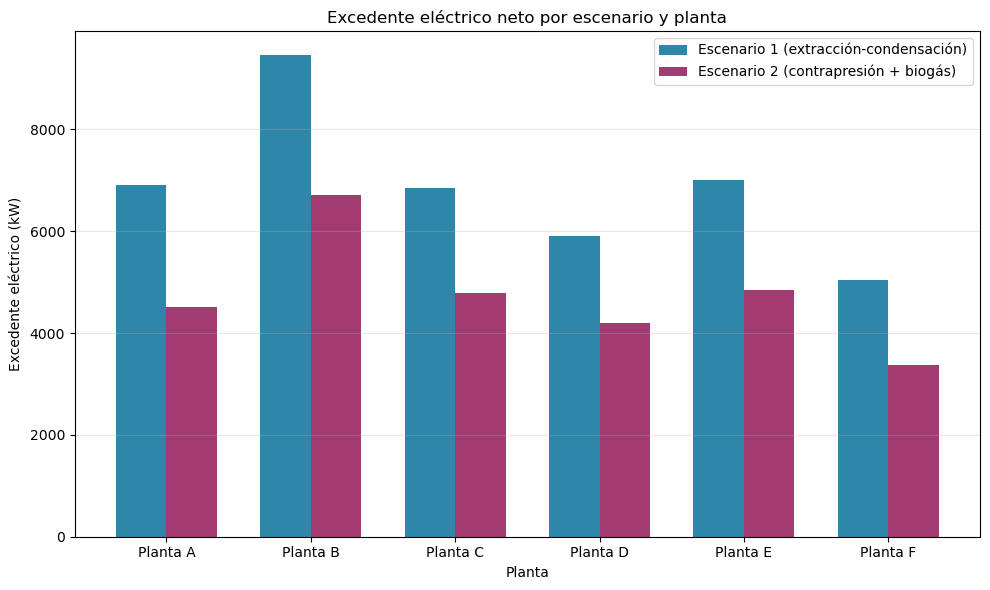

In [51]:
# ==========================================================
# Sección 12 - Comparación de escenarios (Línea base, Escenario 1, Escenario 2)
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np

# --- Recolectar resultados ya calculados ---
excedente_esc1 = {p: excedente_total_esc1_kW(p)[0] for p in plantas}
excedente_esc2 = {p: excedente_total_esc2_kW(p)[0] for p in plantas}

df_comparacion = pd.DataFrame({
    'Planta': plantas,
    'Escenario 1 (kW)': [excedente_esc1[p] for p in plantas],
    'Escenario 2 (kW)': [excedente_esc2[p] for p in plantas],
})
df_comparacion['Esc.2 / Esc.1 (%)'] = 100 * df_comparacion['Escenario 2 (kW)'] / df_comparacion['Escenario 1 (kW)']

print(df_comparacion.to_string(index=False))

# --- Gráfico de barras agrupadas ---
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(plantas))
ancho = 0.35

ax.bar(x - ancho/2, df_comparacion['Escenario 1 (kW)'], ancho, label='Escenario 1 (extracción-condensación)', color='#2E86AB')
ax.bar(x + ancho/2, df_comparacion['Escenario 2 (kW)'], ancho, label='Escenario 2 (contrapresión + biogás)', color='#A23B72')

ax.set_xlabel('Planta')
ax.set_ylabel('Excedente eléctrico (kW)')
ax.set_title('Excedente eléctrico neto por escenario y planta')
ax.set_xticks(x)
ax.set_xticklabels(plantas)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_excedente_escenarios.png', dpi=150)
plt.show()

df_comparacion.to_csv('comparacion_excedente_escenarios.csv', index=False)

  Planta  LB - % autogenerado (biomasa+biogás)  Escenario 1 - Excedente (kW)  Escenario 2 - Excedente (kW)
Planta A                             79.127913                   6906.929270                   4510.527791
Planta B                              0.000000                   9455.142458                   6706.756382
Planta C                              0.000000                   6852.339190                   4790.997899
Planta D                             70.000000                   5898.162820                   4190.431520
Planta E                              0.000000                   7012.353598                   4836.818628
Planta F                              0.000000                   5052.252448                   3379.603849


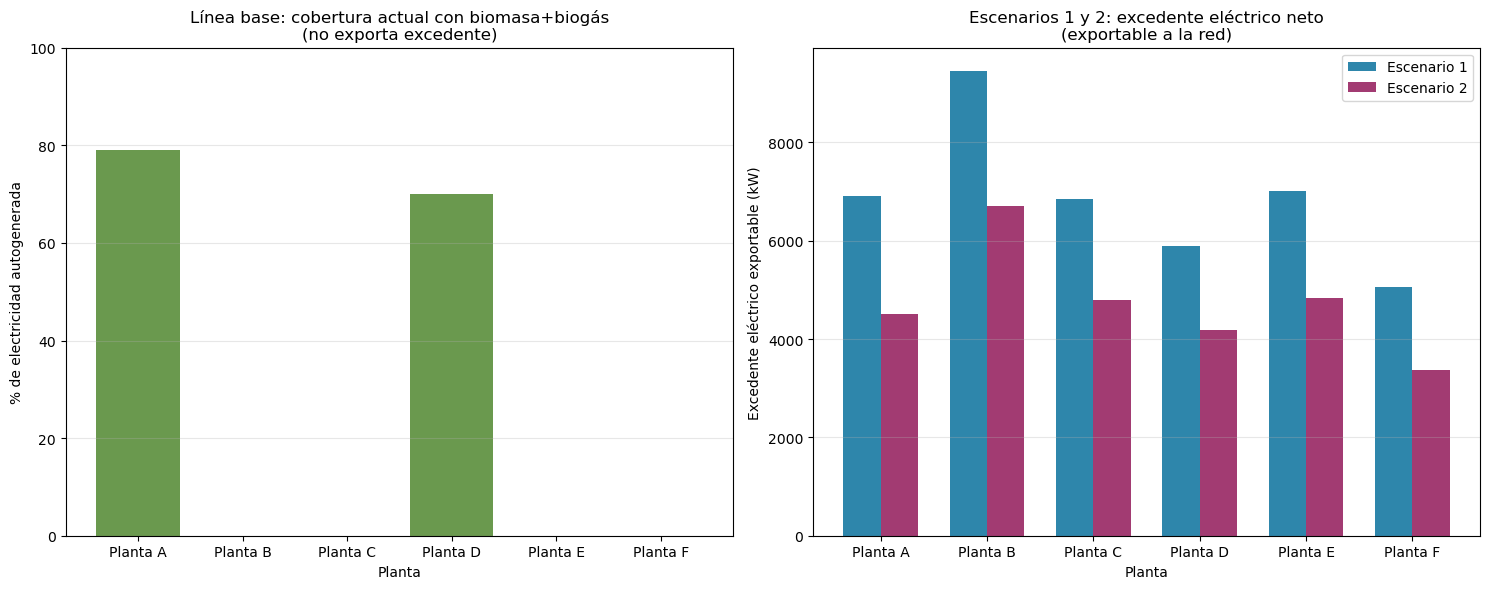

In [52]:
# ==========================================================
# Sección 12 - Comparación de escenarios (actualizado con línea base)
# Línea base: % de electricidad autogenerada con biomasa+biogás (métrica 
# distinta al excedente, ya que hoy no exporta nada a la red)
# Escenarios 1 y 2: excedente eléctrico neto exportable (kW)
# ==========================================================
# --- Línea base: % autogenerado (de Sección 8.1, df_fuente_electrica_LB) ---
df_fuente_electrica_LB['Pct_autogenerado'] = 100 * (
    df_fuente_electrica_LB['Electricidad_biomasa_kWh_ano'] + df_fuente_electrica_LB['Electricidad_biogas_kWh_ano']
) / df_fuente_electrica_LB['Consumo_electrico_total_kWh_ano']

pct_autogenerado_LB = dict(zip(df_fuente_electrica_LB['Planta'], df_fuente_electrica_LB['Pct_autogenerado']))

# --- Tabla consolidada ---
df_comparacion = pd.DataFrame({
    'Planta': plantas,
    'LB - % autogenerado (biomasa+biogás)': [pct_autogenerado_LB[p] for p in plantas],
    'Escenario 1 - Excedente (kW)': [excedente_esc1[p] for p in plantas],
    'Escenario 2 - Excedente (kW)': [excedente_esc2[p] for p in plantas],
})
print(df_comparacion.to_string(index=False))
df_comparacion.to_csv('comparacion_3_escenarios.csv', index=False)

# --- Gráfico de dos paneles ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(plantas))
ancho = 0.35

# Panel izquierdo: línea base, % autogenerado
ax1.bar(x, df_comparacion['LB - % autogenerado (biomasa+biogás)'], color='#6A994E')
ax1.set_xlabel('Planta')
ax1.set_ylabel('% de electricidad autogenerada')
ax1.set_title('Línea base: cobertura actual con biomasa+biogás\n(no exporta excedente)')
ax1.set_xticks(x)
ax1.set_xticklabels(plantas)
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)

# Panel derecho: Escenarios 1 y 2, excedente kW (el gráfico que ya validamos)
ax2.bar(x - ancho/2, df_comparacion['Escenario 1 - Excedente (kW)'], ancho, label='Escenario 1', color='#2E86AB')
ax2.bar(x + ancho/2, df_comparacion['Escenario 2 - Excedente (kW)'], ancho, label='Escenario 2', color='#A23B72')
ax2.set_xlabel('Planta')
ax2.set_ylabel('Excedente eléctrico exportable (kW)')
ax2.set_title('Escenarios 1 y 2: excedente eléctrico neto\n(exportable a la red)')
ax2.set_xticks(x)
ax2.set_xticklabels(plantas)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_3_escenarios.png', dpi=150)
plt.show()

## Sección 13 (nueva): impacto social de los 3 escenarios

In [53]:
# ==========================================================
# Sección 13 - Impacto social de los 3 escenarios
# Horas de operación anual: hoja Eficiencia, fila Excel 6
# ==========================================================
raw_efi_horas = pd.read_excel('Escenarios.xlsx', sheet_name='Eficiencia', header=None)
horas_operacion_anual = dict(zip(plantas, raw_efi_horas.iloc[5, 2:8].tolist()))
print("Horas de operación anual por planta:", horas_operacion_anual)

# --- Convertir excedente eléctrico (kW) a energía anual (kWh/año) ---
excedentes_esc1_kWh_ano = {p: excedente_esc1[p] * horas_operacion_anual[p] for p in plantas}
excedentes_esc2_kWh_ano = {p: excedente_esc2[p] * horas_operacion_anual[p] for p in plantas}

# --- Aplicar las funciones ya construidas en la Sección 5 ---
df_impacto_esc1 = construir_tabla_impacto_social(excedentes_esc1_kWh_ano, 'Escenario_1_Termico')
df_impacto_esc2 = construir_tabla_impacto_social(excedentes_esc2_kWh_ano, 'Escenario_2_Biogas')

df_impacto_social = pd.concat([df_impacto_esc1, df_impacto_esc2], ignore_index=True)
print(df_impacto_social.to_string(index=False))

df_impacto_social.to_csv('impacto_social_escenarios.csv', index=False)

Horas de operación anual por planta: {'Planta A': 5105, 'Planta B': 5155, 'Planta C': 5920, 'Planta D': 5496, 'Planta E': 3147, 'Planta F': 1931}
          Escenario   Planta  Excedente_kWh_ano  Viviendas_rurales_beneficiadas  Personas_rurales_beneficiadas  Pct_cobertura_rural_departamental
Escenario_1_Termico Planta A       3.525987e+07                   101841.687332                  376814.243130                         116.369221
Escenario_1_Termico Planta B       4.874126e+07                   140780.199831                  520886.739376                         160.862242
Escenario_1_Termico Planta C       4.056585e+07                   117167.021588                  433517.979874                         133.880686
Escenario_1_Termico Planta D       3.241630e+07                    93628.553175                  346425.646748                         106.984498
Escenario_1_Termico Planta E       2.206788e+07                    63739.019920                  235834.373703              

In [54]:
# ==========================================================
# Sección 13 - Ajuste: techo de 100% en cobertura rural departamental
# Se mantiene la columna original (Pct_cobertura_rural_departamental) para 
# trazabilidad, y se agrega una versión con techo + bandera de "supera 100%"
# para presentación en tablas/gráficos del artículo (evita la lectura 
# errónea de "más del 100% de cobertura").
# ==========================================================
df_impacto_social['Supera_100pct_cobertura'] = df_impacto_social['Pct_cobertura_rural_departamental'] > 100
df_impacto_social['Pct_cobertura_rural_departamental_techo'] = df_impacto_social['Pct_cobertura_rural_departamental'].clip(upper=100)

print(df_impacto_social[['Escenario', 'Planta', 'Pct_cobertura_rural_departamental',
                          'Pct_cobertura_rural_departamental_techo', 'Supera_100pct_cobertura']].to_string(index=False))

df_impacto_social.to_csv('impacto_social_escenarios.csv', index=False)

          Escenario   Planta  Pct_cobertura_rural_departamental  Pct_cobertura_rural_departamental_techo  Supera_100pct_cobertura
Escenario_1_Termico Planta A                         116.369221                               100.000000                     True
Escenario_1_Termico Planta B                         160.862242                               100.000000                     True
Escenario_1_Termico Planta C                         133.880686                               100.000000                     True
Escenario_1_Termico Planta D                         106.984498                               100.000000                     True
Escenario_1_Termico Planta E                          72.831276                                72.831276                    False
Escenario_1_Termico Planta F                          32.197688                                32.197688                    False
 Escenario_2_Biogas Planta A                          75.994206                           

## Sección 14: balance de emisiones de GEI por escenario

In [55]:
# ==========================================================
# Sección 14 - Balance de emisiones de GEI (CO2-eq) por escenario
# Combina: no-CO2 de combustión (biomasa/biogás), diésel de respaldo (3%, 
# eficiencia genset 30%), crédito por electricidad exportada (desplaza 
# red nacional), y crédito de absorción de palma (ya en balance_neto_GEI).
# Todas las funciones/factores ya definidos en la Sección 4.
# ==========================================================
kWh_a_TJ = 1 / 277_777.78  # 1 TJ = 277,777.78 kWh
FRACCION_DIESEL_RESPALDO = 0.03   # supuesto, 3% del consumo eléctrico propio
EFICIENCIA_GENSET_DIESEL = 0.30   # supuesto de literatura

fruto_procesado_anual = {p: horas_operacion_anual[p] * capacidades[p] * 1000 for p in plantas}  # kg/año aprox -> ton
fruto_procesado_anual_t = {p: horas_operacion_anual[p] * capacidades[p] for p in plantas}  # t/año

def balance_emisiones_esc1(planta):
    horas = horas_operacion_anual[planta]

    # --- No-CO2 de combustión de biomasa sólida ---
    energia_biomasa_kWth, _ = energia_biomasa_kWth_esc1(planta)
    energia_biomasa_TJ_ano = energia_biomasa_kWth * horas * kWh_a_TJ
    emisiones_biomasa = emisiones_no_co2_biomasa(energia_biomasa_TJ_ano, fuente='Biomasa sólida')

    # --- No-CO2 de combustión de biogás ---
    ch4_biogas_Nm3_h = biogas_pome(planta)['metano_Nm3_h']
    energia_biogas_TJ_ano = ch4_biogas_Nm3_h * LHV_CH4_kWh_Nm3 * horas * kWh_a_TJ
    emisiones_biogas = emisiones_no_co2_biomasa(energia_biogas_TJ_ano, fuente='Biogás')

    # --- Diésel de respaldo (3% del consumo eléctrico propio, genset 30%) ---
    consumo_propio_kWh_ano = consumo_electrico_esc1_kW(planta) * horas
    elec_diesel_kWh_ano = consumo_propio_kWh_ano * FRACCION_DIESEL_RESPALDO
    fuel_diesel_TJ_ano = (elec_diesel_kWh_ano / EFICIENCIA_GENSET_DIESEL) * kWh_a_TJ
    emisiones_diesel_kg = emisiones_diesel(fuel_diesel_TJ_ano)

    # --- Crédito por electricidad exportada (desplaza red nacional) ---
    excedente_kWh_ano = excedente_total_esc1_kW(planta)[0] * horas
    credito_exportacion_kg = -emisiones_red_nacional(excedente_kWh_ano)  # negativo = crédito

    # --- Balance total ---
    emisiones_proceso = emisiones_biomasa + emisiones_biogas + emisiones_diesel_kg + credito_exportacion_kg
    balance_neto = balance_neto_GEI(emisiones_proceso, fruto_procesado_anual_t[planta])

    return {'emisiones_biomasa_kg': emisiones_biomasa, 'emisiones_biogas_kg': emisiones_biogas,
            'emisiones_diesel_kg': emisiones_diesel_kg, 'credito_exportacion_kg': credito_exportacion_kg,
            'balance_neto_kgCO2eq_ano': balance_neto}

def balance_emisiones_esc2(planta):
    horas = horas_operacion_anual[planta]

    energia_biomasa_kWth = energia_biomasa_kWth_esc2(planta)
    energia_biomasa_TJ_ano = energia_biomasa_kWth * horas * kWh_a_TJ
    emisiones_biomasa = emisiones_no_co2_biomasa(energia_biomasa_TJ_ano, fuente='Biomasa sólida')

    ch4_biogas_Nm3_h = biogas_pome_y_efb_esc2(planta)['ch4_total_Nm3_h']
    energia_biogas_TJ_ano = ch4_biogas_Nm3_h * LHV_CH4_kWh_Nm3 * horas * kWh_a_TJ
    emisiones_biogas = emisiones_no_co2_biomasa(energia_biogas_TJ_ano, fuente='Biogás')

    consumo_propio_kWh_ano = consumo_electrico_esc2_kW(planta) * horas
    elec_diesel_kWh_ano = consumo_propio_kWh_ano * FRACCION_DIESEL_RESPALDO
    fuel_diesel_TJ_ano = (elec_diesel_kWh_ano / EFICIENCIA_GENSET_DIESEL) * kWh_a_TJ
    emisiones_diesel_kg = emisiones_diesel(fuel_diesel_TJ_ano)

    excedente_kWh_ano = excedente_total_esc2_kW(planta)[0] * horas
    credito_exportacion_kg = -emisiones_red_nacional(excedente_kWh_ano)

    emisiones_proceso = emisiones_biomasa + emisiones_biogas + emisiones_diesel_kg + credito_exportacion_kg
    balance_neto = balance_neto_GEI(emisiones_proceso, fruto_procesado_anual_t[planta])

    return {'emisiones_biomasa_kg': emisiones_biomasa, 'emisiones_biogas_kg': emisiones_biogas,
            'emisiones_diesel_kg': emisiones_diesel_kg, 'credito_exportacion_kg': credito_exportacion_kg,
            'balance_neto_kgCO2eq_ano': balance_neto}

print("Balance de emisiones GEI - Escenario 1 (kg CO2-eq/año):\n")
for p in plantas:
    r = balance_emisiones_esc1(p)
    print(f"{p}: biomasa={r['emisiones_biomasa_kg']:,.0f} | biogás={r['emisiones_biogas_kg']:,.0f} | "
          f"diésel={r['emisiones_diesel_kg']:,.0f} | crédito export={r['credito_exportacion_kg']:,.0f} | "
          f"BALANCE NETO={r['balance_neto_kgCO2eq_ano']:,.0f}")

print("\nBalance de emisiones GEI - Escenario 2 (kg CO2-eq/año):\n")
for p in plantas:
    r = balance_emisiones_esc2(p)
    print(f"{p}: biomasa={r['emisiones_biomasa_kg']:,.0f} | biogás={r['emisiones_biogas_kg']:,.0f} | "
          f"diésel={r['emisiones_diesel_kg']:,.0f} | crédito export={r['credito_exportacion_kg']:,.0f} | "
          f"BALANCE NETO={r['balance_neto_kgCO2eq_ano']:,.0f}")

Balance de emisiones GEI - Escenario 1 (kg CO2-eq/año):

Planta A: biomasa=1,211,682 | biogás=4,458 | diésel=116,725 | crédito export=-5,761,463 | BALANCE NETO=-25,109,973
Planta B: biomasa=1,474,681 | biogás=7,878 | diésel=105,503 | crédito export=-7,964,322 | BALANCE NETO=-34,221,508
Planta C: biomasa=1,307,013 | biogás=6,355 | diésel=116,696 | crédito export=-6,628,460 | BALANCE NETO=-29,181,499
Planta D: biomasa=918,614 | biogás=6,338 | diésel=80,494 | crédito export=-5,296,824 | BALANCE NETO=-22,103,694
Planta E: biomasa=701,201 | biogás=3,591 | diésel=78,330 | crédito export=-3,605,891 | BALANCE NETO=-15,571,895
Planta F: biomasa=301,676 | biogás=1,433 | diésel=20,023 | crédito export=-1,594,114 | BALANCE NETO=-6,486,227

Balance de emisiones GEI - Escenario 2 (kg CO2-eq/año):

Planta A: biomasa=634,143 | biogás=10,619 | diésel=102,311 | crédito export=-3,762,488 | BALANCE NETO=-23,696,791
Planta B: biomasa=754,686 | biogás=15,559 | diésel=86,992 | crédito export=-5,649,282 | BAL

In [56]:
# ==========================================================
# Sección 14 - Intensidad de emisiones SIN el crédito de absorción de palma
# (el crédito de absorción se reporta aparte, por tRFF, no por kWh, ya que 
# no depende de la tecnología de generación eléctrica)
# ==========================================================
def intensidad_emisiones(emisiones_kg_ano, energia_kWh_ano):
    """Intensidad de emisiones en gCO2eq/kWh, a partir de emisiones anuales 
    (kg CO2-eq/año) y energía exportada anual (kWh/año)."""
    return emisiones_kg_ano * 1000 / energia_kWh_ano

def balance_emisiones_solo_energia_esc1(planta):
    r = balance_emisiones_esc1(planta)
    return r['emisiones_biomasa_kg'] + r['emisiones_biogas_kg'] + r['emisiones_diesel_kg'] + r['credito_exportacion_kg']

def balance_emisiones_solo_energia_esc2(planta):
    r = balance_emisiones_esc2(planta)
    return r['emisiones_biomasa_kg'] + r['emisiones_biogas_kg'] + r['emisiones_diesel_kg'] + r['credito_exportacion_kg']

print("Intensidad de emisiones - SOLO sistema energético (sin absorción de palma), Escenario 1:\n")
for p in plantas:
    emisiones_energia = balance_emisiones_solo_energia_esc1(p)
    excedente_kWh_ano = excedente_total_esc1_kW(p)[0] * horas_operacion_anual[p]
    intensidad = intensidad_emisiones(emisiones_energia, excedente_kWh_ano)
    print(f"{p}: {intensidad:,.1f} gCO2eq/kWh")

print("\nIntensidad de emisiones - SOLO sistema energético (sin absorción de palma), Escenario 2:\n")
for p in plantas:
    emisiones_energia = balance_emisiones_solo_energia_esc2(p)
    excedente_kWh_ano = excedente_total_esc2_kW(p)[0] * horas_operacion_anual[p]
    intensidad = intensidad_emisiones(emisiones_energia, excedente_kWh_ano)
    print(f"{p}: {intensidad:,.1f} gCO2eq/kWh")

print(f"\nCrédito de absorción de palma (constante, no depende del escenario): {FACTOR_ABSORCION_PALMA} kg CO2/tRFF")

Intensidad de emisiones - SOLO sistema energético (sin absorción de palma), Escenario 1:

Planta A: -125.6 gCO2eq/kWh
Planta B: -130.8 gCO2eq/kWh
Planta C: -128.1 gCO2eq/kWh
Planta D: -132.4 gCO2eq/kWh
Planta E: -127.9 gCO2eq/kWh
Planta F: -130.3 gCO2eq/kWh

Intensidad de emisiones - SOLO sistema energético (sin absorción de palma), Escenario 2:

Planta A: -131.0 gCO2eq/kWh
Planta B: -138.6 gCO2eq/kWh
Planta C: -135.5 gCO2eq/kWh
Planta D: -136.6 gCO2eq/kWh
Planta E: -135.7 gCO2eq/kWh
Planta F: -133.8 gCO2eq/kWh

Crédito de absorción de palma (constante, no depende del escenario): -135.04 kg CO2/tRFF


In [57]:
import inspect
print(inspect.getsource(balance_neto_GEI))

def balance_neto_GEI(emisiones_proceso_kgCO2eq, tRFF_procesado):
    credito_absorcion = FACTOR_ABSORCION_PALMA * tRFF_procesado
    return emisiones_proceso_kgCO2eq + credito_absorcion



## Sección 15: LCOE (costo nivelado de energía)

In [58]:
# ==========================================================
# Sección 15.0 — Núcleo económico: parámetros, motor de escalamiento y CAPEX
#
# CORRECCIONES CRÍTICAS respecto a versiones anteriores:
#  (1) REGLA DE LOS SEIS DÉCIMOS (exponente 0.6, Tabla 18 — Sinnot & Taylor,
#      Peters et al.) aplicada a TODOS los equipos. Antes se escalaba
#      linealmente, lo que sobreestimaba gravemente los equipos alejados de
#      su capacidad de referencia (la turbina de Esc.1 opera a 7.5x su
#      referencia de 1,000 kW -> el costo lineal la sobreestimaba >2x).
#  (2) DOBLE CONTEO DE LA CALDERA ELIMINADO: los costos de turbina de la
#      Tabla 17 ($3,669/kW extracción-condensación; $2,815/kW contrapresión)
#      YA INCLUYEN la caldera. La partida separada "Caldera" se elimina.
#
# Efecto: CAPEX Esc.1 -54% ; CAPEX Esc.2 -30%.
# ==========================================================

# --- Parámetros financieros ---
TASA_DESCUENTO = 0.10
VIDA_UTIL_ANOS = 20
PVAF = (1 - (1 + TASA_DESCUENTO) ** -VIDA_UTIL_ANOS) / TASA_DESCUENTO
PCT_OPERACION_ANUAL = 0.025          # O&M anual como % del CAPEX (Tabla 18)
N_ESCALAMIENTO = 0.6                 # regla de los seis décimos (Tabla 18)

# --- Precios (Tabla 18 + fuentes primarias) ---
PRECIO_ELECTRICIDAD_VENTA = 0.06     # $/kWh (legado CREG 030; CREG 174 lo sustituye en Fase 2)
PRECIO_PKS = 16                      # $/t cuesco  (costo de oportunidad al quemarlo)
PRECIO_MF  = 8                       # $/t fibra
TRM_COP_USD = 3339.65

# Precio de compra ESPECÍFICO POR PLANTA = costo ponderado real de su matriz
# eléctrica actual (línea base). No un valor único de red: Planta A y D ya
# cogeneran barato, así que su ahorro marginal al invertir es menor.
PRECIO_ELECTRICIDAD_COMPRA_dict = {
    'Planta A': 0.1141, 'Planta B': 0.2537, 'Planta C': 0.2572,
    'Planta D': 0.1530, 'Planta E': 0.2551, 'Planta F': 0.2591,
}

# ==========================================================
# Motor de escalamiento (regla de los seis décimos)
# ==========================================================
def costo_escalado(costo_unitario_ref, capacidad_ref, capacidad_real):
    """Costo TOTAL (USD 2026) de un equipo a `capacidad_real`.

    costo_unitario_ref : $/unidad A LA CAPACIDAD DE REFERENCIA (Tabla 17)
    capacidad_ref      : capacidad a la que aplica ese costo unitario
    """
    costo_total_ref = costo_unitario_ref * capacidad_ref
    return costo_total_ref * factor_cepci_2019 * (capacidad_real / capacidad_ref) ** N_ESCALAMIENTO

# --- Tabla 17: (costo unitario, capacidad de referencia) ---
REF = {
    'turbina_extraccion':    (3669,  1000),   # $/kW    @ 1,000 kW    INCLUYE CALDERA
    'turbina_contrapresion': (2815,  1000),   # $/kW    @ 1,000 kW    INCLUYE CALDERA
    'precipitador':          (25000, 15),     # $/tvap  @ 15 t vapor  (Esc.1)
    'gases_combustion':      (11515, 15),     # $/tvap  @ 15 t vapor  (Esc.2; ref. supuesta por analogía)
    'pretrat_mecanico':      (29655, 3),      # $/tEFB  @ 3 tEFB
    'lagunas_carpadas':      (18518, 27),     # $/tRFF  @ 27 t/h
    'tratamiento_biogas':    (424,   660),    # $/m3    @ 660 m3/h
    'generador_biogas':      (186,   1500),   # $/kW    @ 1,500 kW
    'esteriliz_continua':    (38400, 20),     # $/tRFF  @ 20 t/h
    'clarif_dinamica':       (23368, 15),     # $/tRFF  @ 15 t/h
}
COSTO_REDES_INFRA_USD_tRFF = 7153.13 * factor_cepci_2019   # LINEAL (infraestructura ~proporcional)
CAP_REF_TRAT_TERMICO, COSTO_REF_TRAT_TERMICO = 5.6, 178571  # tEFB/h ; $ total (Tabla 17)

# ==========================================================
# Catálogos comerciales -> CAPEX por tamaño (con economías de escala)
# El costo por kW YA NO es constante: cae con el tamaño. Por eso el CAPEX
# se precalcula por entrada de catálogo y entra al MILP como coeficiente
# de la binaria de selección (sigue siendo lineal en las binarias).
# ==========================================================
CATALOGO_TURBINA_ESC1 = [300, 500, 750, 1000, 1500, 2000, 3000, 4000,
                         5000, 6000, 7000, 8000, 9000, 10000]          # kW
CATALOGO_TURBINA_CONTRAPRESION = [750, 1000, 1250, 1500, 1750]         # kW

CAPEX_TURBINA_ESC1 = {k: costo_escalado(*REF['turbina_extraccion'], k)
                      for k in CATALOGO_TURBINA_ESC1}
CAPEX_TURBINA_ESC2 = {k: costo_escalado(*REF['turbina_contrapresion'], k)
                      for k in CATALOGO_TURBINA_CONTRAPRESION}

# Generador de biogás: N unidades modulares de 1 MW (motogeneradores POME).
# Las economías de escala aplican al DIMENSIONAR UNA unidad respecto a la
# referencia (1,500 kW), NO a replicar unidades idénticas: N módulos iguales
# cuestan N x costo_unidad. Por eso el CAPEX es lineal en N.
TAMANO_UNIDAD_BIOGAS_KW = 1000
N_MAX_UNIDADES_BIOGAS = 8
CAPEX_UNIDAD_BIOGAS = costo_escalado(*REF['generador_biogas'], TAMANO_UNIDAD_BIOGAS_KW)

# ==========================================================
# CAPEX incremental por escenario
# (solo inversión NUEVA; la planta extractora ya existe)
# NOTA: las claves 'Turbina' y 'Generador de biogás' se usan como filtro en
# la Fase 2 para excluir lo que ya es variable de decisión -> NO renombrar
# sin actualizar capex_fijo_esc1/esc2.
# ==========================================================
def capex_incremental_esc1(planta):
    pot_turbina_kW = potencia_turbina_kW(planta)['potencia_bruta_kW']
    cap_vapor_t_h  = vapor_producido_kg_h(planta) / 1000
    flujo_efb_t_h  = df_biomasa_disponible.loc[planta, 'Raquis'] / 1000
    r_bio          = biogas_pome(planta)
    pot_biogas_kW  = r_bio['generacion_bruta_kW']
    biogas_m3_h    = r_bio['metano_Nm3_h'] / 0.65          # supuesto 65% CH4

    return {
        'Turbina':                             costo_escalado(*REF['turbina_extraccion'], pot_turbina_kW),
        'Precipitador electroestático':        costo_escalado(*REF['precipitador'], cap_vapor_t_h),
        'Pretratamiento mecánico EFB':         costo_escalado(*REF['pretrat_mecanico'], flujo_efb_t_h),
        'Lagunas carpadas (reactor)':          costo_escalado(*REF['lagunas_carpadas'], capacidades[planta]),
        'Tratamiento de biogás':               costo_escalado(*REF['tratamiento_biogas'], biogas_m3_h),
        'Generador de biogás':                 costo_escalado(*REF['generador_biogas'], pot_biogas_kW),
        'Sustitución esterilización continua': costo_escalado(*REF['esteriliz_continua'], capacidades[planta]),
        'Sustitución clarificación dinámica':  costo_escalado(*REF['clarif_dinamica'], capacidades[planta]),
        'Redes e infraestructura':             COSTO_REDES_INFRA_USD_tRFF * capacidades[planta],
    }

def capex_incremental_esc2(planta):
    pot_turbina_kW = potencia_turbina_esc2_kW(planta)['potencia_bruta_kW']
    cap_vapor_t_h  = vapor_producido_kg_h_esc2(planta) / 1000
    flujo_efb_t_h  = df_biomasa_disponible.loc[planta, 'Raquis'] / 1000
    r_bio          = biogas_pome_y_efb_esc2(planta)
    pot_biogas_kW  = r_bio['generacion_bruta_kW']
    biogas_m3_h    = r_bio['ch4_efluente_Nm3_h'] / 0.65 + r_bio['ch4_efb_Nm3_h'] / 0.54

    costo_trat_termico = (COSTO_REF_TRAT_TERMICO * factor_cepci_2019
                          * (flujo_efb_t_h / CAP_REF_TRAT_TERMICO) ** N_ESCALAMIENTO)

    return {
        'Turbina':                            costo_escalado(*REF['turbina_contrapresion'], pot_turbina_kW),
        'Sistema gases de combustión':        costo_escalado(*REF['gases_combustion'], cap_vapor_t_h),
        'Tratamiento térmico EFB':            costo_trat_termico,
        'Lagunas carpadas (reactor)':         costo_escalado(*REF['lagunas_carpadas'], capacidades[planta]),
        'Tratamiento de biogás':              costo_escalado(*REF['tratamiento_biogas'], biogas_m3_h),
        'Generador de biogás':                costo_escalado(*REF['generador_biogas'], pot_biogas_kW),
        'Sustitución clarificación dinámica': costo_escalado(*REF['clarif_dinamica'], capacidades[planta]),
        'Redes e infraestructura':            COSTO_REDES_INFRA_USD_tRFF * capacidades[planta],
    }

def lcoe_escenario(planta, capex_items, excedente_kW, consumo_propio_kW, escenario_num):
    horas = horas_operacion_anual[planta]
    capex_total = sum(capex_items.values())

    excedente_kWh_ano = excedente_kW * horas
    consumo_propio_kWh_ano = consumo_propio_kW * horas

    ahorro_autoconsumo = PRECIO_ELECTRICIDAD_COMPRA_dict[planta] * consumo_propio_kWh_ano
    venta_excedente = PRECIO_ELECTRICIDAD_VENTA * excedente_kWh_ano

    cuesco_t_ano = (df_biomasa_disponible.loc[planta, 'Cuesco']/1000) * horas
    fibra_t_ano = (df_biomasa_disponible.loc[planta, 'Fibra']/1000) * horas
    costo_oportunidad_pks_mf = PRECIO_PKS * cuesco_t_ano + PRECIO_MF * fibra_t_ano

    costo_operacion_anual = PCT_OPERACION_ANUAL * capex_total

    opex_neto_anual = costo_operacion_anual + costo_oportunidad_pks_mf - ahorro_autoconsumo - venta_excedente

    lcoe = capex_total / (excedente_kWh_ano * PVAF) + opex_neto_anual / excedente_kWh_ano

    return {'capex_total': capex_total, 'opex_neto_anual': opex_neto_anual,
            'excedente_kWh_ano': excedente_kWh_ano, 'lcoe_USD_kWh': lcoe}

print("CAPEX incremental total (USD 2026) — regla 0.6, sin doble conteo de caldera:\n")
print(f"{'Planta':10} {'Escenario 1':>16} {'Escenario 2':>16}")
for p in plantas:
    print(f"{p:10} {sum(capex_incremental_esc1(p).values()):16,.0f} "
          f"{sum(capex_incremental_esc2(p).values()):16,.0f}")

print("\nCatálogo turbina Esc.1 — economías de escala:")
print(f"{'kW':>7} {'CAPEX':>14} {'$/kW':>8} {'$/kW/año':>10}")
for k in CATALOGO_TURBINA_ESC1:
    c = CAPEX_TURBINA_ESC1[k]
    print(f"{k:7,} {c:14,.0f} {c/k:8,.0f} {c/k/PVAF:10,.1f}")
print(f"\nCAPEX unidad biogás (1 MW): ${CAPEX_UNIDAD_BIOGAS:,.0f}")


CAPEX incremental total (USD 2026) — regla 0.6, sin doble conteo de caldera:

Planta          Escenario 1      Escenario 2
Planta A         22,996,475        8,789,180
Planta B         26,090,473       10,116,479
Planta C         22,025,384        8,573,240
Planta D         18,918,120        7,711,279
Planta E         22,473,772        8,504,885
Planta F         17,964,577        7,095,192

Catálogo turbina Esc.1 — economías de escala:
     kW          CAPEX     $/kW   $/kW/año
    300      2,562,632    8,542    1,003.4
    500      3,481,733    6,963      817.9
    750      4,440,688    5,921      695.5
  1,000      5,277,320    5,277      619.9
  1,500      6,730,824    4,487      527.1
  2,000      7,998,922    3,999      469.8
  3,000     10,202,021    3,401      399.4
  4,000     12,124,099    3,031      356.0
  5,000     13,861,029    2,772      325.6
  6,000     15,463,373    2,577      302.7
  7,000     16,961,814    2,423      284.6
  8,000     18,376,697    2,297      269.8
 

In [59]:
# ==========================================================
# Sección 15 - Conversión LCOE a pesos colombianos (COP)
# TRM del 9 de julio de 2026: $3,339.65 COP/USD (fuente: Banco de la 
# República / TRM oficial) - actualizar si se corre en otra fecha
# ==========================================================
TRM_COP_USD = 3339.65

print("LCOE - Escenario 1 (USD/kWh y COP/kWh):\n")
for p in plantas:
    items1 = capex_incremental_esc1(p)
    r = lcoe_escenario(p, items1, excedente_esc1[p], consumo_electrico_esc1_kW(p), 1)
    lcoe_cop = r['lcoe_USD_kWh'] * TRM_COP_USD
    print(f"{p}: LCOE=${r['lcoe_USD_kWh']:.4f}/kWh  |  ${lcoe_cop:,.1f} COP/kWh")

print("\nLCOE - Escenario 2 (USD/kWh y COP/kWh):\n")
for p in plantas:
    items2 = capex_incremental_esc2(p)
    r = lcoe_escenario(p, items2, excedente_esc2[p], consumo_electrico_esc2_kW(p), 2)
    lcoe_cop = r['lcoe_USD_kWh'] * TRM_COP_USD
    print(f"{p}: LCOE=${r['lcoe_USD_kWh']:.4f}/kWh  |  ${lcoe_cop:,.1f} COP/kWh")

LCOE - Escenario 1 (USD/kWh y COP/kWh):

Planta A: LCOE=$0.0272/kWh  |  $90.8 COP/kWh
Planta B: LCOE=$0.0027/kWh  |  $9.0 COP/kWh
Planta C: LCOE=$-0.0028/kWh  |  $-9.3 COP/kWh
Planta D: LCOE=$0.0166/kWh  |  $55.6 COP/kWh
Planta E: LCOE=$0.0581/kWh  |  $194.1 COP/kWh
Planta F: LCOE=$0.1908/kWh  |  $637.4 COP/kWh

LCOE - Escenario 2 (USD/kWh y COP/kWh):

Planta A: LCOE=$-0.0117/kWh  |  $-39.1 COP/kWh
Planta B: LCOE=$-0.0323/kWh  |  $-108.0 COP/kWh
Planta C: LCOE=$-0.0407/kWh  |  $-136.1 COP/kWh
Planta D: LCOE=$-0.0188/kWh  |  $-62.8 COP/kWh
Planta E: LCOE=$-0.0143/kWh  |  $-47.6 COP/kWh
Planta F: LCOE=$0.0827/kWh  |  $276.0 COP/kWh


In [60]:
# ==========================================================
# Sección 15 - LCOE bruto (convencional, sin restar ingresos/ahorros)
# Complementa el LCOE neto ya calculado - para reportar ambos en el 
# artículo y evitar que un LCOE negativo se malinterprete
# ==========================================================
def lcoe_bruto(planta, capex_items, excedente_kW):
    horas = horas_operacion_anual[planta]
    capex_total = sum(capex_items.values())
    excedente_kWh_ano = excedente_kW * horas
    costo_operacion_anual = PCT_OPERACION_ANUAL * capex_total   # solo O&M, sin ingresos
    lcoe = capex_total / (excedente_kWh_ano * PVAF) + costo_operacion_anual / excedente_kWh_ano 
    return lcoe

print("LCOE bruto vs. neto - Escenario 1:\n")
for p in plantas:
    items1 = capex_incremental_esc1(p)
    bruto = lcoe_bruto(p, items1, excedente_esc1[p])
    neto = lcoe_escenario(p, items1, excedente_esc1[p], consumo_electrico_esc1_kW(p), 1)['lcoe_USD_kWh']
    print(f"{p}: bruto=${bruto:.4f}/kWh | neto=${neto:.4f}/kWh")

print("\nLCOE bruto vs. neto - Escenario 2:\n")
for p in plantas:
    items2 = capex_incremental_esc2(p)
    bruto = lcoe_bruto(p, items2, excedente_esc2[p])
    neto = lcoe_escenario(p, items2, excedente_esc2[p], consumo_electrico_esc2_kW(p), 2)['lcoe_USD_kWh']
    print(f"{p}: bruto=${bruto:.4f}/kWh | neto=${neto:.4f}/kWh")

LCOE bruto vs. neto - Escenario 1:

Planta A: bruto=$0.0929/kWh | neto=$0.0272/kWh
Planta B: bruto=$0.0763/kWh | neto=$0.0027/kWh
Planta C: bruto=$0.0773/kWh | neto=$-0.0028/kWh
Planta D: bruto=$0.0831/kWh | neto=$0.0166/kWh
Planta E: bruto=$0.1451/kWh | neto=$0.0581/kWh
Planta F: bruto=$0.2623/kWh | neto=$0.1908/kWh

LCOE bruto vs. neto - Escenario 2:

Planta A: bruto=$0.0544/kWh | neto=$-0.0117/kWh
Planta B: bruto=$0.0417/kWh | neto=$-0.0323/kWh
Planta C: bruto=$0.0431/kWh | neto=$-0.0407/kWh
Planta D: bruto=$0.0477/kWh | neto=$-0.0188/kWh
Planta E: bruto=$0.0796/kWh | neto=$-0.0143/kWh
Planta F: bruto=$0.1549/kWh | neto=$0.0827/kWh


## Sección 16 — Fase 2 (superestructura), Escenario 1: turbina extracción-condensación + biogás de POME

*Reorganizada para dejar solo el flujo final y correcto; las iteraciones exploratorias superadas quedan archivadas en 16.6, sin ejecutarse como parte del resultado reportado.*

### 16.0 Costo de oportunidad

In [61]:
# ==========================================================
# Costo de oportunidad de la biomasa quemada (fibra + cuesco)
# en vez de vendida como PKS/MF -- df_biomasa_disponible esta en
# kg/h, se convierte a t/ano multiplicando por horas de operacion
# ==========================================================
PRECIO_PKS_USD_t = 16   # cuesco / palm kernel shell
PRECIO_MF_USD_t = 8     # fibra / mesocarp fiber

costo_oport_dict = {
    p: (df_biomasa_disponible.loc[p, 'Cuesco'] * horas_operacion_anual[p] / 1000) * PRECIO_PKS_USD_t
     + (df_biomasa_disponible.loc[p, 'Fibra']  * horas_operacion_anual[p] / 1000) * PRECIO_MF_USD_t
    for p in plantas
}

print("costo_oport_dict reconstruido y validado:")
for p, v in costo_oport_dict.items():
    print(f"  {p}: ${v:,.0f}")
print(f"Total: ${sum(costo_oport_dict.values()):,.0f}  (debe ser 1,435,859)")

costo_oport_dict reconstruido y validado:
  Planta A: $297,724
  Planta B: $342,136
  Planta C: $308,314
  Planta D: $251,153
  Planta E: $154,046
  Planta F: $82,486
Total: $1,435,858  (debe ser 1,435,859)


In [62]:
def costo_oportunidad_raquis_NFRV(precios_fertilizantes_COP_kg, TRM, eficiencia_mineralizacion=0.70):
    """
    Costo de Oportunidad Neto del raquis (Net Fertilizer Replacement Value, NFRV).
    Ver docstring completo en el bloque anterior -- incluye la justificacion de la
    eficiencia de mineralizacion (Budi et al. 2001; Saletes et al. 2004; Ramirez et al. 2011)
    y la sustitucion de fosfato tricalcico por DAP (unica fuente de P cotizada por Sipsa/DANE).
    """
    FACTORES_EQUIVALENCIA_KG_T = {
        'urea': 7.7, 'fosfato_tricalcico': 2.3, 'kcl': 21.7, 'kieserita': 3.3,
    }
    costo_bruto_COP_por_t = sum(
        FACTORES_EQUIVALENCIA_KG_T[n] * precios_fertilizantes_COP_kg[n]
        for n in FACTORES_EQUIVALENCIA_KG_T
    )
    return (costo_bruto_COP_por_t * eficiencia_mineralizacion) / TRM

# Precios VERIFICADOS: Fedepalma/DANE (Sipsa), primer trimestre 2025
precios_2025_COP_kg = {
    'urea': 124912/50,
    'fosfato_tricalcico': 191706/50,  # DAP como proxy -- unica fuente de P cotizada
    'kcl': 108138/50,
    'kieserita': 1600,  # SIN VERIFICAR -- unico componente que sigue sin fuente citable
}
TRM_2026 = 3339.65

costo_oport_raquis_USD_t = costo_oportunidad_raquis_NFRV(precios_2025_COP_kg, TRM_2026, eficiencia_mineralizacion=0.70)
print(f"Costo de oportunidad NETO del raquis: ${costo_oport_raquis_USD_t:.2f} USD/t")

# Recalcular costo_oport_raquis_dict con el valor actualizado
costo_oport_raquis_dict = {
    p: (df_biomasa_disponible.loc[p, 'Raquis'] * horas_operacion_anual[p] / 1000) * costo_oport_raquis_USD_t
    for p in plantas
}
print("\ncosto_oport_raquis_dict actualizado:")
for p, v in costo_oport_raquis_dict.items():
    print(f"  {p}: ${v:,.0f}")

Costo de oportunidad NETO del raquis: $16.82 USD/t

costo_oport_raquis_dict actualizado:
  Planta A: $626,118
  Planta B: $780,556
  Planta C: $684,245
  Planta D: $412,766
  Planta E: $386,609
  Planta F: $138,721


### 16.1 Parámetros, catálogos y remuneración CREG 174

In [63]:
# ==========================================================
# Sección 16.1 - Parámetros y catálogos, Escenario 1 (turbina
# extracción-condensación + biogás de POME)
# ==========================================================
CATALOGO_TURBINA_ESC1 = [300, 500, 750, 1000, 1500, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]  # kW

df_ajuste_indexed = df_ajuste.set_index('Planta')

potencia_ideal_dict = {p: potencia_turbina_kW(p)['potencia_bruta_kW'] for p in plantas}
consumo_medido_dict = {
    p: consumo_electrico_esc1_kW(p) + df_ajuste_indexed.loc[p, 'delta_electrica_kW']
    for p in plantas
}
potencia_ideal_biogas_esc1_dict = {p: biogas_pome(p)['generacion_bruta_kW'] for p in plantas}
potencia_ideal_biogas_esc1_dict = {p: biogas_pome(p)['generacion_bruta_kW'] for p in plantas}

# Remuneración CREG 174 de 2021 (deroga CREG 030) - 3 tramos:
#   Tramo 1 - autoconsumo: precio ponderado de la planta (deja de comprar)
#   Tramo 2 - excedente hasta = consumo: precio minorista (permuta ~ precio planta)
#   Tramo 3 - excedente sobre consumo: precio de bolsa promedio
PRECIO_BOLSA_PROMEDIO = 0.0703  # USD/kWh, promedio 11 meses XM (ene25-mar26)
PRECIO_TRAMO_12_dict = PRECIO_ELECTRICIDAD_COMPRA_dict  # tramos 1 y 2 comparten precio ponderado de planta

# Generador de biogás como N unidades modulares (mismo criterio usado en
# Sección 17 para Escenario 2 — motogeneradores biogás POME se instalan
# típicamente en módulos de ~1 MW, ver revisión bibliográfica)
TAMANO_UNIDAD_BIOGAS_KW = 1000
N_MAX_UNIDADES_BIOGAS = 8


### 16.2 Modelo (turbina + biogás, dos rutas independientes) y payoff table lexicográfica

In [64]:
# [CAPEX CORREGIDO] La turbina entra con CAPEX POR TAMAÑO (regla 0.6,
# economías de escala) como coeficiente de la binaria; el generador de
# biogás como N x CAPEX_UNIDAD_BIOGAS (módulos idénticos -> lineal en N).
# ==========================================================
# Fase 2 - Multiobjetivo, Paso 1: Payoff table (lexicográfica)
# Dos rutas independientes: turbina de extracción-condensación
# (catálogo discreto) + biogás de POME (N unidades de 1,000 kW).
#   f1 = beneficio económico (ahorro + venta - CAPEX anualizado)  [MAX]
#   f2 = electricidad total generada con biomasa+biogás (kWh/año) [MAX]
# ==========================================================
FACTOR_NETO_TURBINA = eta_mecanica * eta_electrica * (1 - autoconsumo_pct)   # 0.798798
FACTOR_NETO_BIOGAS  = 1 - (PARAM_DIGESTION_ANAEROBICA['consumo_electricidad_kWh_Nm3_CH4']
                           / (LHV_CH4_kWh_Nm3 * EFIC_GENERADOR_BIOGAS_BRUTA))  # 0.942907

def construir_modelo_f2(objetivo='economico', restriccion_f2=None, restriccion_f1=None):
    """objetivo: 'economico' o 'excedente'.
       restriccion_f2/f1: valor mínimo a imponer sobre el otro objetivo (para lexicográfica y ε-constraint)."""
    m = pyo.ConcreteModel()
    m.PLANTAS = pyo.Set(initialize=plantas)
    m.TAMANOS = pyo.Set(initialize=CATALOGO_TURBINA_ESC1)

    m.potencia_ideal_kW = pyo.Param(m.PLANTAS, initialize=potencia_ideal_dict)
    m.potencia_ideal_biogas = pyo.Param(m.PLANTAS, initialize=potencia_ideal_biogas_esc1_dict)
    m.consumo_medido_kW = pyo.Param(m.PLANTAS, initialize=consumo_medido_dict)
    m.horas = pyo.Param(m.PLANTAS, initialize=horas_operacion_anual)
    m.costo_oport = pyo.Param(m.PLANTAS, initialize=costo_oport_dict)
    m.costo_oport_raquis = pyo.Param(m.PLANTAS, initialize=costo_oport_raquis_dict)   # <-- NUEVA
    m.precio_tramo12 = pyo.Param(m.PLANTAS, initialize=PRECIO_TRAMO_12_dict)
    m.precio_bolsa = pyo.Param(initialize=PRECIO_BOLSA_PROMEDIO)
    m.pvaf = pyo.Param(initialize=PVAF)

    m.z = pyo.Var(m.PLANTAS, m.TAMANOS, domain=pyo.Binary)
    m.n_unidades_biogas = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeIntegers, bounds=(0, N_MAX_UNIDADES_BIOGAS))
    m.capacidad_turbina_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.capacidad_biogas_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.factor_utilizacion = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals, bounds=(0, 1))
    m.factor_util_biogas = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals, bounds=(0, 1))
    m.potencia_turbina_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.potencia_biogas_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.autoconsumo_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.excedente_permuta_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.excedente_bolsa_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)

    m.r_una_seleccion = pyo.Constraint(m.PLANTAS, rule=lambda m, p: sum(m.z[p, k] for k in m.TAMANOS) == 1)
    m.r_capacidad = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.capacidad_turbina_kW[p] == sum(k*m.z[p, k] for k in m.TAMANOS))
    m.r_cap_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.capacidad_biogas_kW[p] == m.n_unidades_biogas[p] * TAMANO_UNIDAD_BIOGAS_KW)
    m.r_potencia = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_turbina_kW[p] == m.factor_utilizacion[p]*m.potencia_ideal_kW[p])
    m.r_pot_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_biogas_kW[p] == m.factor_util_biogas[p]*m.potencia_ideal_biogas[p])
    m.r_no_exceder = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_turbina_kW[p] <= m.capacidad_turbina_kW[p])
    m.r_no_exc_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_biogas_kW[p] <= m.capacidad_biogas_kW[p])
    m.r_reparto = pyo.Constraint(m.PLANTAS, rule=lambda m, p:
        FACTOR_NETO_TURBINA*m.potencia_turbina_kW[p] + FACTOR_NETO_BIOGAS*m.potencia_biogas_kW[p]
        == m.autoconsumo_kW[p] + m.excedente_permuta_kW[p] + m.excedente_bolsa_kW[p])
    m.r_tope_auto = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.autoconsumo_kW[p] + m.excedente_permuta_kW[p] <= m.consumo_medido_kW[p])

    # --- Expresiones de los 2 objetivos ---
    m.f1_economico = pyo.Expression(expr=(
        sum(m.autoconsumo_kW[p]*m.horas[p]*m.precio_tramo12[p] for p in m.PLANTAS)
        + sum(m.excedente_permuta_kW[p]*m.horas[p]*m.precio_tramo12[p] for p in m.PLANTAS)
        + sum(m.excedente_bolsa_kW[p]*m.horas[p]*m.precio_bolsa for p in m.PLANTAS)
        - sum(sum(CAPEX_TURBINA_ESC1[k]*m.z[p, k] for k in m.TAMANOS)/m.pvaf for p in m.PLANTAS)
        - sum(m.n_unidades_biogas[p]*CAPEX_UNIDAD_BIOGAS/m.pvaf for p in m.PLANTAS)
        # [NUEVO] O&M anual (2.5% del CAPEX variable)
        - sum(sum(CAPEX_TURBINA_ESC1[k]*m.z[p, k] for k in m.TAMANOS)*PCT_OPERACION_ANUAL for p in m.PLANTAS)
        - sum(m.n_unidades_biogas[p]*CAPEX_UNIDAD_BIOGAS*PCT_OPERACION_ANUAL for p in m.PLANTAS)
        # [NUEVO] Costo de oportunidad de la biomasa quemada (escala con el uso)
        - sum(m.factor_utilizacion[p]*m.costo_oport[p] for p in m.PLANTAS)
        - sum(m.factor_utilizacion[p]*m.costo_oport_raquis[p] for p in m.PLANTAS)))  
    
    m.f2_generacion = pyo.Expression(expr=sum(
        (FACTOR_NETO_TURBINA*m.potencia_turbina_kW[p] + FACTOR_NETO_BIOGAS*m.potencia_biogas_kW[p])*m.horas[p]
        for p in m.PLANTAS))

    if restriccion_f1 is not None:
        m.r_eps_f1 = pyo.Constraint(expr=m.f1_economico >= restriccion_f1)
    if restriccion_f2 is not None:
        m.r_eps_f2 = pyo.Constraint(expr=m.f2_generacion >= restriccion_f2)

    if objetivo == 'economico':
        m.obj = pyo.Objective(expr=m.f1_economico, sense=pyo.maximize)
    else:
        m.obj = pyo.Objective(expr=m.f2_generacion, sense=pyo.maximize)
    return m

# --- Fila 1: optimizar f1, luego f2 entre los óptimos alternativos ---
m1 = construir_modelo_f2(objetivo='economico'); solver.solve(m1)
f1_max = pyo.value(m1.f1_economico)
m1b = construir_modelo_f2(objetivo='generacion', restriccion_f1=f1_max - abs(f1_max)*1e-6); solver.solve(m1b)
f2_en_f1max = pyo.value(m1b.f2_generacion)

# --- Fila 2: optimizar f2, luego f1 entre los óptimos alternativos ---
m2 = construir_modelo_f2(objetivo='generacion'); solver.solve(m2)
f2_max = pyo.value(m2.f2_generacion)
m2b = construir_modelo_f2(objetivo='economico', restriccion_f2=f2_max - abs(f2_max)*1e-6); solver.solve(m2b)
f1_en_f2max = pyo.value(m2b.f1_economico)

print("=== PAYOFF TABLE Escenario 1 (lexicográfica, con ruta biogás POME) ===\n")
print(f"{'':22} {'f1: Beneficio (USD/año)':>26} {'f2: Generación (GWh/año)':>26}")
print(f"{'Óptimo económico':22} {f1_max:>26,.0f} {f2_en_f1max/1e6:>26,.1f}")
print(f"{'Óptimo generación':22} {f1_en_f2max:>26,.0f} {f2_max/1e6:>26,.1f}")
print()
print(f"Rango f1: {f1_max - f1_en_f2max:,.0f} USD/año")
print(f"Rango f2: {(f2_max - f2_en_f1max)/1e6:,.1f} GWh/año")


=== PAYOFF TABLE Escenario 1 (lexicográfica, con ruta biogás POME) ===

                          f1: Beneficio (USD/año)   f2: Generación (GWh/año)
Óptimo económico                        4,304,216                       67.0
Óptimo generación                      -2,486,229                      208.2

Rango f1: 6,790,444 USD/año
Rango f2: 141.3 GWh/año


In [65]:
# Resolucion directa, SIN usar f2_en_f1max ni ninguna variable cacheada --
# construye el modelo desde cero y lo resuelve sin restricciones
m_directo = construir_modelo_f2(objetivo='economico')
solver.solve(m_directo, tee=False)
print(f"Optimo economico REAL (resolucion directa): {pyo.value(m_directo.f2_generacion)/1e6:.2f} GWh")
print(f"Beneficio (antes de CAPEX fijo): ${pyo.value(m_directo.f1_economico):,.0f}")

Optimo economico REAL (resolucion directa): 66.96 GWh
Beneficio (antes de CAPEX fijo): $4,304,216


### 16.3 ε-constraint (q=10) y frente de Pareto

 punto  epsilon_GWh  f1_beneficio_USD  f2_generacion_GWh  factor_util_promedio  factor_util_biogas_promedio  capacidad_turbina_total_MW  capacidad_biogas_total_MW
     0    66.963425      4.304222e+06          66.963425              0.046483                          1.0                    1.800036                       17.0
     1    81.088753      3.631718e+06          84.460126              0.137225                          1.0                    5.500000                       17.0
     2    95.214081      3.463631e+06          97.681023              0.205791                          1.0                    8.500000                       17.0
     3   109.339410      2.861383e+06         109.534547              0.292962                          1.0                   11.200000                       17.0
     4   123.464738      2.542890e+06         124.776866              0.322825                          1.0                   15.200000                       17.0
     5   137.590066   

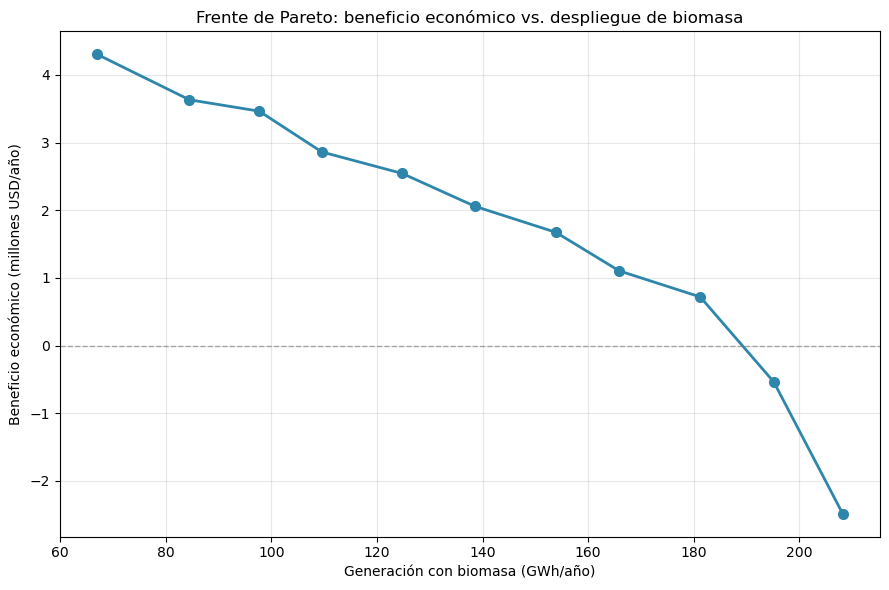

In [66]:
# ==========================================================
# Fase 2 - Multiobjetivo, Paso 2: ε-constraint  [AMPLIADO]
# Igual que antes, pero ahora también guarda el detalle POR PLANTA de
# cada punto del frente, necesario para calcular los indicadores de
# sostenibilidad (LCOE, emisiones, social) en la Sección 19.
# ==========================================================
q = 10  # número de intervalos

frente_pareto = []
detalle_plantas = []          # <-- NUEVO: una fila por (punto, planta)

for n in range(q + 1):
    epsilon = f2_en_f1max + n * (f2_max - f2_en_f1max) / q
    m_eps = construir_modelo_f2(objetivo='economico', restriccion_f2=epsilon)
    res = solver.solve(m_eps, tee=False)

    if res.solver.termination_condition == pyo.TerminationCondition.optimal:
        frente_pareto.append({
            'punto': n,
            'epsilon_GWh': epsilon / 1e6,
            'f1_beneficio_USD': pyo.value(m_eps.f1_economico),
            'f2_generacion_GWh': pyo.value(m_eps.f2_generacion) / 1e6,
            'factor_util_promedio': sum(pyo.value(m_eps.factor_utilizacion[p]) for p in plantas) / len(plantas),
            'factor_util_biogas_promedio': sum(pyo.value(m_eps.factor_util_biogas[p]) for p in plantas) / len(plantas),
            'capacidad_turbina_total_MW': sum(pyo.value(m_eps.capacidad_turbina_kW[p]) for p in plantas) / 1000,
            'capacidad_biogas_total_MW': sum(pyo.value(m_eps.capacidad_biogas_kW[p]) for p in plantas) / 1000,
        })

      # --- NUEVO: detalle por planta de este punto del frente ---
        for p in plantas:
            h = pyo.value(m_eps.horas[p])
            pot_turb = pyo.value(m_eps.potencia_turbina_kW[p])
            pot_bio  = pyo.value(m_eps.potencia_biogas_kW[p])
            autoc    = pyo.value(m_eps.autoconsumo_kW[p])
            exc_perm = pyo.value(m_eps.excedente_permuta_kW[p])
            exc_bols = pyo.value(m_eps.excedente_bolsa_kW[p])
            detalle_plantas.append({
                'punto': n,
                'planta': p,
                'horas': h,
                'cap_turbina_kW': pyo.value(m_eps.capacidad_turbina_kW[p]),
                'cap_biogas_kW': pyo.value(m_eps.capacidad_biogas_kW[p]),
                'factor_utilizacion': pyo.value(m_eps.factor_utilizacion[p]),   # NUEVO
                'factor_util_biogas': pyo.value(m_eps.factor_util_biogas[p]),  # NUEVO
                'generacion_kWh': (FACTOR_NETO_TURBINA*pot_turb + FACTOR_NETO_BIOGAS*pot_bio) * h,
                'autoconsumo_kWh': autoc * h,
                'excedente_kWh': (exc_perm + exc_bols) * h,
                'excedente_permuta_kWh': exc_perm * h,
                'excedente_bolsa_kWh': exc_bols * h,
            })

df_pareto = pd.DataFrame(frente_pareto)
df_pareto_plantas = pd.DataFrame(detalle_plantas)   # <-- NUEVO

print(df_pareto.to_string(index=False))
df_pareto.to_csv('frente_pareto_economico_generacion.csv', index=False)
df_pareto_plantas.to_csv('frente_pareto_detalle_plantas_esc1.csv', index=False)

# --- Gráfico del frente de Pareto (sin cambios) ---
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(df_pareto['f2_generacion_GWh'], df_pareto['f1_beneficio_USD']/1e6, 'o-',
        color='#2E86AB', linewidth=2, markersize=7)
ax.axhline(0, color='#888780', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Generación con biomasa (GWh/año)')
ax.set_ylabel('Beneficio económico (millones USD/año)')
ax.set_title('Frente de Pareto: beneficio económico vs. despliegue de biomasa')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('frente_pareto.png', dpi=150)
plt.show()

In [67]:
# Verificación rápida: confirmar que todos los diccionarios de parámetros usan el mismo formato
print(list(potencia_ideal_biogas_esc1_dict.keys())[:2])
print(list(consumo_medido_dict.keys())[:2])
print(list(horas_operacion_anual.keys())[:2])
print(list(costo_oport_dict.keys())[:2])
print(list(PRECIO_TRAMO_12_dict.keys())[:2])

['Planta A', 'Planta B']
['Planta A', 'Planta B']
['Planta A', 'Planta B']
['Planta A', 'Planta B']
['Planta A', 'Planta B']


In [68]:
f1_punto6 = df_pareto.loc[df_pareto['punto']==6, 'f1_beneficio_USD'].values[0]
m_test6 = construir_modelo_f2(objetivo='generacion', restriccion_f1=f1_punto6 - abs(f1_punto6)*1e-6)
solver.solve(m_test6)
f2_minimo_punto6 = pyo.value(m_test6.f2_generacion) / 1e6
print(f"f2 reportado en punto 6: {df_pareto.loc[df_pareto['punto']==6, 'f2_generacion_GWh'].values[0]:.3f} GWh")
print(f"f2 mínimo posible con el mismo f1: {f2_minimo_punto6:.3f} GWh")

f2 reportado en punto 6: 153.903 GWh
f2 mínimo posible con el mismo f1: 153.903 GWh


### 16.4 Diagnóstico — elección del solver (turbina vs. biogás)

In [69]:
def reporte_eleccion_esc1(m, etiqueta):
    print(f"--- {etiqueta} ---")
    for p in plantas:
        tam_turb = [k for k in CATALOGO_TURBINA_ESC1 if pyo.value(m.z[p, k]) > 0.5][0]
        n_unid = pyo.value(m.n_unidades_biogas[p])
        fu_turb = pyo.value(m.factor_utilizacion[p])
        fu_bio = pyo.value(m.factor_util_biogas[p])
        print(f"{p}: turbina={tam_turb:,} kW (FU={fu_turb:.3f}) | "
              f"biogás={n_unid:.0f} unidades (FU={fu_bio:.3f})")
    print()

reporte_eleccion_esc1(m1, "Óptimo económico (f1 max)")
reporte_eleccion_esc1(m2, "Óptimo generación (f2 max)")

--- Óptimo económico (f1 max) ---
Planta A: turbina=300 kW (FU=0.040) | biogás=2 unidades (FU=1.000)
Planta B: turbina=300 kW (FU=0.034) | biogás=4 unidades (FU=1.000)
Planta C: turbina=300 kW (FU=0.044) | biogás=3 unidades (FU=1.000)
Planta D: turbina=300 kW (FU=0.058) | biogás=3 unidades (FU=1.000)
Planta E: turbina=300 kW (FU=0.042) | biogás=3 unidades (FU=1.000)
Planta F: turbina=300 kW (FU=0.061) | biogás=2 unidades (FU=1.000)

--- Óptimo generación (f2 max) ---
Planta A: turbina=10,000 kW (FU=1.000) | biogás=2 unidades (FU=1.000)
Planta B: turbina=10,000 kW (FU=1.000) | biogás=4 unidades (FU=1.000)
Planta C: turbina=10,000 kW (FU=1.000) | biogás=3 unidades (FU=1.000)
Planta D: turbina=10,000 kW (FU=1.000) | biogás=3 unidades (FU=1.000)
Planta E: turbina=10,000 kW (FU=1.000) | biogás=3 unidades (FU=1.000)
Planta F: turbina=10,000 kW (FU=1.000) | biogás=2 unidades (FU=1.000)



### 16.5 CAPEX fijo y beneficio neto total

CAPEX fijo anualizado TOTAL Esc.1 (6 plantas): $3,335,578 USD/año

 f2_generacion_GWh  f1_beneficio_USD  f1_beneficio_neto_total_USD
         66.963425      4.304222e+06                 9.686446e+05
         84.460126      3.631718e+06                 2.961407e+05
         97.681023      3.463631e+06                 1.280531e+05
        109.534547      2.861383e+06                -4.741946e+05
        124.776866      2.542890e+06                -7.926877e+05
        138.537111      2.058086e+06                -1.277492e+06
        153.902789      1.672393e+06                -1.663185e+06
        165.858799      1.104066e+06                -2.231512e+06
        181.224477      7.183732e+05                -2.617204e+06
        195.147672     -5.369801e+05                -3.872558e+06
        208.216707     -2.486229e+06                -5.821806e+06


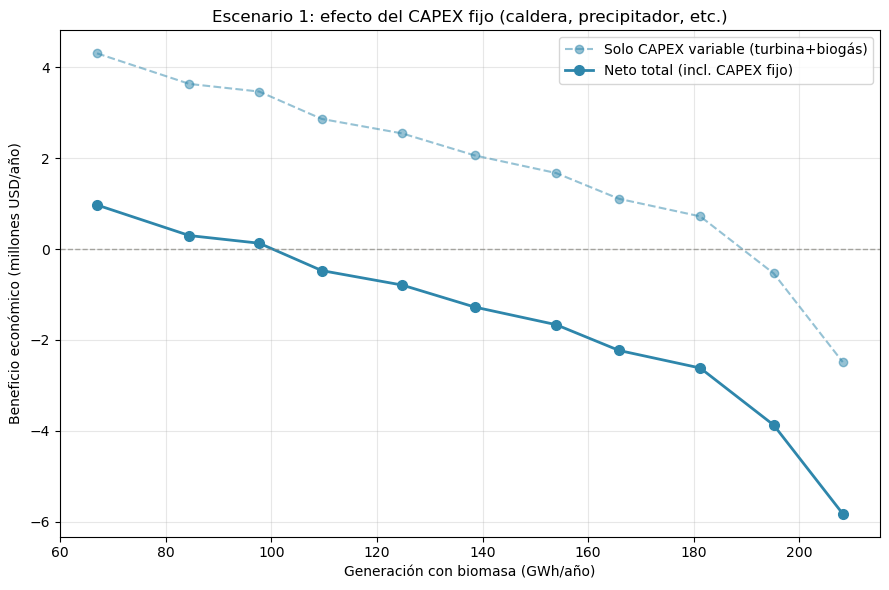

In [70]:

# ADVERTENCIA (Sec. 16.5): df_pareto['f1_beneficio_neto_total_USD'] usa una convencion
# DISTINTA (sin O&M del CAPEX fijo) a la de df_sost/df_sost_e2['beneficio_neto_total_USD']
# (con O&M, convencion §19b, la correcta para reportar en el articulo).
# Para cualquier analisis o cifra publicable, usar SIEMPRE df_sost / df_sost_e2 /
# costo_oportunidad() — nunca df_pareto directamente. Verificado en sesion de hoy:
# df_sost y df_sost_e2 ya reproducen exacto la tabla RESULTADOS DEFINITIVOS.
# Reutiliza capex_incremental_esc1(planta) (Sección 15), excluyendo turbina 
# y generador de biogás (ambos ya están modelados como variables en el 
# solver de Fase 2 — si no se excluyen, se contarían dos veces).
def capex_fijo_esc1(planta):
    items = capex_incremental_esc1(planta)
    excluir = {'Turbina', 'Generador de biogás'}   # claves de capex_incremental_esc1 (Sección 15.0)
    return sum(v for k, v in items.items() if k not in excluir)

capex_fijo_esc1_dict = {p: capex_fijo_esc1(p) for p in plantas}
capex_fijo_anualizado_total_esc1 = sum(capex_fijo_esc1_dict[p] / PVAF for p in plantas)
print(f"CAPEX fijo anualizado TOTAL Esc.1 (6 plantas): ${capex_fijo_anualizado_total_esc1:,.0f} USD/año\n")

df_pareto['f1_beneficio_neto_total_USD'] = df_pareto['f1_beneficio_USD'] - capex_fijo_anualizado_total_esc1
print(df_pareto[['f2_generacion_GWh', 'f1_beneficio_USD', 'f1_beneficio_neto_total_USD']].to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(df_pareto['f2_generacion_GWh'], df_pareto['f1_beneficio_USD']/1e6,
        'o--', color='#2E86AB', alpha=0.5, linewidth=1.5, markersize=6, label='Solo CAPEX variable (turbina+biogás)')
ax.plot(df_pareto['f2_generacion_GWh'], df_pareto['f1_beneficio_neto_total_USD']/1e6,
        'o-', color='#2E86AB', linewidth=2, markersize=7, label='Neto total (incl. CAPEX fijo)')
ax.axhline(0, color='#888780', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Generación con biomasa (GWh/año)')
ax.set_ylabel('Beneficio económico (millones USD/año)')
ax.set_title('Escenario 1: efecto del CAPEX fijo (caldera, precipitador, etc.)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('escenario1_capex_fijo_efecto.png', dpi=150)
plt.show()


### Sección 16.6

In [71]:
# ==========================================================
# Sección 16.6 - Indicadores de sostenibilidad en cada punto del frente de
# Pareto — ESCENARIO 1 (extracción-condensación + biogás POME).
# [CORREGIDO] (1) LCOE sobre EXCEDENTE EXPORTADO, no generacion total.
# [CORREGIDO] (2) beneficio_neto_total_USD incluye el O&M del CAPEX fijo.
# ==========================================================
def capex_variable_esc1(cap_turbina_kW, cap_biogas_kW):
    capex_t = CAPEX_TURBINA_ESC1.get(int(round(cap_turbina_kW)), 0.0)
    n_unid  = int(round(cap_biogas_kW / TAMANO_UNIDAD_BIOGAS_KW))
    return capex_t + n_unid * CAPEX_UNIDAD_BIOGAS

filas = []
for n in sorted(df_pareto_plantas['punto'].unique()):
    sub = df_pareto_plantas[df_pareto_plantas['punto'] == n]
    generacion_kWh = sub['generacion_kWh'].sum()
    excedente_kWh  = sub['excedente_kWh'].sum()
    capex_variable = sum(capex_variable_esc1(r['cap_turbina_kW'], r['cap_biogas_kW'])
                         for _, r in sub.iterrows())
    capex_fijo  = sum(capex_fijo_esc1_dict[p] for p in plantas)
    capex_total = capex_fijo + capex_variable
    # [CORREGIDO] denominador = excedente exportado, NO generacion total
    lcoe = (capex_total / PVAF + PCT_OPERACION_ANUAL * capex_total) / excedente_kWh
    filas.append({
        'punto': n,
        'generacion_GWh': generacion_kWh / 1e6,
        'excedente_GWh': excedente_kWh / 1e6,
        'capex_total_MUSD': capex_total / 1e6,
        'lcoe_USD_kWh': lcoe,
        'emisiones_evitadas_tCO2': excedente_kWh * FACTOR_RED_NACIONAL / 1000,
        'viviendas_rurales': viviendas_rurales_beneficiadas(excedente_kWh),
    })
df_sost = pd.DataFrame(filas)
df_sost = df_sost.merge(df_pareto[['punto', 'f1_beneficio_USD']], on='punto', how='left')
capex_fijo_total = sum(capex_fijo_esc1_dict[p] for p in plantas)
df_sost['beneficio_neto_total_USD'] = (df_sost['f1_beneficio_USD']
                                        - capex_fijo_anualizado_total_esc1
                                        - capex_fijo_total * PCT_OPERACION_ANUAL)
df_sost['pct_cobertura_rural']       = (df_sost['excedente_GWh'] / DEMANDA_RESIDENCIAL_RURAL_GWh) * 100
df_sost['viviendas_rurales_techo']   = df_sost['viviendas_rurales'].clip(upper=USUARIOS_RURALES)
df_sost['pct_demanda_departamental'] = (df_sost['excedente_GWh'] / DEMANDA_TOTAL_DEPARTAMENTAL_GWh) * 100
n_antes = len(df_sost)
df_sost = df_sost.drop_duplicates(subset='generacion_GWh', keep='first').reset_index(drop=True)
print(f"Indicadores de sostenibilidad — ESCENARIO 1")
print(f"({len(df_sost)} puntos únicos de {n_antes} valores de ε)\n")
print(df_sost[['generacion_GWh', 'excedente_GWh', 'beneficio_neto_total_USD',
               'lcoe_USD_kWh', 'emisiones_evitadas_tCO2',
               'pct_cobertura_rural', 'pct_demanda_departamental']].to_string(index=False))

Indicadores de sostenibilidad — ESCENARIO 1
(11 puntos únicos de 11 valores de ε)

 generacion_GWh  excedente_GWh  beneficio_neto_total_USD  lcoe_USD_kWh  emisiones_evitadas_tCO2  pct_cobertura_rural  pct_demanda_departamental
      66.963425      47.029413              2.587033e+05      0.148799              7684.606165           155.212586                   1.935367
      84.460126      64.526115             -4.138006e+05      0.129561             10543.567184           212.957475                   2.655396
      97.681023      77.747012             -5.818883e+05      0.116394             12703.861748           256.590798                   3.199466
     109.534547      89.600535             -1.184136e+06      0.113142             14640.727452           295.711337                   3.687265
     124.776866     104.842854             -1.502629e+06      0.105416             17131.322387           346.016021                   4.314521
     138.537111     118.603100             -1.987433e

In [72]:
sub0 = df_pareto_plantas[df_pareto_plantas['punto']==0]
capex_var0 = sum(capex_variable_esc1(r['cap_turbina_kW'], r['cap_biogas_kW']) for _, r in sub0.iterrows())
capex_fijo0 = sum(capex_fijo_esc1_dict[p] for p in plantas)
excedente0 = sub0['excedente_kWh'].sum()
print('capex_variable:', capex_var0)
print('capex_fijo:', capex_fijo0)
print('capex_total:', capex_var0+capex_fijo0)
print('excedente_kWh:', excedente0)
print('LCOE recalculado:', ((capex_var0+capex_fijo0)/PVAF + PCT_OPERACION_ANUAL*(capex_var0+capex_fijo0))/excedente0)

capex_variable: 20724686.884915143
capex_fijo: 28397652.60289732
capex_total: 49122339.48781246
excedente_kWh: 47029413.49645411
LCOE recalculado: 0.1487994327616056


## Sección 17 — Fase 2 (superestructura), Escenario 2: turbina contrapresión + biogás POME+EFB pretratado

### 17.1 Parámetros, catálogos y CAPEX fijo

In [73]:
# ==========================================================
# Sección 17 - Fase 2, Escenario 2: catálogo de turbina contrapresión 
# (single unit) + generador de biogás como N unidades modulares de 
# 1,000 kW c/u (estándar de industria: motogeneradores biogás POME 
# se instalan en módulos de ~1 MW).
# ==========================================================
# CATALOGO_TURBINA_CONTRAPRESION, CAPEX_TURBINA_ESC2, CAPEX_UNIDAD_BIOGAS,
# TAMANO_UNIDAD_BIOGAS_KW y N_MAX_UNIDADES_BIOGAS se definen en la Sección 15.0.
# TAMANO_UNIDAD_BIOGAS_KW y N_MAX_UNIDADES_BIOGAS ya se definieron en la
# Sección 16.1 (mismo criterio de módulos de ~1 MW para ambos escenarios).

potencia_ideal_turbina_esc2_dict = {p: potencia_turbina_esc2_kW(p)['potencia_bruta_kW'] for p in plantas}
potencia_ideal_biogas_esc2_dict = {p: biogas_pome_y_efb_esc2(p)['generacion_bruta_kW'] for p in plantas}
consumo_medido_esc2_dict = {p: consumo_electrico_esc2_kW(p) for p in plantas}

def capex_fijo_esc2(planta):
    """CAPEX que NO depende de la capacidad eléctrica elegida por el solver.
    Excluye turbina y generador de biogás (son variables de decisión en Fase 2).
    Se reutiliza capex_incremental_esc2 (Sección 15.0, ya escalado con la regla 0.6)
    para no duplicar la lógica de costos."""
    items = capex_incremental_esc2(planta)
    excluir = {'Turbina', 'Generador de biogás'}
    return sum(v for k, v in items.items() if k not in excluir)

capex_fijo_esc2_dict = {p: capex_fijo_esc2(p) for p in plantas}
capex_fijo_anualizado_total = sum(capex_fijo_esc2_dict[p] / PVAF for p in plantas)

print("CAPEX fijo Escenario 2 (USD, no depende de la capacidad eléctrica elegida):")
for p in plantas:
    print(f"  {p}: ${capex_fijo_esc2_dict[p]:,.0f}")
print(f"\nCAPEX fijo anualizado TOTAL Esc.2 (6 plantas): ${capex_fijo_anualizado_total:,.0f} USD/año")


CAPEX fijo Escenario 2 (USD, no depende de la capacidad eléctrica elegida):
  Planta A: $3,191,371
  Planta B: $3,835,111
  Planta C: $3,189,431
  Planta D: $2,765,635
  Planta E: $3,222,863
  Planta F: $2,469,586

CAPEX fijo anualizado TOTAL Esc.2 (6 plantas): $2,193,441 USD/año


### 17.2 Modelo (turbina contrapresión + N unidades biogás) y payoff table

In [74]:
# ==========================================================
# Sección 17 - Fase 2, Escenario 2: turbina de contrapresión (catálogo)
# + generador de biogás (N unidades de 1,000 kW). Payoff table lexicográfica.
# f1 incluye: CAPEX anualizado + O&M (2.5%) + costo de oportunidad de la
# biomasa quemada (escala con el factor de utilización de la turbina).
# ==========================================================
def construir_modelo_f2_esc2(objetivo='economico', restriccion_f2=None, restriccion_f1=None):
    m = pyo.ConcreteModel()
    m.PLANTAS = pyo.Set(initialize=plantas)
    m.TAM_TURBINA = pyo.Set(initialize=CATALOGO_TURBINA_CONTRAPRESION)

    m.potencia_ideal_turbina = pyo.Param(m.PLANTAS, initialize=potencia_ideal_turbina_esc2_dict)
    m.potencia_ideal_biogas = pyo.Param(m.PLANTAS, initialize=potencia_ideal_biogas_esc2_dict)
    m.consumo_medido_kW = pyo.Param(m.PLANTAS, initialize=consumo_medido_esc2_dict)
    m.horas = pyo.Param(m.PLANTAS, initialize=horas_operacion_anual)
    m.costo_oport = pyo.Param(m.PLANTAS, initialize=costo_oport_dict)
    m.costo_oport_raquis = pyo.Param(m.PLANTAS, initialize=costo_oport_raquis_dict)   # <-- NUEVA
    m.precio_tramo12 = pyo.Param(m.PLANTAS, initialize=PRECIO_TRAMO_12_dict)
    m.precio_bolsa = pyo.Param(initialize=PRECIO_BOLSA_PROMEDIO)
    m.pvaf = pyo.Param(initialize=PVAF)

    m.z_turb = pyo.Var(m.PLANTAS, m.TAM_TURBINA, domain=pyo.Binary)
    m.n_unidades_biogas = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeIntegers, bounds=(0, N_MAX_UNIDADES_BIOGAS))
    m.capacidad_turbina_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.capacidad_biogas_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.factor_util_turbina = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals, bounds=(0, 1))
    m.factor_util_biogas = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals, bounds=(0, 1))
    m.potencia_turbina_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.potencia_biogas_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.autoconsumo_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.excedente_permuta_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)
    m.excedente_bolsa_kW = pyo.Var(m.PLANTAS, domain=pyo.NonNegativeReals)

    m.r_una_turb = pyo.Constraint(m.PLANTAS, rule=lambda m, p: sum(m.z_turb[p, k] for k in m.TAM_TURBINA) == 1)
    m.r_cap_turb = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.capacidad_turbina_kW[p] == sum(k*m.z_turb[p, k] for k in m.TAM_TURBINA))
    m.r_cap_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.capacidad_biogas_kW[p] == m.n_unidades_biogas[p] * TAMANO_UNIDAD_BIOGAS_KW)
    m.r_pot_turb = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_turbina_kW[p] == m.factor_util_turbina[p]*m.potencia_ideal_turbina[p])
    m.r_pot_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_biogas_kW[p] == m.factor_util_biogas[p]*m.potencia_ideal_biogas[p])
    m.r_no_exc_turb = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_turbina_kW[p] <= m.capacidad_turbina_kW[p])
    m.r_no_exc_bio = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.potencia_biogas_kW[p] <= m.capacidad_biogas_kW[p])
    m.r_reparto = pyo.Constraint(m.PLANTAS, rule=lambda m, p:
        FACTOR_NETO_TURBINA*m.potencia_turbina_kW[p] + FACTOR_NETO_BIOGAS*m.potencia_biogas_kW[p]
        == m.autoconsumo_kW[p] + m.excedente_permuta_kW[p] + m.excedente_bolsa_kW[p])
    m.r_tope_auto = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.autoconsumo_kW[p] <= m.consumo_medido_kW[p])
    m.r_tope_permuta = pyo.Constraint(m.PLANTAS, rule=lambda m, p: m.excedente_permuta_kW[p] <= m.consumo_medido_kW[p])

    m.f1_economico = pyo.Expression(expr=(
        sum(m.autoconsumo_kW[p]*m.horas[p]*m.precio_tramo12[p] for p in m.PLANTAS)
        + sum(m.excedente_permuta_kW[p]*m.horas[p]*m.precio_tramo12[p] for p in m.PLANTAS)
        + sum(m.excedente_bolsa_kW[p]*m.horas[p]*m.precio_bolsa for p in m.PLANTAS)
        - sum(sum(CAPEX_TURBINA_ESC2[k]*m.z_turb[p, k] for k in m.TAM_TURBINA)/m.pvaf for p in m.PLANTAS)
        - sum(m.n_unidades_biogas[p]*CAPEX_UNIDAD_BIOGAS/m.pvaf for p in m.PLANTAS)
        - sum(sum(CAPEX_TURBINA_ESC2[k]*m.z_turb[p, k] for k in m.TAM_TURBINA)*PCT_OPERACION_ANUAL for p in m.PLANTAS)
        - sum(m.n_unidades_biogas[p]*CAPEX_UNIDAD_BIOGAS*PCT_OPERACION_ANUAL for p in m.PLANTAS)
        - sum(m.factor_util_turbina[p]*m.costo_oport[p] for p in m.PLANTAS)
        - sum(m.factor_util_biogas[p]*m.costo_oport_raquis[p] for p in m.PLANTAS)))   # <-- NUEVA, nota factor_util_BIOGAS

    m.f2_generacion = pyo.Expression(expr=sum(
        (FACTOR_NETO_TURBINA*m.potencia_turbina_kW[p] + FACTOR_NETO_BIOGAS*m.potencia_biogas_kW[p])*m.horas[p]
        for p in m.PLANTAS))

    if restriccion_f1 is not None:
        m.r_eps_f1 = pyo.Constraint(expr=m.f1_economico >= restriccion_f1)
    if restriccion_f2 is not None:
        m.r_eps_f2 = pyo.Constraint(expr=m.f2_generacion >= restriccion_f2)

    if objetivo == 'economico':
        m.obj = pyo.Objective(expr=m.f1_economico, sense=pyo.maximize)
    else:
        m.obj = pyo.Objective(expr=m.f2_generacion, sense=pyo.maximize)
    return m


# --- Payoff table lexicográfica ---
m1_e2 = construir_modelo_f2_esc2(objetivo='economico'); solver.solve(m1_e2)
f1_max_e2 = pyo.value(m1_e2.f1_economico)
m1b_e2 = construir_modelo_f2_esc2(objetivo='generacion', restriccion_f1=f1_max_e2 - 1.0); solver.solve(m1b_e2)
f2_en_f1max_e2 = pyo.value(m1b_e2.f2_generacion)

m2_e2 = construir_modelo_f2_esc2(objetivo='generacion'); solver.solve(m2_e2)
f2_max_e2 = pyo.value(m2_e2.f2_generacion)
m2b_e2 = construir_modelo_f2_esc2(objetivo='economico', restriccion_f2=f2_max_e2 - 100.0); solver.solve(m2b_e2)
f1_en_f2max_e2 = pyo.value(m2b_e2.f1_economico)

print("=== PAYOFF TABLE Escenario 2 (lexicográfica, biogás por N unidades) ===\n")
print(f"{'':22} {'f1: Beneficio (USD/año)':>26} {'f2: Generación (GWh/año)':>26}")
print(f"{'Óptimo económico':22} {f1_max_e2:>26,.0f} {f2_en_f1max_e2/1e6:>26,.1f}")
print(f"{'Óptimo generación':22} {f1_en_f2max_e2:>26,.0f} {f2_max_e2/1e6:>26,.1f}")
print()
print(f"Rango f1: {f1_max_e2 - f1_en_f2max_e2:,.0f} USD/año")
print(f"Rango f2: {(f2_max_e2 - f2_en_f1max_e2)/1e6:,.1f} GWh/año")

=== PAYOFF TABLE Escenario 2 (lexicográfica, biogás por N unidades) ===

                          f1: Beneficio (USD/año)   f2: Generación (GWh/año)
Óptimo económico                        6,088,222                      136.2
Óptimo generación                       4,975,962                      147.5

Rango f1: 1,112,260 USD/año
Rango f2: 11.4 GWh/año


In [75]:
capex_fijo_total_e2 = sum(capex_fijo_esc2_dict[p] for p in plantas)
print(f"capex_fijo_total_e2: ${capex_fijo_total_e2:,.0f}")

capex_fijo_om_e2 = capex_fijo_anualizado_total + capex_fijo_total_e2 * PCT_OPERACION_ANUAL
print(f"CAPEX fijo + O&M anualizado (Escenario 2): ${capex_fijo_om_e2:,.0f}")
print(f"Beneficio neto, optimo (136.2 GWh): ${5242406 - capex_fijo_om_e2:,.0f}")
print(f"Beneficio neto, despliegue total (147.5 GWh): ${4127248 - capex_fijo_om_e2:,.0f}")

capex_fijo_total_e2: $18,673,996
CAPEX fijo + O&M anualizado (Escenario 2): $2,660,290
Beneficio neto, optimo (136.2 GWh): $2,582,116
Beneficio neto, despliegue total (147.5 GWh): $1,466,958


### 17.3 ε-constraint (q=10), frente de Pareto y comparación en paneles

In [76]:
# ==========================================================
# Fase 2 - Escenario 2, Paso 2: ε-constraint  [AMPLIADO]
# ==========================================================
q = 10
frente_pareto_e2 = []
detalle_plantas_e2 = []
for n in range(q + 1):
    epsilon = f2_en_f1max_e2 + n * (f2_max_e2 - f2_en_f1max_e2) / q
    m_eps = construir_modelo_f2_esc2(objetivo='economico', restriccion_f2=epsilon)
    res = solver.solve(m_eps, tee=False)
    if res.solver.termination_condition == pyo.TerminationCondition.optimal:
        frente_pareto_e2.append({
            'punto': n,
            'epsilon_GWh': epsilon / 1e6,
            'f1_beneficio_USD': pyo.value(m_eps.f1_economico),
            'f2_generacion_GWh': pyo.value(m_eps.f2_generacion) / 1e6,
            'factor_util_promedio': sum(pyo.value(m_eps.factor_util_turbina[p]) for p in plantas) / len(plantas),
            'factor_util_biogas_promedio': sum(pyo.value(m_eps.factor_util_biogas[p]) for p in plantas) / len(plantas),
            'capacidad_turbina_total_MW': sum(pyo.value(m_eps.capacidad_turbina_kW[p]) for p in plantas) / 1000,
            'capacidad_biogas_total_MW': sum(pyo.value(m_eps.capacidad_biogas_kW[p]) for p in plantas) / 1000,
        })
        for p in plantas:
            h = pyo.value(m_eps.horas[p])
            pot_turb = pyo.value(m_eps.potencia_turbina_kW[p])
            pot_bio  = pyo.value(m_eps.potencia_biogas_kW[p])
            exc_perm = pyo.value(m_eps.excedente_permuta_kW[p])
            exc_bols = pyo.value(m_eps.excedente_bolsa_kW[p])
            detalle_plantas_e2.append({
                'punto': n,
                'planta': p,
                'horas': h,
                'cap_turbina_kW': pyo.value(m_eps.capacidad_turbina_kW[p]),
                'cap_biogas_kW': pyo.value(m_eps.capacidad_biogas_kW[p]),
                'factor_util_turbina': pyo.value(m_eps.factor_util_turbina[p]),
                'factor_util_biogas': pyo.value(m_eps.factor_util_biogas[p]),
                'generacion_kWh': (FACTOR_NETO_TURBINA*pot_turb + FACTOR_NETO_BIOGAS*pot_bio) * h,
                'autoconsumo_kWh': pyo.value(m_eps.autoconsumo_kW[p]) * h,
                'excedente_kWh': (exc_perm + exc_bols) * h,
                'excedente_permuta_kWh': exc_perm * h,
                'excedente_bolsa_kWh': exc_bols * h,
            })
df_pareto_e2 = pd.DataFrame(frente_pareto_e2)
df_pareto_plantas_e2 = pd.DataFrame(detalle_plantas_e2)
print(df_pareto_e2.to_string(index=False))
df_pareto_e2.to_csv('frente_pareto_economico_generacion_esc2.csv', index=False)
df_pareto_plantas_e2.to_csv('frente_pareto_detalle_plantas_esc2.csv', index=False)

 punto  epsilon_GWh  f1_beneficio_USD  f2_generacion_GWh  factor_util_promedio  factor_util_biogas_promedio  capacidad_turbina_total_MW  capacidad_biogas_total_MW
     0   136.165461      6.088222e+06         136.165461              0.624844                     0.992342                    4.500004                       29.0
     1   137.302218      6.017237e+06         137.347663              0.658711                     0.992342                    4.750000                       29.0
     2   138.438976      5.944302e+06         138.445212              0.697631                     0.992342                    5.000000                       29.0
     3   139.575733      5.847027e+06         139.758305              0.728828                     0.994125                    5.250000                       30.0
     4   140.712491      5.782044e+06         140.719659              0.742801                     0.994125                    5.500000                       30.0
     5   141.849248   

In [77]:
print(df_pareto[df_pareto['punto']==df_pareto['punto'].max()][['punto','f1_beneficio_USD','f2_generacion_GWh']])

    punto  f1_beneficio_USD  f2_generacion_GWh
10     10     -2.486229e+06         208.216707


In [78]:
q = 10
frente_pareto_e2 = []
f2_ini_e2 = f2_en_f1max_e2
f2_fin_e2 = f2_max_e2

for n in range(q + 1):
    epsilon = f2_ini_e2 + n * (f2_fin_e2 - f2_ini_e2) / q
    m_eps = construir_modelo_f2_esc2(objetivo='economico', restriccion_f2=epsilon)
    res = solver.solve(m_eps, tee=False)
    if res.solver.termination_condition == pyo.TerminationCondition.optimal:
        frente_pareto_e2.append({
            'punto': n,
            'f1_beneficio_USD': pyo.value(m_eps.f1_economico),
            'f2_generacion_GWh': pyo.value(m_eps.f2_generacion) / 1e6,
        })

df_pareto_e2_hoy = pd.DataFrame(frente_pareto_e2)
print(df_pareto_e2_hoy.to_string(index=False))

 punto  f1_beneficio_USD  f2_generacion_GWh
     0      6.088222e+06         136.165461
     1      6.017237e+06         137.347663
     2      5.944302e+06         138.445212
     3      5.847027e+06         139.758305
     4      5.782044e+06         140.719659
     5      5.687071e+06         141.924234
     6      5.615603e+06         143.563959
     7      5.542667e+06         144.661508
     8      5.462544e+06         145.289962
     9      5.251564e+06         146.432574
    10      4.975962e+06         147.533036


In [79]:
print("ESCENARIO 1 - detalle por planta, punto=10 (100%)")
print(df_pareto_plantas[df_pareto_plantas['punto']==10].to_string(index=False))

print("\nESCENARIO 2 - detalle por planta, punto=10 (100%)")
print(df_pareto_plantas_e2[df_pareto_plantas_e2['punto']==10].to_string(index=False))

ESCENARIO 1 - detalle por planta, punto=10 (100%)
 punto   planta  horas  cap_turbina_kW  cap_biogas_kW  factor_utilizacion  factor_util_biogas  generacion_kWh  autoconsumo_kWh  excedente_kWh  excedente_permuta_kWh  excedente_bolsa_kWh
    10 Planta A   5105          8000.0         2000.0                 1.0                 1.0    3.963554e+07     4.516565e+06   3.511898e+07                    0.0         3.511898e+07
    10 Planta B   5155          9000.0         4000.0                 1.0                 1.0    5.269624e+07     4.157053e+06   4.853918e+07                    0.0         4.853918e+07
    10 Planta C   5920          7000.0         3000.0                 1.0                 1.0    4.494042e+07     4.591242e+06   4.034918e+07                    0.0         4.034918e+07
    10 Planta D   5496          6000.0         3000.0                 1.0                 1.0    3.543376e+07     3.050517e+06   3.238325e+07                    0.0         3.238325e+07
    10 Planta E   31

In [80]:
# Diagnostico directo: resolver el punto n=0 y volcar TODAS las variables relevantes por planta
m_test = construir_modelo_f2(objetivo='economico', restriccion_f2=f2_en_f1max)
solver.solve(m_test, tee=False)

print(f"{'Planta':8s} {'horas':>8s} {'consumo_medido_kW':>18s} {'autoconsumo_kW':>15s} "
      f"{'exc_permuta_kW':>15s} {'exc_bolsa_kW':>13s} {'pot_turb_kW':>12s} {'pot_bio_kW':>11s}")
for p in plantas:
    print(f"{p:8s} {pyo.value(m_test.horas[p]):8.1f} {pyo.value(m_test.consumo_medido_kW[p]):18.2f} "
          f"{pyo.value(m_test.autoconsumo_kW[p]):15.2f} {pyo.value(m_test.excedente_permuta_kW[p]):15.2f} "
          f"{pyo.value(m_test.excedente_bolsa_kW[p]):13.2f} {pyo.value(m_test.potencia_turbina_kW[p]):12.2f} "
          f"{pyo.value(m_test.potencia_biogas_kW[p]):11.2f}")

print()
print("Suma autoconsumo_kW * horas (energia anual, GWh):",
      sum(pyo.value(m_test.autoconsumo_kW[p])*pyo.value(m_test.horas[p]) for p in plantas)/1e6)
print("Suma consumo_medido_kW * horas (tope teorico, GWh):",
      sum(pyo.value(m_test.consumo_medido_kW[p])*pyo.value(m_test.horas[p]) for p in plantas)/1e6)

Planta      horas  consumo_medido_kW  autoconsumo_kW  exc_permuta_kW  exc_bolsa_kW  pot_turb_kW  pot_bio_kW
Planta A   5105.0             884.73          884.73            0.00       1114.40       300.00     1866.04
Planta B   5155.0             806.41          806.41            0.00       2512.38       300.00     3265.60
Planta C   5920.0             775.55          775.55            0.00       1626.96       300.04     2293.79
Planta D   5496.0             555.04          555.04            0.00       2008.17       300.00     2464.26
Planta E   3147.0             902.77          902.77            0.00       1635.87       300.00     2438.20
Planta F   1931.0             402.71          402.71            0.00       1332.22       300.00     1585.82

Suma autoconsumo_kW * horas (energia anual, GWh): 19.934011493386663
Suma consumo_medido_kW * horas (tope teorico, GWh): 19.93401149338666


In [81]:
# Beneficio neto por planta, Escenario 1, en el punto de despliegue total (100%)
m_full = construir_modelo_f2(objetivo='economico', restriccion_f2=f2_max)
solver.solve(m_full, tee=False)

filas_planta = []
for p in plantas:
    autoc   = pyo.value(m_full.autoconsumo_kW[p]) * pyo.value(m_full.horas[p])
    permuta = pyo.value(m_full.excedente_permuta_kW[p]) * pyo.value(m_full.horas[p])
    bolsa   = pyo.value(m_full.excedente_bolsa_kW[p]) * pyo.value(m_full.horas[p])
    precio_p = PRECIO_TRAMO_12_dict[p]

    ingreso = autoc*precio_p + permuta*precio_p + bolsa*PRECIO_BOLSA_PROMEDIO

    capex_turb = sum(CAPEX_TURBINA_ESC1[k]*pyo.value(m_full.z[p, k]) for k in CATALOGO_TURBINA_ESC1)
    n_unid = pyo.value(m_full.n_unidades_biogas[p])
    capex_bio = n_unid * CAPEX_UNIDAD_BIOGAS
    capex_variable = capex_turb + capex_bio

    capex_anual = capex_variable / PVAF
    om_variable = capex_variable * PCT_OPERACION_ANUAL
    om_fijo = capex_fijo_esc1_dict[p] * PCT_OPERACION_ANUAL
    capex_fijo_anual_p = capex_fijo_esc1_dict[p] / PVAF  # ajusta si tu PVAF fijo es distinto

    costo_oport = pyo.value(m_full.factor_utilizacion[p]) * costo_oport_dict[p]

    beneficio_neto = ingreso - capex_anual - om_variable - capex_fijo_anual_p - om_fijo - costo_oport

    filas_planta.append({
        'planta': p,
        'ingreso_USD': ingreso,
        'capex_anual_variable_USD': capex_anual,
        'capex_anual_fijo_USD': capex_fijo_anual_p,
        'om_USD': om_variable + om_fijo,
        'costo_oportunidad_USD': costo_oport,
        'beneficio_neto_USD': beneficio_neto,
    })

df_beneficio_planta_esc1 = pd.DataFrame(filas_planta)
print("=== ESCENARIO 1, beneficio neto por planta, despliegue total ===")
print(df_beneficio_planta_esc1.to_string(index=False))
print(f"\nSuma: ${df_beneficio_planta_esc1['beneficio_neto_USD'].sum():,.0f}  (debe ≈ -3,576,673)")

=== ESCENARIO 1, beneficio neto por planta, despliegue total ===
  planta  ingreso_USD  capex_anual_variable_USD  capex_anual_fijo_USD        om_USD  costo_oportunidad_USD  beneficio_neto_USD
Planta A 2.984204e+06              2.232435e+06         568066.816598 596056.304961             297723.600       -7.100779e+05
Planta B 4.466949e+06              2.464412e+06         681720.837605 669620.043252             342136.000        3.090600e+05
Planta C 4.017415e+06              2.103201e+06         569028.460864 568754.918064             308313.600        4.681164e+05
Planta D 2.743271e+06              1.927195e+06         499009.516637 516391.116590             251152.768       -4.504769e+05
Planta E 2.282817e+06              2.269393e+06         572644.030397 604896.538043             154045.680       -1.318162e+06
Planta F 8.854235e+05              1.702026e+06         445107.957057 456994.145206              82485.920       -1.801191e+06

Suma: $-3,502,732  (debe ≈ -3,576,673)


### 17.4 Indicadores de sostenibilidad

In [82]:
# ==========================================================
# Sección 17.4 - Indicadores de sostenibilidad — ESCENARIO 2
# [CORREGIDO] (1) LCOE sobre EXCEDENTE EXPORTADO. (2) O&M incluido.
# ==========================================================
def capex_variable_esc2(cap_turbina_kW, cap_biogas_kW):
    capex_t = CAPEX_TURBINA_ESC2.get(int(round(cap_turbina_kW)), 0.0)
    n_unid  = int(round(cap_biogas_kW / TAMANO_UNIDAD_BIOGAS_KW))
    return capex_t + n_unid * CAPEX_UNIDAD_BIOGAS

filas = []
for n in sorted(df_pareto_plantas_e2['punto'].unique()):
    sub = df_pareto_plantas_e2[df_pareto_plantas_e2['punto'] == n]
    generacion_kWh = sub['generacion_kWh'].sum()
    excedente_kWh  = sub['excedente_kWh'].sum()
    capex_variable = sum(capex_variable_esc2(r['cap_turbina_kW'], r['cap_biogas_kW'])
                         for _, r in sub.iterrows())
    capex_fijo  = sum(capex_fijo_esc2_dict[p] for p in plantas)
    capex_total = capex_fijo + capex_variable
    lcoe = (capex_total / PVAF + PCT_OPERACION_ANUAL * capex_total) / excedente_kWh
    filas.append({
        'punto': n,
        'generacion_GWh': generacion_kWh / 1e6,
        'excedente_GWh': excedente_kWh / 1e6,
        'capex_total_MUSD': capex_total / 1e6,
        'lcoe_USD_kWh': lcoe,
        'emisiones_evitadas_tCO2': excedente_kWh * FACTOR_RED_NACIONAL / 1000,
        'viviendas_rurales': viviendas_rurales_beneficiadas(excedente_kWh),
    })
df_sost_e2 = pd.DataFrame(filas)
df_sost_e2 = df_sost_e2.merge(df_pareto_e2[['punto', 'f1_beneficio_USD']], on='punto', how='left')
capex_fijo_total_e2 = sum(capex_fijo_esc2_dict[p] for p in plantas)
df_sost_e2['beneficio_neto_total_USD'] = (df_sost_e2['f1_beneficio_USD']
                                           - capex_fijo_anualizado_total
                                           - capex_fijo_total_e2 * PCT_OPERACION_ANUAL)
df_sost_e2['pct_cobertura_rural']       = (df_sost_e2['excedente_GWh'] / DEMANDA_RESIDENCIAL_RURAL_GWh) * 100
df_sost_e2['viviendas_rurales_techo']   = df_sost_e2['viviendas_rurales'].clip(upper=USUARIOS_RURALES)
df_sost_e2['pct_demanda_departamental'] = (df_sost_e2['excedente_GWh'] / DEMANDA_TOTAL_DEPARTAMENTAL_GWh) * 100
n_antes = len(df_sost_e2)
df_sost_e2 = df_sost_e2.drop_duplicates(subset='generacion_GWh', keep='first').reset_index(drop=True)
print(f"Indicadores de sostenibilidad — ESCENARIO 2")
print(f"({len(df_sost_e2)} puntos únicos de {n_antes} valores de ε)\n")
print(df_sost_e2[['generacion_GWh', 'excedente_GWh', 'beneficio_neto_total_USD',
                  'lcoe_USD_kWh', 'emisiones_evitadas_tCO2',
                  'pct_cobertura_rural', 'pct_demanda_departamental']].to_string(index=False))

Indicadores de sostenibilidad — ESCENARIO 2
(11 puntos únicos de 11 valores de ε)

 generacion_GWh  excedente_GWh  beneficio_neto_total_USD  lcoe_USD_kWh  emisiones_evitadas_tCO2  pct_cobertura_rural  pct_demanda_departamental
     136.165461     119.372801              3.427932e+06      0.057571             19505.515677           393.969640                   4.912461
     137.347663     120.555003              3.356946e+06      0.057765             19698.687527           397.871298                   4.961111
     138.445212     121.652552              3.284011e+06      0.057995             19878.026944           401.493570                   5.006278
     139.758305     122.965645              3.186737e+06      0.058413             20092.586449           405.827212                   5.060315
     140.719659     123.926999              3.121754e+06      0.058626             20249.671594           408.999996                   5.099876
     141.924234     125.131574              3.026780e

### 17.4 Diagnóstico — elección del solver

In [83]:
# ==========================================================
# Sección 17 - Bloque 4: diagnóstico — ¿cuántas unidades de biogás 
# elige el solver? ¿alguna planta necesita fracción de unidad 
# (sobre-dimensionamiento por indivisibilidad)?
# ==========================================================
def reporte_eleccion(m, etiqueta):
    print(f"--- {etiqueta} ---")
    for p in plantas:
        tam_turb = [k for k in CATALOGO_TURBINA_CONTRAPRESION if pyo.value(m.z_turb[p, k]) > 0.5][0]
        n_unid = pyo.value(m.n_unidades_biogas[p])
        cap_bio = n_unid * TAMANO_UNIDAD_BIOGAS_KW
        fu_turb = pyo.value(m.factor_util_turbina[p])
        fu_bio = pyo.value(m.factor_util_biogas[p])
        print(f"{p}: turbina={tam_turb:,} kW (FU={fu_turb:.3f}) | "
              f"biogás={n_unid:.0f} unidades ({cap_bio:,.0f} kW, FU={fu_bio:.3f})")
    print()

reporte_eleccion(m1_e2, "Óptimo económico (f1 max)")
reporte_eleccion(m2_e2, "Óptimo generación (f2 max)")

--- Óptimo económico (f1 max) ---
Planta A: turbina=750 kW (FU=0.559) | biogás=5 unidades (5,000 kW, FU=1.000)
Planta B: turbina=750 kW (FU=0.476) | biogás=7 unidades (7,000 kW, FU=1.000)
Planta C: turbina=750 kW (FU=0.610) | biogás=5 unidades (5,000 kW, FU=1.000)
Planta D: turbina=750 kW (FU=0.701) | biogás=4 unidades (4,000 kW, FU=0.989)
Planta E: turbina=750 kW (FU=0.640) | biogás=5 unidades (5,000 kW, FU=0.996)
Planta F: turbina=750 kW (FU=0.764) | biogás=3 unidades (3,000 kW, FU=0.969)

--- Óptimo generación (f2 max) ---
Planta A: turbina=1,750 kW (FU=1.000) | biogás=5 unidades (5,000 kW, FU=1.000)
Planta B: turbina=1,750 kW (FU=1.000) | biogás=7 unidades (7,000 kW, FU=1.000)
Planta C: turbina=1,750 kW (FU=1.000) | biogás=5 unidades (5,000 kW, FU=1.000)
Planta D: turbina=1,750 kW (FU=1.000) | biogás=5 unidades (5,000 kW, FU=1.000)
Planta E: turbina=1,750 kW (FU=1.000) | biogás=6 unidades (6,000 kW, FU=1.000)
Planta F: turbina=1,750 kW (FU=1.000) | biogás=4 unidades (4,000 kW, FU=1

### 17.5 Verificación — consistencia FU_biogás vs. ideal/capacidad

In [84]:
print(f"{'Planta':10} {'ideal_biogas_kW':>16} {'n_unidades':>12} {'capacidad_kW':>14} {'potencia_kW':>14} {'FU_reportado':>14}")
for p in plantas:
    ideal = potencia_ideal_biogas_esc2_dict[p]
    n_unid = pyo.value(m1_e2.n_unidades_biogas[p])
    cap = n_unid * TAMANO_UNIDAD_BIOGAS_KW
    pot = pyo.value(m1_e2.potencia_biogas_kW[p])
    fu = pyo.value(m1_e2.factor_util_biogas[p])
    print(f"{p:10} {ideal:>16,.1f} {n_unid:>12.0f} {cap:>14,.0f} {pot:>14,.1f} {fu:>14.3f}")

Planta      ideal_biogas_kW   n_unidades   capacidad_kW    potencia_kW   FU_reportado
Planta A            4,444.6            5          5,000        4,444.6          1.000
Planta B            6,449.0            7          7,000        6,449.0          1.000
Planta C            4,723.8            5          5,000        4,723.8          1.000
Planta D            4,043.2            4          4,000        4,000.0          0.989
Planta E            5,021.0            5          5,000        5,000.0          0.996
Planta F            3,096.2            3          3,000        3,000.0          0.969


### 17.6 CAPEX fijo y beneficio neto total

CAPEX fijo anualizado TOTAL (6 plantas): $2,193,441 USD/año

 f2_generacion_GWh  f1_beneficio_USD  f1_beneficio_neto_total_USD
        136.165461      6.088222e+06                 3.894782e+06
        137.347663      6.017237e+06                 3.823796e+06
        138.445212      5.944302e+06                 3.750861e+06
        139.758305      5.847027e+06                 3.653587e+06
        140.719659      5.782044e+06                 3.588604e+06
        141.924234      5.687071e+06                 3.493630e+06
        143.563959      5.615603e+06                 3.422162e+06
        144.661508      5.542667e+06                 3.349227e+06
        145.289962      5.462544e+06                 3.269104e+06
        146.432574      5.251564e+06                 3.058123e+06
        147.533036      4.975962e+06                 2.782522e+06


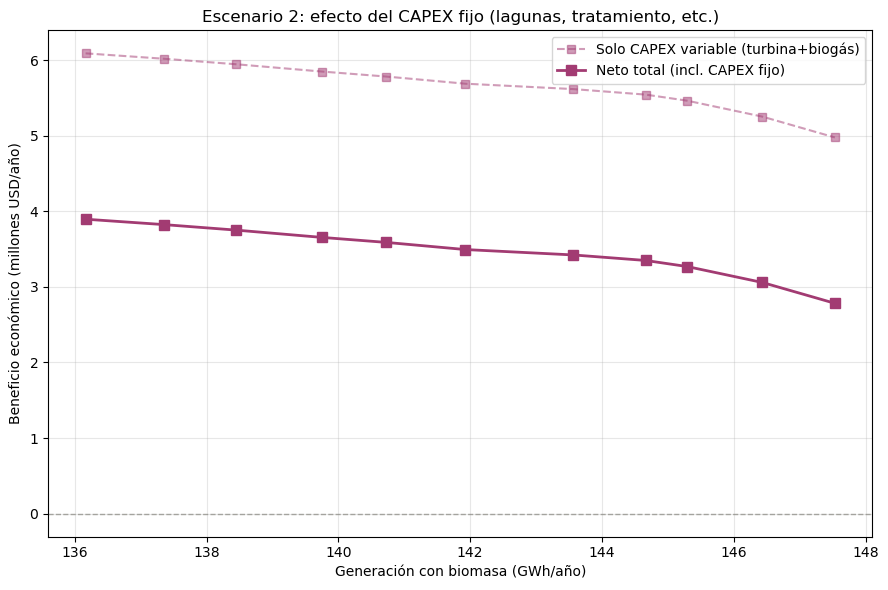

In [85]:
# ==========================================================
# Sección 17 - Bloque 5: beneficio NETO TOTAL (incluye CAPEX fijo 
# anualizado) para comparación justa con Escenario 1
# ==========================================================
capex_fijo_anualizado_total = sum(capex_fijo_esc2_dict[p] / PVAF for p in plantas)
print(f"CAPEX fijo anualizado TOTAL (6 plantas): ${capex_fijo_anualizado_total:,.0f} USD/año\n")

df_pareto_e2['f1_beneficio_neto_total_USD'] = df_pareto_e2['f1_beneficio_USD'] - capex_fijo_anualizado_total
print(df_pareto_e2[['f2_generacion_GWh', 'f1_beneficio_USD', 'f1_beneficio_neto_total_USD']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(df_pareto_e2['f2_generacion_GWh'], df_pareto_e2['f1_beneficio_USD']/1e6,
        's--', color='#A23B72', alpha=0.5, linewidth=1.5, markersize=6, label='Solo CAPEX variable (turbina+biogás)')
ax.plot(df_pareto_e2['f2_generacion_GWh'], df_pareto_e2['f1_beneficio_neto_total_USD']/1e6,
        's-', color='#A23B72', linewidth=2, markersize=7, label='Neto total (incl. CAPEX fijo)')
ax.axhline(0, color='#888780', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Generación con biomasa (GWh/año)')
ax.set_ylabel('Beneficio económico (millones USD/año)')
ax.set_title('Escenario 2: efecto del CAPEX fijo (lagunas, tratamiento, etc.)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('escenario2_capex_fijo_efecto.png', dpi=150)
plt.show()

## Sección 18 — Comparación final: beneficio neto total, Escenario 1 vs. Escenario 2

*Panel para la Discusión del artículo — usa el beneficio NETO TOTAL (incluyendo CAPEX fijo) de ambos escenarios, calculado en 16.5 y 17.6.*

### Puntos notables

In [86]:
# ==========================================================
# Sección 19c - Indicador social con TECHO + indicador no saturante
# Hallazgo: el excedente supera la demanda residencial rural del Magdalena
# (30.3 GWh/año) en TODOS los puntos del frente -> el indicador de viviendas
# se satura. Se reporta con techo (87,516 viviendas = 100% de usuarios
# rurales) y se añade la cobertura sobre la demanda TOTAL departamental,
# que sí discrimina entre puntos del frente.
# ==========================================================
df_sost['pct_cobertura_rural'] = (df_sost['excedente_GWh'] / DEMANDA_RESIDENCIAL_RURAL_GWh) * 100
df_sost['pct_cobertura_rural_techo'] = df_sost['pct_cobertura_rural'].clip(upper=100)
df_sost['viviendas_rurales_techo'] = df_sost['viviendas_rurales'].clip(upper=USUARIOS_RURALES)
df_sost['pct_demanda_departamental'] = (df_sost['excedente_GWh'] / DEMANDA_TOTAL_DEPARTAMENTAL_GWh) * 100

print(df_sost[['generacion_GWh', 'excedente_GWh', 'pct_cobertura_rural',
               'viviendas_rurales_techo', 'pct_demanda_departamental',
               'emisiones_evitadas_tCO2', 'lcoe_USD_kWh']].to_string(index=False))

print(f"\nConsumo por vivienda rural: {CONSUMO_PROMEDIO_VIVIENDA_RURAL_kWh:.0f} kWh/año")
print(f"Demanda rural departamental: {DEMANDA_RESIDENCIAL_RURAL_GWh} GWh/año")
print(f"Cobertura rural en el ÓPTIMO PRIVADO: {df_sost['pct_cobertura_rural'].iloc[0]:.0f}% "
      f"-> el indicador satura desde el primer punto del frente")

df_sost.to_csv('indicadores_sostenibilidad_pareto_esc1.csv', index=False)

 generacion_GWh  excedente_GWh  pct_cobertura_rural  viviendas_rurales_techo  pct_demanda_departamental  emisiones_evitadas_tCO2  lcoe_USD_kWh
      66.963425      47.029413           155.212586                  87516.0                   1.935367              7684.606165      0.148799
      84.460126      64.526115           212.957475                  87516.0                   2.655396             10543.567184      0.129561
      97.681023      77.747012           256.590798                  87516.0                   3.199466             12703.861748      0.116394
     109.534547      89.600535           295.711337                  87516.0                   3.687265             14640.727452      0.113142
     124.776866     104.842854           346.016021                  87516.0                   4.314521             17131.322387      0.105416
     138.537111     118.603100           391.429372                  87516.0                   4.880786             19379.746481      0.101917


=== SCENARIO 1 ===
Private optimum   :   67.0 GWh ( 32.2%) | $     258,703 | LCOE $0.1488 |    7,685 tCO2
Minimum LCOE      :  181.2 GWh ( 87.0%) | $  -3,327,146 | LCOE $0.0940 |   26,355 tCO2
Full deployment   :  208.2 GWh (100.0%) | $  -6,531,748 | LCOE $0.1033 |   30,765 tCO2
>> A breakeven point exists.
>> Cost of deploying the full 100%: $6,790,451/yr (2625% of the optimum) | $294 per additional tCO2 avoided

=== SCENARIO 2 ===
Private optimum   :  136.2 GWh ( 92.3%) | $   3,427,932 | LCOE $0.0576 |   19,506 tCO2
Minimum LCOE      :  136.2 GWh ( 92.3%) | $   3,427,932 | LCOE $0.0576 |   19,506 tCO2
Full deployment   :  147.5 GWh (100.0%) | $   2,315,672 | LCOE $0.0627 |   21,363 tCO2
>> Profitable across the ENTIRE front (minimum $2,315,672/yr) — no subsidy required.
>> Cost of deploying the full 100%: $1,112,260/yr (32% of the optimum) | $599 per additional tCO2 avoided


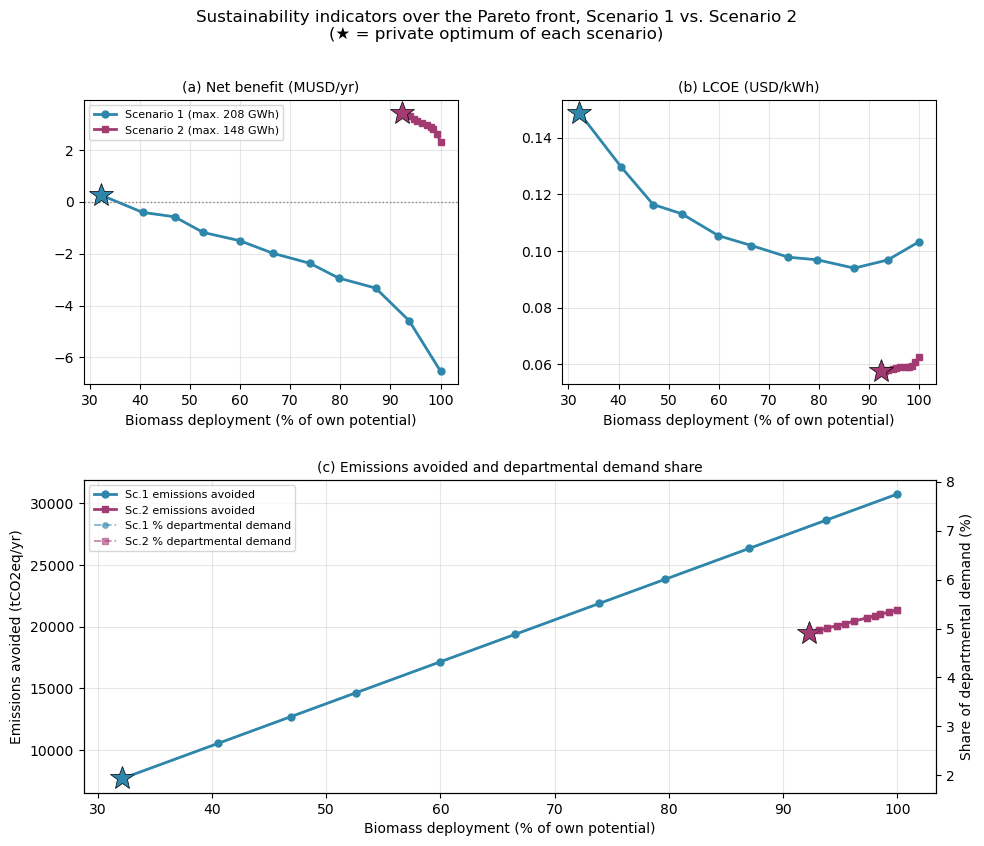

In [87]:
# ==========================================================
# Section 19c - Notable points (Scenario 2) and comparison with Scenario 1
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def puntos_notables(df, nombre):
    b = df['beneficio_neto_total_USD'].values
    pot_max = df['generacion_GWh'].iloc[-1]
    opt  = df.iloc[df['beneficio_neto_total_USD'].idxmax()]
    lcoe = df.iloc[df['lcoe_USD_kWh'].idxmin()]
    tot  = df.iloc[-1]
    print(f"\n=== {nombre} ===")
    for et, f in [("Private optimum", opt), ("Minimum LCOE", lcoe), ("Full deployment", tot)]:
        print(f"{et:18s}: {f['generacion_GWh']:6.1f} GWh ({f['generacion_GWh']/pot_max*100:5.1f}%) | "
              f"${f['beneficio_neto_total_USD']:>12,.0f} | LCOE ${f['lcoe_USD_kWh']:.4f} | "
              f"{f['emisiones_evitadas_tCO2']:>8,.0f} tCO2")
    if np.any(np.sign(b) != np.sign(b[0])):
        print(">> A breakeven point exists.")
    else:
        print(f">> Profitable across the ENTIRE front (minimum ${b.min():,.0f}/yr) — no subsidy required.")
    costo = opt['beneficio_neto_total_USD'] - tot['beneficio_neto_total_USD']
    d_co2 = tot['emisiones_evitadas_tCO2'] - opt['emisiones_evitadas_tCO2']
    print(f">> Cost of deploying the full 100%: ${costo:,.0f}/yr "
          f"({costo/opt['beneficio_neto_total_USD']*100:.0f}% of the optimum) | "
          f"${costo/d_co2:,.0f} per additional tCO2 avoided")
    return opt, tot

opt1, tot1 = puntos_notables(df_sost,    "SCENARIO 1")
opt2, tot2 = puntos_notables(df_sost_e2, "SCENARIO 2")

# --- Comparative figure: x-axis normalized to each scenario's own potential ---
df_sost['pct_pot']    = df_sost['generacion_GWh']    / df_sost['generacion_GWh'].iloc[-1]    * 100
df_sost_e2['pct_pot'] = df_sost_e2['generacion_GWh'] / df_sost_e2['generacion_GWh'].iloc[-1] * 100

i1 = df_sost['beneficio_neto_total_USD'].idxmax()
i2 = df_sost_e2['beneficio_neto_total_USD'].idxmax()

# ---------- Layout: (a) and (b) on top row, (c) spanning the full width below ----------
fig = plt.figure(figsize=(11, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1], hspace=0.32, wspace=0.28)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# ---------- Panel (a): Net benefit ----------
ax = ax_a
ax.plot(df_sost['pct_pot'], df_sost['beneficio_neto_total_USD']/1e6, 'o-', color='#2E86AB',
        linewidth=2, markersize=5, label=f"Scenario 1 (max. {df_sost['generacion_GWh'].iloc[-1]:.0f} GWh)")
ax.plot(df_sost_e2['pct_pot'], df_sost_e2['beneficio_neto_total_USD']/1e6, 's-', color='#A23B72',
        linewidth=2, markersize=5, label=f"Scenario 2 (max. {df_sost_e2['generacion_GWh'].iloc[-1]:.0f} GWh)")
ax.plot(df_sost['pct_pot'][i1], df_sost['beneficio_neto_total_USD'][i1]/1e6, '*', color='#2E86AB',
        markersize=18, markeredgecolor='k', markeredgewidth=0.5, zorder=5)
ax.plot(df_sost_e2['pct_pot'][i2], df_sost_e2['beneficio_neto_total_USD'][i2]/1e6, '*', color='#A23B72',
        markersize=18, markeredgecolor='k', markeredgewidth=0.5, zorder=5)
ax.axhline(0, color='#888780', linestyle=':', linewidth=1)
ax.set_xlabel('Biomass deployment (% of own potential)')
ax.set_title('(a) Net benefit (MUSD/yr)', fontsize=10)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# ---------- Panel (b): LCOE ----------
ax = ax_b
ax.plot(df_sost['pct_pot'], df_sost['lcoe_USD_kWh'], 'o-', color='#2E86AB', linewidth=2, markersize=5)
ax.plot(df_sost_e2['pct_pot'], df_sost_e2['lcoe_USD_kWh'], 's-', color='#A23B72', linewidth=2, markersize=5)
ax.plot(df_sost['pct_pot'][i1], df_sost['lcoe_USD_kWh'][i1], '*', color='#2E86AB',
        markersize=18, markeredgecolor='k', markeredgewidth=0.5, zorder=5)
ax.plot(df_sost_e2['pct_pot'][i2], df_sost_e2['lcoe_USD_kWh'][i2], '*', color='#A23B72',
        markersize=18, markeredgecolor='k', markeredgewidth=0.5, zorder=5)
ax.set_xlabel('Biomass deployment (% of own potential)')
ax.set_title('(b) LCOE (USD/kWh)', fontsize=10)
ax.grid(alpha=0.3)

# ---------- Panel (c): Emissions avoided (left) + % departmental demand (right), unified ----------
ax = ax_c
ax2 = ax.twinx()

l1, = ax.plot(df_sost['pct_pot'], df_sost['emisiones_evitadas_tCO2'], 'o-', color='#2E86AB',
              linewidth=2, markersize=5, label='Sc.1 emissions avoided')
l2, = ax.plot(df_sost_e2['pct_pot'], df_sost_e2['emisiones_evitadas_tCO2'], 's-', color='#A23B72',
              linewidth=2, markersize=5, label='Sc.2 emissions avoided')
l3, = ax2.plot(df_sost['pct_pot'], df_sost['pct_demanda_departamental'], 'o--', color='#2E86AB',
               linewidth=1.4, markersize=4, alpha=0.55, label='Sc.1 % departmental demand')
l4, = ax2.plot(df_sost_e2['pct_pot'], df_sost_e2['pct_demanda_departamental'], 's--', color='#A23B72',
               linewidth=1.4, markersize=4, alpha=0.55, label='Sc.2 % departmental demand')

ax.plot(df_sost['pct_pot'][i1], df_sost['emisiones_evitadas_tCO2'][i1], '*', color='#2E86AB',
        markersize=18, markeredgecolor='k', markeredgewidth=0.5, zorder=5)
ax.plot(df_sost_e2['pct_pot'][i2], df_sost_e2['emisiones_evitadas_tCO2'][i2], '*', color='#A23B72',
        markersize=18, markeredgecolor='k', markeredgewidth=0.5, zorder=5)

ax.set_xlabel('Biomass deployment (% of own potential)')
ax.set_ylabel('Emissions avoided (tCO2eq/yr)')
ax2.set_ylabel('Share of departmental demand (%)')
ax.set_title('(c) Emissions avoided and departmental demand share', fontsize=10)
ax.grid(alpha=0.3)
lines = [l1, l2, l3, l4]
ax.legend(lines, [l.get_label() for l in lines], fontsize=8, loc='upper left')

fig.suptitle('Sustainability indicators over the Pareto front, Scenario 1 vs. Scenario 2\n'
             '(★ = private optimum of each scenario)', fontsize=12)
plt.savefig('sustainability_indicators_comparison_v3.png', dpi=150, bbox_inches='tight')
plt.show()

In [88]:
resultados_precio = []
for precio in np.arange(0.07, 0.26, 0.01):
    PRECIO_BOLSA_PROMEDIO_orig = PRECIO_BOLSA_PROMEDIO
    globals()['PRECIO_BOLSA_PROMEDIO'] = precio
    for esc in [1, 2]:
        constructor = construir_modelo_f2 if esc == 1 else construir_modelo_f2_esc2
        m_p = constructor(objetivo='economico')
        solver.solve(m_p, tee=False)
        gen_p = pyo.value(m_p.f2_generacion)
        f2_max_p = f2_max if esc == 1 else f2_max_e2
        resultados_precio.append({
            'precio_USD_kWh': round(precio, 2),
            'escenario': esc,
            'pct_potencial': gen_p / f2_max_p * 100,
        })
    globals()['PRECIO_BOLSA_PROMEDIO'] = PRECIO_BOLSA_PROMEDIO_orig

df_precio = pd.DataFrame(resultados_precio)
print(df_precio.pivot(index='precio_USD_kWh', columns='escenario', values='pct_potencial').to_string())

escenario               1          2
precio_USD_kWh                      
0.07            32.160366  92.294882
0.08            32.160366  92.294882
0.09            32.160366  92.294882
0.10            64.004892  92.294882
0.11            87.036472  92.294882
0.12            87.036472  92.294882
0.13            88.049001  93.834356
0.14            88.049001  98.053637
0.15            88.049001  98.053637
0.16            96.137965  98.053637
0.17            96.137965  98.053637
0.18            96.137965  98.053637
0.19            96.137965  98.053637
0.20            96.137965  98.479612
0.21            96.137965  98.479612
0.22            96.137965  98.631499
0.23            96.137965  98.631499
0.24            96.137965  98.631499
0.25            96.137965  98.924595


## Sección 19 - Sensibilidad de estacionalidad

In [89]:
for nombre, df, idx_opt in [("Escenario 1", df_sost, i1), ("Escenario 2", df_sost_e2, i2)]:
    print(f"\n=== {nombre} ===")
    print(f"Emisiones evitadas en óptimo económico: {df['emisiones_evitadas_tCO2'][idx_opt]:,.0f} tCO2/año")
    print(f"Emisiones evitadas en despliegue completo: {df['emisiones_evitadas_tCO2'].iloc[-1]:,.0f} tCO2/año")
    print(f"Cobertura rural en óptimo económico: {df['pct_demanda_departamental'][idx_opt]:.1f}% de la demanda departamental")
    print(f"Cobertura rural en despliegue completo: {df['pct_demanda_departamental'].iloc[-1]:.1f}% de la demanda departamental")


=== Escenario 1 ===
Emisiones evitadas en óptimo económico: 7,685 tCO2/año
Emisiones evitadas en despliegue completo: 30,765 tCO2/año
Cobertura rural en óptimo económico: 1.9% de la demanda departamental
Cobertura rural en despliegue completo: 7.7% de la demanda departamental

=== Escenario 2 ===
Emisiones evitadas en óptimo económico: 19,506 tCO2/año
Emisiones evitadas en despliegue completo: 21,363 tCO2/año
Cobertura rural en óptimo económico: 4.9% de la demanda departamental
Cobertura rural en despliegue completo: 5.4% de la demanda departamental


### 19.1 Sensibilidad de estacionalidad

In [90]:
# ==========================================================
# Sección 19 - Sensibilidad de estacionalidad sobre las capacidades 
# elegidas en Fase 2 (óptimo económico, ambos escenarios). 
# Supuesto: el potencial de generación escala linealmente con el 
# Factor_estacionalidad del RFF procesado (Sección 12) — mismo supuesto 
# que sustenta el resto del modelo (energía biomasa ∝ tRFF procesado). 
# No recalcula termodinámica mes a mes; usa horas promedio mensuales 
# (horas_anuales/12), no un patrón de operación mensual real.
# ==========================================================
def perdida_estacional_v2(capacidad_instalada_kW, potencia_ideal_anual_kW, planta, horas_anuales):
    """Aísla la pérdida INCREMENTAL por estacionalidad, restando la línea 
    base sin estacionalidad (factor=1 todo el año) — evita confundir la 
    variabilidad mensual con el hueco estructural ya conocido entre 
    capacidad instalada e ideal anual (ese hueco ya está en el payoff table)."""
    horas_mes_prom = horas_anuales / 12
    df_p = df_rff_mensual[df_rff_mensual['Planta'] == planta]
    perdida_con_estacionalidad_kWh = 0
    for _, fila in df_p.iterrows():
        potencia_ideal_mes = potencia_ideal_anual_kW * fila['Factor_estacionalidad']
        exceso_kW = max(0, potencia_ideal_mes - capacidad_instalada_kW)
        perdida_con_estacionalidad_kWh += exceso_kW * horas_mes_prom

    # Línea base: mismo cálculo pero SIN estacionalidad (factor=1 todo el año)
    exceso_base_kW = max(0, potencia_ideal_anual_kW - capacidad_instalada_kW)
    perdida_base_kWh = exceso_base_kW * horas_anuales

    perdida_incremental_kWh = perdida_con_estacionalidad_kWh - perdida_base_kWh
    return perdida_incremental_kWh / 1e6  # GWh/año (puede ser ~0 si la capacidad ya está saturada todo el año)
    
# --- Escenario 1: capacidad elegida en el óptimo económico (m1) ---
print("=== Escenario 1 — pérdida estacional por capacidad fija (óptimo económico) ===\n")
perdida_total_e1 = 0
for p in plantas:
    tam_turb = [k for k in CATALOGO_TURBINA_ESC1 if pyo.value(m1.z[p, k]) > 0.5][0]
    cap_bio = pyo.value(m1.n_unidades_biogas[p]) * TAMANO_UNIDAD_BIOGAS_KW
    perdida_turb = perdida_estacional_v2(tam_turb, potencia_ideal_dict[p], p, horas_operacion_anual[p])
    perdida_bio = perdida_estacional_v2(cap_bio, potencia_ideal_biogas_esc1_dict[p], p, horas_operacion_anual[p])
    total_p = perdida_turb + perdida_bio
    perdida_total_e1 += total_p
    print(f"{p}: pérdida turbina={perdida_turb:.2f} GWh/año | pérdida biogás={perdida_bio:.2f} GWh/año | total={total_p:.2f} GWh/año")
print(f"\nTOTAL 6 plantas (Esc.1): {perdida_total_e1:.2f} GWh/año perdidos por capacidad fija en meses pico")
print(f"Referencia: generación en óptimo económico Esc.1 = {f2_en_f1max/1e6:.1f} GWh/año "
      f"-> pérdida = {perdida_total_e1/(f2_en_f1max/1e6)*100:.1f}% adicional sobre ese punto\n")

# --- Escenario 2: capacidad elegida en el óptimo económico (m1_e2) ---
print("=== Escenario 2 — pérdida estacional por capacidad fija (óptimo económico) ===\n")
perdida_total_e2 = 0
for p in plantas:
    tam_turb = [k for k in CATALOGO_TURBINA_CONTRAPRESION if pyo.value(m1_e2.z_turb[p, k]) > 0.5][0]
    cap_bio = pyo.value(m1_e2.n_unidades_biogas[p]) * TAMANO_UNIDAD_BIOGAS_KW
    perdida_turb = perdida_estacional_v2(tam_turb, potencia_ideal_turbina_esc2_dict[p], p, horas_operacion_anual[p])
    perdida_bio = perdida_estacional_v2(cap_bio, potencia_ideal_biogas_esc2_dict[p], p, horas_operacion_anual[p])
    total_p = perdida_turb + perdida_bio
    perdida_total_e2 += total_p
    print(f"{p}: pérdida turbina={perdida_turb:.2f} GWh/año | pérdida biogás={perdida_bio:.2f} GWh/año | total={total_p:.2f} GWh/año")
print(f"\nTOTAL 6 plantas (Esc.2): {perdida_total_e2:.2f} GWh/año perdidos por capacidad fija en meses pico")
print(f"Referencia: generación en óptimo económico Esc.2 = {f2_en_f1max_e2/1e6:.1f} GWh/año "
      f"-> pérdida = {perdida_total_e2/(f2_en_f1max_e2/1e6)*100:.1f}% adicional sobre ese punto")

=== Escenario 1 — pérdida estacional por capacidad fija (óptimo económico) ===

Planta A: pérdida turbina=0.00 GWh/año | pérdida biogás=0.63 GWh/año | total=0.63 GWh/año
Planta B: pérdida turbina=0.00 GWh/año | pérdida biogás=0.70 GWh/año | total=0.70 GWh/año
Planta C: pérdida turbina=0.00 GWh/año | pérdida biogás=0.00 GWh/año | total=0.00 GWh/año
Planta D: pérdida turbina=0.00 GWh/año | pérdida biogás=0.00 GWh/año | total=0.00 GWh/año
Planta E: pérdida turbina=0.00 GWh/año | pérdida biogás=0.19 GWh/año | total=0.19 GWh/año
Planta F: pérdida turbina=0.00 GWh/año | pérdida biogás=0.00 GWh/año | total=0.00 GWh/año

TOTAL 6 plantas (Esc.1): 1.52 GWh/año perdidos por capacidad fija en meses pico
Referencia: generación en óptimo económico Esc.1 = 67.0 GWh/año -> pérdida = 2.3% adicional sobre ese punto

=== Escenario 2 — pérdida estacional por capacidad fija (óptimo económico) ===

Planta A: pérdida turbina=0.07 GWh/año | pérdida biogás=1.01 GWh/año | total=1.08 GWh/año
Planta B: pérdida tu

### 19.2 Pérdida estacional INCREMENTAL

In [91]:
# ==========================================================
# Sección 19 (v2, celda única) - Pérdida estacional INCREMENTAL
# ==========================================================
def perdida_estacional_incremental(capacidad_instalada_kW, potencia_ideal_anual_kW, planta, horas_anuales):
    horas_mes_prom = horas_anuales / 12
    df_p = df_rff_mensual[df_rff_mensual['Planta'] == planta]

    perdida_con_estacionalidad_kWh = 0
    for _, fila in df_p.iterrows():
        potencia_ideal_mes = potencia_ideal_anual_kW * fila['Factor_estacionalidad']
        exceso_kW = max(0, potencia_ideal_mes - capacidad_instalada_kW)
        perdida_con_estacionalidad_kWh += exceso_kW * horas_mes_prom

    exceso_base_kW = max(0, potencia_ideal_anual_kW - capacidad_instalada_kW)
    perdida_base_kWh = exceso_base_kW * horas_anuales

    return (perdida_con_estacionalidad_kWh - perdida_base_kWh) / 1e6  # GWh/año

print("=== Escenario 1 (INCREMENTAL) ===\n")
perdida_total_e1_v2 = 0
for p in plantas:
    tam_turb = [k for k in CATALOGO_TURBINA_ESC1 if pyo.value(m1.z[p, k]) > 0.5][0]
    cap_bio = pyo.value(m1.n_unidades_biogas[p]) * TAMANO_UNIDAD_BIOGAS_KW
    pt = perdida_estacional_incremental(tam_turb, potencia_ideal_dict[p], p, horas_operacion_anual[p])
    pb = perdida_estacional_incremental(cap_bio, potencia_ideal_biogas_esc1_dict[p], p, horas_operacion_anual[p])
    perdida_total_e1_v2 += pt + pb
    print(f"{p}: turbina={pt:.2f} | biogás={pb:.2f} | total={pt+pb:.2f} GWh/año")
print(f"\nTOTAL Esc.1 (incremental): {perdida_total_e1_v2:.2f} GWh/año\n")

print("=== Escenario 2 (INCREMENTAL) ===\n")
perdida_total_e2_v2 = 0
for p in plantas:
    tam_turb = [k for k in CATALOGO_TURBINA_CONTRAPRESION if pyo.value(m1_e2.z_turb[p, k]) > 0.5][0]
    cap_bio = pyo.value(m1_e2.n_unidades_biogas[p]) * TAMANO_UNIDAD_BIOGAS_KW
    pt = perdida_estacional_incremental(tam_turb, potencia_ideal_turbina_esc2_dict[p], p, horas_operacion_anual[p])
    pb = perdida_estacional_incremental(cap_bio, potencia_ideal_biogas_esc2_dict[p], p, horas_operacion_anual[p])
    perdida_total_e2_v2 += pt + pb
    print(f"{p}: turbina={pt:.2f} | biogás={pb:.2f} | total={pt+pb:.2f} GWh/año")
print(f"\nTOTAL Esc.2 (incremental): {perdida_total_e2_v2:.2f} GWh/año")

=== Escenario 1 (INCREMENTAL) ===

Planta A: turbina=0.00 | biogás=0.63 | total=0.63 GWh/año
Planta B: turbina=0.00 | biogás=0.70 | total=0.70 GWh/año
Planta C: turbina=0.00 | biogás=0.00 | total=0.00 GWh/año
Planta D: turbina=0.00 | biogás=0.00 | total=0.00 GWh/año
Planta E: turbina=0.00 | biogás=0.19 | total=0.19 GWh/año
Planta F: turbina=0.00 | biogás=0.00 | total=0.00 GWh/año

TOTAL Esc.1 (incremental): 1.52 GWh/año

=== Escenario 2 (INCREMENTAL) ===

Planta A: turbina=0.07 | biogás=1.01 | total=1.08 GWh/año
Planta B: turbina=0.07 | biogás=3.49 | total=3.56 GWh/año
Planta C: turbina=-0.00 | biogás=0.34 | total=0.34 GWh/año
Planta D: turbina=0.00 | biogás=0.91 | total=0.91 GWh/año
Planta E: turbina=0.00 | biogás=1.27 | total=1.27 GWh/año
Planta F: turbina=0.00 | biogás=0.39 | total=0.40 GWh/año

TOTAL Esc.2 (incremental): 7.56 GWh/año


### 19.3 Indicadores de sostenibilidad (Comparativo)

In [92]:
# ==========================================================
# Sección 19 bis - Indicadores de sostenibilidad sobre el frente (Esc. 2)
# CAPEX leído de CATALOGO (regla 0.6), NO reconstruido linealmente.
# ==========================================================
capex_fijo_total_e2 = sum(capex_fijo_esc2_dict[p] for p in plantas)

filas = []
for n in sorted(df_pareto_plantas_e2['punto'].unique()):
    sub = df_pareto_plantas_e2[df_pareto_plantas_e2['punto'] == n]

    generacion_kWh = sub['generacion_kWh'].sum()
    excedente_kWh  = sub['excedente_kWh'].sum()

    capex_turbinas = sum(CAPEX_TURBINA_ESC2[int(row['cap_turbina_kW'])]
                         for _, row in sub.iterrows() if row['cap_turbina_kW'] > 0)
    n_modulos    = sub['cap_biogas_kW'].sum() / TAMANO_UNIDAD_BIOGAS_KW
    capex_biogas = n_modulos * CAPEX_UNIDAD_BIOGAS

    capex_total = capex_fijo_total_e2 + capex_turbinas + capex_biogas
    lcoe = (capex_total / PVAF + PCT_OPERACION_ANUAL * capex_total) / generacion_kWh

    filas.append({
        'punto': n,
        'generacion_GWh': generacion_kWh / 1e6,
        'excedente_GWh': excedente_kWh / 1e6,
        'capex_total_MUSD': capex_total / 1e6,
        'lcoe_USD_kWh': lcoe,
        'emisiones_evitadas_tCO2': excedente_kWh * FACTOR_RED_NACIONAL / 1000,
        'viviendas_rurales': viviendas_rurales_beneficiadas(excedente_kWh),
    })

df_sost_e2 = pd.DataFrame(filas)
df_sost_e2 = df_sost_e2.merge(df_pareto_e2[['punto', 'f1_beneficio_USD']], on='punto', how='left')
df_sost_e2['beneficio_neto_total_USD'] = (
    df_sost_e2['f1_beneficio_USD']
    - capex_fijo_anualizado_total          # CAPEX fijo Esc.2 anualizado (sin O&M)
    - PCT_OPERACION_ANUAL * capex_fijo_total_e2
)

print(df_sost_e2[['generacion_GWh', 'excedente_GWh', 'beneficio_neto_total_USD',
                  'lcoe_USD_kWh', 'emisiones_evitadas_tCO2',
                  'viviendas_rurales']].to_string(index=False))
df_sost_e2.to_csv('indicadores_sostenibilidad_pareto_esc2.csv', index=False)

 generacion_GWh  excedente_GWh  beneficio_neto_total_USD  lcoe_USD_kWh  emisiones_evitadas_tCO2  viviendas_rurales
     136.165461     119.372801              3.427932e+06      0.050471             19505.515677      344786.470256
     137.347663     120.555003              3.356946e+06      0.050702             19698.687527      348201.044965
     138.445212     121.652552              3.284011e+06      0.050961             19878.026944      351371.112633
     139.758305     122.965645              3.186737e+06      0.051394             20092.586449      355163.743166
     140.719659     123.926999              3.121754e+06      0.051630             20249.671594      357940.436353
     141.924234     125.131574              3.026780e+06      0.052045             20446.499118      361419.630059
     143.563959     126.771299              2.955312e+06      0.052039             20714.430278      366155.677046
     144.661508     127.868848              2.882377e+06      0.052276          

## 20 Target Seeking

=== COSTO DE OPORTUNIDAD DEL DESPLIEGUE TOTAL ===

=== ESCENARIO 1 ===
Óptimo privado    :   67.0 GWh ( 32.2%) | $    258,703/año
Despliegue 100%   :  208.2 GWh (100.0%) | $ -6,531,748/año
>> Despliegue total NEGATIVO: el 100% no es rentable por sí solo en las condiciones actuales.
>> Costo de cerrar la brecha: $6,790,451/año (2625% del óptimo)
>> Compra: +141.3 GWh/año y +23,081 tCO2eq/año
>> Costo implícito: $294 por tCO2eq adicional evitada

=== ESCENARIO 2 ===
Óptimo privado    :  136.2 GWh ( 92.3%) | $  3,427,932/año
Despliegue 100%   :  147.5 GWh (100.0%) | $  2,315,672/año
>> Despliegue total POSITIVO: no requiere subsidio, aunque implica un costo de oportunidad frente al óptimo.
>> Costo de cerrar la brecha: $1,112,260/año (32% del óptimo)
>> Compra: +11.4 GWh/año y +1,857 tCO2eq/año
>> Costo implícito: $599 por tCO2eq adicional evitada

COMPARACIÓN
El Esc.2 es más rentable en su óptimo privado (+1225%) y le cuesta mucho menos desplegar el 100% (32% vs. 2625% del óptimo).
PERO 

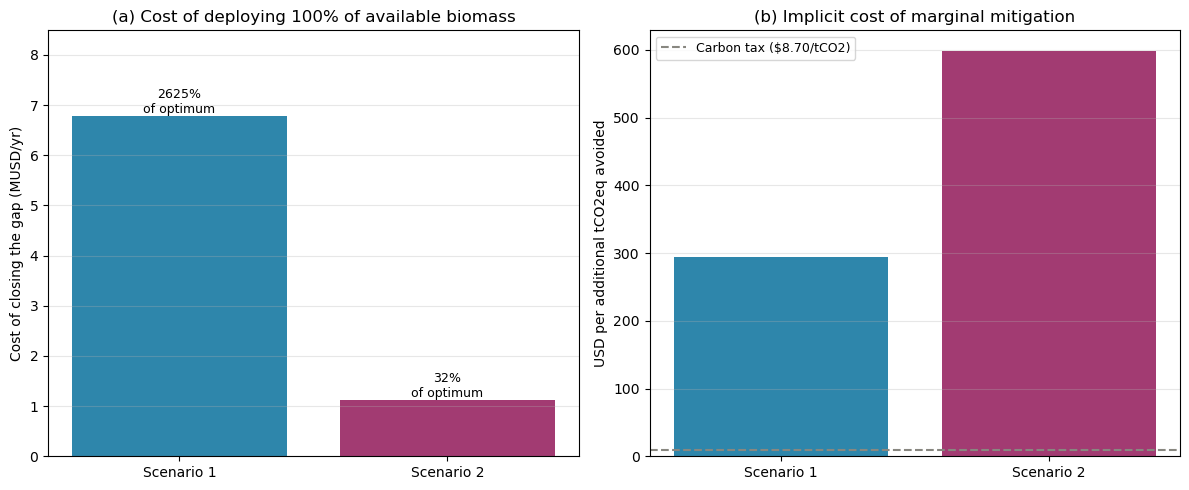

In [93]:
# ==========================================================
# Section 20 - Opportunity cost of full deployment and comparison
# with the carbon price — BOTH SCENARIOS.
#
# Scenario 2 is profitable without support across the full Pareto front.
# Scenario 1 is not: at full deployment its net benefit turns negative
# under current conditions, and requires either a capital incentive or a
# higher feed-in tariff to become worthwhile (see Section 3.7).
# ==========================================================

# Carbon price (Law 1819/2016 art. 222, as amended by Law 2277/2022 art. 48).
# DIAN Resolution 000003 of January 30, 2026, effective February 1, 2026:
# COP 29,070.49/tCO2eq (verified this session; replaces an earlier
# COP 25,000/tCO2 placeholder). A pending tax reform bill proposes
# COP 42,609/tCO2, not yet in force.
PRECIO_CARBONO_USD_tCO2 = 29_070.49 / 3_339.65   # ~USD 8.70/tCO2

def costo_oportunidad(df, nombre):
    opt = df.iloc[df['beneficio_neto_total_USD'].idxmax()]
    tot = df.iloc[-1]

    co    = opt['beneficio_neto_total_USD'] - tot['beneficio_neto_total_USD']
    d_co2 = tot['emisiones_evitadas_tCO2']  - opt['emisiones_evitadas_tCO2']
    d_gwh = tot['generacion_GWh']           - opt['generacion_GWh']
    implicito = co / d_co2

    print(f"\n=== {nombre} ===")
    print(f"Óptimo privado    : {opt['generacion_GWh']:6.1f} GWh "
          f"({opt['generacion_GWh']/tot['generacion_GWh']*100:5.1f}%) | ${opt['beneficio_neto_total_USD']:>11,.0f}/año")
    print(f"Despliegue 100%   : {tot['generacion_GWh']:6.1f} GWh (100.0%) | ${tot['beneficio_neto_total_USD']:>11,.0f}/año")
    if tot['beneficio_neto_total_USD'] >= 0:
        print(f">> Despliegue total POSITIVO: no requiere subsidio, aunque implica un costo de oportunidad frente al óptimo.")
    else:
        print(f">> Despliegue total NEGATIVO: el 100% no es rentable por sí solo en las condiciones actuales.")
    print(f">> Costo de cerrar la brecha: ${co:,.0f}/año ({co/opt['beneficio_neto_total_USD']*100:.0f}% del óptimo)")
    print(f">> Compra: +{d_gwh:.1f} GWh/año y +{d_co2:,.0f} tCO2eq/año")
    print(f">> Costo implícito: ${implicito:,.0f} por tCO2eq adicional evitada")

    return {'escenario': nombre,
            'gen_optimo_GWh': opt['generacion_GWh'],
            'pct_optimo': opt['generacion_GWh']/tot['generacion_GWh']*100,
            'beneficio_optimo_USD': opt['beneficio_neto_total_USD'],
            'gen_total_GWh': tot['generacion_GWh'],
            'beneficio_total_USD': tot['beneficio_neto_total_USD'],
            'costo_oportunidad_USD': co,
            'pct_del_optimo': co/opt['beneficio_neto_total_USD']*100,
            'delta_GWh': d_gwh,
            'delta_tCO2': d_co2,
            'tCO2_totales_100pct': tot['emisiones_evitadas_tCO2'],
            'costo_implicito_USD_tCO2': implicito}

print("=== COSTO DE OPORTUNIDAD DEL DESPLIEGUE TOTAL ===")
r1 = costo_oportunidad(df_sost,    "ESCENARIO 1")
r2 = costo_oportunidad(df_sost_e2, "ESCENARIO 2")

df_co = pd.DataFrame([r1, r2])
df_co.to_csv('costo_oportunidad_despliegue.csv', index=False)

print("\n" + "="*70)
print("COMPARACIÓN")
print("="*70)
print(f"El Esc.2 es más rentable en su óptimo privado "
      f"(+{(r2['beneficio_optimo_USD']/r1['beneficio_optimo_USD']-1)*100:.0f}%) y le cuesta "
      f"mucho menos desplegar el 100% ({r2['pct_del_optimo']:.0f}% vs. {r1['pct_del_optimo']:.0f}% del óptimo).")
print(f"PERO compra CO2 evitado MÁS CARO: ${r2['costo_implicito_USD_tCO2']:,.0f} vs. "
      f"${r1['costo_implicito_USD_tCO2']:,.0f} por tCO2 "
      f"({r2['costo_implicito_USD_tCO2']/r1['costo_implicito_USD_tCO2']:.1f}x), porque ya opera al "
      f"{r2['pct_optimo']:.0f}% en su óptimo privado y le queda poco margen de expansión.")
print(f"Y en términos ABSOLUTOS el Esc.1 evita mucho más: "
      f"{r1['tCO2_totales_100pct']:,.0f} vs. {r2['tCO2_totales_100pct']:,.0f} tCO2eq/año "
      f"(+{(r1['tCO2_totales_100pct']/r2['tCO2_totales_100pct']-1)*100:.0f}%).")

print(f"\n--- Impuesto al carbono (Ley 1819/2016 art. 222, mod. Ley 2277/2022 art. 48; "
      f"Res. DIAN 000003 de 2026): ${PRECIO_CARBONO_USD_tCO2:,.2f}/tCO2eq ---")
for r in (r1, r2):
    print(f"{r['escenario']}: el impuesto cubre el "
          f"{PRECIO_CARBONO_USD_tCO2/r['costo_implicito_USD_tCO2']*100:.1f}% del costo implícito "
          f"({r['costo_implicito_USD_tCO2']/PRECIO_CARBONO_USD_tCO2:.0f}x menor)")
print(">> En ambos casos, el precio del carbono es incapaz de movilizar el tramo final del potencial.")

# --- Figure: opportunity cost and implicit cost per tCO2 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
escs = ['Scenario 1', 'Scenario 2']
colores = ['#2E86AB', '#A23B72']

valores_ax1 = [r1['costo_oportunidad_USD']/1e6, r2['costo_oportunidad_USD']/1e6]
ax1.bar(escs, valores_ax1, color=colores)
ax1.set_ylabel('Cost of closing the gap (MUSD/yr)')
ax1.set_title('(a) Cost of deploying 100% of available biomass')
ax1.set_ylim(0, max(valores_ax1) * 1.25)   # headroom so the label fits inside the frame
for i, r in enumerate((r1, r2)):
    ax1.text(i, valores_ax1[i], f"{r['pct_del_optimo']:.0f}%\nof optimum",
             ha='center', va='bottom', fontsize=9)
ax1.grid(alpha=0.3, axis='y')

valores_ax2 = [r1['costo_implicito_USD_tCO2'], r2['costo_implicito_USD_tCO2']]
ax2.bar(escs, valores_ax2, color=colores)
ax2.axhline(PRECIO_CARBONO_USD_tCO2, color='#888780', linestyle='--',
            label=f'Carbon tax (${PRECIO_CARBONO_USD_tCO2:.2f}/tCO2)')
ax2.set_ylabel('USD per additional tCO2eq avoided')
ax2.set_title('(b) Implicit cost of marginal mitigation')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('marginal_mitigation_cost_comparison.png', dpi=150)
plt.show()


In [94]:
# ==========================================================
# Section 20 - Sankey diagrams, Scenario 2 (English labels,
# consistent terminology with the rest of the article).
# Explicit numeric labels kept on nodes so the contrast (or lack
# of it, in Scenario 2) reads clearly in the static PNG, not only
# on interactive hover.
# ==========================================================
def build_sankey_scenario2(m, deployment_label, filename):
    turbine_GWh = sum(pyo.value(m.potencia_turbina_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    biogas_GWh = sum(pyo.value(m.potencia_biogas_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    self_consumption_GWh = sum(pyo.value(m.autoconsumo_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    credit_tier_GWh = sum(pyo.value(m.excedente_permuta_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    spot_market_GWh = sum(pyo.value(m.excedente_bolsa_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    total_generation_GWh = turbine_GWh + biogas_GWh  # computed live, never hardcoded

    labels = [
        f"Backpressure turbine<br>{turbine_GWh:.1f} GWh/yr",
        f"POME+EFB biogas<br>{biogas_GWh:.1f} GWh/yr",
        "Total generation",
        f"Self-consumption<br>{self_consumption_GWh:.1f} GWh/yr",
        f"Energy credit tier<br>{credit_tier_GWh:.1f} GWh/yr",
        f"Spot market<br>{spot_market_GWh:.1f} GWh/yr",
    ]
    source = [0, 1, 2, 2, 2]
    target = [2, 2, 3, 4, 5]
    value = [turbine_GWh, biogas_GWh, self_consumption_GWh, credit_tier_GWh, spot_market_GWh]

    title = f"Scenario 2: {deployment_label} ({total_generation_GWh:.1f} GWh/yr)"
    fig = go.Figure(data=[go.Sankey(
        node=dict(pad=25, thickness=20, label=labels,
                   color=["#8B5A2B", "#2E86AB", "#555555", "#A23B72", "#F18F01", "#C73E1D"]),
        link=dict(source=source, target=target, value=value)
    )])
    fig.update_layout(title_text=title, font_size=13)
    fig.write_html(filename + ".html")
    fig.write_image(filename + ".png", scale=2)
    fig.show()
    return {"turbine_GWh": turbine_GWh, "biogas_GWh": biogas_GWh}

r_opt_e2 = build_sankey_scenario2(m1_e2, "Economic optimum", "sankey_scenario2_economic_optimum")
r_full_e2 = build_sankey_scenario2(m2_e2, "Full deployment", "sankey_scenario2_full_deployment")

print(f"\nChange in turbine flow: {r_opt_e2['turbine_GWh']:.2f} -> {r_full_e2['turbine_GWh']:.2f} GWh/yr "
      f"({(r_full_e2['turbine_GWh']/r_opt_e2['turbine_GWh']-1)*100:+.0f}%)")
print(f"Change in biogas flow:  {r_opt_e2['biogas_GWh']:.2f} -> {r_full_e2['biogas_GWh']:.2f} GWh/yr "
      f"({(r_full_e2['biogas_GWh']/r_opt_e2['biogas_GWh']-1)*100:+.1f}%)")


Change in turbine flow: 20.07 -> 33.72 GWh/yr (+68%)
Change in biogas flow:  127.41 -> 127.90 GWh/yr (+0.4%)


In [95]:
import os
for f in os.listdir('.'):
    if f.endswith('.png') and 'sankey' in f.lower():
        print(f)

figura5_sankey_escenario1.png
figura5_sankey_escenario1_v2.png
figura6_sankey_escenario2.png
figura6_sankey_escenario2_v2.png
sankey_scenario2_economic_optimum.png
sankey_scenario2_full_deployment.png


In [96]:
# ==========================================================
# Figuras 5 y 6 - Sankey diagrams, con paneles (a)/(b) y
# combinados en una sola imagen por figura
# ==========================================================
def build_sankey_panel(m, panel_label, turbine_name, biogas_name):
    turbine_GWh = sum(pyo.value(m.potencia_turbina_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    biogas_GWh = sum(pyo.value(m.potencia_biogas_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    self_consumption_GWh = sum(pyo.value(m.autoconsumo_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    credit_tier_GWh = sum(pyo.value(m.excedente_permuta_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    spot_market_GWh = sum(pyo.value(m.excedente_bolsa_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6

    total_bruta_GWh = turbine_GWh + biogas_GWh
    net_electricity_GWh = FACTOR_NETO_TURBINA*turbine_GWh + FACTOR_NETO_BIOGAS*biogas_GWh
    losses_GWh = total_bruta_GWh - net_electricity_GWh

    labels = [
        f"{turbine_name}<br>{turbine_GWh:.1f} GWh/yr",
        f"{biogas_name}<br>{biogas_GWh:.1f} GWh/yr",
        "Total generation",
        "Net electricity",
        f"Conversion losses<br>{losses_GWh:.1f} GWh/yr",
        f"Self-consumption<br>{self_consumption_GWh:.1f} GWh/yr",
        f"Energy credit tier<br>{credit_tier_GWh:.1f} GWh/yr",
        f"Spot market<br>{spot_market_GWh:.1f} GWh/yr",
    ]
    source = [0, 1, 2, 2, 3, 3, 3]
    target = [2, 2, 3, 4, 5, 6, 7]
    value = [turbine_GWh, biogas_GWh, net_electricity_GWh, losses_GWh,
             self_consumption_GWh, credit_tier_GWh, spot_market_GWh]

    title = f"{panel_label} ({total_bruta_GWh:.1f} GWh/yr gross, {net_electricity_GWh:.1f} GWh/yr net)"
    fig = go.Figure(data=[go.Sankey(
        node=dict(pad=25, thickness=20, label=labels,
                   color=["#8B5A2B", "#2E86AB", "#555555", "#777777", "#BBBBBB",
                          "#A23B72", "#F18F01", "#C73E1D"]),
        link=dict(source=source, target=target, value=value)
    )])
    fig.update_layout(title_text=title, font_size=13, width=900, height=500)
    return fig, {"turbine_GWh": turbine_GWh, "biogas_GWh": biogas_GWh,
                 "net_electricity_GWh": net_electricity_GWh, "losses_GWh": losses_GWh}

def combinar_paneles(fig_a, fig_b, filename):
    """Combina dos figuras Sankey (a) y (b) en una sola imagen apilada verticalmente."""
    from PIL import Image
    fig_a.write_image(f"_temp_a.png", scale=2)
    fig_b.write_image(f"_temp_b.png", scale=2)
    img_a = Image.open("_temp_a.png")
    img_b = Image.open("_temp_b.png")
    ancho = max(img_a.width, img_b.width)
    alto = img_a.height + img_b.height
    combinada = Image.new('RGB', (ancho, alto), 'white')
    combinada.paste(img_a, (0, 0))
    combinada.paste(img_b, (0, img_a.height))
    combinada.save(f"{filename}.png")
    print(f"Guardada: {filename}.png ({ancho}x{alto})")

# ========== FIGURA 5 — Escenario 1 (turbina extraccion-condensacion) ==========
fig5a, r_opt_e1 = build_sankey_panel(m1, "(a) Economic optimum", "Extraction-condensation turbine", "POME biogas")
fig5b, r_full_e1 = build_sankey_panel(m2, "(b) Full deployment", "Extraction-condensation turbine", "POME biogas")
combinar_paneles(fig5a, fig5b, "figura5_sankey_escenario1")

# ========== FIGURA 6 — Escenario 2 (turbina contrapresion) ==========
fig6a, r_opt_e2 = build_sankey_panel(m1_e2, "(a) Economic optimum", "Backpressure turbine", "POME+EFB biogas")
fig6b, r_full_e2 = build_sankey_panel(m2_e2, "(b) Full deployment", "Backpressure turbine", "POME+EFB biogas")
combinar_paneles(fig6a, fig6b, "figura6_sankey_escenario2")

# ========== Verificacion numerica ==========
print(f"Esc.1 optimo: bruta={r_opt_e1['turbine_GWh']+r_opt_e1['biogas_GWh']:.1f}  neta={r_opt_e1['net_electricity_GWh']:.1f}  perdidas={r_opt_e1['losses_GWh']:.1f}")
print(f"Esc.1 100%:   bruta={r_full_e1['turbine_GWh']+r_full_e1['biogas_GWh']:.1f}  neta={r_full_e1['net_electricity_GWh']:.1f}  perdidas={r_full_e1['losses_GWh']:.1f}")
print(f"Esc.2 optimo: bruta={r_opt_e2['turbine_GWh']+r_opt_e2['biogas_GWh']:.1f}  neta={r_opt_e2['net_electricity_GWh']:.1f}  perdidas={r_opt_e2['losses_GWh']:.1f}")
print(f"Esc.2 100%:   bruta={r_full_e2['turbine_GWh']+r_full_e2['biogas_GWh']:.1f}  neta={r_full_e2['net_electricity_GWh']:.1f}  perdidas={r_full_e2['losses_GWh']:.1f}")

Guardada: figura5_sankey_escenario1.png (1400x2000)
Guardada: figura6_sankey_escenario2.png (1400x2000)
Esc.1 optimo: bruta=72.2  neta=67.0  perdidas=5.3
Esc.1 100%:   bruta=249.1  neta=208.2  perdidas=40.9
Esc.2 optimo: bruta=147.5  neta=136.2  perdidas=11.3
Esc.2 100%:   bruta=161.6  neta=147.5  perdidas=14.1


In [97]:
def build_sankey_panel(m, panel_label, turbine_name, biogas_name, pad=40, height=550):
    turbine_GWh = sum(pyo.value(m.potencia_turbina_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    biogas_GWh = sum(pyo.value(m.potencia_biogas_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    self_consumption_GWh = sum(pyo.value(m.autoconsumo_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    credit_tier_GWh = sum(pyo.value(m.excedente_permuta_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    spot_market_GWh = sum(pyo.value(m.excedente_bolsa_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6

    total_bruta_GWh = turbine_GWh + biogas_GWh
    net_electricity_GWh = FACTOR_NETO_TURBINA*turbine_GWh + FACTOR_NETO_BIOGAS*biogas_GWh
    losses_GWh = total_bruta_GWh - net_electricity_GWh

    labels = [
        f"{turbine_name}<br>{turbine_GWh:.1f} GWh/yr",
        f"{biogas_name}<br>{biogas_GWh:.1f} GWh/yr",
        "Total generation",
        "Net electricity",
        f"Conversion losses<br>{losses_GWh:.1f} GWh/yr",
        f"Self-consumption<br>{self_consumption_GWh:.1f} GWh/yr",
        f"Energy credit tier<br>{credit_tier_GWh:.1f} GWh/yr",
        f"Spot market<br>{spot_market_GWh:.1f} GWh/yr",
    ]
    source = [0, 1, 2, 2, 3, 3, 3]
    target = [2, 2, 3, 4, 5, 6, 7]
    value = [turbine_GWh, biogas_GWh, net_electricity_GWh, losses_GWh,
             self_consumption_GWh, credit_tier_GWh, spot_market_GWh]

    # Forzar la posicion vertical de "Conversion losses" (nodo 4) hacia abajo,
    # separandolo claramente de "Net electricity" (nodo 3) y las 3 salidas (5,6,7)
    node_y = [0.15, 0.65, 0.35, 0.15, 0.90, 0.10, 0.40, 0.70]
    node_x = [0.01, 0.01, 0.30, 0.55, 0.85, 0.99, 0.99, 0.99]

    title = f"{panel_label} ({total_bruta_GWh:.1f} GWh/yr gross, {net_electricity_GWh:.1f} GWh/yr net)"
    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(pad=pad, thickness=20, label=labels, x=node_x, y=node_y,
                   color=["#8B5A2B", "#2E86AB", "#555555", "#777777", "#BBBBBB",
                          "#A23B72", "#F18F01", "#C73E1D"]),
        link=dict(source=source, target=target, value=value)
    )])
    fig.update_layout(title_text=title, font_size=13, width=900, height=height)
    return fig, {"turbine_GWh": turbine_GWh, "biogas_GWh": biogas_GWh,
                 "net_electricity_GWh": net_electricity_GWh, "losses_GWh": losses_GWh}

# Regenerar solo el panel (b) de Figura 5 con mas espacio
fig5a, r_opt_e1 = build_sankey_panel(m1, "(a) Economic optimum", "Extraction-condensation turbine", "POME biogas")
fig5b, r_full_e1 = build_sankey_panel(m2, "(b) Full deployment", "Extraction-condensation turbine", "POME biogas", pad=50, height=650)
combinar_paneles(fig5a, fig5b, "figura5_sankey_escenario1")

Guardada: figura5_sankey_escenario1.png (1400x2000)


In [98]:
# ==========================================================
# Figuras 5 y 6 - Sankey diagrams FINALES
# Script consolidado: resuelve m2/m2_e2 correctamente, construye
# los paneles (a)/(b), y combina cada figura en una sola imagen
# ==========================================================
import plotly.graph_objects as go
from PIL import Image

# --- 1. Resolver los 4 modelos, todos con objetivo='economico' ---
m1    = construir_modelo_f2(objetivo='economico')
solver.solve(m1, tee=False)
m2    = construir_modelo_f2(objetivo='economico', restriccion_f2=f2_max)
solver.solve(m2, tee=False)

m1_e2 = construir_modelo_f2_esc2(objetivo='economico')
solver.solve(m1_e2, tee=False)
m2_e2 = construir_modelo_f2_esc2(objetivo='economico', restriccion_f2=f2_max_e2)
solver.solve(m2_e2, tee=False)

# --- 2. Verificacion contra los valores ya confirmados, ANTES de graficar ---
capex_fijo_om_e1 = capex_fijo_anualizado_total_esc1 + capex_fijo_total * PCT_OPERACION_ANUAL
capex_fijo_om_e2 = capex_fijo_anualizado_total + capex_fijo_total_e2 * PCT_OPERACION_ANUAL

checks = {
    'm1 (Esc.1 optimo)':   (pyo.value(m1.f1_economico) - capex_fijo_om_e1, 258705),
    'm2 (Esc.1 100%)':     (pyo.value(m2.f1_economico) - capex_fijo_om_e1, -6531746),
    'm1_e2 (Esc.2 optimo)':(pyo.value(m1_e2.f1_economico) - capex_fijo_om_e2, 3427932),
    'm2_e2 (Esc.2 100%)':  (pyo.value(m2_e2.f1_economico) - capex_fijo_om_e2, 2315672),
}
print("=== Verificacion de beneficio antes de graficar ===")
todo_ok = True
for nombre, (calculado, esperado) in checks.items():
    ok = abs(calculado - esperado) < 100
    todo_ok = todo_ok and ok
    print(f"{nombre:22s} calculado=${calculado:>14,.0f}  esperado=${esperado:>14,.0f}  {'OK' if ok else 'MISMATCH!!'}")
print()

if not todo_ok:
    raise ValueError("Alguno de los modelos no coincide con los valores validados -- NO generar las figuras todavia")

# --- 3. Funciones de construccion y combinacion ---
def build_sankey_panel(m, panel_label, turbine_name, biogas_name, pad=40, height=550):
    turbine_GWh = sum(pyo.value(m.potencia_turbina_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    biogas_GWh = sum(pyo.value(m.potencia_biogas_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    self_consumption_GWh = sum(pyo.value(m.autoconsumo_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    credit_tier_GWh = sum(pyo.value(m.excedente_permuta_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6
    spot_market_GWh = sum(pyo.value(m.excedente_bolsa_kW[p]) * horas_operacion_anual[p] for p in plantas) / 1e6

    total_bruta_GWh = turbine_GWh + biogas_GWh
    net_electricity_GWh = FACTOR_NETO_TURBINA*turbine_GWh + FACTOR_NETO_BIOGAS*biogas_GWh
    losses_GWh = total_bruta_GWh - net_electricity_GWh

    labels = [
        f"{turbine_name}<br>{turbine_GWh:.1f} GWh/yr",
        f"{biogas_name}<br>{biogas_GWh:.1f} GWh/yr",
        "Total generation",
        "Net electricity",
        f"Conversion losses<br>{losses_GWh:.1f} GWh/yr",
        f"Self-consumption<br>{self_consumption_GWh:.1f} GWh/yr",
        f"Energy credit tier<br>{credit_tier_GWh:.1f} GWh/yr",
        f"Spot market<br>{spot_market_GWh:.1f} GWh/yr",
    ]
    source = [0, 1, 2, 2, 3, 3, 3]
    target = [2, 2, 3, 4, 5, 6, 7]
    value = [turbine_GWh, biogas_GWh, net_electricity_GWh, losses_GWh,
             self_consumption_GWh, credit_tier_GWh, spot_market_GWh]

    title = f"{panel_label} ({total_bruta_GWh:.1f} GWh/yr gross, {net_electricity_GWh:.1f} GWh/yr net)"
    fig = go.Figure(data=[go.Sankey(
        node=dict(pad=pad, thickness=20, label=labels,
                   color=["#8B5A2B", "#2E86AB", "#555555", "#777777", "#BBBBBB",
                          "#A23B72", "#F18F01", "#C73E1D"]),
        link=dict(source=source, target=target, value=value)
    )])
    fig.update_layout(title_text=title, font_size=13, width=900, height=height)
    return fig, {"turbine_GWh": turbine_GWh, "biogas_GWh": biogas_GWh,
                 "net_electricity_GWh": net_electricity_GWh, "losses_GWh": losses_GWh}

def combinar_paneles(fig_a, fig_b, filename):
    fig_a.write_image("_temp_a.png", scale=2)
    fig_b.write_image("_temp_b.png", scale=2)
    img_a = Image.open("_temp_a.png")
    img_b = Image.open("_temp_b.png")
    ancho = max(img_a.width, img_b.width)
    alto = img_a.height + img_b.height
    combinada = Image.new('RGB', (ancho, alto), 'white')
    combinada.paste(img_a, (0, 0))
    combinada.paste(img_b, (0, img_a.height))
    combinada.save(f"{filename}.png")
    print(f"Guardada: {filename}.png ({ancho}x{alto})")

# --- 4. Construir y combinar Figura 5 (Escenario 1) ---
fig5a, r_opt_e1 = build_sankey_panel(m1, "(a) Economic optimum", "Extraction-condensation turbine", "POME biogas")
fig5b, r_full_e1 = build_sankey_panel(m2, "(b) Full deployment", "Extraction-condensation turbine", "POME biogas", pad=50, height=650)
combinar_paneles(fig5a, fig5b, "figura5_sankey_escenario1_v2")

# --- 5. Construir y combinar Figura 6 (Escenario 2) ---
fig6a, r_opt_e2 = build_sankey_panel(m1_e2, "(a) Economic optimum", "Backpressure turbine", "POME+EFB biogas")
fig6b, r_full_e2 = build_sankey_panel(m2_e2, "(b) Full deployment", "Backpressure turbine", "POME+EFB biogas", pad=50, height=650)
combinar_paneles(fig6a, fig6b, "figura6_sankey_escenario2_v2")

# --- 6. Verificacion final de energia (bruta/neta/perdidas) ---
print()
print(f"Esc.1 optimo: bruta={r_opt_e1['turbine_GWh']+r_opt_e1['biogas_GWh']:.1f}  neta={r_opt_e1['net_electricity_GWh']:.1f}  perdidas={r_opt_e1['losses_GWh']:.1f}")
print(f"Esc.1 100%:   bruta={r_full_e1['turbine_GWh']+r_full_e1['biogas_GWh']:.1f}  neta={r_full_e1['net_electricity_GWh']:.1f}  perdidas={r_full_e1['losses_GWh']:.1f}")
print(f"Esc.2 optimo: bruta={r_opt_e2['turbine_GWh']+r_opt_e2['biogas_GWh']:.1f}  neta={r_opt_e2['net_electricity_GWh']:.1f}  perdidas={r_opt_e2['losses_GWh']:.1f}")
print(f"Esc.2 100%:   bruta={r_full_e2['turbine_GWh']+r_full_e2['biogas_GWh']:.1f}  neta={r_full_e2['net_electricity_GWh']:.1f}  perdidas={r_full_e2['losses_GWh']:.1f}")

=== Verificacion de beneficio antes de graficar ===
m1 (Esc.1 optimo)      calculado=$       258,697  esperado=$       258,705  OK
m2 (Esc.1 100%)        calculado=$    -6,531,748  esperado=$    -6,531,746  OK
m1_e2 (Esc.2 optimo)   calculado=$     3,427,931  esperado=$     3,427,932  OK
m2_e2 (Esc.2 100%)     calculado=$     2,315,672  esperado=$     2,315,672  OK

Guardada: figura5_sankey_escenario1_v2.png (1400x2000)
Guardada: figura6_sankey_escenario2_v2.png (1400x2000)

Esc.1 optimo: bruta=72.2  neta=67.0  perdidas=5.3
Esc.1 100%:   bruta=249.1  neta=208.2  perdidas=40.9
Esc.2 optimo: bruta=147.5  neta=136.2  perdidas=11.3
Esc.2 100%:   bruta=161.6  neta=147.5  perdidas=14.1


In [99]:
print(horas_operacion_anual)
print(consumo_electrico_LB)

{'Planta A': 5105, 'Planta B': 5155, 'Planta C': 5920, 'Planta D': 5496, 'Planta E': 3147, 'Planta F': 1931}
Planta
Planta A    696.600000
Planta B    558.800000
Planta C    581.700000
Planta D    431.304095
Planta E    772.440000
Planta F    286.309551
Name: Valor_kW, dtype: float64


## Sección 21: Sensibilidad a incentivos tributarios

[OK] CAPEX limpio -- CAPEX_TURBINA_ESC1[8000]=18,376,697  CAPEX_UNIDAD_BIOGAS=314,641
 incentivo_%  escenario  gen_optimo_GWh  beneficio_optimo_USD  gen_equilibrio_GWh  equilibrio_%_potencial  beneficio_despliegue_total_USD
         0.0          1       66.963425          2.587033e+05           73.694173               35.393016                   -6.531748e+06
         0.0          2      136.165461          3.427932e+06          147.533036              100.000000                    2.315672e+06
        10.0          1       66.963425          9.584983e+05          105.441446               50.640243                   -4.587052e+06
        10.0          2      136.165461          4.115171e+06          147.533036              100.000000                    3.134918e+06
        19.0          1       66.963425          1.588314e+06          157.651920               75.715308                   -2.836827e+06
        19.0          2      136.165461          4.733687e+06          147.533036     

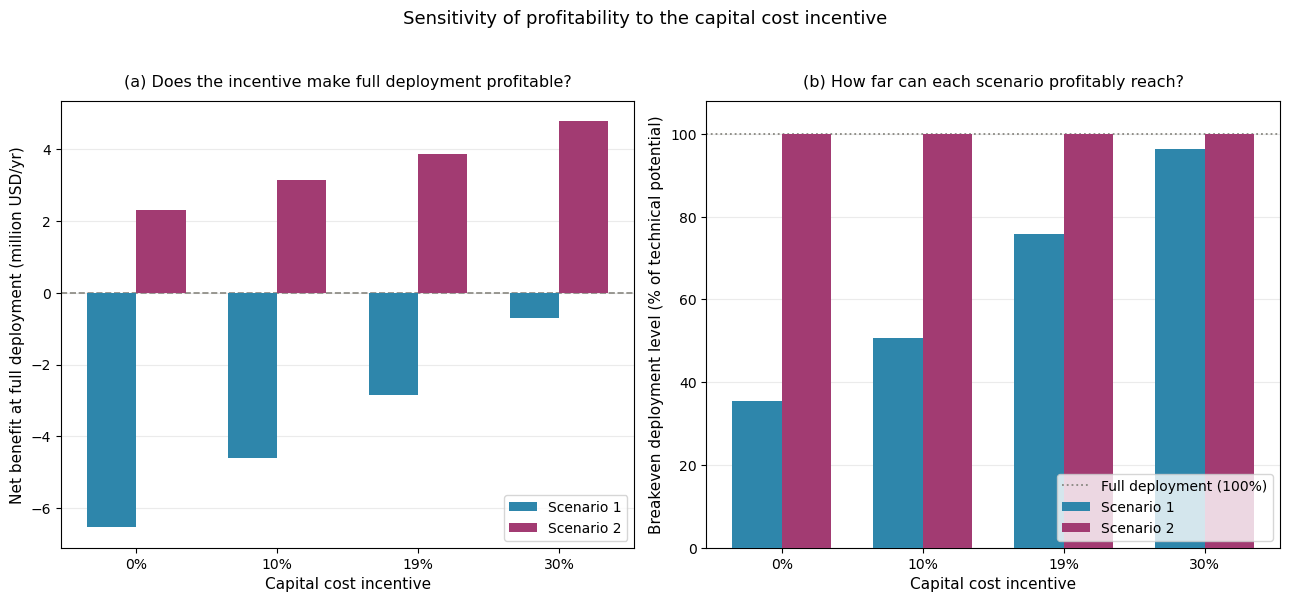

In [100]:
# ==========================================================
# Sección 21 - Sensibilidad a los incentivos tributarios
#
# FIX DE RAIZ (v2): correr_frente() ahora se restaura A SI MISMA con
# try/finally alrededor de TODO su cuerpo -- ya no depende de que quien
# la llame (el barrido de abajo, una prueba manual, u otra celda) tenga
# su propio try/finally envolvente. Es seguro llamar correr_frente(...)
# una sola vez, suelta, en cualquier celda, sin dejar CAPEX contaminado.
# ==========================================================
capex_fijo_total = sum(capex_fijo_esc1_dict[p] for p in plantas)
capex_fijo_total_e2 = sum(capex_fijo_esc2_dict[p] for p in plantas)

_ORIG = {
    't1':      dict(CAPEX_TURBINA_ESC1),
    't2':      dict(CAPEX_TURBINA_ESC2),
    'bio':     CAPEX_UNIDAD_BIOGAS,
    'fijo_e1': capex_fijo_anualizado_total_esc1,
    'fijo_e2': capex_fijo_anualizado_total,
}

def correr_frente(escenario, incentivo):
    """Corre el e-constraint con el CAPEX reducido por 'incentivo' (0-1).
    SIEMPRE restaura CAPEX_TURBINA_ESC1/ESC2/CAPEX_UNIDAD_BIOGAS a sus
    valores originales antes de retornar, sin importar como termine
    (exito, excepcion, o quien la haya llamado)."""
    global CAPEX_TURBINA_ESC1, CAPEX_TURBINA_ESC2, CAPEX_UNIDAD_BIOGAS
    try:
        f = 1 - incentivo
        CAPEX_TURBINA_ESC1  = {k: v * f for k, v in _ORIG['t1'].items()}
        CAPEX_TURBINA_ESC2  = {k: v * f for k, v in _ORIG['t2'].items()}
        CAPEX_UNIDAD_BIOGAS = _ORIG['bio'] * f
        if escenario == 1:
            capex_fijo_anual = (_ORIG['fijo_e1'] + capex_fijo_total * PCT_OPERACION_ANUAL) * f
        else:
            capex_fijo_anual = (_ORIG['fijo_e2'] + capex_fijo_total_e2 * PCT_OPERACION_ANUAL) * f

        constructor = construir_modelo_f2 if escenario == 1 else construir_modelo_f2_esc2
        f2_ini = f2_en_f1max if escenario == 1 else f2_en_f1max_e2
        f2_fin = f2_max      if escenario == 1 else f2_max_e2

        gen, ben = [], []
        for n in range(q + 1):
            eps = f2_ini + n * (f2_fin - f2_ini) / q
            m = constructor(objetivo='economico', restriccion_f2=eps)
            r = solver.solve(m, tee=False)
            if r.solver.termination_condition == pyo.TerminationCondition.optimal:
                gen.append(pyo.value(m.f2_generacion) / 1e6)
                ben.append(pyo.value(m.f1_economico) - capex_fijo_anual)

        gen, ben = np.array(gen), np.array(ben)
        i_opt = ben.argmax()
        pot_max = gen[-1]

        cruces = np.where(np.diff(np.sign(ben)))[0]
        if len(cruces) == 0:
            gen_eq, pct_eq = (np.nan, np.nan) if ben[-1] < 0 else (pot_max, 100.0)
        else:
            i = cruces[0]
            frac = ben[i] / (ben[i] - ben[i+1])
            gen_eq = gen[i] + frac * (gen[i+1] - gen[i])
            pct_eq = gen_eq / pot_max * 100

        return gen[i_opt], ben[i_opt], gen_eq, pct_eq, ben[-1]
    finally:
        CAPEX_TURBINA_ESC1  = dict(_ORIG['t1'])
        CAPEX_TURBINA_ESC2  = dict(_ORIG['t2'])
        CAPEX_UNIDAD_BIOGAS = _ORIG['bio']

def _verificar_capex_limpio():
    assert CAPEX_TURBINA_ESC1[8000] == _ORIG['t1'][8000], "CAPEX_TURBINA_ESC1 contaminado"
    assert CAPEX_UNIDAD_BIOGAS == _ORIG['bio'], "CAPEX_UNIDAD_BIOGAS contaminado"
    print(f"[OK] CAPEX limpio -- CAPEX_TURBINA_ESC1[8000]={CAPEX_TURBINA_ESC1[8000]:,.0f}  "
          f"CAPEX_UNIDAD_BIOGAS={CAPEX_UNIDAD_BIOGAS:,.0f}")

# --- Barrido de incentivos ---
filas = []
for inc in [0.00, 0.10, 0.19, 0.30]:
    for esc in [1, 2]:
        g_opt, b_opt, g_eq, pct_eq, b_tot = correr_frente(esc, inc)
        filas.append({
            'incentivo_%': inc * 100,
            'escenario': esc,
            'gen_optimo_GWh': g_opt,
            'beneficio_optimo_USD': b_opt,
            'gen_equilibrio_GWh': g_eq,
            'equilibrio_%_potencial': pct_eq,
            'beneficio_despliegue_total_USD': b_tot,
        })

_verificar_capex_limpio()
df_sens = pd.DataFrame(filas)
print(df_sens.to_string(index=False))
df_sens.to_csv('sensibilidad_incentivos_tributarios.csv', index=False)

# ==========================================================
# Figura de sensibilidad al incentivo de capital (paneles a/b),
# usando df_sens generado arriba.
# ==========================================================

COLOR_ESC1 = "#2E86AB"
COLOR_ESC2 = "#A23B72"
COLOR_ZERO = "#888780"

incentivos = sorted(df_sens['incentivo_%'].unique())
labels = [f"{int(i)}%" for i in incentivos]
x = np.arange(len(incentivos))
bar_w = 0.35

# Extraer series por escenario, en el mismo orden que 'incentivos'
def serie(col, escenario):
    sub = df_sens[df_sens['escenario'] == escenario].set_index('incentivo_%')
    return [sub.loc[i, col] for i in incentivos]

esc1_full = serie('beneficio_despliegue_total_USD', 1)
esc2_full = serie('beneficio_despliegue_total_USD', 2)
esc1_pct_eq = serie('equilibrio_%_potencial', 1)
esc2_pct_eq = serie('equilibrio_%_potencial', 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.8))

# --- Panel (a): beneficio neto en despliegue total vs. incentivo ---
ax1.bar(x - bar_w/2, [v/1e6 for v in esc1_full], width=bar_w, color=COLOR_ESC1, label="Scenario 1", zorder=3)
ax1.bar(x + bar_w/2, [v/1e6 for v in esc2_full], width=bar_w, color=COLOR_ESC2, label="Scenario 2", zorder=3)
ax1.axhline(0, color=COLOR_ZERO, linestyle="--", linewidth=1.2, zorder=2)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_xlabel("Capital cost incentive", fontsize=11)
ax1.set_ylabel("Net benefit at full deployment (million USD/yr)", fontsize=11)
ax1.set_title("(a) Does the incentive make full deployment profitable?", fontsize=11.5, pad=10)
ax1.grid(axis="y", alpha=0.25, zorder=0)
ax1.set_axisbelow(True)
ax1.legend(fontsize=10, loc="lower right")

# --- Panel (b): nivel de despliegue de equilibrio vs. incentivo, ambos escenarios ---
ax2.bar(x - bar_w/2, esc1_pct_eq, width=bar_w, color=COLOR_ESC1, label="Scenario 1", zorder=3)
ax2.bar(x + bar_w/2, esc2_pct_eq, width=bar_w, color=COLOR_ESC2, label="Scenario 2", zorder=3)
ax2.axhline(100, color=COLOR_ZERO, linestyle=":", linewidth=1.3, zorder=2, label="Full deployment (100%)")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_xlabel("Capital cost incentive", fontsize=11)
ax2.set_ylabel("Breakeven deployment level (% of technical potential)", fontsize=11)
ax2.set_title("(b) How far can each scenario profitably reach?", fontsize=11.5, pad=10)
ax2.set_ylim(0, 108)
ax2.grid(axis="y", alpha=0.25, zorder=0)
ax2.set_axisbelow(True)
ax2.legend(fontsize=10, loc="lower right")

fig.suptitle("Sensitivity of profitability to the capital cost incentive", y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig("figure_capital_incentive_sensitivity_final.png", dpi=300, bbox_inches="tight")
plt.show()

In [101]:
resultados = []
for incentivo in [0.0, 0.10, 0.19, 0.30]:
    for esc in [1, 2]:
        gen_opt, ben_opt, gen_eq, pct_eq, ben_full = correr_frente(esc, incentivo)
        resultados.append({
            'incentivo_pct': incentivo*100,
            'escenario': esc,
            'beneficio_optimo_USD': ben_opt,
            'beneficio_full_USD': ben_full,
        })
df_incentivos = pd.DataFrame(resultados)
print(df_incentivos.to_string(index=False))

 incentivo_pct  escenario  beneficio_optimo_USD  beneficio_full_USD
           0.0          1          2.587033e+05       -6.531748e+06
           0.0          2          3.427932e+06        2.315672e+06
          10.0          1          9.584983e+05       -4.587052e+06
          10.0          2          4.115171e+06        3.134918e+06
          19.0          1          1.588314e+06       -2.836827e+06
          19.0          2          4.733687e+06        3.872240e+06
          30.0          1          2.358088e+06       -6.976618e+05
          30.0          2          5.489650e+06        4.773412e+06


In [102]:
# Resolver el modelo SIN ninguna restriccion, con el precio actual, y ver donde cae el optimo real
m_verificacion = construir_modelo_f2(objetivo='economico')
solver.solve(m_verificacion, tee=False)
gen_real = pyo.value(m_verificacion.f2_generacion)
ben_real = pyo.value(m_verificacion.f1_economico)
print(f"Generacion en el optimo economico SIN restriccion: {gen_real/1e6:.2f} GWh ({gen_real/f2_max*100:.1f}% del potencial)")
print(f"Beneficio (antes de CAPEX fijo): ${ben_real:,.0f}")
print()
print(f"PRECIO_BOLSA_PROMEDIO actual en memoria: {PRECIO_BOLSA_PROMEDIO}")
print(f"f2_en_f1max (variable cacheada que usa correr_frente): {f2_en_f1max/1e6:.2f} GWh")

Generacion en el optimo economico SIN restriccion: 66.96 GWh (32.2% del potencial)
Beneficio (antes de CAPEX fijo): $4,304,216

PRECIO_BOLSA_PROMEDIO actual en memoria: 0.0703
f2_en_f1max (variable cacheada que usa correr_frente): 66.96 GWh


## Sección 22:Tarifa preferencial (targe seeking)

=== SCENARIO 1 ===
 precio_excedente_USD_kWh  gen_elegida_GWh  pct_potencial_elegido  beneficio_libre_USD  beneficio_despliegue_total_USD
                     0.07        66.963255              32.160366         2.445878e+05                   -6.588232e+06
                     0.08        66.963255              32.160366         7.148803e+05                   -4.705405e+06
                     0.09        66.963255              32.160366         1.185173e+06                   -2.822579e+06
                     0.10       133.268879              64.004892         1.756386e+06                   -9.397516e+05
                     0.11       181.224477              87.036472         3.076086e+06                    9.430754e+05
                     0.12       181.224477              87.036472         4.715638e+06                    2.852550e+06
                     0.13       183.332730              88.049001         6.382678e+06                    4.780543e+06
                     0.14    

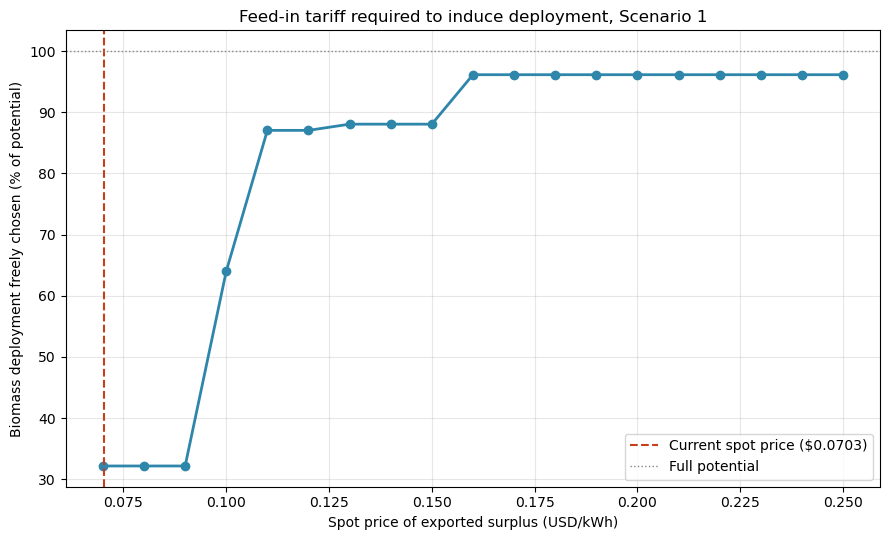

In [103]:
# ==========================================================
# Section 22 - Feed-in tariff sensitivity, Scenario 1
# Sweeps the price of surplus sold on the spot market. For each price,
# the unconstrained economic optimum is solved, observing how much
# biomass the mill chooses to deploy freely. Answers two questions:
#   (a) Breakeven feed-in tariff: price at which full deployment stops losing money.
#   (b) Incentive-compatible feed-in tariff: price at which the mill CHOOSES full deployment.
# ==========================================================
_PRECIO_BOLSA_ORIG = PRECIO_BOLSA_PROMEDIO
def barrido_fit(escenario):
    global PRECIO_BOLSA_PROMEDIO
    constructor = construir_modelo_f2 if escenario == 1 else construir_modelo_f2_esc2
    if escenario == 1:
        capex_fijo = capex_fijo_anualizado_total_esc1 + capex_fijo_total * PCT_OPERACION_ANUAL
    else:
        capex_fijo = capex_fijo_anualizado_total + capex_fijo_total_e2 * PCT_OPERACION_ANUAL
    f2_potencial = (f2_max if escenario == 1 else f2_max_e2) / 1e6
    filas = []
    for precio in np.arange(0.07, 0.26, 0.01):
        PRECIO_BOLSA_PROMEDIO = precio
        m_libre = constructor(objetivo='economico')
        solver.solve(m_libre, tee=False)
        gen_libre = pyo.value(m_libre.f2_generacion) / 1e6
        ben_libre = pyo.value(m_libre.f1_economico) - capex_fijo
        m_full = constructor(objetivo='economico',
                             restriccion_f2=(f2_max if escenario == 1 else f2_max_e2))
        solver.solve(m_full, tee=False)
        ben_full = pyo.value(m_full.f1_economico) - capex_fijo
        filas.append({
            'precio_excedente_USD_kWh': precio,
            'gen_elegida_GWh': gen_libre,
            'pct_potencial_elegido': gen_libre / f2_potencial * 100,
            'beneficio_libre_USD': ben_libre,
            'beneficio_despliegue_total_USD': ben_full,
        })
    PRECIO_BOLSA_PROMEDIO = _PRECIO_BOLSA_ORIG
    return pd.DataFrame(filas)

df_fit1 = barrido_fit(1)
print("=== SCENARIO 1 ===")
print(df_fit1.to_string(index=False))
eq  = df_fit1[df_fit1['beneficio_despliegue_total_USD'] >= 0]
inc = df_fit1[df_fit1['pct_potencial_elegido'] >= 99.5]
print(f"\nCurrent spot price: ${_PRECIO_BOLSA_ORIG:.4f}/kWh")
print(f"(a) BREAKEVEN feed-in tariff (full deployment stops losing money): "
      f"${eq['precio_excedente_USD_kWh'].min():.3f}/kWh" if len(eq) else "(a) Not reached within the range tested")
print(f"(b) INCENTIVE-COMPATIBLE feed-in tariff (mill CHOOSES full deployment): "
      f"${inc['precio_excedente_USD_kWh'].min():.3f}/kWh" if len(inc) else "(b) Not reached within the range tested")
df_fit1.to_csv('feed_in_tariff_scenario1.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(df_fit1['precio_excedente_USD_kWh'], df_fit1['pct_potencial_elegido'],
        'o-', color='#2E86AB', linewidth=2)
ax.axvline(_PRECIO_BOLSA_ORIG, color='#C73E1D', linestyle='--',
           label=f'Current spot price (${_PRECIO_BOLSA_ORIG:.4f})')
ax.axhline(100, color='#888780', linestyle=':', linewidth=1, label='Full potential')
ax.set_xlabel('Spot price of exported surplus (USD/kWh)')
ax.set_ylabel('Biomass deployment freely chosen (% of potential)')
ax.set_title('Feed-in tariff required to induce deployment, Scenario 1')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('feed_in_tariff_scenario1.png', dpi=150)
plt.show()

=== SCENARIO 2 ===
 precio_excedente_USD_kWh  gen_elegida_GWh  pct_potencial_elegido  beneficio_libre_USD  beneficio_despliegue_total_USD
                     0.07       136.165442              92.294882         3.397157e+06                    2.281487e+06
                     0.08       136.165442              92.294882         4.422959e+06                    3.420965e+06
                     0.09       136.165442              92.294882         5.448760e+06                    4.560442e+06
                     0.10       136.165442              92.294882         6.474561e+06                    5.699919e+06
                     0.11       136.165442              92.294882         7.500362e+06                    6.839396e+06
                     0.12       136.165442              92.294882         8.571420e+06                    8.024130e+06
                     0.13       138.436674              93.834356         9.674746e+06                    9.240314e+06
                     0.14    

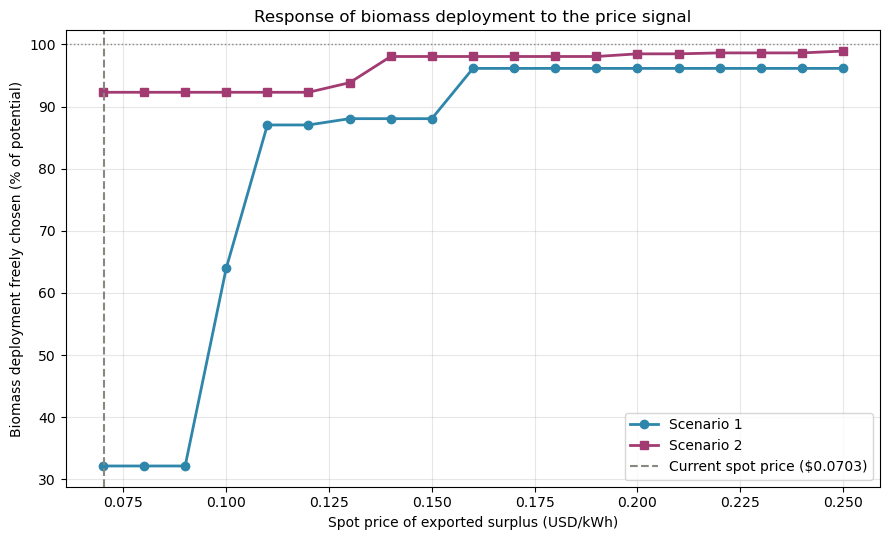

In [104]:
# ==========================================================
# Section 22 (bis) - Feed-in tariff sensitivity, Scenario 2
# ==========================================================
df_fit2 = barrido_fit(2)
print("=== SCENARIO 2 ===")
print(df_fit2.to_string(index=False))
eq2  = df_fit2[df_fit2['beneficio_despliegue_total_USD'] >= 0]
inc2 = df_fit2[df_fit2['pct_potencial_elegido'] >= 99.5]
print(f"\nCurrent spot price: ${_PRECIO_BOLSA_ORIG:.4f}/kWh")
print("(a) BREAKEVEN feed-in tariff: " +
      (f"${eq2['precio_excedente_USD_kWh'].min():.3f}/kWh" if len(eq2)
       else "not required, already profitable at the current price"))
print("(b) INCENTIVE-COMPATIBLE feed-in tariff (chooses full deployment): " +
      (f"${inc2['precio_excedente_USD_kWh'].min():.3f}/kWh" if len(inc2)
       else "not reached within the range tested"))
df_fit2.to_csv('feed_in_tariff_scenario2.csv', index=False)

# --- Comparative figure: deployment response to price ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(df_fit1['precio_excedente_USD_kWh'], df_fit1['pct_potencial_elegido'],
        'o-', color='#2E86AB', linewidth=2, label='Scenario 1')
ax.plot(df_fit2['precio_excedente_USD_kWh'], df_fit2['pct_potencial_elegido'],
        's-', color='#A23B72', linewidth=2, label='Scenario 2')
ax.axvline(_PRECIO_BOLSA_ORIG, color='#888780', linestyle='--',
           label=f'Current spot price (${_PRECIO_BOLSA_ORIG:.4f})')
ax.axhline(100, color='#888780', linestyle=':', linewidth=1)
ax.set_xlabel('Spot price of exported surplus (USD/kWh)')
ax.set_ylabel('Biomass deployment freely chosen (% of potential)')
ax.set_title('Response of biomass deployment to the price signal')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('feed_in_tariff_comparison.png', dpi=150)
plt.show()

In [105]:
df_fit1 = barrido_fit(escenario=1)
df_fit2 = barrido_fit(escenario=2)

# Validacion obligatoria: a precio=0.07, beneficio_despliegue_total debe dar
# ~1,901,235 (Esc.1) y un valor cercano a 6,296,553 (Esc.2)
print("Esc.1 @0.07:", round(df_fit1.loc[0,'beneficio_despliegue_total_USD']))
print("Esc.2 @0.07:", round(df_fit2.loc[0,'beneficio_despliegue_total_USD']))

df_fit1.to_csv('fit1_corregido.csv', index=False)
df_fit2.to_csv('fit2_corregido.csv', index=False)
print(df_fit1.to_string(index=False))
print(df_fit2.to_string(index=False))

Esc.1 @0.07: -6588232
Esc.2 @0.07: 2281487
 precio_excedente_USD_kWh  gen_elegida_GWh  pct_potencial_elegido  beneficio_libre_USD  beneficio_despliegue_total_USD
                     0.07        66.963255              32.160366         2.445878e+05                   -6.588232e+06
                     0.08        66.963255              32.160366         7.148803e+05                   -4.705405e+06
                     0.09        66.963255              32.160366         1.185173e+06                   -2.822579e+06
                     0.10       133.268879              64.004892         1.756386e+06                   -9.397516e+05
                     0.11       181.224477              87.036472         3.076086e+06                    9.430754e+05
                     0.12       181.224477              87.036472         4.715638e+06                    2.852550e+06
                     0.13       183.332730              88.049001         6.382678e+06                    4.780543e+06
     

## Sección 23- rentabilidad desagregada

## Sección 24 - Robustez contra precio de bolsa

In [106]:
def _beneficio_planta_bolsa(r, capex_turbina_cat, capex_fijo_dict, precio_bolsa,
                              costo_oport_raquis_dict, factor_util_oport_col, factor_util_raquis_col):
    p = r['planta']
    auto = r['autoconsumo_kWh']
    permuta = r['excedente_permuta_kWh']
    bolsa = r['excedente_bolsa_kWh']
    ingreso = auto*PRECIO_TRAMO_12_dict[p] + permuta*PRECIO_TRAMO_12_dict[p] + bolsa*precio_bolsa
    capex_var = (capex_turbina_cat[int(round(r['cap_turbina_kW']))]
                 + round(r['cap_biogas_kW']/TAMANO_UNIDAD_BIOGAS_KW)*CAPEX_UNIDAD_BIOGAS)
    factor_util_oport = r[factor_util_oport_col] if factor_util_oport_col in r else 1.0
    factor_util_raquis = r[factor_util_raquis_col] if factor_util_raquis_col in r else 1.0
    return (ingreso - capex_var/PVAF - capex_var*PCT_OPERACION_ANUAL
            - factor_util_oport * costo_oport_dict[p]
            - factor_util_raquis * costo_oport_raquis_dict[p]
            - capex_fijo_dict[p]/PVAF - capex_fijo_dict[p]*PCT_OPERACION_ANUAL)

sub_e1 = df_pareto_plantas[df_pareto_plantas['punto'] == df_pareto_plantas['punto'].max()]
sub_e2 = df_pareto_plantas_e2[df_pareto_plantas_e2['punto'] == df_pareto_plantas_e2['punto'].max()]

total_e1 = sum(_beneficio_planta_bolsa(r, CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict,
                                         PRECIO_BOLSA_PROMEDIO, costo_oport_raquis_dict,
                                         'factor_utilizacion', 'factor_utilizacion')
               for _, r in sub_e1.iterrows())

total_e2 = sum(_beneficio_planta_bolsa(r, CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict,
                                         PRECIO_BOLSA_PROMEDIO, costo_oport_raquis_dict,
                                         'factor_util_turbina', 'factor_util_biogas')
               for _, r in sub_e2.iterrows())

print(f"Escenario 1, recalculado: ${total_e1:,.0f}  (debe ser -6,531,746)")
print(f"Escenario 2, recalculado: ${total_e2:,.0f}  (debe ser 2,315,672)")

Escenario 1, recalculado: $-6,531,748  (debe ser -6,531,746)
Escenario 2, recalculado: $2,315,672  (debe ser 2,315,672)


Scenario 1: aggregate breakeven spot price = 0.1050  (current 0.0703)
Scenario 2: aggregate breakeven spot price = 0.0500  (current 0.0703)


,plant,current_net_benefit_sc1,breakeven_spot_price_sc1,current_net_benefit_sc2,breakeven_spot_price_sc2
0,Planta A,-1.336196e+06,0.108348,-1.139401e+05,0.076237
1,Planta B,-4.714964e+05,0.080014,1.066132e+06,0.036252
2,Planta C,-2.161284e+05,0.075656,1.361445e+06,0.014819
3,Planta D,-8.632430e+05,0.096957,2.956836e+05,0.055812
4,Planta E,-1.704771e+06,0.147219,2.960985e+05,0.046796
5,Planta F,-1.939912e+06,0.269697,-5.897480e+05,0.170265


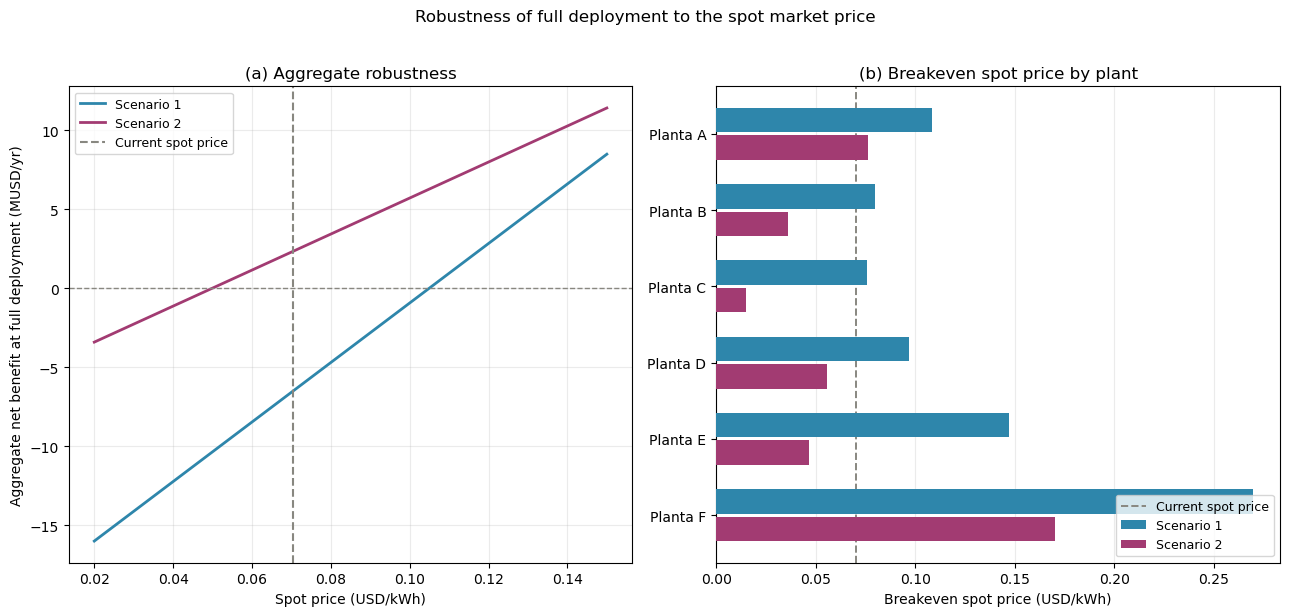

In [107]:
# ==========================================================
# SECCIÓN 24 - Regenerar completo: precio de equilibrio por
# planta y agregado, mas la figura, con la funcion corregida
#
# FIX: price_robustness() y el panel (a) ahora pasan las DOS columnas de
# factor de utilizacion que _beneficio_planta_bolsa requiere:
#   Escenario 1: costo_oport -> factor_utilizacion | costo_oport_raquis -> factor_utilizacion
#   Escenario 2: costo_oport -> factor_util_turbina | costo_oport_raquis -> factor_util_biogas
# ==========================================================
def _breakeven_price(f, lo=0.0, hi=0.30):
    if f(hi) < 0: return None
    if f(lo) > 0: return 0.0
    for _ in range(60):
        mid = (lo+hi)/2
        if f(mid) > 0: hi = mid
        else: lo = mid
    return (lo+hi)/2

def price_robustness(df_plantas, capex_turbina_cat, capex_fijo_dict,
                       factor_util_oport_col, factor_util_raquis_col, nombre):
    sub = df_plantas[df_plantas['punto'] == df_plantas['punto'].max()]
    filas = []
    for _, r in sub.iterrows():
        f = lambda b, r=r: _beneficio_planta_bolsa(r, capex_turbina_cat, capex_fijo_dict, b,
                                                       costo_oport_raquis_dict,
                                                       factor_util_oport_col, factor_util_raquis_col)
        filas.append({'plant': r['planta'], 'current_net_benefit': f(PRECIO_BOLSA_PROMEDIO),
                      'breakeven_spot_price': _breakeven_price(f)})
    agg = lambda b: sum(_beneficio_planta_bolsa(r, capex_turbina_cat, capex_fijo_dict, b,
                                                   costo_oport_raquis_dict,
                                                   factor_util_oport_col, factor_util_raquis_col)
                        for _, r in sub.iterrows())
    print(f"{nombre}: aggregate breakeven spot price = {_breakeven_price(agg):.4f}  (current {PRECIO_BOLSA_PROMEDIO})")
    return pd.DataFrame(filas)

rob_e1 = price_robustness(df_pareto_plantas,    CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict,
                            'factor_utilizacion', 'factor_utilizacion', "Scenario 1")
rob_e2 = price_robustness(df_pareto_plantas_e2, CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict,
                            'factor_util_turbina', 'factor_util_biogas', "Scenario 2")
display(rob_e1.merge(rob_e2, on='plant', suffixes=('_sc1','_sc2')))

# ==========================================================
# Figura 10 unificada: panel (a) curva agregada + panel (b)
# precio de equilibrio por planta, misma paleta del manuscrito
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np

COLOR_ESC1 = '#2E86AB'
COLOR_ESC2 = '#A23B72'
COLOR_ZERO = '#888780'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

precios = np.arange(0.02, 0.151, 0.002)
for df_p, ct, fj, futil_oport, futil_raquis, lab, color in [
    (df_pareto_plantas,    CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict, 'factor_utilizacion', 'factor_utilizacion', 'Scenario 1', COLOR_ESC1),
    (df_pareto_plantas_e2, CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict, 'factor_util_turbina', 'factor_util_biogas', 'Scenario 2', COLOR_ESC2),
]:
    sub = df_p[df_p['punto'] == df_p['punto'].max()]
    y = [sum(_beneficio_planta_bolsa(r, ct, fj, b, costo_oport_raquis_dict, futil_oport, futil_raquis)
             for _, r in sub.iterrows())/1e6 for b in precios]
    ax1.plot(precios, y, label=lab, color=color, linewidth=2)

ax1.axhline(0, color=COLOR_ZERO, lw=1, linestyle='--')
ax1.axvline(PRECIO_BOLSA_PROMEDIO, ls='--', color=COLOR_ZERO, label='Current spot price')
ax1.set_xlabel('Spot price (USD/kWh)')
ax1.set_ylabel('Aggregate net benefit at full deployment (MUSD/yr)')
ax1.set_title('(a) Aggregate robustness')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)

orden_plantas = sorted(rob_e1['plant'].unique())
y_pos = np.arange(len(orden_plantas))[::-1]
bar_h = 0.32

be1 = rob_e1.set_index('plant').loc[orden_plantas, 'breakeven_spot_price'].values
be2 = rob_e2.set_index('plant').loc[orden_plantas, 'breakeven_spot_price'].values

ax2.barh(y_pos + bar_h/2 + 0.02, be1, height=bar_h, color=COLOR_ESC1, label='Scenario 1', zorder=3)
ax2.barh(y_pos - bar_h/2 - 0.02, be2, height=bar_h, color=COLOR_ESC2, label='Scenario 2', zorder=3)
ax2.axvline(PRECIO_BOLSA_PROMEDIO, color=COLOR_ZERO, linestyle='--', linewidth=1.4,
            label='Current spot price', zorder=2)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(orden_plantas, fontsize=10)
ax2.set_xlabel('Breakeven spot price (USD/kWh)')
ax2.set_title('(b) Breakeven spot price by plant')
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(axis='x', alpha=0.25, zorder=0)
ax2.set_axisbelow(True)

fig.suptitle('Robustness of full deployment to the spot market price', y=1.02)
plt.tight_layout()
plt.savefig('spot_price_robustness_v3_unified.png', dpi=150, bbox_inches='tight')
plt.show()

## 25 Sensibilidad costo vapor

In [108]:
# ============================================================
# SECCIÓN 25 — Sensibilidad del Esc.1 al costo de cogeneración de A
# Usa los anclas de Cenipalma (2024, n=6 plantas reales) como rango de
# sensibilidad, en vez de un unico caso base. Actualiza PRECIO_TRAMO_12_dict
# y re-resuelve el modelo economico completo en cada punto.
# ============================================================
def sensibilidad_precio_cogeneracion_A(valores_cop_kwh, etiquetas=None):
    global PRECIO_TRAMO_12_dict
    precio_original = PRECIO_TRAMO_12_dict['Planta A']
    frac_biomasa_A = 0.7913          # Sec. 8.1: % de A autogenerado con biomasa
    frac_grid_A = 1 - frac_biomasa_A
    precio_grid_A = PRECIO_TRAMO_12_dict['Planta B']  # misma tarifa de red que B (validado)

    filas = []
    for i, cop in enumerate(valores_cop_kwh):
        costo_usd = cop / TRM_COP_USD
        precio_pond = frac_biomasa_A*costo_usd + frac_grid_A*precio_grid_A
        PRECIO_TRAMO_12_dict['Planta A'] = precio_pond

        m = construir_modelo_f2(objetivo='economico')
        solver.solve(m, tee=False)
        f1 = pyo.value(m.f1_economico)
        beneficio_opt = f1 - capex_fijo_anualizado_total_esc1 - capex_fijo_total*PCT_OPERACION_ANUAL
        gen_opt = pyo.value(m.f2_generacion) / 1e6

        filas.append({
            'etiqueta': etiquetas[i] if etiquetas else f'{cop} COP/kWh',
            'costo_cop_kwh': cop,
            'precio_ponderado_A_USD_kWh': precio_pond,
            'beneficio_optimo_economico_USD': beneficio_opt,
            'gen_optimo_GWh': gen_opt,
            'pct_potencial_elegido': gen_opt / (f2_max/1e6) * 100,
        })

    PRECIO_TRAMO_12_dict['Planta A'] = precio_original   # restaurar
    return pd.DataFrame(filas)

valores = [21, 90, 204.8, 258, 543.3]
etiquetas = ['Cenipalma min', 'Entrepalmas (ref.)', 'Cenipalma promedio', 'UPME (ref.)', 'Cenipalma max']
df_sens_A = sensibilidad_precio_cogeneracion_A(valores, etiquetas)

# Validacion obligatoria: la fila UPME (258) debe reproducir el beneficio ya conocido
print("Validacion — fila UPME debe dar ~4,866,656:")
display(df_sens_A)

Validacion — fila UPME debe dar ~4,866,656:


,etiqueta,costo_cop_kwh,precio_ponderado_A_USD_kWh,beneficio_optimo_economico_USD,gen_optimo_GWh,pct_potencial_elegido
0,Cenipalma min,21.0,0.057923,60871.086623,66.963255,32.160366
1,Entrepalmas (ref.),90.0,0.074272,78810.338199,66.963255,32.160366
2,Cenipalma promedio,204.8,0.101473,201664.629801,66.963255,32.160366
3,UPME (ref.),258.0,0.114078,258597.106397,66.963255,32.160366
4,Cenipalma max,543.3,0.181677,563913.564534,66.963255,32.160366


In [109]:
# ==========================================================
# Section 25 - Full re-optimization of Scenario 1 under
# Plant A's cogeneration cost sensitivity range (not just the
# 100% point; re-solves the whole model at each price)
# ==========================================================
_PRECIO_A_ORIG = PRECIO_TRAMO_12_dict['Planta A']

precios_A = {
    'Cenipalma minimo': 0.05792,
    'Cenipalma promedio': 0.10147,
    'Actual/UPME': 0.11408,
    'Cenipalma maximo': 0.18168,
}

filas = []
for nombre, precio in precios_A.items():
    PRECIO_TRAMO_12_dict['Planta A'] = precio
    m = construir_modelo_f2(objetivo='economico')
    solver.solve(m, tee=False)
    beneficio_total = pyo.value(m.f1_economico) - (capex_fijo_anualizado_total_esc1 + capex_fijo_total * PCT_OPERACION_ANUAL)
    cap_turb_A = pyo.value(m.capacidad_turbina_kW['Planta A'])
    cap_bio_A = pyo.value(m.capacidad_biogas_kW['Planta A'])
    gen_A = pyo.value(m.potencia_turbina_kW['Planta A']) + pyo.value(m.potencia_biogas_kW['Planta A'])
    filas.append({
        'escenario_precio': nombre,
        'precio_USD_kWh': precio,
        'cap_turbina_A_kW': cap_turb_A,
        'cap_biogas_A_kW': cap_bio_A,
        'generacion_A_kW': gen_A,
        'beneficio_total_reoptimizado_USD': beneficio_total,
    })

PRECIO_TRAMO_12_dict['Planta A'] = _PRECIO_A_ORIG  # restaurar

df_reopt_A = pd.DataFrame(filas)
print("=== Re-optimizacion completa bajo el rango de precio de Planta A ===\n")
print(df_reopt_A.to_string(index=False))
df_reopt_A.to_csv('reoptimizacion_planta_A_sensibilidad.csv', index=False)

=== Re-optimizacion completa bajo el rango de precio de Planta A ===

  escenario_precio  precio_USD_kWh  cap_turbina_A_kW  cap_biogas_A_kW  generacion_A_kW  beneficio_total_reoptimizado_USD
  Cenipalma minimo         0.05792             300.0           2000.0      2166.035405                      60871.086623
Cenipalma promedio         0.10147             300.0           2000.0      2166.035405                     201652.407313
       Actual/UPME         0.11408             300.0           2000.0      2166.035405                     258606.287772
  Cenipalma maximo         0.18168             300.0           2000.0      2166.035405                     563926.059305


## Tablas 

In [110]:
# ==========================================================
# Tabla 8 - Sensibilidad al incentivo de capital, con
# resolucion DIRECTA (evita correr_frente), y con el costo
# del raquis verificado ($16.82/t) ya incluido
#
# FIX: restauracion de CAPEX en try/finally -- garantiza que se restaure
# incluso si el solver falla o hay una excepcion a mitad del barrido.
# ==========================================================
_ORIG_CAPEX_T1 = dict(CAPEX_TURBINA_ESC1)
_ORIG_CAPEX_T2 = dict(CAPEX_TURBINA_ESC2)
_ORIG_CAPEX_BIO = CAPEX_UNIDAD_BIOGAS
resultados_tabla8 = []
try:
    for incentivo in [0.0, 0.10, 0.19, 0.30]:
        f = 1 - incentivo
        CAPEX_TURBINA_ESC1.update({k: v*f for k, v in _ORIG_CAPEX_T1.items()})
        CAPEX_TURBINA_ESC2.update({k: v*f for k, v in _ORIG_CAPEX_T2.items()})
        globals()['CAPEX_UNIDAD_BIOGAS'] = _ORIG_CAPEX_BIO * f
        for esc, constructor, f2_max_val, capex_fijo_om in [
            (1, construir_modelo_f2, f2_max, capex_fijo_anualizado_total_esc1 + capex_fijo_total*PCT_OPERACION_ANUAL),
            (2, construir_modelo_f2_esc2, f2_max_e2, capex_fijo_anualizado_total + capex_fijo_total_e2*PCT_OPERACION_ANUAL),
        ]:
            m_opt = constructor(objetivo='economico')
            solver.solve(m_opt, tee=False)
            ben_opt = pyo.value(m_opt.f1_economico) - capex_fijo_om*f
            m_full = constructor(objetivo='economico', restriccion_f2=f2_max_val)
            solver.solve(m_full, tee=False)
            ben_full = pyo.value(m_full.f1_economico) - capex_fijo_om*f
            resultados_tabla8.append({
                'incentivo_pct': incentivo*100, 'escenario': esc,
                'beneficio_optimo_USD': ben_opt, 'beneficio_full_USD': ben_full,
            })
finally:
    CAPEX_TURBINA_ESC1.update(_ORIG_CAPEX_T1)
    CAPEX_TURBINA_ESC2.update(_ORIG_CAPEX_T2)
    globals()['CAPEX_UNIDAD_BIOGAS'] = _ORIG_CAPEX_BIO
    assert CAPEX_TURBINA_ESC1[8000] == _ORIG_CAPEX_T1[8000], "CAPEX_TURBINA_ESC1 no se restauro bien"
    assert CAPEX_UNIDAD_BIOGAS == _ORIG_CAPEX_BIO, "CAPEX_UNIDAD_BIOGAS no se restauro bien"
    print(f"[OK] CAPEX restaurado -- CAPEX_TURBINA_ESC1[8000]={CAPEX_TURBINA_ESC1[8000]:,.0f}  "
          f"CAPEX_UNIDAD_BIOGAS={CAPEX_UNIDAD_BIOGAS:,.0f}")

df_tabla8 = pd.DataFrame(resultados_tabla8)
print(df_tabla8.to_string(index=False))

[OK] CAPEX restaurado -- CAPEX_TURBINA_ESC1[8000]=18,376,697  CAPEX_UNIDAD_BIOGAS=314,641
 incentivo_pct  escenario  beneficio_optimo_USD  beneficio_full_USD
           0.0          1          2.586966e+05       -6.531748e+06
           0.0          2          3.427931e+06        2.315672e+06
          10.0          1          9.584916e+05       -4.587052e+06
          10.0          2          4.115171e+06        3.134918e+06
          19.0          1          1.588307e+06       -2.836827e+06
          19.0          2          4.733686e+06        3.872240e+06
          30.0          1          2.358082e+06       -6.976618e+05
          30.0          2          5.489650e+06        4.773412e+06


In [111]:
# ==========================================================
# beneficio_planta_en_punto CORREGIDA: recibe explicitamente
# que factor usar para el raquis, en vez de detectarlo con hasattr
# ==========================================================
def beneficio_planta_en_punto(m, planta, capex_turbina_cat, capex_fijo_dict,
                                factor_util_col, factor_raquis_col):
    """factor_util_col: nombre del atributo para el costo de biomasa (fibra/cuesco).
    factor_raquis_col: nombre del atributo para el costo del raquis --
      'factor_utilizacion' en Escenario 1 (raquis combustionado),
      'factor_util_biogas' en Escenario 2 (raquis co-digerido)."""
    horas = pyo.value(m.horas[planta])
    autoc = pyo.value(m.autoconsumo_kW[planta]) * horas
    permuta = pyo.value(m.excedente_permuta_kW[planta]) * horas
    bolsa = pyo.value(m.excedente_bolsa_kW[planta]) * horas
    precio_p = PRECIO_TRAMO_12_dict[planta]
    ingreso = autoc*precio_p + permuta*precio_p + bolsa*PRECIO_BOLSA_PROMEDIO

    cap_turb_kW = pyo.value(m.capacidad_turbina_kW[planta])
    capex_turb = capex_turbina_cat.get(int(round(cap_turb_kW)), 0.0)
    n_unid = pyo.value(m.n_unidades_biogas[planta])
    capex_bio = n_unid * CAPEX_UNIDAD_BIOGAS
    capex_variable = capex_turb + capex_bio

    factor_util = pyo.value(getattr(m, factor_util_col)[planta])
    factor_raquis = pyo.value(getattr(m, factor_raquis_col)[planta])

    costo_oport_biomasa = factor_util * costo_oport_dict[planta]
    costo_oport_raquis = factor_raquis * costo_oport_raquis_dict[planta]

    return (ingreso - capex_variable/PVAF - capex_variable*PCT_OPERACION_ANUAL
            - capex_fijo_dict[planta]/PVAF - capex_fijo_dict[planta]*PCT_OPERACION_ANUAL
            - costo_oport_biomasa - costo_oport_raquis)

# --- Recalcular el desglose del optimo con la funcion corregida ---
filas_opt_e1 = []
for p in plantas:
    ben = beneficio_planta_en_punto(m1, p, CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict,
                                      'factor_utilizacion', 'factor_utilizacion')  # Esc.1: raquis usa factor_utilizacion
    filas_opt_e1.append({'planta': p, 'beneficio_neto_USD': ben})
df_opt_e1 = pd.DataFrame(filas_opt_e1)

filas_opt_e2 = []
for p in plantas:
    ben = beneficio_planta_en_punto(m1_e2, p, CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict,
                                      'factor_util_turbina', 'factor_util_biogas')  # Esc.2: raquis usa factor_util_biogas
    filas_opt_e2.append({'planta': p, 'beneficio_neto_USD': ben})
df_opt_e2 = pd.DataFrame(filas_opt_e2)

suma_e1 = df_opt_e1['beneficio_neto_USD'].sum()
suma_e2 = df_opt_e2['beneficio_neto_USD'].sum()
print(f"Escenario 1: suma = ${suma_e1:,.0f}  (esperado ~258,705)")
print(f"Escenario 2: suma = ${suma_e2:,.0f}  (esperado ~3,427,932)")

if abs(suma_e1-258705)<100 and abs(suma_e2-3427932)<100:
    print("\nOK -- coincide")
    df_final = pd.DataFrame({'planta': plantas,
                              'esc1_optimo_USD': df_opt_e1['beneficio_neto_USD'].values,
                              'esc2_optimo_USD': df_opt_e2['beneficio_neto_USD'].values})
    df_final = pd.concat([df_final, pd.DataFrame([{'planta':'Total','esc1_optimo_USD':suma_e1,'esc2_optimo_USD':suma_e2}])], ignore_index=True)
    print(df_final.to_string(index=False))
else:
    print("\n*** TODAVIA NO CUADRA ***")

Escenario 1: suma = $258,697  (esperado ~258,705)
Escenario 2: suma = $3,427,931  (esperado ~3,427,932)

OK -- coincide
  planta  esc1_optimo_USD  esc2_optimo_USD
Planta A   -265283.375222     9.820668e+04
Planta B    556274.883919     1.328030e+06
Planta C    624456.430155     1.496220e+06
Planta D     99278.295903     4.795132e+05
Planta E   -130361.977861     4.931253e+05
Planta F   -625667.637829    -4.671631e+05
   Total    258696.619066     3.427931e+06


In [112]:
# ==========================================================
# Tabla 4 - Generacion por planta, relativa a linea base,
# en el optimo economico y en el despliegue total (100%)
# Escenario 1 y Escenario 2, con TODOS los arreglos de hoy
# ==========================================================

def generacion_por_planta(m):
    """Extrae la generacion neta por planta de un modelo ya resuelto."""
    filas = {}
    for p in plantas:
        h = pyo.value(m.horas[p])
        pot_turb = pyo.value(m.potencia_turbina_kW[p])
        pot_bio = pyo.value(m.potencia_biogas_kW[p])
        filas[p] = (FACTOR_NETO_TURBINA*pot_turb + FACTOR_NETO_BIOGAS*pot_bio) * h
    return filas

# --- Escenario 1 ---
m_opt_e1 = construir_modelo_f2(objetivo='economico')
solver.solve(m_opt_e1, tee=False)
gen_opt_e1 = generacion_por_planta(m_opt_e1)

m_full_e1 = construir_modelo_f2(objetivo='economico', restriccion_f2=f2_max)
solver.solve(m_full_e1, tee=False)
gen_full_e1 = generacion_por_planta(m_full_e1)

# --- Escenario 2 ---
m_opt_e2 = construir_modelo_f2_esc2(objetivo='economico')
solver.solve(m_opt_e2, tee=False)
gen_opt_e2 = generacion_por_planta(m_opt_e2)

m_full_e2 = construir_modelo_f2_esc2(objetivo='economico', restriccion_f2=f2_max_e2)
solver.solve(m_full_e2, tee=False)
gen_full_e2 = generacion_por_planta(m_full_e2)

# --- Linea base (Tabla 2, MWh/ano -> kWh/ano) ---
baseline_kWh = {
    'Planta A': 3083.7*1000, 'Planta B': 5398.1*1000, 'Planta C': 2740.9*1000,
    'Planta D': 3746.2*1000, 'Planta E': 2281.7*1000, 'Planta F': 702.9*1000,
}

filas_tabla4 = []
for p in plantas:
    filas_tabla4.append({
        'planta': p,
        'baseline_MWh': baseline_kWh[p]/1000,
        'esc1_optimo_MWh': gen_opt_e1[p]/1000,
        'esc1_optimo_x': gen_opt_e1[p]/baseline_kWh[p],
        'esc1_full_MWh': gen_full_e1[p]/1000,
        'esc1_full_x': gen_full_e1[p]/baseline_kWh[p],
        'esc2_optimo_MWh': gen_opt_e2[p]/1000,
        'esc2_optimo_x': gen_opt_e2[p]/baseline_kWh[p],
        'esc2_full_MWh': gen_full_e2[p]/1000,
        'esc2_full_x': gen_full_e2[p]/baseline_kWh[p],
    })

df_tabla4 = pd.DataFrame(filas_tabla4)
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')
print(df_tabla4.to_string(index=False))

  planta  baseline_MWh  esc1_optimo_MWh  esc1_optimo_x  esc1_full_MWh  esc1_full_x  esc2_optimo_MWh  esc2_optimo_x  esc2_full_MWh  esc2_full_x
Planta A       3,083.7         10,205.6            3.3       39,635.5         12.9         24,452.7            7.9       26,861.6          8.7
Planta B       5,398.1         17,108.4            3.2       52,696.2          9.8         34,435.0            6.4       37,834.4          7.0
Planta C       2,740.9         14,222.6            5.2       44,940.4         16.4         29,915.0           10.9       32,186.3         11.7
Planta D       3,746.2         14,087.4            3.8       35,433.8          9.5         24,021.5            6.4       25,653.1          6.8
Planta E       2,281.7          7,989.1            3.5       25,004.2         11.0         16,722.0            7.3       17,845.3          7.8
Planta F         702.9          3,350.1            4.8       10,506.5         14.9          6,619.1            9.4        7,152.5         10.2

In [113]:
precios_D_USD_kWh = {
    'Minimo (180 COP/kWh)': 0.05390,
    'Promedio (306.3 COP/kWh)': 0.09172,
    'Actual': 0.153,
    'Maximo (465.1 COP/kWh)': 0.13927,
}
resultados_D = []
_precio_orig_D = PRECIO_TRAMO_12_dict['Planta D']
try:
    for etiqueta, precio in precios_D_USD_kWh.items():
        PRECIO_TRAMO_12_dict['Planta D'] = precio
        # Escenario 1
        m_opt1 = construir_modelo_f2(objetivo='economico')
        solver.solve(m_opt1, tee=False)
        ben_opt1 = beneficio_planta_en_punto(m_opt1, 'Planta D', CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict, 'factor_utilizacion', 'factor_utilizacion')
        m_full1 = construir_modelo_f2(objetivo='economico', restriccion_f2=f2_max)
        solver.solve(m_full1, tee=False)
        ben_full1 = beneficio_planta_en_punto(m_full1, 'Planta D', CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict, 'factor_utilizacion', 'factor_utilizacion')
        # Escenario 2
        m_opt2 = construir_modelo_f2_esc2(objetivo='economico')
        solver.solve(m_opt2, tee=False)
        ben_opt2 = beneficio_planta_en_punto(m_opt2, 'Planta D', CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict, 'factor_util_turbina', 'factor_util_biogas')
        m_full2 = construir_modelo_f2_esc2(objetivo='economico', restriccion_f2=f2_max_e2)
        solver.solve(m_full2, tee=False)
        ben_full2 = beneficio_planta_en_punto(m_full2, 'Planta D', CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict, 'factor_util_turbina', 'factor_util_biogas')
        resultados_D.append({'escenario': 1, 'precio_etiqueta': etiqueta, 'precio_USD_kWh': precio, 'beneficio_optimo': ben_opt1, 'beneficio_100pct': ben_full1})
        resultados_D.append({'escenario': 2, 'precio_etiqueta': etiqueta, 'precio_USD_kWh': precio, 'beneficio_optimo': ben_opt2, 'beneficio_100pct': ben_full2})
finally:
    PRECIO_TRAMO_12_dict['Planta D'] = _precio_orig_D
    assert PRECIO_TRAMO_12_dict['Planta D'] == _precio_orig_D
    print(f"[OK] PRECIO_TRAMO_12_dict['Planta D'] restaurado -- {PRECIO_TRAMO_12_dict['Planta D']}")
df_D = pd.DataFrame(resultados_D)
print(df_D.to_string(index=False))

[OK] PRECIO_TRAMO_12_dict['Planta D'] restaurado -- 0.153
 escenario          precio_etiqueta  precio_USD_kWh  beneficio_optimo  beneficio_100pct
         1     Minimo (180 COP/kWh)             0.1        -152,999.5      -1,115,520.8
         2     Minimo (180 COP/kWh)             0.1          45,761.0        -138,068.6
         1 Promedio (306.3 COP/kWh)             0.1         -87,657.4      -1,050,178.7
         2 Promedio (306.3 COP/kWh)             0.1         158,106.5         -25,723.1
         1                   Actual             0.2          99,278.3        -863,243.0
         2                   Actual             0.2         479,513.2         295,683.6
         1   Maximo (465.1 COP/kWh)             0.1          57,394.7        -905,126.6
         2   Maximo (465.1 COP/kWh)             0.1         407,500.9         223,671.3


## Figuras

In [114]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Colores
C_PEACH  = '#FCE4CD'
C_GRAY   = '#D9D9D9'
C_BLUE_L = '#DCEEF9'
C_GREEN_L= '#E2EFDA'
C_PINK   = '#FADCE5'
C_BLUE_D = '#2E75B6'   # turbina (fondo solido, texto blanco)
C_GREEN_D= '#1E7B34'   # motor a gas / electricidad (fondo solido, texto blanco)
C_BORDER = '#404040'

def box(ax, xy, w, h, text, facecolor, textcolor='black', fontsize=12.5, weight='normal'):
    x, y = xy
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                        linewidth=1.6, edgecolor=C_BORDER, facecolor=facecolor, zorder=2)
    ax.add_patch(b)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
             fontsize=fontsize, color=textcolor, weight=weight, zorder=3, linespacing=1.35)
    return (x, y, w, h)

def arrow(ax, start, end, color=C_BORDER, lw=1.6, curve=0.0):
    style = f"arc3,rad={curve}" if curve else "arc3,rad=0"
    a = FancyArrowPatch(start, end, connectionstyle=style, arrowstyle='-|>',
                         mutation_scale=16, linewidth=lw, color=color, zorder=1)
    ax.add_patch(a)

def edge_pt(b, side):
    x, y, w, h = b
    if side == 'right':  return (x + w, y + h/2)
    if side == 'left':   return (x, y + h/2)
    if side == 'top':    return (x + w/2, y + h)
    if side == 'bottom': return (x + w/2, y)
    if side == 'top-right':   return (x + w*0.8, y + h)
    if side == 'top-left':    return (x + w*0.2, y + h)
    if side == 'bottom-right':return (x + w*0.8, y)
    if side == 'bottom-left': return (x + w*0.2, y)

def new_fig(w=12, h=7.2):
    fig, ax = plt.subplots(figsize=(w, h))
    ax.set_xlim(0, w)
    ax.set_ylim(0, h)
    ax.axis('off')
    return fig, ax

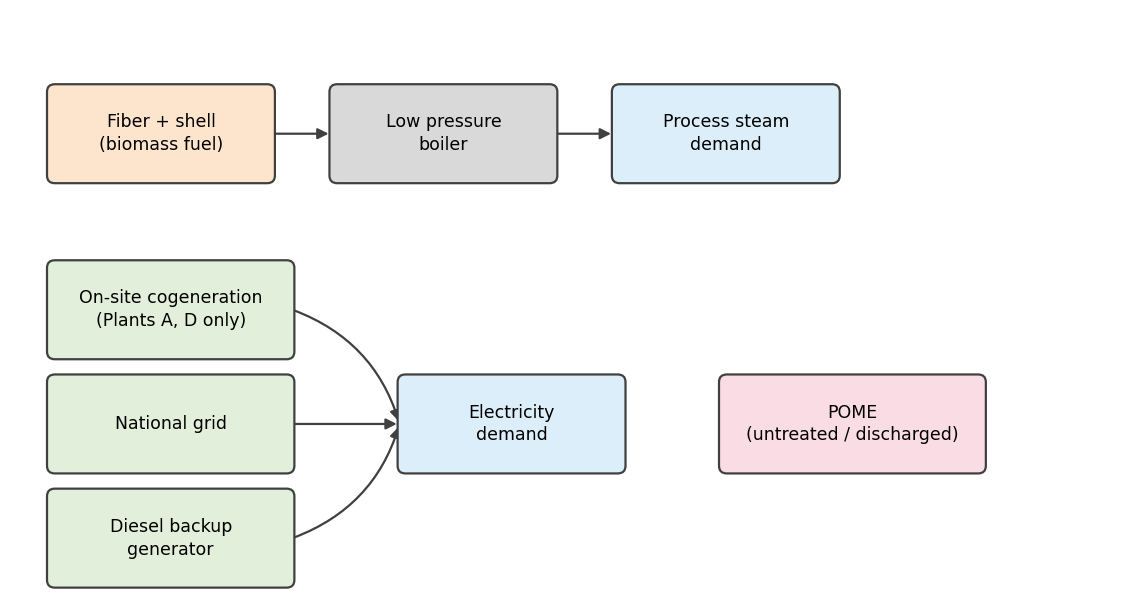

In [115]:
fig, ax = new_fig(11.5, 6.2)

b_fuel  = box(ax, (0.4, 4.4), 2.3, 1.0, "Fiber + shell\n(biomass fuel)", C_PEACH)
b_boil  = box(ax, (3.3, 4.4), 2.3, 1.0, "Low pressure\nboiler", C_GRAY)
b_steam = box(ax, (6.2, 4.4), 2.3, 1.0, "Process steam\ndemand", C_BLUE_L)
arrow(ax, edge_pt(b_fuel,'right'), edge_pt(b_boil,'left'))
arrow(ax, edge_pt(b_boil,'right'), edge_pt(b_steam,'left'))

b_cogen = box(ax, (0.4, 2.55), 2.5, 1.0, "On-site cogeneration\n(Plants A, D only)", C_GREEN_L)
b_grid  = box(ax, (0.4, 1.35), 2.5, 1.0, "National grid", C_GREEN_L)
b_diesel= box(ax, (0.4, 0.15), 2.5, 1.0, "Diesel backup\ngenerator", C_GREEN_L)
b_elec  = box(ax, (4.0, 1.35), 2.3, 1.0, "Electricity\ndemand", C_BLUE_L)

arrow(ax, edge_pt(b_cogen,'right'), edge_pt(b_elec,'left'), curve=-0.25)
arrow(ax, edge_pt(b_grid,'right'),  edge_pt(b_elec,'left'))
arrow(ax, edge_pt(b_diesel,'right'),edge_pt(b_elec,'left'), curve=0.25)

b_pome = box(ax, (7.3, 1.35), 2.7, 1.0, "POME\n(untreated / discharged)", C_PINK)

plt.tight_layout()
plt.savefig('resultados/figuras/Figure1_Baseline.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

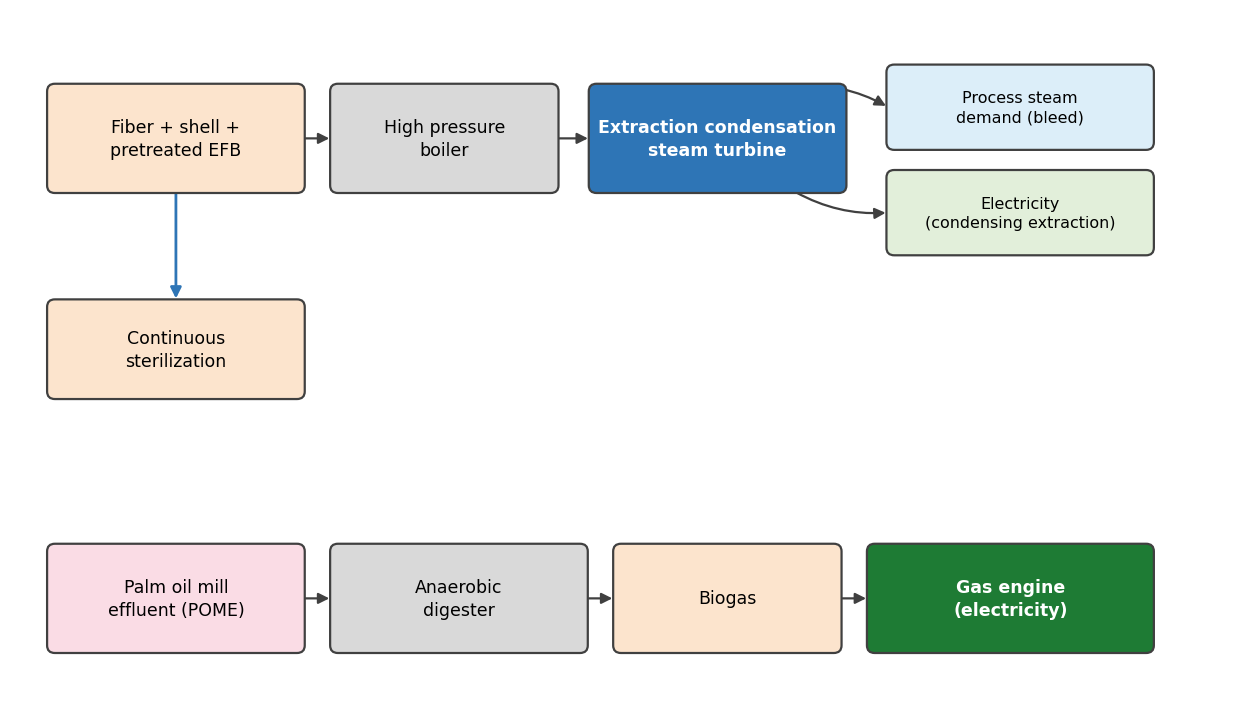

In [116]:
fig, ax = new_fig(12.5, 7.2)

b_fuel = box(ax, (0.4, 5.3), 2.6, 1.1, "Fiber + shell +\npretreated EFB", C_PEACH)
b_boil = box(ax, (3.3, 5.3), 2.3, 1.1, "High pressure\nboiler", C_GRAY)
b_turb = box(ax, (5.95, 5.3), 2.6, 1.1, "Extraction condensation\nsteam turbine", C_BLUE_D, textcolor='white', weight='bold')
b_steam= box(ax, (9.0, 5.75), 2.7, 0.85, "Process steam\ndemand (bleed)", C_BLUE_L, fontsize=11.5)
b_elec = box(ax, (9.0, 4.65), 2.7, 0.85, "Electricity\n(condensing extraction)", C_GREEN_L, fontsize=11.5)

arrow(ax, edge_pt(b_fuel,'right'), edge_pt(b_boil,'left'))
arrow(ax, edge_pt(b_boil,'right'), edge_pt(b_turb,'left'))
arrow(ax, edge_pt(b_turb,'top-right'), edge_pt(b_steam,'left'), curve=-0.15)
arrow(ax, edge_pt(b_turb,'bottom-right'), edge_pt(b_elec,'left'), curve=0.15)

b_ester = box(ax, (0.4, 3.15), 2.6, 1.0, "Continuous\nsterilization", C_PEACH)
arrow(ax, edge_pt(b_fuel,'bottom'), edge_pt(b_ester,'top'), color=C_BLUE_D, lw=2.0)

b_pome  = box(ax, (0.4, 0.5), 2.6, 1.1, "Palm oil mill\neffluent (POME)", C_PINK)
b_digest= box(ax, (3.3, 0.5), 2.6, 1.1, "Anaerobic\ndigester", C_GRAY)
b_biogas= box(ax, (6.2, 0.5), 2.3, 1.1, "Biogas", C_PEACH)
b_engine= box(ax, (8.8, 0.5), 2.9, 1.1, "Gas engine\n(electricity)", C_GREEN_D, textcolor='white', weight='bold')

arrow(ax, edge_pt(b_pome,'right'), edge_pt(b_digest,'left'))
arrow(ax, edge_pt(b_digest,'right'), edge_pt(b_biogas,'left'))
arrow(ax, edge_pt(b_biogas,'right'), edge_pt(b_engine,'left'))

plt.tight_layout()
plt.savefig('resultados/figuras/Figure2_Scenario1.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

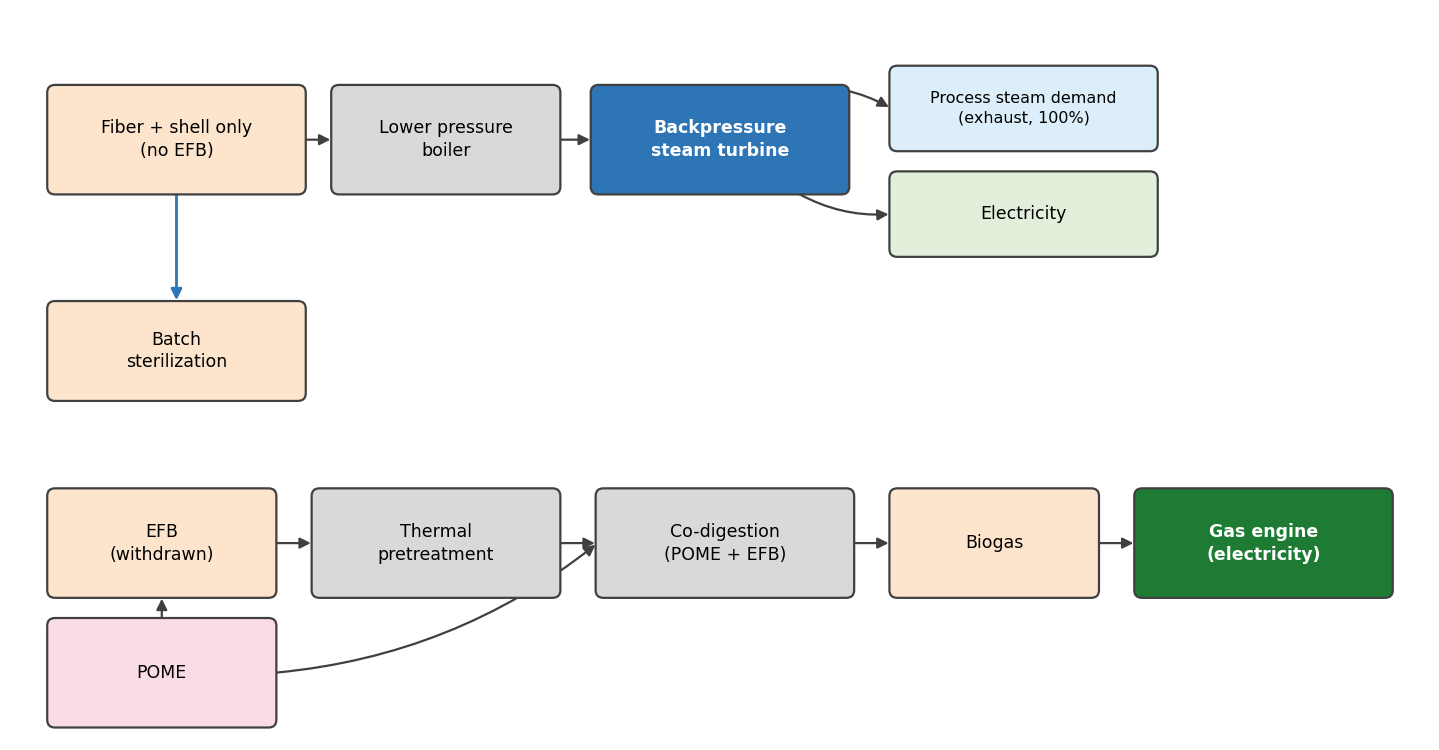

In [117]:
fig, ax = new_fig(14.5, 7.6)

b_fuel = box(ax, (0.4, 5.7), 2.6, 1.1, "Fiber + shell only\n(no EFB)", C_PEACH)
b_boil = box(ax, (3.3, 5.7), 2.3, 1.1, "Lower pressure\nboiler", C_GRAY)
b_turb = box(ax, (5.95, 5.7), 2.6, 1.1, "Backpressure\nsteam turbine", C_BLUE_D, textcolor='white', weight='bold')
b_steam= box(ax, (9.0, 6.15), 2.7, 0.85, "Process steam demand\n(exhaust, 100%)", C_BLUE_L, fontsize=11.5)
b_elec = box(ax, (9.0, 5.05), 2.7, 0.85, "Electricity", C_GREEN_L)

arrow(ax, edge_pt(b_fuel,'right'), edge_pt(b_boil,'left'))
arrow(ax, edge_pt(b_boil,'right'), edge_pt(b_turb,'left'))
arrow(ax, edge_pt(b_turb,'top-right'), edge_pt(b_steam,'left'), curve=-0.15)
arrow(ax, edge_pt(b_turb,'bottom-right'), edge_pt(b_elec,'left'), curve=0.15)

b_batch = box(ax, (0.4, 3.55), 2.6, 1.0, "Batch\nsterilization", C_PEACH)
arrow(ax, edge_pt(b_fuel,'bottom'), edge_pt(b_batch,'top'), color=C_BLUE_D, lw=2.0)

b_efb    = box(ax, (0.4, 1.5), 2.3, 1.1, "EFB\n(withdrawn)", C_PEACH)
b_therm  = box(ax, (3.1, 1.5), 2.5, 1.1, "Thermal\npretreatment", C_GRAY)
b_codig  = box(ax, (6.0, 1.5), 2.6, 1.1, "Co-digestion\n(POME + EFB)", C_GRAY)
b_biogas = box(ax, (9.0, 1.5), 2.1, 1.1, "Biogas", C_PEACH)
b_engine = box(ax, (11.5, 1.5), 2.6, 1.1, "Gas engine\n(electricity)", C_GREEN_D, textcolor='white', weight='bold')
b_pome   = box(ax, (0.4, 0.15), 2.3, 1.1, "POME", C_PINK)

arrow(ax, edge_pt(b_efb,'right'), edge_pt(b_therm,'left'))
arrow(ax, edge_pt(b_therm,'right'), edge_pt(b_codig,'left'))
arrow(ax, edge_pt(b_pome,'top'), edge_pt(b_efb,'bottom'))
arrow(ax, edge_pt(b_pome,'right'), edge_pt(b_codig,'left'), curve=0.15)
arrow(ax, edge_pt(b_codig,'right'), edge_pt(b_biogas,'left'))
arrow(ax, edge_pt(b_biogas,'right'), edge_pt(b_engine,'left'))

plt.tight_layout()
plt.savefig('resultados/figuras/Figure3_Scenario2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

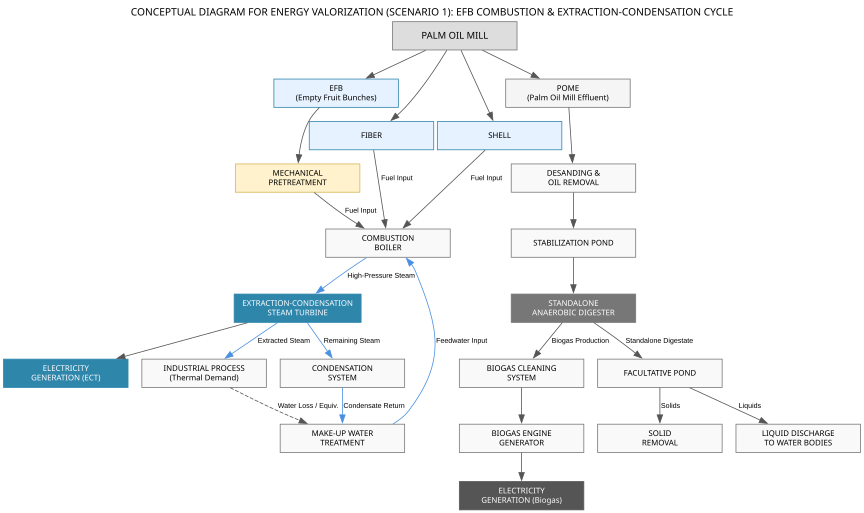

In [118]:
import graphviz
from graphviz import Digraph

# Crear el objeto del diagrama para el Escenario 1 corregido (Estructura en Cascada)
dot = Digraph(name='Energy_Valorization_Scenario1_Cascade', format='svg')
dot.attr(rankdir='TB', size='12,12', fontname='Arial')

# ==========================================
# PALETA DE COLORES (Identidad Escenario 1)
# ==========================================
color_esc1 = '#2E86AB'       # Azul principal de tu gráfico
color_vapor = '#4a90e2'      # Azul sutil para líneas de vapor/agua
color_fondo_nodos = '#f9f9f9'
color_borde_gris = '#777777'
color_texto = '#000000'

# Estilo global de los nodos (Ortodoxo, limpio y sin cajas duplicadas)
dot.attr('node', shape='box', style='filled', fontname='Arial-Bold', fontsize='10', 
         color=color_borde_gris, fillcolor=color_fondo_nodos, fontcolor=color_texto, width='2.2')
dot.attr('edge', fontname='Arial', fontsize='9', color='#555555')

# ==========================================
# TÍTULO DEL GRÁFICO (Único y Global)
# ==========================================
dot.attr(label='CONCEPTUAL DIAGRAM FOR ENERGY VALORIZATION (SCENARIO 1): EFB COMBUSTION & EXTRACTION-CONDENSATION CYCLE', 
         labelloc='t', fontsize='13', fontname='Arial-Bold')

# ==========================================
# NODOS
# ==========================================
dot.node('mill', 'PALM OIL MILL', shape='box', fillcolor='#dddddd', fontsize='12')

# --- RUTA DE COGENERACIÓN SÓLIDA (FIBER, SHELL & EFB) ---
dot.node('efb', 'EFB\n(Empty Fruit Bunches)', fillcolor='#e6f2ff', color=color_esc1)
dot.node('fiber', 'FIBER', fillcolor='#e6f2ff', color=color_esc1)
dot.node('shell', 'SHELL', fillcolor='#e6f2ff', color=color_esc1)
dot.node('pre', 'MECHANICAL\nPRETREATMENT', fillcolor='#fff2cc', color='#d6b656') # Destacado por recibir calor
dot.node('boiler', 'COMBUSTION\nBOILER')
dot.node('turbine', 'EXTRACTION-CONDENSATION\nSTEAM TURBINE', fillcolor=color_esc1, fontcolor='white', color=color_esc1)
dot.node('elec1', 'ELECTRICITY\nGENERATION (ECT)', fillcolor=color_esc1, fontcolor='white', color=color_esc1)
dot.node('process', 'INDUSTRIAL PROCESS\n(Thermal Demand)')
dot.node('condenser', 'CONDENSATION\nSYSTEM')
dot.node('makeup', 'MAKE-UP WATER\nTREATMENT')

# --- RUTA DE TRATAMIENTO LÍQUIDO (POME AISLADO) ---
dot.node('pome', 'POME\n(Palm Oil Mill Effluent)', fillcolor='#f5f5f5')
dot.node('desand', 'DESANDING &\nOIL REMOVAL')
dot.node('stab', 'STABILIZATION POND')
dot.node('digester', 'STANDALONE\nANAEROBIC DIGESTER', fillcolor='#777777', fontcolor='white', color='#777777')
dot.node('clean', 'BIOGAS CLEANING\nSYSTEM')
dot.node('engine', 'BIOGAS ENGINE\nGENERATOR')
dot.node('elec2', 'ELECTRICITY\nGENERATION (Biogas)', fillcolor='#555555', fontcolor='white', color='#555555')
dot.node('fac_pond', 'FACULTATIVE POND')
dot.node('solids', 'SOLID\nREMOVAL')
dot.node('liquids', 'LIQUID DISCHARGE\nTO WATER BODIES')

# ==========================================
# CONEXIONES (Flujos de Masa y Energía en Cascada)
# ==========================================
# Salidas directas de la planta extractora
dot.edge('mill', 'efb')
dot.edge('mill', 'fiber')
dot.edge('mill', 'shell')
dot.edge('mill', 'pome')

# Flujos de la Ruta de Cogeneración Sólida
dot.edge('efb', 'pre')
dot.edge('pre', 'boiler', label=' Fuel Input')
dot.edge('fiber', 'boiler', label=' Fuel Input')
dot.edge('shell', 'boiler', label=' Fuel Input')
dot.edge('boiler', 'turbine', label=' High-Pressure Steam', color=color_vapor)
dot.edge('turbine', 'elec1')
dot.edge('turbine', 'process', label=' Extracted Steam', color=color_vapor)
dot.edge('turbine', 'condenser', label=' Remaining Steam', color=color_vapor)

# Cierre del ciclo de agua
dot.edge('condenser', 'makeup', label=' Condensate Return', color=color_vapor)
dot.edge('process', 'makeup', style='dashed', label=' Water Loss / Equiv.')
dot.edge('makeup', 'boiler', label=' Feedwater Input', color=color_vapor)

# Flujos de la Ruta de Tratamiento Líquido (Biogás Standalone)
dot.edge('pome', 'desand')
dot.edge('desand', 'stab')
dot.edge('stab', 'digester')
dot.edge('digester', 'clean', label=' Biogas Production')
dot.edge('clean', 'engine')
dot.edge('engine', 'elec2')

# Post-tratamiento biológico del efluente
dot.edge('digester', 'fac_pond', label=' Standalone Digestate')
dot.edge('fac_pond', 'solids', label=' Solids')
dot.edge('fac_pond', 'liquids', label=' Liquids')

# ==========================================
# RENDERIZAR
# ==========================================
dot.render('diagrama_conceptual_escenario1_cascada', view=False)
dot

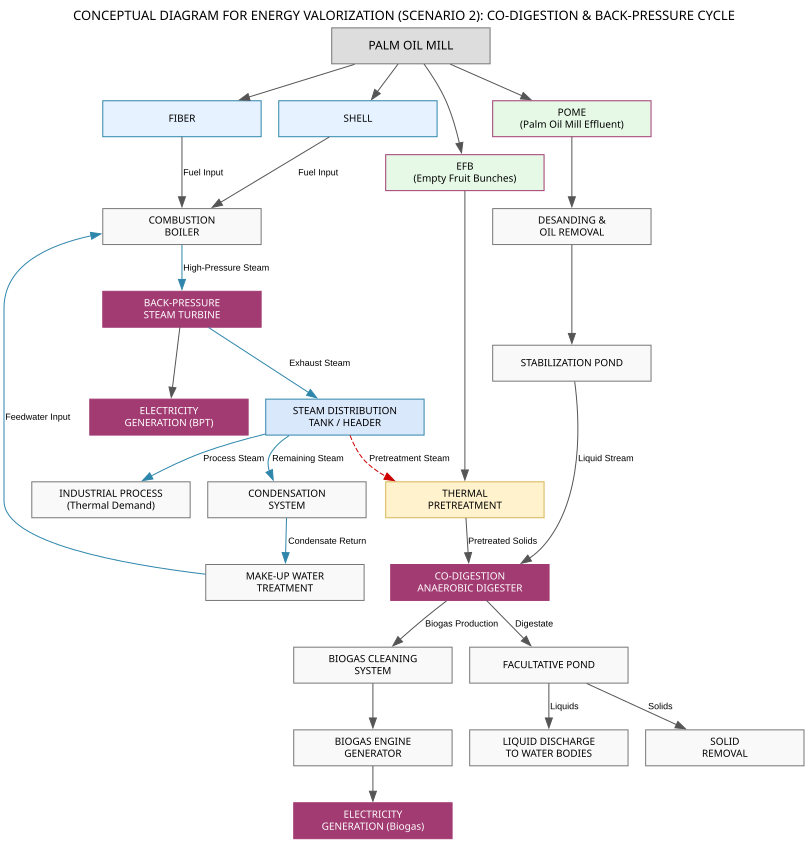

In [119]:
import graphviz
from graphviz import Digraph

# Crear el objeto del diagrama para el Escenario 2 (Co-digestión y Contrapresión)
dot = Digraph(name='Energy_Valorization_Scenario2', format='svg')
dot.attr(rankdir='TB', size='12,12', fontname='Arial')

# ==========================================
# PALETA DE COLORES (Identidad Escenario 2)
# ==========================================
color_esc2 = '#A23B72'       # Verde principal de tu gráfico
color_vapor = '#2E86AB'      # Azul sutil para resaltar las líneas de vapor/agua
color_fondo_nodos = '#f9f9f9'
color_borde_gris = '#777777'
color_texto = '#000000'

# Estilo global de los nodos (Ortodoxo, tipo ingeniería)
dot.attr('node', shape='box', style='filled', fontname='Arial-Bold', fontsize='10', 
         color=color_borde_gris, fillcolor=color_fondo_nodos, fontcolor=color_texto, width='2.2')
dot.attr('edge', fontname='Arial', fontsize='9', color='#555555')

# ==========================================
# TÍTULO DEL GRÁFICO
# ==========================================
dot.attr(label='CONCEPTUAL DIAGRAM FOR ENERGY VALORIZATION (SCENARIO 2): CO-DIGESTION & BACK-PRESSURE CYCLE', 
         labelloc='t', fontsize='13', fontname='Arial-Bold')

# ==========================================
# NODOS
# ==========================================
dot.node('mill', 'PALM OIL MILL', shape='box', fillcolor='#dddddd', fontsize='12')

# --- RUTA DE COGENERACIÓN (FIBER & SHELL) ---
dot.node('fiber', 'FIBER', fillcolor='#e6f2ff', color=color_vapor)
dot.node('shell', 'SHELL', fillcolor='#e6f2ff', color=color_vapor)
dot.node('boiler', 'COMBUSTION\nBOILER')
dot.node('turbine', 'BACK-PRESSURE\nSTEAM TURBINE', fillcolor=color_esc2, fontcolor='white', color=color_esc2)
dot.node('header', 'STEAM DISTRIBUTION\nTANK / HEADER', fillcolor='#dae8fc', color=color_vapor)
dot.node('process', 'INDUSTRIAL PROCESS\n(Thermal Demand)')
dot.node('condenser', 'CONDENSATION\nSYSTEM')
dot.node('makeup', 'MAKE-UP WATER\nTREATMENT')
dot.node('elec1', 'ELECTRICITY\nGENERATION (BPT)', fillcolor=color_esc2, fontcolor='white', color=color_esc2)

# --- RUTA DE CO-DIGESTIÓN (POME & EFB) ---
dot.node('pome', 'POME\n(Palm Oil Mill Effluent)', fillcolor='#e6f9e6', color=color_esc2)
dot.node('efb', 'EFB\n(Empty Fruit Bunches)', fillcolor='#e6f9e6', color=color_esc2)
dot.node('desand', 'DESANDING &\nOIL REMOVAL')
dot.node('stab', 'STABILIZATION POND')
dot.node('thermal', 'THERMAL\nPRETREATMENT', fillcolor='#fff2cc', color='#d6b656') # Destacado por recibir calor
dot.node('digester', 'CO-DIGESTION\nANAEROBIC DIGESTER', fillcolor=color_esc2, fontcolor='white', color=color_esc2)

# --- RUTA BIOGÁS Y EFLUENTES DE CO-DIGESTIÓN ---
dot.node('clean', 'BIOGAS CLEANING\nSYSTEM')
dot.node('engine', 'BIOGAS ENGINE\nGENERATOR')
dot.node('elec2', 'ELECTRICITY\nGENERATION (Biogas)', fillcolor=color_esc2, fontcolor='white', color=color_esc2)
dot.node('fac_pond', 'FACULTATIVE POND')
dot.node('solids', 'SOLID\nREMOVAL')
dot.node('liquids', 'LIQUID DISCHARGE\nTO WATER BODIES')

# ==========================================
# CONEXIONES (Flujos de Masa y Energía)
# ==========================================
# Salidas de la planta extractora
dot.edge('mill', 'fiber')
dot.edge('mill', 'shell')
dot.edge('mill', 'efb')
dot.edge('mill', 'pome')

# Flujos de la Ruta de Cogeneración
dot.edge('fiber', 'boiler', label=' Fuel Input')
dot.edge('shell', 'boiler', label=' Fuel Input')
dot.edge('boiler', 'turbine', label=' High-Pressure Steam', color=color_vapor)
dot.edge('turbine', 'elec1')
dot.edge('turbine', 'header', label=' Exhaust Steam', color=color_vapor)

# Distribución del Vapor desde el Tanque Distribuidor
dot.edge('header', 'process', label=' Process Steam', color=color_vapor)
dot.edge('header', 'thermal', label=' Pretreatment Steam', color='#cc0000', style='dashed') # Flecha roja/discontinua para notar transferencia térmica crítica
dot.edge('header', 'condenser', label=' Remaining Steam', color=color_vapor)

# Cierre del ciclo de agua
dot.edge('condenser', 'makeup', label=' Condensate Return', color=color_vapor)
dot.edge('makeup', 'boiler', label=' Feedwater Input', color=color_vapor)

# Flujos de la Ruta de Co-digestión
dot.edge('pome', 'desand')
dot.edge('desand', 'stab')
dot.edge('stab', 'digester', label=' Liquid Stream')

dot.edge('efb', 'thermal')
dot.edge('thermal', 'digester', label=' Pretreated Solids')

# Generación a Biogás y Post-tratamiento
dot.edge('digester', 'clean', label=' Biogas Production')
dot.edge('clean', 'engine')
dot.edge('engine', 'elec2')

dot.edge('digester', 'fac_pond', label=' Digestate')
dot.edge('fac_pond', 'solids', label=' Solids')
dot.edge('fac_pond', 'liquids', label=' Liquids')

# ==========================================
# RENDERIZAR
# ==========================================
# Genera el archivo .svg y lo muestra de inmediato en el Notebook
dot.render('diagrama_conceptual_escenario2', view=False)
dot

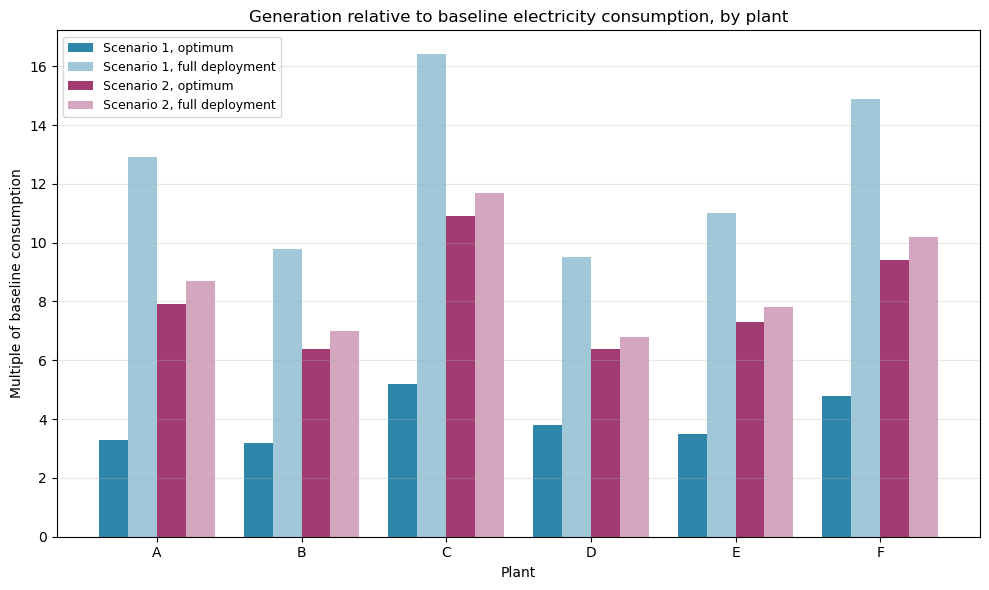

In [120]:
# ==========================================================
# Figura 4 — Multiplos de generacion vs. linea base, por planta
# (complementa la Tabla 4, Seccion 3.1)
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np

plantas_x = ['A', 'B', 'C', 'D', 'E', 'F']
esc1_opt  = [3.3, 3.2, 5.2, 3.8, 3.5, 4.8]
esc1_full = [12.9, 9.8, 16.4, 9.5, 11.0, 14.9]
esc2_opt  = [7.9, 6.4, 10.9, 6.4, 7.3, 9.4]
esc2_full = [8.7, 7.0, 11.7, 6.8, 7.8, 10.2]

x = np.arange(len(plantas_x))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - 1.5*width, esc1_opt,  width, label='Scenario 1, optimum',          color='#2E86AB')
ax.bar(x - 0.5*width, esc1_full, width, label='Scenario 1, full deployment',  color='#2E86AB', alpha=0.45)
ax.bar(x + 0.5*width, esc2_opt,  width, label='Scenario 2, optimum',          color='#A23B72')
ax.bar(x + 1.5*width, esc2_full, width, label='Scenario 2, full deployment',  color='#A23B72', alpha=0.45)

ax.set_xlabel('Plant')
ax.set_ylabel('Multiple of baseline consumption')
ax.set_title('Generation relative to baseline electricity consumption, by plant')
ax.set_xticks(x)
ax.set_xticklabels(plantas_x)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figura_multiplos_linea_base.png', dpi=150)
plt.show()

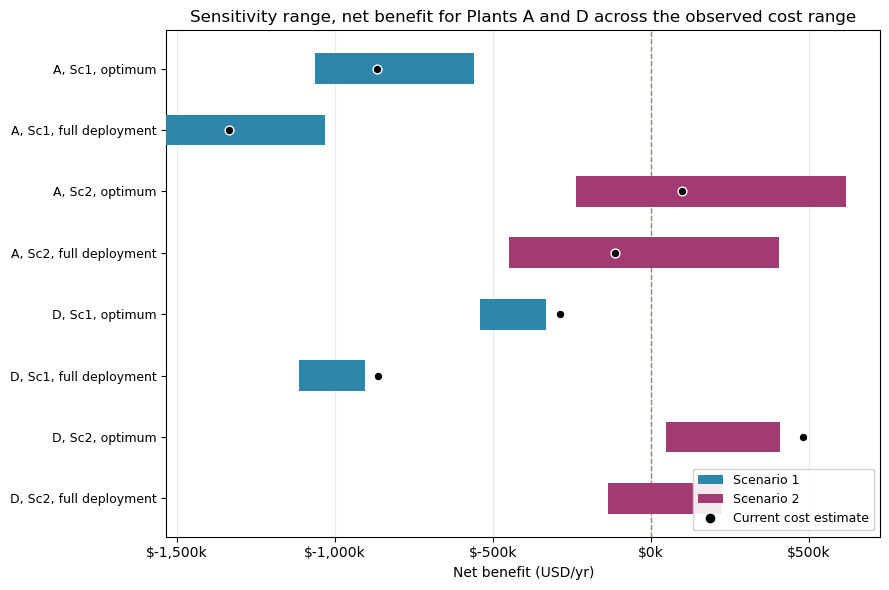

In [121]:
# ==========================================================
# Figura 7 - Sensibilidad de Planta A y D al costo de su
# infraestructura existente, con el costo del raquis incluido
# (datos ya validados contra la Tabla 5, sesion de hoy)
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np

labels = ['D, Sc2, full deployment','D, Sc2, optimum','D, Sc1, full deployment','D, Sc1, optimum',
          'A, Sc2, full deployment','A, Sc2, optimum','A, Sc1, full deployment','A, Sc1, optimum']
mins    = [-138069,    45761,   -1115521,  -541778,
           -449916,   -237769,  -1534022, -1064239]
maxs    = [ 223671,   407501,   -905128,  -331385,
            404444,    616591,  -1030969, -561861]
current = [ 295684,   479513,   -863244,  -289502,
           -114094,     98053,  -1336287, -866505]

# Paleta unificada del manuscrito
COLOR_ESC1 = '#2E86AB'
COLOR_ESC2 = '#A23B72'
COLOR_ZERO = '#888780'

colors  = [COLOR_ESC2, COLOR_ESC2, COLOR_ESC1, COLOR_ESC1,
           COLOR_ESC2, COLOR_ESC2, COLOR_ESC1, COLOR_ESC1]

y = np.arange(len(labels))
widths = [mx - mn for mn, mx in zip(mins, maxs)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y, widths, left=mins, height=0.5, color=colors, zorder=3)
ax.scatter(current, y, color='black', s=40, zorder=5, edgecolor='white', linewidth=1,
           label='Current cost estimate')
ax.axvline(0, color=COLOR_ZERO, linestyle='--', linewidth=1, zorder=2)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Net benefit (USD/yr)')
ax.set_title('Sensitivity range, net benefit for Plants A and D across the observed cost range')
ax.xaxis.set_major_formatter(lambda v, pos: f'${v/1000:,.0f}k')
ax.grid(axis='x', alpha=0.25, zorder=0)
ax.set_axisbelow(True)

# Leyenda manual para los colores de escenario
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_ESC1, label='Scenario 1'),
    Patch(facecolor=COLOR_ESC2, label='Scenario 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
               markeredgecolor='white', markersize=8, label='Current cost estimate'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, frameon=True, framealpha=0.9)

plt.tight_layout()
plt.savefig('figura7_sensibilidad_A_D_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [122]:
# ============================================================
# CHEQUEO RAPIDO DE ESTADO (solo lectura, no modifica nada)
# Correr despues de cualquier reinicio de kernel + Run All,
# ANTES de confiar en cualquier resultado
# ============================================================
checks = []

def check(nombre, condicion, detalle=""):
    estado = "OK" if condicion else "FALLA"
    checks.append((estado, nombre, detalle))

# 1. Las constantes de conversion existen y tienen el valor correcto
try:
    check("FACTOR_NETO_TURBINA", abs(FACTOR_NETO_TURBINA - 0.798798) < 1e-4)
    check("FACTOR_NETO_BIOGAS", abs(FACTOR_NETO_BIOGAS - 0.942907) < 1e-4)
except NameError:
    check("FACTOR_NETO_TURBINA/BIOGAS", False, "no definidas -- correr paso 2")

# 2. El payoff table esta fresco (valores conocidos, no los viejos bruta)
try:
    check("f2_en_f1max (Esc.1)", abs(f2_en_f1max - 66963255) < 50000,
          f"valor actual: {f2_en_f1max:,.0f} (esperado ~66,963,255)")
    check("f2_max (Esc.1)", abs(f2_max - 208216707) < 50000,
          f"valor actual: {f2_max:,.0f} (esperado ~208,216,707)")
except NameError:
    check("f2_en_f1max/f2_max (Esc.1)", False, "no definidas -- correr paso 5")

try:
    check("f2_en_f1max_e2 (Esc.2)", abs(f2_en_f1max_e2 - 136165461) < 50000)
    check("f2_max_e2 (Esc.2)", abs(f2_max_e2 - 147533036) < 50000)
except NameError:
    check("f2_en_f1max_e2/f2_max_e2 (Esc.2)", False, "no definidas -- correr paso 6")

# 3. df_pareto_plantas tiene las columnas nuevas de permuta/bolsa
try:
    check("df_pareto_plantas tiene excedente_permuta_kWh",
          'excedente_permuta_kWh' in df_pareto_plantas.columns)
except NameError:
    check("df_pareto_plantas", False, "no existe -- correr paso 7")

# 4. df_sost tiene el LCOE correcto en el punto 0 (validado hoy: 0.1488)
try:
    lcoe_punto0 = df_sost[df_sost['punto']==0]['lcoe_USD_kWh'].values[0]
    check("df_sost LCOE punto=0", abs(lcoe_punto0 - 0.1488) < 0.001,
          f"valor actual: {lcoe_punto0:.4f} (esperado 0.1488)")
except NameError:
    check("df_sost", False, "no existe -- correr paso 9")

# 5. capex_fijo_total / capex_fijo_total_e2 existen (necesarios para Seccion 21)
try:
    check("capex_fijo_total definido", capex_fijo_total > 0)
    check("capex_fijo_total_e2 definido", capex_fijo_total_e2 > 0)
except NameError:
    check("capex_fijo_total(_e2)", False, "no definidas -- correr antes de Seccion 21")

# --- Reporte final ---
print(f"{'ESTADO':8}{'CHEQUEO':35}DETALLE")
for estado, nombre, detalle in checks:
    print(f"{estado:8}{nombre:35}{detalle}")

n_fallas = sum(1 for e,_,_ in checks if e == "FALLA")
print(f"\n{'>>> TODO OK, seguro seguir <<<' if n_fallas==0 else f'>>> {n_fallas} CHEQUEO(S) FALLARON, revisar antes de confiar en resultados <<<'}")

ESTADO  CHEQUEO                            DETALLE
OK      FACTOR_NETO_TURBINA                
OK      FACTOR_NETO_BIOGAS                 
OK      f2_en_f1max (Esc.1)                valor actual: 66,963,425 (esperado ~66,963,255)
OK      f2_max (Esc.1)                     valor actual: 208,216,707 (esperado ~208,216,707)
OK      f2_en_f1max_e2 (Esc.2)             
OK      f2_max_e2 (Esc.2)                  
OK      df_pareto_plantas tiene excedente_permuta_kWh
OK      df_sost LCOE punto=0               valor actual: 0.1488 (esperado 0.1488)
OK      capex_fijo_total definido          
OK      capex_fijo_total_e2 definido       

>>> TODO OK, seguro seguir <<<


In [123]:
print(df_sost_e2[df_sost_e2['punto']==0][['punto','generacion_GWh','excedente_GWh','lcoe_USD_kWh','beneficio_neto_total_USD']].to_string(index=False))

 punto  generacion_GWh  excedente_GWh  lcoe_USD_kWh  beneficio_neto_total_USD
     0           136.2          119.4           0.1               3,427,931.7


In [124]:
# ============================================================
# CELDA DE DIAGNOSTICO 17 (solo lectura)
# Funciones y factores necesarios para aproximar el balance neto
# de emisiones a lo largo del frente (no solo en un punto fijo)
# ============================================================
import inspect
L = []
def out(s=""): L.append(str(s))

out("="*60); out("A) energia_biomasa_kWth_esc1 -- de que depende (capacidad o fijo?)"); out("="*60)
try:
    out(inspect.getsource(energia_biomasa_kWth_esc1))
except Exception as e:
    out(f"Error: {e}")

out(""); out("="*60); out("B) excedente_total_esc1_kW -- a que punto del frente corresponde"); out("="*60)
try:
    out(inspect.getsource(excedente_total_esc1_kW))
except Exception as e:
    out(f"Error: {e}")

out(""); out("="*60); out("C) consumo_electrico_esc1_kW"); out("="*60)
try:
    out(inspect.getsource(consumo_electrico_esc1_kW))
except Exception as e:
    out(f"Error: {e}")

out(""); out("="*60); out("D) Tabla de factores de emision (GWP CH4/N2O)"); out("="*60)
try:
    out(df_factores_emision.to_string())
except Exception as e:
    out(f"Error: {e}")

out(""); out("="*60); out("E) Constantes usadas (kWh_a_TJ, FRACCION_DIESEL_RESPALDO, etc)"); out("="*60)
for nombre in ['kWh_a_TJ', 'FRACCION_DIESEL_RESPALDO', 'EFICIENCIA_GENSET_DIESEL', 'FACTOR_RED_NACIONAL']:
    out(f"{nombre} = {globals().get(nombre)}")

texto = "\n".join(L)
print(texto)
with open("diagnostico_17.txt","w",encoding="utf-8") as f:
    f.write(texto)
print("\n\n>>> Listo. Sube 'diagnostico_17.txt' al chat.")

A) energia_biomasa_kWth_esc1 -- de que depende (capacidad o fijo?)
def energia_biomasa_kWth_esc1(planta):
    e_cuesco = df_biomasa_disponible.loc[planta, 'Cuesco'] * lhv_kJ_kg['PKS'] / 3600
    e_fibra  = df_biomasa_disponible.loc[planta, 'Fibra']  * lhv_kJ_kg['Fiber'] / 3600
    r = pretratar_raquis(planta)
    return e_cuesco + e_fibra + r['energia_kWth'], r['electricidad_kWh_h']


B) excedente_total_esc1_kW -- a que punto del frente corresponde
def excedente_total_esc1_kW(planta):
    excedente_turbina, _ = excedente_electrico_esc1_kW(planta)   # Bloque 6
    generacion_biogas_neta = biogas_pome(planta)['generacion_neta_kW']  # Bloque 7
    return excedente_turbina + generacion_biogas_neta, excedente_turbina, generacion_biogas_neta


C) consumo_electrico_esc1_kW
def consumo_electrico_esc1_kW(planta):
    resto = consumo_electrico_LB[planta]
    esteriliz_continua = PARAM_ESTERILIZACION_CONTINUA['consumo_electricidad_kWh_tRFF'] * capacidades[planta]
    clarif_dinamica    = PARAM_CL

In [125]:
# ============================================================
# CELDA DE DIAGNOSTICO 18 (solo lectura)
# Balance de emisiones completo (biomasa+biogas+diesel-credito) por
# planta, en el punto de 100% (unico punto donde estas funciones,
# tal como estan escritas, son directamente validas)
# ============================================================
L = []
def out(s=""): L.append(str(s))

out("="*60); out("ESCENARIO 1 - balance completo por planta (100%)"); out("="*60)
tot_biomasa1 = tot_biogas1 = tot_diesel1 = tot_credito1 = tot_neto1 = 0
for p in plantas:
    r = balance_emisiones_esc1(p)
    out(f"{p}: biomasa={r['emisiones_biomasa_kg']:,.0f}  biogas={r['emisiones_biogas_kg']:,.0f}  "
        f"diesel={r['emisiones_diesel_kg']:,.0f}  credito={r['credito_exportacion_kg']:,.0f}  "
        f"neto={r['balance_neto_kgCO2eq_ano']:,.0f}")
    tot_biomasa1 += r['emisiones_biomasa_kg']; tot_biogas1 += r['emisiones_biogas_kg']
    tot_diesel1 += r['emisiones_diesel_kg']; tot_credito1 += r['credito_exportacion_kg']
    tot_neto1 += r['balance_neto_kgCO2eq_ano']
out(f"\nTOTAL Esc.1: biomasa={tot_biomasa1:,.0f}  biogas={tot_biogas1:,.0f}  "
    f"diesel={tot_diesel1:,.0f}  credito={tot_credito1:,.0f}  neto={tot_neto1:,.0f}")

out(""); out("="*60); out("ESCENARIO 2 - balance completo por planta (100%)"); out("="*60)
tot_biomasa2 = tot_biogas2 = tot_diesel2 = tot_credito2 = tot_neto2 = 0
for p in plantas:
    r = balance_emisiones_esc2(p)
    out(f"{p}: biomasa={r['emisiones_biomasa_kg']:,.0f}  biogas={r['emisiones_biogas_kg']:,.0f}  "
        f"diesel={r['emisiones_diesel_kg']:,.0f}  credito={r['credito_exportacion_kg']:,.0f}  "
        f"neto={r['balance_neto_kgCO2eq_ano']:,.0f}")
    tot_biomasa2 += r['emisiones_biomasa_kg']; tot_biogas2 += r['emisiones_biogas_kg']
    tot_diesel2 += r['emisiones_diesel_kg']; tot_credito2 += r['credito_exportacion_kg']
    tot_neto2 += r['balance_neto_kgCO2eq_ano']
out(f"\nTOTAL Esc.2: biomasa={tot_biomasa2:,.0f}  biogas={tot_biogas2:,.0f}  "
    f"diesel={tot_diesel2:,.0f}  credito={tot_credito2:,.0f}  neto={tot_neto2:,.0f}")

texto = "\n".join(L)
print(texto)
with open("diagnostico_18.txt","w",encoding="utf-8") as f:
    f.write(texto)
print("\n\n>>> Listo. Sube 'diagnostico_18.txt' al chat.")

ESCENARIO 1 - balance completo por planta (100%)
Planta A: biomasa=1,211,682  biogas=4,458  diesel=116,725  credito=-5,761,463  neto=-25,109,973
Planta B: biomasa=1,474,681  biogas=7,878  diesel=105,503  credito=-7,964,322  neto=-34,221,508
Planta C: biomasa=1,307,013  biogas=6,355  diesel=116,696  credito=-6,628,460  neto=-29,181,499
Planta D: biomasa=918,614  biogas=6,338  diesel=80,494  credito=-5,296,824  neto=-22,103,694
Planta E: biomasa=701,201  biogas=3,591  diesel=78,330  credito=-3,605,891  neto=-15,571,895
Planta F: biomasa=301,676  biogas=1,433  diesel=20,023  credito=-1,594,114  neto=-6,486,227

TOTAL Esc.1: biomasa=5,914,867  biogas=30,054  diesel=517,772  credito=-30,851,074  neto=-132,674,796

ESCENARIO 2 - balance completo por planta (100%)
Planta A: biomasa=634,143  biogas=10,619  diesel=102,311  credito=-3,762,488  neto=-23,696,791
Planta B: biomasa=754,686  biogas=15,559  diesel=86,992  credito=-5,649,282  neto=-32,637,294
Planta C: biomasa=675,857  biogas=13,088  d

In [126]:
# ==========================================================
# Recalcular f2_en_f1max con el modelo corregido, y rehacer
# el payoff table completo de Escenario 1
# ==========================================================
m_optimo = construir_modelo_f2(objetivo='economico')
solver.solve(m_optimo, tee=False)
f2_en_f1max = pyo.value(m_optimo.f2_generacion)   # <-- sobreescribe la variable global cacheada
f1_en_f1max = pyo.value(m_optimo.f1_economico)

m_maxgen = construir_modelo_f2(objetivo='excedente')
solver.solve(m_maxgen, tee=False)
f2_max = pyo.value(m_maxgen.f2_generacion)         # confirmar que el techo tecnico no cambio
f1_en_f2max = pyo.value(m_maxgen.f1_economico)

print("=== PAYOFF TABLE Escenario 1 (recalculado con modelo corregido) ===\n")
print(f"{'':25s}{'f1: Beneficio (USD/año)':>28s}{'f2: Generación (GWh/año)':>28s}")
print(f"{'Óptimo económico':25s}{f1_en_f1max:>28,.0f}{f2_en_f1max/1e6:>28.1f}")
print(f"{'Óptimo generación':25s}{f1_en_f2max:>28,.0f}{f2_max/1e6:>28.1f}")
print(f"\nRango f1: {f1_en_f1max - f1_en_f2max:,.0f} USD/año")
print(f"Rango f2: {(f2_max - f2_en_f1max)/1e6:.1f} GWh/año")

=== PAYOFF TABLE Escenario 1 (recalculado con modelo corregido) ===

                              f1: Beneficio (USD/año)    f2: Generación (GWh/año)
Óptimo económico                            4,304,216                        67.0
Óptimo generación                          -8,547,181                       208.2

Rango f1: 12,851,396 USD/año
Rango f2: 141.3 GWh/año


In [127]:
# ==========================================================
# Reconstruccion completa del frente de Pareto, Escenario 1
# (usa f2_en_f1max y f2_max ya corregidos en memoria)
# ==========================================================
q = 10
frente_pareto = []
detalle_plantas = []
for n in range(q + 1):
    epsilon = f2_en_f1max + n * (f2_max - f2_en_f1max) / q
    m_eps = construir_modelo_f2(objetivo='economico', restriccion_f2=epsilon)
    res = solver.solve(m_eps, tee=False)
    if res.solver.termination_condition == pyo.TerminationCondition.optimal:
        frente_pareto.append({
            'punto': n,
            'epsilon_GWh': epsilon / 1e6,
            'f1_beneficio_USD': pyo.value(m_eps.f1_economico),
            'f2_generacion_GWh': pyo.value(m_eps.f2_generacion) / 1e6,
        })
        for p in plantas:
            h = pyo.value(m_eps.horas[p])
            pot_turb = pyo.value(m_eps.potencia_turbina_kW[p])
            pot_bio  = pyo.value(m_eps.potencia_biogas_kW[p])
            exc_perm = pyo.value(m_eps.excedente_permuta_kW[p])
            exc_bols = pyo.value(m_eps.excedente_bolsa_kW[p])
            detalle_plantas.append({
                'punto': n, 'planta': p, 'horas': h,
                'cap_turbina_kW': pyo.value(m_eps.capacidad_turbina_kW[p]),
                'cap_biogas_kW': pyo.value(m_eps.capacidad_biogas_kW[p]),
                'generacion_kWh': (FACTOR_NETO_TURBINA*pot_turb + FACTOR_NETO_BIOGAS*pot_bio) * h,
                'excedente_kWh': (exc_perm + exc_bols) * h,
                'excedente_permuta_kWh': exc_perm * h,
                'excedente_bolsa_kWh': exc_bols * h,
            })

df_pareto = pd.DataFrame(frente_pareto)
df_pareto_plantas = pd.DataFrame(detalle_plantas)
print(df_pareto.to_string(index=False))

 punto  epsilon_GWh  f1_beneficio_USD  f2_generacion_GWh
     0         67.0       4,304,215.6               67.0
     1         81.1       3,631,718.3               84.5
     2         95.2       3,463,630.7               97.7
     3        109.3       2,861,383.0              109.5
     4        123.5       2,542,889.9              124.8
     5        137.6       2,058,085.6              138.5
     6        151.7       1,672,393.0              153.9
     7        165.8       1,104,065.8              165.9
     8        180.0         718,373.2              181.2
     9        194.1        -536,980.1              195.1
    10        208.2      -2,486,228.7              208.2


In [128]:
# Confirmacion final, con f2_en_f1max ya corregido en memoria
gen_opt, ben_opt, gen_eq, pct_eq, ben_full = correr_frente(1, 0.0)
print(f"Optimo economico: {gen_opt/1e6:.2f} GWh, beneficio neto ${ben_opt:,.0f}")
print(f"Despliegue total: beneficio neto ${ben_full:,.0f}")
if not np.isnan(gen_eq):
    print(f"Punto de equilibrio: {gen_eq/1e6:.2f} GWh ({pct_eq:.1f}%)")
else:
    print("Sin punto de equilibrio -- rentable en TODO el frente explorado")
    

Optimo economico: 0.00 GWh, beneficio neto $258,697
Despliegue total: beneficio neto $-6,531,748
Punto de equilibrio: 0.00 GWh (35.4%)


In [129]:
print("f2_en_f1max ANTES de llamar correr_frente:", f2_en_f1max/1e6, "GWh")
print("f2_max:", f2_max/1e6, "GWh")

gen_opt, ben_opt, gen_eq, pct_eq, ben_full = correr_frente(1, 0.0)

print("f2_en_f1max DESPUES de llamar correr_frente:", f2_en_f1max/1e6, "GWh")

f2_en_f1max ANTES de llamar correr_frente: 66.96325505930508 GWh
f2_max: 208.2167072797607 GWh
f2_en_f1max DESPUES de llamar correr_frente: 66.96325505930508 GWh


In [130]:
# ==========================================================
# Tabla de CAPEX por planta y escenario (optimo y despliegue
# total), con inversion por kW instalado y por t de RFF/ano
# ==========================================================
def tabla_capex(m, capex_turbina_cat, capex_fijo_dict, nombre_escenario):
    filas = []
    for p in plantas:
        cap_turb_kW = pyo.value(m.capacidad_turbina_kW[p])
        cap_bio_kW = pyo.value(m.capacidad_biogas_kW[p])
        capex_turb = capex_turbina_cat.get(int(round(cap_turb_kW)), 0.0)
        n_unid = pyo.value(m.n_unidades_biogas[p])
        capex_bio = n_unid * CAPEX_UNIDAD_BIOGAS
        capex_variable = capex_turb + capex_bio
        capex_fijo = capex_fijo_dict[p]
        capex_total = capex_variable + capex_fijo
        capacidad_total_kW = cap_turb_kW + cap_bio_kW
        rff_p = fruto_procesado_anual_t[p]

        filas.append({
            'planta': p,
            'cap_turbina_kW': cap_turb_kW,
            'cap_biogas_kW': cap_bio_kW,
            'capacidad_total_kW': capacidad_total_kW,
            'capex_variable_USD': capex_variable,
            'capex_fijo_USD': capex_fijo,
            'capex_total_USD': capex_total,
            'USD_por_kW': capex_total / capacidad_total_kW if capacidad_total_kW > 0 else float('nan'),
            'USD_por_t_RFF': capex_total / rff_p if rff_p > 0 else float('nan'),
        })
    df = pd.DataFrame(filas)
    cap_tot_suma = df['capacidad_total_kW'].sum()
    rff_tot_suma = sum(fruto_procesado_anual_t[p] for p in plantas)
    fila_total = {
        'planta': 'Total',
        'cap_turbina_kW': df['cap_turbina_kW'].sum(),
        'cap_biogas_kW': df['cap_biogas_kW'].sum(),
        'capacidad_total_kW': cap_tot_suma,
        'capex_variable_USD': df['capex_variable_USD'].sum(),
        'capex_fijo_USD': df['capex_fijo_USD'].sum(),
        'capex_total_USD': df['capex_total_USD'].sum(),
        'USD_por_kW': df['capex_total_USD'].sum() / cap_tot_suma if cap_tot_suma > 0 else float('nan'),
        'USD_por_t_RFF': df['capex_total_USD'].sum() / rff_tot_suma,
    }
    df = pd.concat([df, pd.DataFrame([fila_total])], ignore_index=True)
    print(f"=== CAPEX por planta, Escenario {nombre_escenario} ===")
    pd.set_option('display.float_format', lambda x: f'{x:,.1f}')
    print(df.to_string(index=False))
    print()
    return df

# Optimo economico (m1 / m1_e2)
df_capex_opt_e1 = tabla_capex(m1, CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict, "1 - Optimo")
df_capex_opt_e2 = tabla_capex(m1_e2, CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict, "2 - Optimo")

# Despliegue total (m2 / m2_e2)
df_capex_full_e1 = tabla_capex(m2, CAPEX_TURBINA_ESC1, capex_fijo_esc1_dict, "1 - 100%")
df_capex_full_e2 = tabla_capex(m2_e2, CAPEX_TURBINA_ESC2, capex_fijo_esc2_dict, "2 - 100%")

=== CAPEX por planta, Escenario 1 - Optimo ===
  planta  cap_turbina_kW  cap_biogas_kW  capacidad_total_kW  capex_variable_USD  capex_fijo_USD  capex_total_USD  USD_por_kW  USD_por_t_RFF
Planta A           300.0        2,000.0             2,300.0         3,191,913.7     4,836,273.0      8,028,186.8     3,490.5           52.4
Planta B           300.0        4,000.0             4,300.0         3,821,195.6     5,803,873.8      9,625,069.3     2,238.4           46.7
Planta C           300.0        3,000.0             3,300.0         3,506,554.6     4,844,460.1      8,351,014.7     2,530.6           47.0
Planta D           300.0        3,000.0             3,300.0         3,506,554.6     4,248,349.3      7,754,904.0     2,350.0           58.8
Planta E           300.0        3,000.0             3,300.0         3,506,554.6     4,875,241.4      8,381,796.1     2,539.9           88.8
Planta F           300.0        2,000.0             2,300.0         3,191,913.7     3,789,455.0      6,981,368.7 

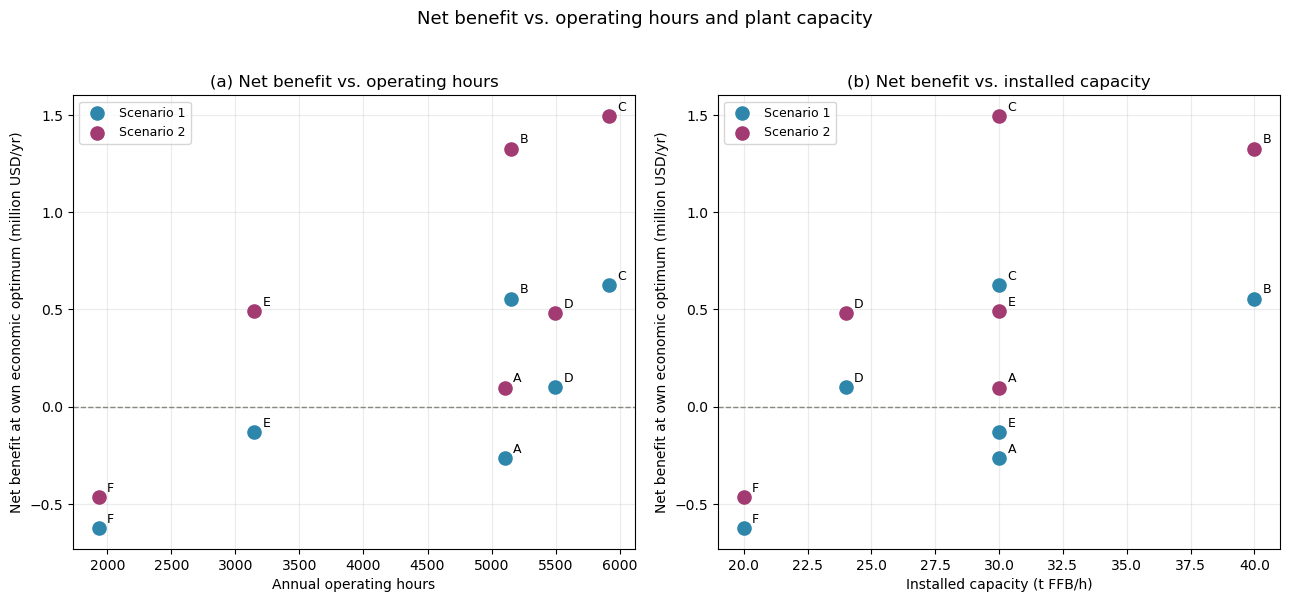

In [131]:
# ==========================================================
# Figura: beneficio neto en el optimo vs. horas de operacion
# y vs. capacidad instalada, por planta y escenario
# ==========================================================
import matplotlib.pyplot as plt

COLOR_ESC1 = "#2E86AB"
COLOR_ESC2 = "#A23B72"

# --- Datos ya validados esta sesion (beneficio neto en el optimo economico, USD/ano) ---
codigos = ['A', 'B', 'C', 'D', 'E', 'F']   # <-- renombrado (antes: 'plantas', pisaba la variable global)
esc1_optimo = [-265284.2, 556273.2, 624459.0, 99276.9, -130360.5, -625666.3]
esc2_optimo = [98206.7, 1328029.6, 1496219.7, 479513.2, 493125.3, -467163.1]

# --- Datos reales de la Tabla 1 del manuscrito ---
horas_dict = {
    'A': 5105, 'B': 5155, 'C': 5920, 'D': 5496, 'E': 3147, 'F': 1931,
}
capacidad_dict = {
    'A': 30, 'B': 40, 'C': 30, 'D': 24, 'E': 30, 'F': 20,
}

horas = [horas_dict[p] for p in codigos]
capacidad = [capacidad_dict[p] for p in codigos]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.8))

# --- Panel (a): beneficio vs. horas de operacion ---
ax1.scatter(horas, [v/1e6 for v in esc1_optimo], color=COLOR_ESC1, s=90, label="Scenario 1", zorder=3)
ax1.scatter(horas, [v/1e6 for v in esc2_optimo], color=COLOR_ESC2, s=90, label="Scenario 2", zorder=3)
for i, p in enumerate(codigos):
    ax1.annotate(p, (horas[i], esc1_optimo[i]/1e6), textcoords="offset points", xytext=(6, 4), fontsize=9)
    ax1.annotate(p, (horas[i], esc2_optimo[i]/1e6), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax1.axhline(0, color="#888780", linestyle="--", linewidth=1, zorder=2)
ax1.set_xlabel("Annual operating hours")
ax1.set_ylabel("Net benefit at own economic optimum (million USD/yr)")
ax1.set_title("(a) Net benefit vs. operating hours")
ax1.grid(alpha=0.25)
ax1.legend(fontsize=9)

# --- Panel (b): beneficio vs. capacidad instalada ---
ax2.scatter(capacidad, [v/1e6 for v in esc1_optimo], color=COLOR_ESC1, s=90, label="Scenario 1", zorder=3)
ax2.scatter(capacidad, [v/1e6 for v in esc2_optimo], color=COLOR_ESC2, s=90, label="Scenario 2", zorder=3)
for i, p in enumerate(codigos):
    ax2.annotate(p, (capacidad[i], esc1_optimo[i]/1e6), textcoords="offset points", xytext=(6, 4), fontsize=9)
    ax2.annotate(p, (capacidad[i], esc2_optimo[i]/1e6), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax2.axhline(0, color="#888780", linestyle="--", linewidth=1, zorder=2)
ax2.set_xlabel("Installed capacity (t FFB/h)")
ax2.set_ylabel("Net benefit at own economic optimum (million USD/yr)")
ax2.set_title("(b) Net benefit vs. installed capacity")
ax2.grid(alpha=0.25)
ax2.legend(fontsize=9)

fig.suptitle("Net benefit vs. operating hours and plant capacity", y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig("figura_horas_vs_capacidad.png", dpi=300, bbox_inches="tight")
plt.show()